# 📘 Cas d'usage — Certification "Concevoir et implémenter une solution d'IA"



Nom Prénom : BERNARD Nicolas  
Parcours : Data Scientist  
Date : 09/01/2026  

**Contexte étudiant** : objectif = montrer un parcours logique de projet IA (cadrage → data → modèle → évaluation → industrialisation), avec liberté sur les choix tant qu'ils sont cohérents et justifiés.

## 🟦 0. Introduction (résumé exécutif)

**Contexte**
- Une entreprise e-commerce souhaite personnaliser ses actions marketing en temps réel (site/app/canaux) pour améliorer la performance commerciale sans dégrader l’expérience.

**Objectifs (imposés par le sujet)**
- Proposer aux clients des offres et des produits adaptés en temps réel.
- Améliorer la conversion, le panier moyen et la fidélisation.
- Respecter confidentialité, éthique et conformité RGPD.

**Cadrage retenu (données & périmètre)**
- Le notebook travaille sur un dataset enrichi de 50 000 sessions (génération autorisée), en conservant le schéma du CSV initial.
- Le fichier ne contient pas d’identifiant de produit : l’objectif n’est donc pas de recommander un article précis.
- À la place, le système sert à calculer un score de propension à l'achat pour chaque session afin de prioriser les interventions : ce score permet ensuite, via une logique Top-K, de choisir l'action marketing la plus pertinente (type d’offre/campagne) et d'orienter le client vers un univers de produits adapté (en s’appuyant notamment sur la dernière catégorie consultée qui incarne le lien entre le score de probabilité et l'action concrète d'orientation produit).

**Objectif IA et livrable**
- Entraîner un modèle qui estime la probabilité qu’un client achète après une recommandation (`purchasedafterreco`), afin d’aider à prioriser les actions marketing.
- Sortie attendue : un score + une décision de déclenchement (par seuil/budget) destinés à guider le choix d'une action marketing (ex. marketingtype) et d'un univers produit (ex. lastcategoryviewed).

**Industrialisation (niveau prototype)**
- Démontrer une intégration possible via une API (Flask) et proposer des garde-fous (éviter d’utiliser des variables qui donneraient une “fausse bonne” performance, limiter la sur-sollicitation, suivre la performance).
- Une petite interface Flask peut afficher des “cartes produits” pour illustrer l’intégration dans une application : ce catalogue sert uniquement à la démonstration visuelle et ne fait pas partie des données d’entraînement.



## 🟦 1. Journal de bord

### 1.1. Démarche globale

- **Clarifier le besoin** : personnaliser des actions marketing pendant la session
  (site web / application mobile / canaux comme email, push notification, SMS et pubs), pour améliorer la conversion et la fidélisation, sans
  sur-solliciter les clients.

- **Comprendre les données**: 1 ligne = 1 session. Le fichier ne contient pas
  d’identifiant produit, donc on ne peut pas recommander “un produit précis”.
  L’objectif devient plutôt : décider quelle action marketing déclencher
  (ex. type de campagne) et vers quel univers de produits orienter (ex. catégorie).

- **Explorer (EDA)** : regarder la qualité des données, les distributions, les valeurs
  manquantes et surtout vérifier qu’on ne “triche” pas avec des variables qui
  arrivent après la décision (par exemple un clic observé après affichage).

- **Stabiliser le travail** : le dataset de départ est petit, donc il est difficile
  d’obtenir des résultats fiables. Un dataset enrichi à 50 000 sessions est utilisé
  pour avoir des analyses et des tests de modèles plus stables, tout en gardant la
  même structure de colonnes.

- **Préparer les données** : nettoyage, encodage des variables catégorielles,
  et préparation de variables simples qui sont disponibles au moment où on doit
  décider (avant d’afficher quelque chose).

- **Modéliser** : entraîner un modèle qui estime la probabilité d’achat après recommandation
  (`purchasedafterreco`). Le modèle renvoie un score (entre 0 et 1) qui sert à classer les
  sessions, puis à décider combien de sessions on cible.

  Dans notre code, on utilise surtout une logique "top-k" : on prend les k sessions avec les
  meilleurs scores (par exemple les 100, 250, 500 ou 1000 meilleures) car cela correspond bien
  à une contrainte de budget / volume de sollicitations.

  Une fois que nous avons identifié ces sessions prioritaires grâce au score et au Top-K, nous aurions ensuite la possibilitéde décider **quelle action marketing déclencher** (par exemple, un `marketing_type` spécifique) et **vers quel univers de produits orienter le client** (en utilisant des informations contextuelles comme la `last_category_viewed` de la session sélectionnée).

  Donc, le code fournit l'**intelligence de priorisation** qui est le fondement de la personnalisation. Le "quelle action" et le "vers quel univers" sont les **actions consécutives** que le score rend possibles et plus efficaces. Le modèle ne les prédit pas directement comme une variable de sortie, mais son score informe ces décisions dans une architecture de recommandation en plusieurs étapes.

- **Prototype d’intégration** : afin de rendre le projet plus concret,  une petite application Flask (simple interface) est créé pour tester des profils “comme si on était en situation”, afficher un score et rendre l’expérience plus interactive. Une API industrielle serait facilement déduite de l'interface utilisateur.

*Mini-glossaire*

- **Seuil (règle métier)** : valeur de score minimale au‑dessus de laquelle on
déclenche l’action (dépend du budget/du coût/contraintes).​

- **Top‑k** :  stratégie de ciblage où l’on déclenche une action marketing / une recommandation uniquement pour les k sessions (ou clients) ayant les scores les plus élevés, afin de respecter un budget/volume de sollicitations, plutôt que d’utiliser un seuil fixe.

### 1.2. Choix effectués et raisons

#### 1.2.1. Synthèse



- **Périmètre**: le fichier ne permet pas une recommandation produit précise (pas de product_id).
  Donc le notebook reste sur quelque chose de simple et exploitable : orienter vers une catégorie
  (`lastcategoryviewed`) et s’appuyer sur un type d’action (`marketingtype`) comme levier marketing.

- **Choix “anti-triche”** : la cible est `purchasedafterreco`, et on retire `recoclicked` des variables
  d’entrée, car c’est une information qui arrive après l’affichage et qui fausserait l’évaluation.

- **Choix de pilotage** : plutôt que de transformer le score en “oui/non” avec un seuil fixe dès le départ,
  le notebook illustre surtout une logique top-k : on cible uniquement les k sessions les mieux notées
  (k = 100, 250, 500, 1000), ce qui correspond bien à une contrainte de volume / budget.

- **Choix sur le volume de données** : passer à 50 000 sessions sert surtout à rendre les tests plus stables
  et à pouvoir regarder les résultats par segments (pays, device, churnrisk), ce qui aidera ensuite à
  discuter simplement des limites, des biais possibles et des améliorations.


####1.2.2. Clarifications sur la solution retenue et son implémentation

Cette clarification est volontaitrement mise en début du notebook (elle pourrait également être dans la section à propos des limites de notre modèle) afin d'éclairer sur nos choix et ses limites en terme d'implémentation si on prenait seul le modèle.

Il est crucial de distinguer ce que le modèle retenu *prédit directement* et ce que le *système complet* (qui inclut le modèle) *permettrait de faire*.

Notre modèle calcule un **score de probabilité** qu'un client achète après une recommandation (`purchased_after_reco`), et cette probabilité sert à établir un classement (Top-K) des sessions à prioriser.

Ce modèle, en tant que tel, **ne dirait pas directement "quelle action marketing déclencher" ni "vers quel univers de produits orienter le client"** au sens d'une recommandation explicite de `marketing_type` ou `last_category_viewed`.

La description initiale dans l'introduction représente l'**objectif global du système** ou la **finalité métier** que le score du modèle est censé soutenir. Le notebook explique comment ce score s'intégrerait dans une stratégie plus large, notamment dans la section 11.1.2 (Approche multi-étapes : scoring + ranking léger (contrôlable)). L'idée serait la suivante :

1.  **Étape 1 : Scoring (ce que fait notre modèle)**
    Notre modèle répondrait à la question **`SI` on doit solliciter** le client maintenant, en estimant sa propension à acheter. Il servirait de **filtre** ou de **priorisateur**.

2.  **Étape 2 : Ranking léger / Règles (ce qui serait informé par le score, mais pas directement prédit par le modèle actuel)**
    Une fois que l'on aurait identifié les sessions prioritaires (le Top-K), on **pourrait utiliser** des **règles métier** ou un **mécanisme de ranking plus léger** pour décider **`QUOI` proposer**. Ces règles **pourraient s'appuyer** sur des variables déjà présentes (comme la `last_category_viewed` de la session actuelle pour suggérer un univers de produits, ou le `segment_marketing` du client pour orienter vers un `marketing_type` spécifique) ou d'autres données.

En somme, notre modèle de scoring est une pièce maîtresse (l'étape de priorisation et de filtrage) qui *permettrait* la recommandation d'action, mais ne la *prédit* pas directement.

*Mini-glossaire*

- **Ranking léger** : Il constitue la composante de notre système qui transformait la probabilité de priorisation (issue du score du modèle) en une action marketing concrète et contextualisée, en s'appuyant sur des règles métier et des informations déjà disponibles, sans pour autant être un moteur de recommandation de produits complexes en soi.

Il est crucial de comprendre la distinction entre l'entraînement d'un modèle sur des données historiques et son application en temps réel pour déclencher des actions marketing.

1.  **Phase d'Apprentissage (sur les sessions passées) :**
    *   Notre modèle est entraîné sur des données historiques (nos 50 000 sessions passées) pour apprendre les patterns et les relations entre les caractéristiques de la session/du client et la probabilité d'achat (`purchased_after_reco`). C'est ainsi qu'un modèle construit son intelligence.
    *   Lors de l'évaluation, la priorisation des 1000 sessions par Top-K nous sert à mesurer l'efficacité du modèle à classer correctement ces données historiques, en fonction d'un volume de ciblage.

2.  **Phase d'Inférence et de Décision (en temps réel sur les sessions actuelles) :**
    *   Une fois notre modèle entraîné et validé, il est **déployé en production**. Lorsqu'un client génère une **nouvelle session en cours**, toutes les informations disponibles en temps réel (`device_type`, `traffic_source`, `last_category_viewed`, `time_on_site_sec`, `total_spent_last_6m`, etc.) sont collectées.
    *   Ces informations sont transmises au modèle déployé (l'**Étape 1 : Scoring** de notre système). Le modèle calcule alors un **score de probabilité** qu'un achat ait lieu après une recommandation pour cette session *actuelle*.
    *   **C'est à ce score que se connecte la décision d'action marketing.** Pour déclencher une action, on applique une **logique de Top-K dynamique** ou un **seuil adaptatif** :
        *   **Top-K dynamique :** Plutôt que de comparer le score de la session actuelle à un seuil statique (dérivé d'un K-ième score d'un ancien dataset), le système en temps réel pourrait comparer le score de la session à ceux d'un ensemble de sessions *récentes ou simultanément actives*. Il prendra une décision si la session actuelle se classe parmi les `K` sessions les plus prometteuses dans le flux de sessions *actuel*. Ce `K` est souvent un budget alloué par les équipes marketing.
        *   **Seuil adaptatif :** Le seuil de déclenchement est régulièrement ajusté (par exemple, quotidiennement ou toutes les heures) en fonction des performances observées, du volume de sollicitations souhaité et des distributions de scores des sessions *récentes* en production. Cela permet au système de s'adapter à la dérive des données et aux variations de comportement.
    *   **Étape 2 : Ranking léger / Règles :** Si la session actuelle est identifiée comme prioritaire (via le Top-K dynamique ou le seuil adaptatif), le système utilise ensuite des **règles métier** pour décider **`QUOI` proposer**. Ces règles peuvent s'appuyer sur des informations comme la `last_category_viewed` de la session (pour l'univers produit) ou le `segment_marketing` du client (pour le type d'offre `marketing_type`), ainsi que d'autres informations contextuelles ou des garde-fous (opt-in, fréquence).

En conclusion, les sessions passées servent à *construire l'intelligence* du modèle (Étape 1 : Scoring). Cette intelligence est ensuite appliquée aux sessions *actuelles*, et la décision d'action est prise via une logique dynamique et des règles métier (Étape 2 : Ranking léger / Règles), constituant le *système complet*.

####1.2.3. Exemples d'Actions Marketing Concrètes

Quand on parle de "quelle action marketing déclencher" dans notre contexte, et étant donné que nous n'avons pas d'identifiant produit précis, voici ce que cela **pourrait** concrètement signifier comme types d'actions :

1.  **Types de campagnes / offres (basées sur `marketing_type`) :**
    *   **Offre de `cross-sell`** : On **pourrait suggérer** des produits complémentaires à ce que le client regarde ou a déjà acheté.
    *   **Offre d' `upsell_vip`** : On **pourrait proposer** une version supérieure ou un service premium à un client identifié comme VIP.
    *   **`promo_flash`** : On **pourrait afficher** une réduction limitée dans le temps pour un type de produit ou une catégorie.
    *   **`relance_panier`** : Si un article a été ajouté au panier puis abandonné, une action **pourrait inciter** à finaliser l'achat.
    *   **`welcome`** : Une offre ou un message de bienvenue **pourrait être envoyé** pour un nouveau client.
    *   **Mise en avant de `nouvelle_collection`** : On **pourrait présenter** les nouveautés si cela correspond à l'historique du client.

2.  **Orientation vers un "univers" ou une catégorie de produits (basée sur `last_category_viewed`) :**
    *   Si le client vient de consulter une catégorie "High-tech / Mobile / Nouveautés", l'action **pourrait être** de lui montrer une bannière ou une section du site qui met en avant d'autres nouveautés mobiles, ou des accessoires compatibles.
    *   Si c'est "Mode / Femme / Soldes", l'action **pourrait être** de l'orienter vers d'autres articles soldés de la catégorie femme.

3.  **Activation d'un canal spécifique :**
    *   **Notification Push** (si `push_optin=1`) : "Un article similaire à notre dernière consultation **pourrait être** en promotion !"
    *   **Pop-up / Banderole in-site** : On **pourrait afficher** un message personnalisé directement sur le site ou l'application.
    *   **Email déclenché** (si `email_optin=1`) : On **pourrait envoyer** un email personnalisé après la session pour relancer l'intérêt.

Donc, l'action marketing" n'est pas une prédiction du modèle lui-même, mais plutôt une **décision business** (un type de campagne, une orientation thématique, un canal d'interaction) qui est **informée et priorisée** par le score de notre modèle. Le modèle nous dit *qui* cibler et *quand* (via le score et le Top-K), et ensuite, ces informations **pourraient être combinées** avec des règles métier et le contexte de la session (comme la `last_category_viewed`) pour choisir le *quoi* et le *comment* de l'action.

### 1.3. Difficultés rencontrées

- **Manque de connaissances métier** :
   - manque de familiarité avec le domaine du e-commerce et ses enjeux métier.
   - rudiments élémentaires sur les algorithmes de recommandation, ce qui permet d’en comprendre les principes généraux sans prétendre à une expertise avancée.

- **Manque de temps** : le temps alloué sur un sujet aussi complexe ajouté aux journées habituelle de travail a contraint à certains sacrifices sur l'analyse en profondeur.

- **Utilisation des grands modèles de langage** : une partie du notebook a été rédigée avec l’aide de LLM pour accélérer la production, mais garder une narration cohérente, éviter les répétitions et rester strict sur les contraintes du sujet s’est révélé compliqué avec une vigilance recquise de tous les instants.  
  Le résultat est utile pour itérer vite, mais c’est loin d’être parfait et nécessite une relecture humaine attentive. Au final c'est une expérience mitigée et extrêmement chaotique.

- **Données trop réduites au départ** : le fichier initial (750 lignes) est trop limité pour tirer des conclusions fiables, car les résultats varient beaucoup selon le split train/test.

- **Données synthétiques** : même après enrichissement, les données restent simulées ; il faut donc rester prudent sur l’interprétation des performances et ne pas les confondre avec un résultat “prêt production”.

- **Périmètre “reco” limité** : l’absence de `product_id` (et de séquences détaillées) empêche de faire une recommandation produit fine ; le projet doit rester sur une recommandation actionnable (type d’action / catégorie proxy) et un score de priorisation.

- **Risque de fuite d’information** : certaines variables décrivent des événements après la décision (ex. `recoclicked`) ; si elles sont utilisées par erreur, le modèle paraît excellent mais devient inexploitable en temps réel.

- **Classe positive rare** : l’achat après recommandation est peu fréquent, ce qui rend des métriques comme l’accuracy trompeuses et oblige à évaluer en PR-AUC / précision-rappel et surtout en **top-k** (ciblage d’un volume limité).

- **Évaluation réaliste plus difficile qu’un split classique** : comme un même client apparaît sur plusieurs sessions, il faut splitter par customerid (split “groupé”) pour s’assurer que toutes les sessions d’un client sont soit dans le train, soit dans le test. Sinon, un split aléatoire par lignes mettrait des sessions du même client des deux côtés, ce qui crée une fuite d’information : le modèle peut “reconnaître” le profil client et les performances (ROC-AUC, PR-AUC, Top‑K) deviennent artificiellement trop élevées.

- **RGPD / éthique : difficile à traiter “proprement” dans un prototype** : ce n’est pas “juste un score”.
  Il faut aussi respecter le consentement (ex. opt-in email/push), limiter la sur-sollicitation
  (anti-spam / fréquence) et rester transparent sur la logique de ciblage, sinon la solution peut
  être illégale (RGPD) ou nuisible (éthique), même si elle est performante.

- **Biais et équité** : certains segments (pays, device, genre, âge, segments marketing) peuvent être sous-représentés ou se comporter différemment ; sans analyse par sous-groupes, le score peut devenir injuste ou pousser à des décisions disproportionnées.

- **Résultat perfectible** : malgré les efforts de clarification, le rendu reste un prototype pédagogique ; certains passages peuvent être améliorés (structure, concision, cohérence globale avec les objectifs du sujet).

*Mini-glossaire*

- **Catégorie proxy** : catégorie utilisée comme approximation de “quoi proposer” (car pas d’identifiant produit), typiquement basée sur la dernière catégorie vue.

- **PR‑AUC (Precision‑Recall AUC)** : Aussi appelée Average Precision, elle mesure la qualité du classement des prédictions en résumant le compromis précision–rappel sur tous les seuils, et elle est particulièrement adaptée quand la classe positive est rare.

- **Opt-in email/push** : indicateur de consentement du client à être contacté via un canal.​


### 1.4. Essais abandonnés

- **Premiers essais sur le fichier 750 lignes** : des tests rapides de modèles de classification “classiques” ont été tentés au début, mais les résultats étaient très instables et parfois **pire que le hasard** selon le split (trop de variance, trop peu de positifs).  
  C’est ce point qui a motivé l’autorisation d’utiliser un dataset enrichi (50 000 sessions) pour avoir une évaluation plus robuste.

- **Recommandation produit “fine” (SKU)** : abandonné, car il manque un identifiant produit (`product_id` / `item_id`) et donc on ne peut pas apprendre une recommandation produit crédible.

- **Filtrage collaboratif / factorisation (SVD, ALS)** : abandonné, car on ne dispose pas d’une vraie matrice user–item exploitable (pas d’historique item-level).

- **Modèles séquentiels (RNN / Transformer clickstream)** : abandonné, car il n’y a pas de séquences d’événements détaillées (vues, ajouts panier, timestamps) permettant d’apprendre un comportement de session.

- **Approche “post-événement” (utiliser `recoclicked` pour prédire `purchasedafterreco`)** : abandonné, car ce serait une fuite d’information (la variable arrive après l’affichage), donc inutilisable en temps réel même si les scores semblent bons.

- **Sur-échantillonnage agressif (ex. SMOTE par défaut / duplication massive)** : abandonné en première intention. Le sur‑échantillonnage agressif (SMOTE “par défaut” ou duplication) augmente artificiellement le nombre de positifs pour “rééquilibrer” l’entraînement, alors qu’en réalité la cible est très rare (≈ 1,5%). Le risque principal, c’est de dégrader la calibration : le modèle apprend dans un monde où il y a trop de positifs, donc le score peut rester correct pour classer, mais devient moins fiable comme “probabilité” réelle.​  Comme l’objectif du projet est surtout de prioriser en top‑k (cibler les meilleurs scores) et d’avoir un ranking stable, le choix a été de privilégier des approches plus simples (pondération de classe + métriques PR‑AUC/top‑k) et de n’ajouter du sur‑échantillonnage que si nécessaire.

- **Objectif “CTR” (prédire le clic `recoclicked`)** : c’était faisable car on a bien `recoshown` (reco affichée) et `recoclicked` (clic).
  Mais on ne l’a pas gardé comme objectif principal, car le besoin final du sujet est surtout la **conversion** (`purchasedafterreco`) et la valeur business :
  faire cliquer ne garantit pas de faire acheter.



*Mini-glossaire*  

- **Calibration** : ajustement des probabilités prédites pour qu'elles reflètent fidèlement la réalité observée.
- **Ranking** : trier les clients/sessions par score du modèle (du plus élevé au plus faible) pour prioriser..
- **SKU** (*Stock Keeping Unit*) : identifiant interne (code) qui représente un produit précis (souvent une variante : taille/couleur), utilisé pour gérer le catalogue et le stock.  
- **SVD** (*Singular Value Decomposition*) : méthode de “factorisation de matrice” utilisée en recommandation pour résumer une matrice utilisateurs×items en quelques facteurs latents et prédire des préférences manquantes.  
- **ALS** (*Alternating Least Squares*) : méthode de factorisation de matrice, souvent utilisée pour la recommandation à grande échelle, qui entraîne les facteurs utilisateurs et items en alternant des optimisations de type “moindres carrés”.  
- **CTR** (*Click-Through Rate*) : taux de clic, c’est-à-dire la proportion de clics parmi les affichages (impressions) d’une recommandation / pub / lien.
- **RNN / Transformer (clickstream)** : modèles “séquentiels” qui apprennent à partir d’une suite d’actions dans l’ordre (ex. pages vues, clics, ajout panier). Un **RNN** lit la séquence étape par étape et garde une “mémoire” du passé ; un **Transformer** regarde la séquence avec un mécanisme d’attention pour capter des dépendances plus longues.  
  On parle de **clickstream** pour désigner la trace des actions de navigation d’un utilisateur sur un site (le chemin de clics/pages).


### 1.5. Risques / biais identifiés


Cette partie liste les principaux risques si on utilise un modèle de scoring pour déclencher des actions marketing en temps réel (objectif 1), améliorer la conversion/panier (objectif 2) et préserver l’expérience pour éviter la sur-sollicitation (objectif 3).

**1. Court terme vs long terme (fatigue, désabonnement)**

Risque : optimiser uniquement sur le clic ou la conversion peut augmenter la pression marketing (trop de sollicitations). À long terme, cela peut fatiguer les clients et augmenter le désabonnement.

Garde-fous : limiter le nombre de sollicitations par client (cap de fréquence) et renforcer les règles sur les clients déjà très exposés ; utiliser un seuil de déclenchement (ne pas pousser à tout le monde, tout le temps) ; suivre des métriques long terme (désabonnement, churn, baisse d’engagement) en plus de la conversion.

**2. Fuite d’information (triche involontaire)**

Risque : utiliser des variables qui n’existent pas au moment de la décision (ex. un clic après affichage) peut donner une performance “trop belle” hors-ligne, mais un modèle inutilisable en production.

Garde-fous : n’utiliser comme entrées que des informations disponibles avant l’affichage (T0) ; garder les variables post-affichage pour analyser l’entonnoir ou entraîner un modèle séparé (ex. modèle de clic), mais pas pour décider d’afficher une reco.

**3. Biais entre segments (équité et robustesse)**

Risque : certains segments (pays, device, âge, genre, segment marketing) peuvent être moins bien représentés ou réagir différemment. Le modèle peut alors être moins performant sur certains groupes et sur-solliciter d’autres groupes.

Garde-fous : mesurer les performances et la pression marketing par sous-groupes (pas seulement en global) ; mettre des alertes si un segment subit une pression trop élevée ou si la performance s’effondre sur un sous-groupe.

**4. Limites du dataset (réalisme)**

Risque : si le dataset est synthétique ou simplifié, certaines relations peuvent être trop “propres” ou peu réalistes. Un modèle peut alors bien marcher en test, mais moins bien en conditions réelles.

Garde-fous : documenter les hypothèses de données (ce qui est simulé vs réel) ; valider les décisions via test en ligne (A/B test) avant de conclure sur le gain business.

*Mini-glossaire*


- **Pression marketing**: fréquence / volume de sollicitations reçues par un client sur une période.

- **Cap de fréquence (frequency capping)** : règle qui limite le nombre d’expositions/contacts par client (ex. max X par semaine).

- **Fuite d’information (leakage)** : utiliser une information connue seulement après la décision (ex. clic après affichage) pour entraîner/évaluer un modèle, ce qui gonfle artificiellement les résultats.

- **T0** : moment où la décision est prise (juste avant l’affichage/la sollicitation)

- **Entonnoir (funnel)** : étapes exposition → clic → achat, utilisées pour comprendre où on perd des utilisateurs.


- **A/B test** : test avec un groupe exposé et un groupe non exposé pour mesurer l’impact réel.

### 1.6. Pistes d’amélioration

**Passer à des données réelles**
Remplacer les données synthétiques par des données observées (logs de navigation, historiques d'achats, retours, SAV) pour réduire le risque de corrélations artificielles et améliorer la validité du modèle en conditions réelles.

**Enrichir le dataset pour une vraie recommandation produit**
Ajouter un identifiant produit, un catalogue détaillé (prix, marge, stock, nouveauté), et des événements au niveau produit (consultation, ajout panier, achat) avec timestamps. Cela permet de passer à une architecture candidats + ranking, plus proche des standards industriels.

**Créer des features d'interaction spécifiques**
Explorer et construire des variables d'interaction entre les features existantes, notamment celles qui, bien que montrant des associations linéaires faibles, sont conceptuellement importantes pour capturer des relations non linéaires complexes et aider le modèle à mieux les exploiter. L'idée serait de créer explicitement des termes qui représentent des synergies ou des effets conditionnels entre deux (ou plus) variables. Par exemple, ce pourrait être un terme (discount_sensitivity == 'forte') * (marketing_type == 'promo_flash'), ou age * total_spent_last_6m.

**Améliorer l'évaluation et la mesure d'impact**
Compléter les métriques offline (PR-AUC, Top-K) par une approche "uplift" (impact causal) et, idéalement, mettre en place un test A/B pour mesurer l'effet réel sur la conversion, le panier moyen et la fidélisation.

**Optimiser le temps réel (latence et coûts)**
Simplifier la production des features (agrégats pré-calculés, features stables), mettre en cache les résultats intermédiaires, et définir des objectifs de latence compatibles avec le web et le mobile.

**Implémenter une architecture multi-étapes**
On peut faire la reco en deux étapes :
- On crée une petite liste de produits/offres “possibles” pour cette session (ex. même catégorie, best-sellers du segment).
- On choisit ensuite le meilleur dans cette liste avec un score.
- Pourquoi : c’est plus rapide en temps réel, souvent plus précis, et plus facile à contrôler (diversité, anti-répétition, cooldown).

**Piloter le seuil de déclenchement de manière dynamique**
Ajuster les seuils selon le budget marketing, la pression acceptable par segment, et le risque de churn. Calibrer les probabilités si nécessaire pour rendre les scores comparables entre segments.

**Renforcer la robustesse et l'équité**
Analyser les performances par sous-groupes (pays, device, genre, âge, segment marketing) pour éviter les biais. Ajouter des garde-fous anti-sur-sollicitation (cap de fréquence, cooldown) et documenter les choix méthodologiques (finalités, minimisation des données, biais identifiés, limites).

**Mettre en place un suivi en production (MLOps)**
Prévoir un monitoring continu (dérive des données, dérive des performances, taux d'opt-in, taux de désabonnement), des alertes automatiques, et une stratégie de ré-entraînement périodique pour maintenir la qualité du modèle dans le temps.

*Mini-glossaire*

 - **Features d'interaction** :  Il s'agit de nouvelles variables qui capturent la façon dont deux (ou plus) variables s'influencent mutuellement dans leur relation avec la cible. Par exemple, au lieu de regarder l'âge et la sensibilité à la remise séparément, une feature d'interaction pourrait être 'âge multiplié par sensibilité à la remise', ou 'sensibilité à la remise forte ET jeune'. L'effet d'une variable sur la prédiction peut dépendre de la valeur d'une autre.

   Cela signifie que, parfois, deux variables prises isolément ne montrent pas une forte corrélation avec la variable cible (purchased_after_reco). Cependant, d'un point de vue métier, on sait ou on suppose que leur combinaison a un sens. Par exemple, la 'source de trafic' seule et le 'type de marketing' seul peuvent avoir un impact modéré sur l'achat. Mais une 'source de trafic Facebook' combinée avec un 'marketing de type promo_flash' pourrait avoir un impact très spécifique et plus fort.

 - **Uplift** : différence d'impact mesurée entre un groupe exposé et un groupe non exposé (effet causal).

- **Candidats** : liste d'offres/produits potentiellement pertinents pour un utilisateur, avant classement final.

- **Cooldown** : délai minimum entre deux sollicitations pour un même client.

- **MLOps** : pratiques d'industrialisation et de suivi continu des modèles de machine learning en production.

##🟦 2. Compréhension du besoin

### 2.1. Contexte métier

Une entreprise e-commerce veut personnaliser ses actions marketing (offres et contenus) pour chaque client, au bon moment et sur le bon canal, afin d’améliorer la performance commerciale sans dégrader l’expérience utilisateur.

Le problème est que des campagnes trop génériques, ou déclenchées sans priorisation, augmentent la pression marketing et peuvent réduire l’efficacité (conversion/panier) ainsi que la fidélisation.​

La solution visée est donc un système de décision temps réel qui score/priorise les sessions. Ceci permettrait ensuite de recommander une action marketing (ex. type de campagne et “univers” de produits via une catégorie), tout en respectant des contraintes opérationnelles (latence, budget de sollicitations) et de conformité (confidentialité, éthique, RGPD).

### 2.2. Problématique formulée

- **Problématique métier** : décider, en temps réel, quelle action marketing déclencher pour une session (type d’action et univers/catégorie proxy) afin d’augmenter conversion/panier et soutenir la fidélisation, tout en limitant la pression marketing.

- **Problématique IA** : construire un modèle de scoring qui estime la probabilité d’achat après recommandation (purchasedafterreco) pour prioriser les sessions en cours. Ceci permettrait ensuite de déclencher une action marketing uniquement au‑delà d’une règle métier (seuil ou top‑k selon budget/volume).​

- **Cadre de mise en œuvre**: utiliser uniquement des informations disponibles au moment de la décision (T0), et compléter le score par des garde‑fous simples (opt‑in, cooldown, fréquence) pour éviter la sur‑sollicitation.​


*Mini-glossaire*

**Univers / catégorie proxy** : catégorie utilisée comme approximation de “quoi proposer” (car pas d’identifiant produit), typiquement basée sur la dernière catégorie vue.

**Modèle de scoring** : modèle qui renvoie un score (souvent une probabilité) pour aider à décider qui cibler.

### 2.3. Hypothèses de départ

- **H1**. La dernière catégorie vue donne une indication d’intérêt : si un client vient de consulter une catégorie, cela aide à estimer la probabilité d’achat après recommandation.​

- **H2**. Les clients plus “actifs” ou plus “fidèles” achètent plus souvent : le nombre de visites récentes et les dépenses passées sont des indices utiles pour estimer la probabilité d’achat.​

- **H3**. (prix / promo, sans produit) : Même sans identifiant produit, le niveau de prix du dernier article consulté (lastproductprice) et le profil “sensibilité aux réductions” (discountsensitivity) peuvent influencer la probabilité d’achat après recommandation.

- **H4**. Le contexte marketing compte (sans parler de timing) : la source de trafic et le type de campagne peuvent changer la probabilité d’achat, donc ce sont des variables à tester.​

- **H5**. Il ne faut pas recommander à tout le monde : il faut cibler sélectivement les sessions. Pour respecter un budget et éviter de trop solliciter les clients, on pourrait par exemple déclencher une action marketing pour une session en cours si son score la place parmi les Top-K des sessions les plus pertinentes à un instant donné.

- **H6**. Résultats à interpréter avec prudence : les données utilisées sont synthétiques/enrichies, donc les chiffres obtenus servent surtout à illustrer une démarche et pas à prouver un gain réel en production.​

- **H7**. Choix simple et robuste : sur des données tabulaires, des modèles classiques et une évaluation stricte (éviter les fuites d’information) sont prioritaires



## 🟦 3. Création d'un dataset exploitable de 50 000 lignes


### **3.1. AVERTISSEMENT IMPORTANT**

Ce projet vise à concevoir un prototype de recommandation marketing
personnalisée en temps réel à partir d’un dataset fourni, dont la structure est “1 ligne = 1 session”. Le sujet demande de proposer des offres et produits adaptés, mais le fichier donné aux étudiants ne contient ni identifiant produit, ni historique item-level, ni séquences de navigation détaillées ; une recommandation SKU-level (collaborative filtering / séquentielle) n’est donc pas scientifiquement défendable sur ces seules données.

**Le périmètre retenu est donc une recommandation “actionnable” en temps réel sous forme de Next Best Action** : scorer la probabilité de conversion post‑recommandation (purchasedafterreco) à partir de signaux disponibles avant la décision. Ce score permettrait ensuite, pour chaque session en cours classée parmi les plus prometteuses (via une stratégie Top-K, en fonction du budget et du volume de sollicitations), de décider de déclencher une offre/campagne et une catégorie “proxy” (par exemple via marketingtype et lastcategoryviewed), avec des garde‑fous anti‑saturation et le respect des opt‑in.

Enfin, le dataset étant entièrement synthétique et initialement très petit, les premières tentatives d’apprentissage se sont révélées instables et peu informatives ; l’enrichissement des données a été autorisé afin de stabiliser les analyses, comparer des approches et illustrer une démarche industrialisable.

**Les résultats chiffrés sont donc interprétés avec prudence : l’objectif principal du notebook est la robustesse méthodologique (anti-fuite, protocole d’évaluation, pipeline reproductible, discussion RGPD/éthique, trajectoire d’industrialisation), en attendant une validation sur données réelles et/ou par expérimentation A/B**.

### 3.2. Code de génération du dataset synthétique

Ce code a été généré intégralement via un LLM. Il vise uniquement à produire un fichier de données synthétique qui permet d'initier notre parcours.
Il n'est pas commenté plus que raisonnable car il ne constitue pas l'objet principal de notre étude.

Le code ci‑dessous crée un **fichier CSV de 50 000 lignes**, avec **1 ligne = 1 session**, en gardant exactement les mêmes colonnes et le même ordre que le fichier d’origine.


*Mini-glossaire (pour les sous-sections du 3.2)*

- **Dataset synthétique** : jeu de données artificiel, généré par du code, qui imite la structure et quelques statistiques d’un vrai dataset.
- **Loi à queue longue** : situation où quelques clients peuvent avoir beaucoup plus de sessions que la moyenne.
- **Churn** : risque qu’un client arrête d’acheter ou de revenir sur le site.
- **Entonnoir (funnel)** : enchaînement d’étapes marketing, par exemple “recommandation affichée → clic → achat”.
- **CTR (Click‑Through Rate / taux de clic)** :  parmi les sessions où une recommandation a été affichée (recoshown = 1), part des sessions où elle a été cliquée (recoclicked = 1).

  Exemple : sur 100 sessions où une reco est affichée, il y a 15 clics → CTR = 15/100 = 15%
- **CVR (Conversion Rate/ taux de conversion) après clic :** parmi les sessions où une recommandation a été cliquée (recoclicked = 1), part des sessions où il y a eu un achat après reco (purchasedafterreco = 1).

  Exemple : sur 20 sessions avec clic, il y a 3 achats après reco → CVR = 3/20 = 15%.


####3.2.1. But du code

- Lire le fichier CSV de base pour récupérer :
  - la liste exacte des colonnes
  - la répartition de certaines variables (genre, pays, source de trafic, type d’appareil, type de campagne, source marketing, prix du dernier produit vu).
- Simuler ensuite :
  - des clients
  - plusieurs sessions par client
  - jusqu’à obtenir exactement 50 000 sessions.
- Sauvegarder le résultat dans un nouveau CSV, qui servira de dataset synthétique pour la suite du projet.


####3.2.2. Principales hypothèses

- **Plusieurs sessions par client**  
  - Chaque client peut avoir plusieurs sessions.  
  - Le nombre de sessions par client est tiré au hasard (certains clients ont plus de sessions que la moyenne), puis ajusté pour arriver à 50 000 lignes au total.

- **Comportement d’achat simplifié**  
 Pour chaque session, le code commence par donner à la session un niveau d’“envie d’acheter” de base.
Ce niveau dépend d’un score de churn : un client qui semble fidèle garde une envie plus forte, un client en risque de départ a une envie plus faible.   Ensuite, cette envie est ajustée selon la façon dont le client est arrivé sur le site.
 Par exemple, une session venant d’un email ou d’un accès direct est considérée comme plus “chaude”, donc l’intention d’achat est augmentée.
À l’inverse, une session venant des réseaux sociaux est vue comme moins engagée, donc l’intention d’achat est un peu réduite.


  Le code calcule une probabilité d'achat en combinant l'état de fidélité du client et la source de son trafic. C'est une simplification pour créer un dataset avec des comportements d'achat variés, sans être basée sur un modèle de comportement réel complexe.

- **Cohérence du tunnel marketing**  
Le code veut éviter des situations illogiques dans les données. Il applique donc une règle de bon sens sur la chaîne des événements :
  - Pour qu’il y ait un achat après recommandation, il faut d’abord que la recommandation ait été cliquée.

  - Pour qu’il y ait un clic, il faut d’abord que la recommandation ait été affichée.

  En pratique, ça signifie : Affichage → Clic → Achat (dans cet ordre).

  Si, pendant la génération, une session sort “cassée” (ex. achat=1 mais clic=0, ou clic=1 mais affichage=0), le code ne garde pas cette incohérence. Il la corrige automatiquement en remettant les indicateurs dans un état logique (par exemple : si achat=1 alors clic=1 et affichage=1 ; si affichage=0 alors clic=0 et achat=0).

- **Catégorie et prix du dernier produit vu**  
  - `lastcategoryviewed` est transformée en une catégorie plus fine, organisée sous forme de chemins du type `root.sous_categorie.sous_sous_categorie`.
  - `lastproductprice` est générée à partir d’une distribution de prix inspirée du fichier de base, avec des bornes minimum/maximum pour rester dans des valeurs réalistes.

- **total_spent_last_6m (Total dépensé par le client sur les 6 derniers mois)**
   - Hypothèse de génération : Cette variable est un attribut au niveau du client, non de la session. Elle est initialisée une fois pour chaque client au début de sa vie simulée (avec une distribution gamma). Elle n'est mise à jour et augmentée que si un achat est réalisé (purchased == 1) au cours d'une session. Elle représente donc la somme cumulative des dépenses du client.
   - Il est normal que le total_spent_last_6m reste similaire (ou identique) pour toutes les sessions d'un même client s'il n'y a pas d'achat dans ces sessions. La valeur affichée pour une session donnée est celle du total dépensé avant la fin de cette session.

- **avg_basket_value (Valeur moyenne du panier du client)**

   - Hypothèse de génération : Cette variable est une valeur indicative générée pour chaque session. Elle n'est pas le calcul d'une moyenne historique exacte des paniers précédents du client. Elle est plutôt tirée aléatoirement (np.random.normal) pour chaque session, ajustée en fonction du segment_marketing du client (par exemple, les VIP ont une avg_basket_value de base plus élevée), et bornée (np.clip).
   - L'objectif de cette variable est de simuler une valeur typique de panier pour la session en cours, en s'appuyant sur le profil client du moment. Puisqu'elle est tirée aléatoirement pour chaque session (même si elle dépend du segment), il est attendu qu'elle varie d'une session à l'autre pour le même client.

- **last_product_price (Prix du dernier produit consulté)**

   - Hypothèse de génération : Ce prix est également généré pour chaque session, et il dépend fortement de la last_category_viewed pour cette session (les catégories high-tech ont des prix plus élevés que la beauté, par exemple). Le prix est tiré d'une distribution log-normale et borné dans des plages réalistes pour chaque catégorie.
   - Il est tout à fait possible que le last_product_price (le prix d'un seul produit vu dans la session actuelle) soit supérieur au total_spent_last_6m d'un client. Cela peut se produire si le client est nouveau ou n'a fait que des petits achats dans les 6 derniers mois, et consulte maintenant un produit très cher. Ces deux variables représentent des concepts différents : l'une est une dépense cumulative passée, l'autre est le prix d'un item unique en consultation.

- **visits_last_30d (Nombre de visites sur le site dans les 30 derniers jours)** :
   - Hypothèse de génération : Cette variable est un compteur au niveau du client, qui est mis à jour à chaque nouvelle session. Le code simule une légère variation à chaque session (np.random.choice([-1, 0, 1, 2])).
   - Conséquence : visits_last_30d va donc varier d'une session à l'autre pour un même client, reflétant une dynamique d'activité.


####3.2.3. Limites et réglages possibles

- Le modèle de génération reste volontairement simple :
  - pas de vrai catalogue produits
  - pas de séquence détaillée d’actions dans la session (vue, ajout panier, achat)
  - `avgbasketvalue` est une valeur approximative liée au segment client, pas un calcul exact de panier.

- Plusieurs paramètres peuvent être ajustés si besoin, par exemple :
  - les taux de clic et de conversion (CTR / CVR)
  - la répartition des sessions entre clients
  - le nombre de catégories (environ 120)
  - l’influence des différents canaux.

####3.2.4. Code de génération

***A N'EXECUTER QUE POUR CREATION DU DATASET DE 50 000 LIGNES***

In [ ]:
import time
import numpy as np
import pandas as pd

# =========================
# 0) Affichage qualité (console)
# =========================
def print_quality_report(quality_report: dict) -> None:
    print("\n=== QUALITY REPORT (console) ===")
    for check_name, payload in quality_report.items():
        if isinstance(payload, dict):
            print(f"- {check_name}")
            for metric, value in payload.items():
                print(f"    {metric}: {value}")
        else:
            print(f"- {check_name}: {payload}")


# =========================
# 1) Taxonomie + prix
# =========================
def build_taxonomy(n_categories: int = 120) -> list[str]:
    roots = ["mode", "high-tech", "maison", "beauté", "sport"]
    sub1 = {
        "mode": ["femme", "homme", "enfant", "accessoires"],
        "high-tech": ["mobile", "audio", "gaming", "informatique", "photo"],
        "maison": ["cuisine", "deco", "linge", "jardin", "bricolage"],
        "beauté": ["soin", "maquillage", "parfum", "cheveux"],
        "sport": ["fitness", "outdoor", "running", "velo", "collectifs"],
    }
    sub2 = ["entree", "milieu", "premium", "soldes", "nouveautes", "best_sellers"]

    cats = []
    # On vise n_categories uniques
    while len(cats) < n_categories:
        r = np.random.choice(roots)
        s1 = np.random.choice(sub1[r])
        s2 = np.random.choice(sub2)
        cats.append(f"{r}.{s1}.{s2}")
        cats = list(dict.fromkeys(cats))  # unique, garde l'ordre

    return cats[:n_categories]


def fit_price_distributions(taxonomy: list[str], base: pd.DataFrame) -> dict:
    base_prices = base["last_product_price"].clip(lower=0.5)

    global_mu = np.log(base_prices).mean()
    global_sigma = np.log(base_prices).std(ddof=0)

    family_mult = {
        "mode": 0.9,
        "high-tech": 1.15,
        "maison": 1.0,
        "beauté": 0.85,
        "sport": 1.05,
    }

    params = {}
    for cat in taxonomy:
        root = cat.split(".")[0]
        mu = global_mu + np.log(family_mult.get(root, 1.0))
        sigma = max(0.25, min(0.9, global_sigma))

        if root == "beauté":
            pmin, pmax = 3, 350
        elif root == "mode":
            pmin, pmax = 5, 800
        elif root == "high-tech":
            pmin, pmax = 10, 2500
        elif root == "maison":
            pmin, pmax = 5, 2000
        else:
            pmin, pmax = 5, 1500

        params[cat] = {"mu": mu, "sigma": sigma, "pmin": pmin, "pmax": pmax}

    return params


def sample_price(cat: str, cat_price_params: dict) -> float:
    p = cat_price_params[cat]
    x = np.random.lognormal(mean=p["mu"], sigma=p["sigma"])
    x = float(np.clip(x, p["pmin"], p["pmax"]))
    return round(x, 2)


# =========================
# 2) Génération clients + sessions
# =========================
def generate_customers(n_customers: int, base: pd.DataFrame) -> pd.DataFrame:
    genders = base["gender"].value_counts(normalize=True)
    countries = base["country"].value_counts(normalize=True)
    ages = base["age"].astype(int).values
    disc_values = base["discount_sensitivity"].value_counts(normalize=True)

    customers = []
    for _ in range(n_customers):
        cust_id = f"C{np.random.randint(10000, 99999)}"
        customers.append(
            {
                "customer_id": cust_id,
                "age": int(np.random.choice(ages)),
                "gender": str(np.random.choice(genders.index, p=genders.values)),
                "country": str(np.random.choice(countries.index, p=countries.values)),
                "discount_sensitivity": str(
                    np.random.choice(disc_values.index, p=disc_values.values)
                ),
                "email_optin": int(np.random.choice([0, 1], p=[0.45, 0.55])),
                "push_optin": int(np.random.choice([0, 1], p=[0.55, 0.45])),
            }
        )

    cust_df = pd.DataFrame(customers).drop_duplicates(subset=["customer_id"])

    while len(cust_df) < n_customers:
        extra = generate_customers(n_customers - len(cust_df), base)
        cust_df = (
            pd.concat([cust_df, extra], ignore_index=True)
            .drop_duplicates(subset=["customer_id"])
        )

    return cust_df.head(n_customers).reset_index(drop=True)


def sample_sessions_count(customers: pd.DataFrame, target_total: int = 50_000) -> pd.Series:
    n = len(customers)
    r, p = 2.0, 0.35

    counts = np.random.negative_binomial(n=r, p=p, size=n) + 1
    factor = target_total / counts.sum()
    counts = np.maximum(1, np.round(counts * factor).astype(int))

    diff = target_total - counts.sum()
    if diff > 0:
        idx = np.random.choice(np.arange(n), size=diff, replace=True)
        counts[idx] += 1
    elif diff < 0:
        candidates = np.where(counts > 1)[0]
        if len(candidates) > 0:
            idx = np.random.choice(
                candidates, size=min(-diff, len(candidates)), replace=False
            )
            counts[idx] -= 1

    return pd.Series(counts, index=customers["customer_id"].values)


def new_session_id() -> str:
    return f"S{np.random.randint(100000, 999999)}"


# =========================
# 3) Logique comportementale + cohérence métier
# =========================
def sample_device(base: pd.DataFrame) -> str:
    vc = base["device_type"].value_counts(normalize=True)
    return str(np.random.choice(vc.index, p=vc.values))


def sample_traffic(base: pd.DataFrame) -> str:
    vc = base["traffic_source"].value_counts(normalize=True)
    return str(np.random.choice(vc.index, p=vc.values))


def sample_marketing_type(base: pd.DataFrame) -> str:
    vc = base["marketing_type"].value_counts(normalize=True)
    return str(np.random.choice(vc.index, p=vc.values))


def sample_source_field(base: pd.DataFrame) -> str:
    vc = base["source"].value_counts(normalize=True)
    return str(np.random.choice(vc.index, p=vc.values))


def churn_state_update(prev_score: float, engaged: bool, purchased: bool) -> float:
    score = prev_score
    score += 0.03 if not engaged else -0.02
    score += -0.08 if purchased else 0.02
    return float(np.clip(score, 0.0, 1.0))


def churn_bucket(score: float) -> str:
    if score < 0.33:
        return "faible"
    if score < 0.66:
        return "moyen"
    return "élevé"


def segment_from_history(
    total_spent_last_6m: float, visits_last_30d: int, churn_score: float
) -> str:
    if total_spent_last_6m > 1200 and visits_last_30d >= 8:
        return "VIP"
    if churn_score > 0.75 and visits_last_30d <= 4:
        return "churning"
    if visits_last_30d <= 2 and total_spent_last_6m < 200:
        return "nouveau"
    return "fidèle"


def enforce_funnel_rules(df: pd.DataFrame) -> pd.DataFrame:
    df.loc[df["purchased_after_reco"] == 1, "reco_clicked"] = 1
    df.loc[df["reco_clicked"] == 1, "reco_shown"] = 1
    df.loc[df["reco_shown"] == 0, ["reco_clicked", "purchased_after_reco"]] = 0
    df.loc[df["reco_clicked"] == 0, "purchased_after_reco"] = 0
    return df


# =========================
# 4) Quality checks (affichage console)
# =========================
def run_quality_checks(base: pd.DataFrame, synth: pd.DataFrame) -> dict:
    report = {}

    report["schema"] = {
        "base_cols": len(base.columns),
        "synth_cols": len(synth.columns),
        "missing_cols_in_synth": int(len(set(base.columns) - set(synth.columns))),
        "extra_cols_in_synth": int(len(set(synth.columns) - set(base.columns))),
        "synth_rows": int(len(synth)),
    }

    report["rates"] = {
        "reco_shown_rate": float(synth["reco_shown"].mean()),
        "reco_clicked_rate": float(synth["reco_clicked"].mean()),
        "purchase_after_reco_rate": float(synth["purchased_after_reco"].mean()),
        "ctr_cond_shown": float(
            synth.loc[synth["reco_shown"] == 1, "reco_clicked"].mean()
            if (synth["reco_shown"] == 1).any()
            else 0.0
        ),
        "cvr_cond_click": float(
            synth.loc[synth["reco_clicked"] == 1, "purchased_after_reco"].mean()
            if (synth["reco_clicked"] == 1).any()
            else 0.0
        ),
    }

    for col in [
        "visits_last_30d",
        "total_spent_last_6m",
        "avg_basket_value",
        "last_product_price",
        "time_on_site_sec",
    ]:
        report[f"drift_mean_{col}"] = {
            "base_mean": float(base[col].mean()),
            "synth_mean": float(synth[col].mean()),
            "abs_diff": float(abs(base[col].mean() - synth[col].mean())),
        }

    return report


# =========================
# 5) Main: generate + export dataset CSV (seul fichier)
# =========================
def generate_enriched_dataset_50k(
    base_csv_path: str = "02.marketing_reco_dataset_complete.csv",
    out_dataset_csv: str = "marketing_reco_dataset_enriched_50k.csv",
    n_customers: int = 12_000,
    target_rows: int = 50_000,
    n_categories: int = 120,
    random_seed: int = 42,
    progress_every: int = 10_000,  # <-- affichage tous les 10 000
) -> pd.DataFrame:
    t0 = time.time()
    np.random.seed(random_seed)

    print(f"[START] seed={random_seed}, target_rows={target_rows}, n_customers={n_customers}")

    # 1) Charger base
    print(f"[1/8] Loading base CSV: {base_csv_path}")
    base = pd.read_csv(base_csv_path)
    expected_cols = list(base.columns)
    print(f" Base loaded: rows={len(base)}, cols={len(expected_cols)}")

    # 2) Taxonomie
    print(f"[2/8] Building taxonomy: n_categories={n_categories}")
    taxonomy = build_taxonomy(n_categories=n_categories)
    print(f" Taxonomy built: {len(taxonomy)} categories (example: {taxonomy[0]})")

    # 3) Prix par catégorie
    print("[3/8] Fitting price distributions (from base last_product_price)")
    cat_price_params = fit_price_distributions(taxonomy, base)
    print(" Price params ready.")

    # 4) Clients
    print(f"[4/8] Generating customers: n_customers={n_customers}")
    customers = generate_customers(n_customers=n_customers, base=base)
    print(f" Customers generated: {len(customers)} unique customer_id")

    # 5) Plan de sessions (pour arriver à 50k lignes)
    print(f"[5/8] Sampling sessions per customer to reach target_rows={target_rows}")
    sessions_count = sample_sessions_count(customers, target_total=target_rows)
    print(
        f" Sessions planned: total={int(sessions_count.sum())}, "
        f"min={int(sessions_count.min())}, max={int(sessions_count.max())}"
    )

    # 6) États initiaux clients
    print("[6/8] Initializing customer states (churn + spend + visits)")
    churn_score = {
        cid: float(np.random.uniform(0.2, 0.8)) for cid in customers["customer_id"].values
    }
    total_spent_6m = {
        cid: float(np.random.gamma(shape=2.0, scale=250.0))
        for cid in customers["customer_id"].values
    }
    visits_30d = {cid: int(np.random.poisson(lam=6)) for cid in customers["customer_id"].values}
    print(" States initialized.")

    # 7) Génération sessions (long)
    print("[7/8] Simulating sessions -> rows (this is the long step)")
    rows = []
    produced = 0
    last_print = 0

    for _, c in customers.iterrows():
        cid = c["customer_id"]
        n_sess = int(sessions_count.loc[cid])

        for _ in range(n_sess):
            dev = sample_device(base)
            traffic = sample_traffic(base)

            intent = 1 / (1 + np.exp(3 * (churn_score[cid] - 0.5)))
            if traffic in ["email", "direct"]:
                intent = float(np.clip(intent + 0.15, 0, 1))
            if traffic in ["social"]:
                intent = float(np.clip(intent - 0.10, 0, 1))

            cat = str(np.random.choice(taxonomy))
            price = sample_price(cat, cat_price_params)

            reco_shown = int(np.random.rand() < (0.55 + 0.20 * intent))

            base_ctr = 0.08 + 0.10 * intent
            if c["discount_sensitivity"] == "forte":
                base_ctr += 0.02
            reco_clicked = int(reco_shown == 1 and (np.random.rand() < base_ctr))

            base_cvr = 0.05 + 0.18 * intent
            purchased = int(reco_clicked == 1 and (np.random.rand() < base_cvr))

            time_on_site = int(
                np.clip(
                    np.random.lognormal(mean=6.1 - 0.4 * intent, sigma=0.55) + 40 * reco_shown,
                    10,
                    7200,
                )
            )

            engaged = (time_on_site >= 120) or (reco_clicked == 1)

            visits_30d[cid] = int(
                np.clip(
                    visits_30d[cid] + np.random.choice([-1, 0, 1, 2], p=[0.1, 0.4, 0.35, 0.15]),
                    0,
                    60,
                )
            )

            if purchased == 1:
                total_spent_6m[cid] = float(
                    total_spent_6m[cid] + price * np.random.uniform(0.8, 1.2)
                )

            churn_score[cid] = churn_state_update(
                churn_score[cid], engaged=engaged, purchased=bool(purchased)
            )

            segment = segment_from_history(total_spent_6m[cid], visits_30d[cid], churn_score[cid])
            churn_risk = churn_bucket(churn_score[cid])

            aov = float(np.clip(np.random.normal(loc=110 + 40 * (segment == "VIP"), scale=60), 5, 4000))
            aov = round(aov, 2)

            rows.append(
                {
                    "customer_id": cid,
                    "session_id": new_session_id(),
                    "age": int(c["age"]),
                    "gender": str(c["gender"]),
                    "country": str(c["country"]),
                    "device_type": dev,
                    "traffic_source": traffic,
                    "visits_last_30d": int(visits_30d[cid]),
                    "total_spent_last_6m": round(float(total_spent_6m[cid]), 2),
                    "avg_basket_value": aov,
                    "segment_marketing": segment,
                    "last_category_viewed": cat,
                    "last_product_price": price,
                    "discount_sensitivity": str(c["discount_sensitivity"]),
                    "email_optin": int(c["email_optin"]),
                    "push_optin": int(c["push_optin"]),
                    "reco_shown": int(reco_shown),
                    "reco_clicked": int(reco_clicked),
                    "purchased_after_reco": int(purchased),
                    "time_on_site_sec": int(time_on_site),
                    "churn_risk": churn_risk,
                    "marketing_type": sample_marketing_type(base),
                    "source": sample_source_field(base),
                }
            )

            produced += 1
            if produced - last_print >= progress_every:
                elapsed = time.time() - t0
                print(f" Progress: {produced}/{target_rows} rows generated | elapsed={elapsed:.1f}s")
                last_print = produced

    # DataFrame + schéma exact
    print(" Converting rows -> DataFrame")
    df = pd.DataFrame(rows)
    df = df[expected_cols]  # force colonnes + ordre

    # Contraintes funnel
    print(" Enforcing funnel rules (purchase -> click -> shown)")
    df = enforce_funnel_rules(df)

    # Assure taille exacte
    print(f" Ensuring exactly {target_rows} rows (sampling if needed)")
    if len(df) != target_rows:
        df = df.sample(n=target_rows, replace=False, random_state=random_seed).reset_index(drop=True)

    # 8) Checks + export dataset (seul fichier)
    print("[8/8] Quality checks + export dataset CSV")
    quality_report = run_quality_checks(base=base, synth=df)
    print_quality_report(quality_report)

    df.to_csv(out_dataset_csv, index=False, encoding="utf-8")

    elapsed_total = time.time() - t0
    print(f"[DONE] Wrote dataset: {out_dataset_csv} | rows={len(df)}")
    print(f"[DONE] Total elapsed: {elapsed_total:.1f}s")

    return df


# =========================
# 6) Run
# =========================
df_synth = generate_enriched_dataset_50k(
    base_csv_path="02.marketing_reco_dataset_complete.csv",
    out_dataset_csv="marketing_reco_dataset_enriched_50k.csv",
    n_customers=12_000,
    target_rows=50_000,
    n_categories=120,
    random_seed=42,
    progress_every=10_000,  # <-- affichage tous les 10 000
)


[START] seed=42, target_rows=50000, n_customers=12000
[1/8] Loading base CSV: 02.marketing_reco_dataset_complete.csv
 Base loaded: rows=750, cols=23
[2/8] Building taxonomy: n_categories=120
 Taxonomy built: 120 categories (example: beauté.soin.premium)
[3/8] Fitting price distributions (from base last_product_price)
 Price params ready.
[4/8] Generating customers: n_customers=12000
 Customers generated: 12000 unique customer_id
[5/8] Sampling sessions per customer to reach target_rows=50000
 Sessions planned: total=50000, min=1, max=24
[6/8] Initializing customer states (churn + spend + visits)
 States initialized.
[7/8] Simulating sessions -> rows (this is the long step)
 Progress: 10000/50000 rows generated | elapsed=28.5s
 Progress: 20000/50000 rows generated | elapsed=54.0s
 Progress: 30000/50000 rows generated | elapsed=79.1s
 Progress: 40000/50000 rows generated | elapsed=104.0s
 Progress: 50000/50000 rows generated | elapsed=129.2s
 Converting rows -> DataFrame
 Enforcing funne

## **🟦** 4. Exploration des données


### 4.1. Chargement des données

Le notebook utilise le jeu de données enrichi (50 000 lignes) comme source principale pour l’exploration et la modélisation.



In [ ]:
import pandas as pd

# Dataset principal (50k lignes)
DATA_PATH = "marketing_reco_dataset_enriched_50k.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset chargé :", DATA_PATH)
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

df.head()


Dataset chargé : marketing_reco_dataset_enriched_50k.csv
Dimensions : 50000 lignes × 23 colonnes


,customer_id,session_id,age,gender,country,device_type,traffic_source,visits_last_30d,total_spent_last_6m,avg_basket_value,...,discount_sensitivity,email_optin,push_optin,reco_shown,reco_clicked,purchased_after_reco,time_on_site_sec,churn_risk,marketing_type,source
0,C76320,S419457,30,NC,IT,desktop,email,9,998.62,74.02,...,faible,0,1,1,1,0,251,faible,cross_sell,app_store
1,C60993,S317919,63,Autre,FR,desktop,social,6,663.81,148.69,...,forte,1,1,1,0,0,901,élevé,cross_sell,facebook
2,C60993,S199592,63,Autre,FR,tablet,organic,7,663.81,58.68,...,forte,1,1,1,0,0,955,élevé,upsell_vip,play_store
3,C60993,S619816,63,Autre,FR,desktop,organic,8,663.81,34.75,...,forte,1,1,1,0,0,217,élevé,cross_sell,whatsapp_business
4,C60993,S595222,63,Autre,FR,mobile,social,9,663.81,81.90,...,forte,1,1,1,0,0,400,élevé,promo_flash,affiliation


### 4.2. Informations générales

*(Dimensions, types de variables, valeurs manquantes.)*







#### 4.2.1. Dictionnaire de données



In [ ]:
import pandas as pd
from textwrap import wrap

# Définition du dictionnaire de données
data_dictionary = pd.DataFrame([
    {"variable": "customer_id", "type": "object", "description": "Identifiant anonyme du client"},
    {"variable": "session_id", "type": "object", "description": "Identifiant anonyme de la session"},
    {"variable": "age", "type": "int64", "description": "Âge du client"},
    {"variable": "gender", "type": "object", "description": "Genre (M, F, Autre, NC)"},
    {"variable": "country", "type": "object", "description": "Pays du client"},
    {"variable": "device_type", "type": "object", "description": "Type d'appareil utilisé (mobile, desktop, tablet)"},
    {"variable": "traffic_source", "type": "object", "description": "Source de trafic (organic, paid, social, email, referral)"},
    {"variable": "visits_last_30d", "type": "int64", "description": "Nombre de visites sur le site dans les 30 derniers jours"},
    {"variable": "total_spent_last_6m", "type": "float64", "description": "Total dépensé par le client sur les 6 derniers mois"},
    {"variable": "avg_basket_value", "type": "float64", "description": "Valeur moyenne du panier du client"},
    {"variable": "segment_marketing", "type": "object", "description": "Segment marketing du client"},
    {"variable": "last_category_viewed", "type": "object", "description": "Dernière catégorie de produit consultée"},
    {"variable": "last_product_price", "type": "float64", "description": "Prix du dernier produit consulté"},
    {"variable": "discount_sensitivity", "type": "object", "description": "Sensibilité du client aux réductions (faible, moyenne, forte)"},
    {"variable": "email_optin", "type": "int64", "description": "Indicateur d'opt-in email (0=non, 1=oui)"},
    {"variable": "push_optin", "type": "int64", "description": "Indicateur d'opt-in push notification (0=non, 1=oui)"},
    {"variable": "reco_shown", "type": "int64", "description": "Indicateur si une recommandation a été affichée (0=non, 1=oui)"},
    {"variable": "reco_clicked", "type": "int64", "description": "Indicateur si une recommandation a été cliquée (0=non, 1=oui)"},
    {"variable": "purchased_after_reco", "type": "int64", "description": "Indicateur si un achat a eu lieu après la recommandation (0=non, 1=oui)"},
    {"variable": "time_on_site_sec", "type": "int64", "description": "Temps passé sur le site en secondes"},
    {"variable": "churn_risk", "type": "object", "description": "Risque de désabonnement (faible, moyen, élevé)"},
    {"variable": "marketing_type", "type": "object", "description": "Type de campagne marketing ciblée"},
    {"variable": "source", "type": "object", "description": "Source spécifique de la campagne/trafic (ex: facebook, google, newsletter)"}
])

# Vérification rapide : variables manquantes ou en trop (inchangé)
cols_df = set(df.columns)
cols_dict = set(data_dictionary["variable"])
missing_in_dict = sorted(list(cols_df - cols_dict))
extra_in_dict = sorted(list(cols_dict - cols_df))

print("=" * 80)
print("DICTIONNAIRE DES VARIABLES")
print("=" * 80)

# --- Affichage table alignée (description à gauche) ---
w_var = max(12, min(25, data_dictionary["variable"].str.len().max()))
w_type = max(4,  min(22, data_dictionary["type"].str.len().max()))
w_desc = 80  # largeur de la description (ajuste si tu veux)

header = f"{'variable':<{w_var}} | {'type':<{w_type}} | {'description':<{w_desc}}"
sep = "-" * len(header)

print("\n📌 Dictionnaire :")
print(header)
print(sep)

for _, r in data_dictionary.iterrows():
    desc_lines = wrap(str(r["description"]), width=w_desc) or [""]
    # première ligne
    print(f"{str(r['variable']):<{w_var}} | {str(r['type']):<{w_type}} | {desc_lines[0]:<{w_desc}}")
    # lignes suivantes (description uniquement)
    for line in desc_lines[1:]:
        print(f"{'':<{w_var}} | {'':<{w_type}} | {line:<{w_desc}}")

print("\n📌 Contrôles de cohérence :")
print(f"Variables présentes dans df mais absentes du dictionnaire : {missing_in_dict}")
print(f"Variables présentes dans le dictionnaire mais absentes de df : {extra_in_dict}")

DICTIONNAIRE DES VARIABLES

📌 Dictionnaire :
variable             | type    | description                                                                     
-----------------------------------------------------------------------------------------------------------------
customer_id          | object  | Identifiant anonyme du client                                                   
session_id           | object  | Identifiant anonyme de la session                                               
age                  | int64   | Âge du client                                                                   
gender               | object  | Genre (M, F, Autre, NC)                                                         
country              | object  | Pays du client                                                                  
device_type          | object  | Type d'appareil utilisé (mobile, desktop, tablet)                               
traffic_source       | object  | Source de 

#### 4.2.2. Dimensions, valeurs manquantes et doublons

In [ ]:
import pandas as pd

print("=" * 80)
print("DIMENSIONS, TYPES, VALEURS MANQUANTES ET DOUBLONS ")
print("=" * 80)

# =========================
# Dimensions + mémoire
# =========================
dim_tbl = pd.DataFrame(
    {
        "Indicateur": ["Lignes (sessions)", "Colonnes (variables)", "Mémoire (MB)"],
        "Valeur": [
            f"{df.shape[0]:,}",
            f"{df.shape[1]:,}",
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}",
        ],
    }
)
print("\n📊 DIMENSIONS")
print(dim_tbl.to_string(index=False))  # table lisible en console/Jupyter [web:300]

# =========================
# Types (distribution)
# =========================
dtype_tbl = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="n_colonnes")
)
print("\n📌 TYPES DE VARIABLES (distribution)")
print(dtype_tbl.to_string(index=False))  # affichage tabulaire propre [web:300]

# =========================
# Valeurs manquantes (top)
# =========================
missing_tbl = pd.DataFrame(
    {
        "colonne": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(3),
    }
).sort_values(["missing_count", "colonne"], ascending=[False, True])

print("\n📌 VALEURS MANQUANTES (top 15)")
print(missing_tbl.head(15).to_string(index=False))  # table, pas une Series [web:300]

if missing_tbl["missing_count"].max() == 0:
    print("\n✅ Aucune valeur manquante détectée dans le dataset.")

# =========================
# Doublons
# =========================
dup_tbl = pd.DataFrame(
    {
        "Type de doublon": [
            "Lignes exactes (toutes colonnes)",
            "session_id dupliqué",
            "(customer_id, session_id) dupliqué",
        ],
        "Nombre": [
            int(df.duplicated().sum()),
            int(df["session_id"].duplicated().sum()),
            int(df.duplicated(subset=["customer_id", "session_id"]).sum()),
        ],
    }
)

print("\n📌 DOUBLONS")
print(dup_tbl.to_string(index=False))  # table synthèse [web:300]

# =========================
# Variables par type (tables)
# =========================
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
int_cols = df.select_dtypes(include=["int64", "int32", "int16", "int8"]).columns.tolist()
float_cols = df.select_dtypes(include=["float64", "float32", "float16"]).columns.tolist()

cat_tbl = pd.DataFrame({"Variables catégorielles": cat_cols})
int_tbl = pd.DataFrame({"Variables entières": int_cols})
float_tbl = pd.DataFrame({"Variables flottantes": float_cols})

print("\n📌 VARIABLES CATÉGORIELLES")
print(cat_tbl.to_string(index=False))  # table colonne unique [web:300]

print("\n📌 VARIABLES ENTIÈRES")
print(int_tbl.to_string(index=False))  # table colonne unique [web:300]

print("\n📌 VARIABLES FLOTTANTES")
print(float_tbl.to_string(index=False))  # table colonne unique [web:300]


DIMENSIONS, TYPES, VALEURS MANQUANTES ET DOUBLONS 

📊 DIMENSIONS
          Indicateur Valeur
   Lignes (sessions)  7,387
Colonnes (variables)     23
        Mémoire (MB)   5.54

📌 TYPES DE VARIABLES (distribution)
  dtype  n_colonnes
 object          12
float64           9
  int64           2

📌 VALEURS MANQUANTES (top 15)
             colonne  missing_count  missing_pct
          churn_risk              1        0.014
discount_sensitivity              1        0.014
         email_optin              1        0.014
      marketing_type              1        0.014
purchased_after_reco              1        0.014
          push_optin              1        0.014
        reco_clicked              1        0.014
          reco_shown              1        0.014
              source              1        0.014
    time_on_site_sec              1        0.014
                 age              0        0.000
    avg_basket_value              0        0.000
             country              0   

Le dataset contient 7 387 lignes (sessions) et 23 colonnes (variables), occupant environ 5.54 Mo de mémoire. Il est majoritairement composé de variables de type object (12 colonnes, principalement catégorielles), suivi de float64 (9 colonnes, incluant les indicateurs binaires 0/1) et int64 (2 colonnes numériques).

En termes de qualité des données, il n'y a aucune valeur manquante signalée et aucun doublon exact de ligne. Cependant, 34 session_id individuels sont dupliqués (c'est-à-dire que le même identifiant est utilisé pour des sessions de clients différents), mais la combinaison (customer_id, session_id) est, elle, unique, ce qui garantit l'unicité de chaque observation pour la modélisation.

La répartition par type de variable est clairement établie, distinguant les variables catégorielles, entières et flottantes pour les étapes de prétraitement futures.

### 4.3.  Analyse exploratoire (EDA)


*(Objectif : produire des visualisations + statistiques descriptives + insights en lien direct avec les 3 objectifs du projet : (1) recommandation temps réel, (2) conversion/panier, (3) éviter la sur-sollicitation.)*


#### 4.3.1. Code technique

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def h1(title, w=80):
    print("\n" + "=" * w)
    print(title)
    print("=" * w)

def h2(title, w=80):
    print("\n" + title)
    print("-" * w)

def show_table(df_table, title=None, head=None):
    if title:
        print(f"\n{title}")
    if head is not None:
        print(df_table.head(head).to_string(index=False))
    else:
        print(df_table.to_string(index=False))


In [ ]:
# Setup (cellule technique)
# Pourquoi : factoriser imports + helpers pour garder des cellules courtes et lisibles.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def h1(title, w=80):
    print("\n" + "=" * w)
    print(title)
    print("=" * w)

def show_table(df_table, title=None, head=None):
    if title:
        print(f"\n{title}")
    if head is None:
        print(df_table.to_string(index=False))
    else:
        print(df_table.head(head).to_string(index=False))

#### 4.3.2. Analyse numérique des valeurs possibles et de leur distribution

Cette cellule de code analyse le contenu du DataFrame : elle liste les valeurs uniques et leurs proportions pour les variables catégorielles (y compris les binaires), et affiche les statistiques descriptives (moyenne, médiane, min, max, quartiles) pour les variables numériques, offrant ainsi un aperçu rapide de la distribution de chaque colonne.

In [ ]:
import pandas as pd

print("=" * 80)
print("ANALYSE DES VALEURS POSSIBLES ET DE LEUR DISTRIBUTION")
print("=" * 80)

# --- Colonnes binaires à traiter comme des catégorielles ---
binary_cols = [
    "email_optin", "push_optin", "reco_shown", "reco_clicked", "purchased_after_reco"
]

# --- Colonnes catégorielles ---
# Inclure les variables binaires ici pour que leur distribution soit affichée
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.extend(binary_cols) # Ajouter les colonnes binaires à la liste des catégorielles

# Convertir les colonnes binaires en type 'object' ou 'category' pour qu'elles soient bien traitées ici
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

if cat_cols:
    print("\n📌 **Variables Catégorielles (incluant les binaires) :**\n")
    for col in cat_cols:
        print(f"\n--- Distribution de '{col}' ---")
        value_counts = df[col].value_counts(dropna=False)
        percentages = df[col].value_counts(dropna=False, normalize=True) * 100

        # Créer un DataFrame pour afficher les décomptes et pourcentages
        dist_df = pd.DataFrame({'Count': value_counts, 'Percentage': percentages.round(2)})

        # Ajouter la ligne 'Total' si dropna=False est utilisé pour inclure les NaN
        if value_counts.hasnans:
            total_count = value_counts.sum()
            total_percentage = percentages.sum()
            dist_df.loc['Total'] = [total_count, total_percentage]
        else:
            dist_df.loc['Total'] = [value_counts.sum(), 100.00]

        display(dist_df)
else:
    print("Aucune variable catégorielle trouvée.")

# --- Colonnes numériques (excluant les binaires) ---
num_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# Exclure explicitement les variables binaires de la liste des numériques
num_cols = [col for col in num_cols if col not in binary_cols]

if num_cols:
    print("\n📌 **Variables Numériques :**\n")
    print("\n--- Statistiques descriptives pour les variables numériques ---")
    display(df[num_cols].describe().T)
else:
    print("Aucune variable numérique trouvée.")


ANALYSE DES VALEURS POSSIBLES ET DE LEUR DISTRIBUTION

📌 **Variables Catégorielles (incluant les binaires) :**


--- Distribution de 'customer_id' ---


,Count,Percentage
customer_id,,
C45285,24.0,0.05
C19336,23.0,0.05
C80039,22.0,0.04
C96392,22.0,0.04
C58112,21.0,0.04
...,...,...
C62638,1.0,0.00
C94486,1.0,0.00
C68669,1.0,0.00



--- Distribution de 'session_id' ---


,Count,Percentage
session_id,,
S292157,3.0,0.01
S999612,3.0,0.01
S868993,3.0,0.01
S230766,3.0,0.01
S734725,3.0,0.01
...,...,...
S936689,1.0,0.00
S691964,1.0,0.00
S399180,1.0,0.00



--- Distribution de 'gender' ---


...

,Count,Percentage
reco_clicked,,
0,45437.0,90.87
1,4563.0,9.13
Total,50000.0,100.00



--- Distribution de 'purchased_after_reco' ---


,Count,Percentage
purchased_after_reco,,
0,49295.0,98.59
1,705.0,1.41
Total,50000.0,100.00



📌 **Variables Numériques :**


--- Statistiques descriptives pour les variables numériques ---


,count,mean,std,min,25%,50%,75%,max
age,50000.0,43.590860,14.777966,18.00,31.000,43.000,56.0000,69.00
visits_last_30d,50000.0,7.920820,3.267165,0.00,6.000,8.000,10.0000,25.00
total_spent_last_6m,50000.0,514.910736,376.405260,0.67,242.980,426.075,695.6300,3462.23
avg_basket_value,50000.0,111.818144,58.461836,5.00,69.820,110.780,151.5625,343.58
last_product_price,50000.0,437.567789,389.351723,6.14,182.005,336.925,550.8875,2500.00
time_on_site_sec,50000.0,443.145600,249.058490,35.00,272.000,385.000,549.0000,3322.00


**Variables Catégorielles (incluant les binaires)**
- **Identifiants (customer_id, session_id)** : Ces variables présentent un très grand nombre de valeurs uniques (presque autant que le nombre de lignes pour session_id), ce qui est attendu pour des identifiants. Elles ne sont pas pertinentes pour une analyse de distribution directe, mais confirment l'unicité des observations.
- **Démographie (gender, country)** : Le gender montre une répartition assez équilibrée entre 'F', 'M' et 'Autre', avec une part significative de 'NC' (Non Communiqué). Les pays sont également variés, 'ES' et 'UK' étant les plus représentés.
- **Comportement (device_type, traffic_source, segment_marketing, discount_sensitivity, churn_risk)** : Ces variables montrent des distributions utiles :
  - device_type et traffic_source sont relativement équilibrés, indiquant une diversité dans l'accès des utilisateurs et leurs points d'entrée.
  - segment_marketing révèle une majorité de clients 'fidèle' (95.48%), avec des segments 'VIP', 'churning' et 'nouveau' moins représentés, mais importants pour le ciblage.
  - discount_sensitivity indique une répartition en tiers environ ('faible', 'forte', 'moyenne').
  - churn_risk montre que la majorité des clients sont à risque 'moyen' (54.83%), suivi par 'élevé' et 'faible'.
- **Marketing (last_category_viewed, marketing_type, source)** : Ces variables sont cruciales pour la personnalisation :
   - last_category_viewed a de nombreuses catégories, avec une distribution assez étalée (peu de catégories dominent fortement), ce qui suggère un large éventail d'intérêts des utilisateurs.
   - marketing_type et source montrent diverses campagnes et origines de trafic, avec des répartitions qui pourraient être exploitées pour l'optimisation.
- **Binaires (email_optin, push_optin, reco_shown, reco_clicked, purchased_after_reco)**:
   - Les opt-ins (email_optin, push_optin) sont majoritairement à '1' ou '0', indiquant le consentement. Environ 55% des clients ont l'email opt-in, et 44% le push opt-in.
   - reco_shown indique qu'une recommandation a été affichée dans environ 65.77% des sessions.
   - reco_clicked montre que seulement 9.13% des sessions avec reco affichée ont généré un clic.
   - purchased_after_reco (la cible) est très déséquilibrée, avec seulement 1.41% de '1' (achats après recommandation), confirmant un problème de classification de classes rares.
- **Variables Numériques**
Les statistiques descriptives (moyenne, écart-type, min, max, quartiles) sont affichées pour les variables numériques pertinentes (age, visits_last_30d, total_spent_last_6m, avg_basket_value, last_product_price, time_on_site_sec). Elles révèlent :

   - Des étendues de valeurs importantes pour total_spent_last_6m, last_product_price, et time_on_site_sec, suggérant des distributions asymétriques avec des valeurs élevées (que nous identifieront comme des potentiels outliers justifiant le clipping IQR).
   - Des valeurs médianes souvent inférieures aux moyennes, ce qui confirme l'asymétrie positive (queue vers la droite) de ces distributions. Par exemple, le total_spent_last_6m moyen est de 514,91 mais la médiane est de 426,075.

**Conclusion Générale**

Cette analyse détaillée des distributions confirme la richesse du dataset et met en évidence **la nature déséquilibrée de la variable cible purchased_after_reco**. Les variables catégorielles offrent de nombreux axes de segmentation, tandis que les variables numériques, bien que nettoyées, nécessiteront des transformations (logarithmiques) pour gérer leur asymétrie et leur dispersion afin d'optimiser l'entraînement des modèles. La séparation des binaires dans la section catégorielle est maintenant appropriée et plus informative.

####4.3.3. Analyse univariée visuelle des distributions des variables numériques

Cette section s'attarde sur le calcul de l'asymétrie et sur les outliers pour justifier ou non l'application de log transformations et/ou de clipping IQR pour la gestion des valeurs extrêmes. Elles seront implémentés en fonction de nos conclusions dans la partie 5.2.1. (feature engeneering) à laquelle la présente session est étroitement liée.


Statistiques descriptives & distributions


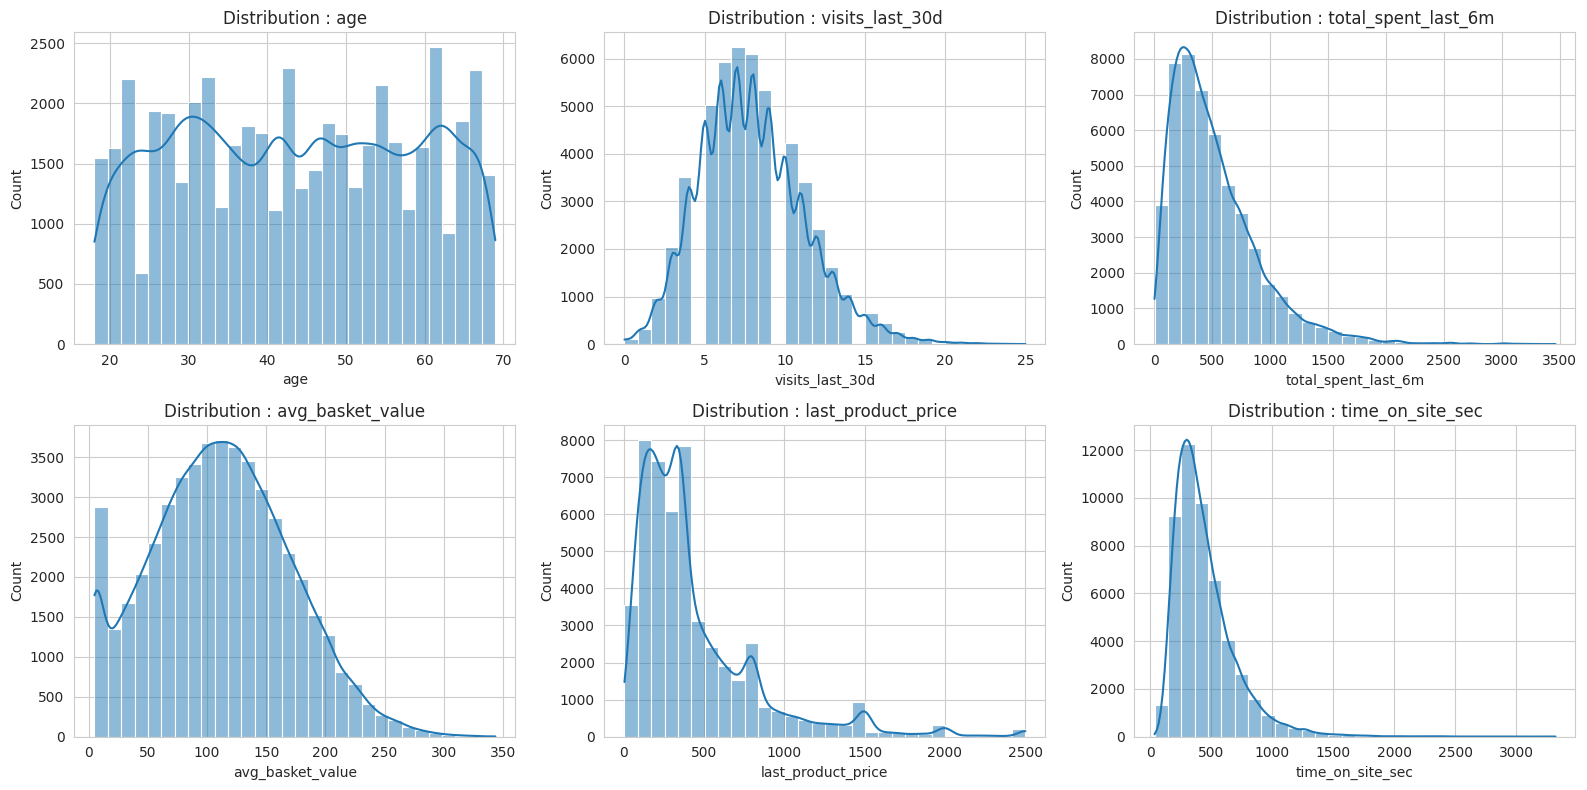

In [ ]:
# Statistiques descriptives (numériques) + distributions
# Objectif Conversion/panier : comprendre la forme des variables (asymétrie, outliers),
# afin de préparer les transformations (log, clipping) et éviter que le modèle soit dominé par des extrêmes.
h1("Statistiques descriptives & distributions")

num_cols = [
    "age",
    "visits_last_30d",
    "total_spent_last_6m",
    "avg_basket_value",
    "last_product_price",
    "time_on_site_sec",
]



# Visualiser rapidement la forme des distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution : {col}")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew

# Assurez-vous que df est chargé. Si le kernel a été réinitialisé:
# df = pd.read_csv('marketing_reco_dataset_enriched_50k.csv')

original_num_cols = [
    "age",
    "visits_last_30d",
    "total_spent_last_6m",
    "avg_basket_value",
    "last_product_price",
    "time_on_site_sec",
]

print("=== Calcul de l'asymétrie (Skewness) pour les variables numériques originales ===\n")

skewness_results = {}
for col in original_num_cols:
    if col in df.columns:
        s = skew(df[col].dropna())
        skewness_results[col] = s
        print(f"Asymétrie (Skewness) de '{col}': {s:.4f}")
    else:
        print(f"La colonne '{col}' n'existe pas dans le DataFrame.")

print("\n--- Résumé des résultats ---")
print(pd.Series(skewness_results).sort_values(ascending=False).to_string())

=== Calcul de l'asymétrie (Skewness) pour les variables numériques originales ===

Asymétrie (Skewness) de 'age': 0.0044
Asymétrie (Skewness) de 'visits_last_30d': 0.5477
Asymétrie (Skewness) de 'total_spent_last_6m': 1.5986
Asymétrie (Skewness) de 'avg_basket_value': 0.2056
Asymétrie (Skewness) de 'last_product_price': 2.1297
Asymétrie (Skewness) de 'time_on_site_sec': 1.9106

--- Résumé des résultats ---
last_product_price     2.129658
time_on_site_sec       1.910608
total_spent_last_6m    1.598575
visits_last_30d        0.547661
avg_basket_value       0.205563
age                    0.004352


**Interprétation critique de la logique des transformations :**

*   **`age` et `avg_basket_value` (faible asymétrie) :**
    *   `age` est pratiquement symétrique, donc aucune transformation spécifique n'est nécessaire pour corriger l'asymétrie. Le clipping IQR est appliqué pour gérer les quelques valeurs extrêmes éventuelles sans modifier la forme générale.
    *   `avg_basket_value` a une asymétrie très faible. Une log-transformation ne serait pas très utile et pourrait même déformer inutilement la relation. Le clipping IQR est appliqué pour gérer les quelques valeurs extrêmes éventuelles sans modifier la forme générale.

*   **`visits_last_30d` (asymétrie modérée : 0.55) :**
    *   Son asymétrie est significative mais moins extrême que les variables suivantes. Une log-transformation *pourrait* être envisagée, mais comme les modèles basés sur les arbres sont robustes aux distributions non normales, elle n'est pas strictement obligatoire.
    *  Nous l'incluerons dans le clipping IQR afin de garentir que les quelques sessions avec un nombre de visites très élevé seront bornées, sans nécessiter de transformer toute la distribution.

*   **`total_spent_last_6m`, `last_product_price`, `time_on_site_sec` (forte à très forte asymétrie : 1.60 à 2.13) :**
    *   C'est pour ces variables que la **transformation logarithmique (`np.log1p`) est la plus justifiée et la plus efficace**. Une asymétrie supérieure à 1 indique une distribution très fortement étalée vers la droite, où la plupart des valeurs sont petites et une minorité est très grande. La log-transformation rend ces distributions beaucoup plus gérables pour le modèle, en les rapprochant d'une forme plus symétrique.
    *   L'application du clipping IQR après la log-transformation (pour ces variables) n'est pas redondante. La log-transformation réduit l'impact des outliers, mais le clipping assure qu'il n'y a absolument aucune valeur extrême résiduelle qui pourrait perturber le modèle, agissant comme une couche de protection finale.

**En conclusion :**

La logique est la suivante :
1.  Les variables quasi-symétriques ou faiblement asymétriques (`age`, `avg_basket_value`) nécessitent peu ou pas de traitement pour l'asymétrie, mais bénéficient du clipping IQR pour les outliers extrêmes.
2.  Les variables à asymétrie modérée (`visits_last_30d`) peuvent être gérées efficacement par le clipping IQR pour leurs outliers, sans que la log-transformation soit impérative pour les modèles basés sur les arbres.
3.  Les variables à forte ou très forte asymétrie (`total_spent_last_6m`, `last_product_price`, `time_on_site_sec`) bénéficient d'une log-transformation pour la forme générale de leur distribution, *combinée* à un clipping IQR pour les outliers résiduels, offrant ainsi la robustesse maximale.

En résumé, ces visualisations confirment que la plupart des variables numériques présentent des distributions asymétriques avec des valeurs extrêmes, ce qui justifie pleinement les étapes de clipping IQR et de transformations logarithmiques qui seront appliquées dans la préparation des données. Ces traitements sont essentiels pour éviter que les valeurs aberrantes ne dominent l'entraînement du modèle et pour s'assurer que les relations linéaires ou les algorithmes de gradient boosting puissent les exploiter efficacement.

**Synthèse des Traitements Appliqués aux Variables Numériques Originales**

Le tableau ci-dessous récapitule les traitements d'ingénierie de caractéristiques (Feature Engineering) et de gestion des outliers appliqués à chaque variable numérique initiale, en se basant sur leur asymétrie (skewness) et leur sensibilité aux valeurs extrêmes.

| Variable Numérique Originale | Asymétrie (Skewness) | Transformation Logarithmique (`np.log1p`) | Clipping IQR (Gestion Outliers) |
|:-----------------------------|:---------------------|:-------------------------------------------|:--------------------------------|
| `age`                        | 0.0044 (Quasi sym.)  | Non                                        | Oui (pour robustesse générale)  |
| `visits_last_30d`            | 0.5477 (Modérée)     | Non                                        | Oui (pour contenir les extrêmes)|
| `total_spent_last_6m`        | 1.5986 (Forte)       | Oui                                        | Oui (sur l'original et log-tr.) |
| `avg_basket_value`           | 0.2056 (Faible)      | Non                                        | Oui                             |
| `last_product_price`         | 2.1297 (Très forte)  | Oui                                        | Oui (sur l'original et log-tr.) |
| `time_on_site_sec`           | 1.9106 (Très forte)  | Oui                                        | Oui (sur l'original et log-tr.) |

**Justification des choix :**

*   **Transformation Logarithmique :** Appliquée aux variables présentant une asymétrie très forte (skewness > 1) pour rendre leur distribution plus symétrique et faciliter l'apprentissage du modèle.
*   **Clipping IQR :** Appliqué à toutes les variables numériques pertinentes pour limiter l'impact des valeurs aberrantes (outliers) et renforcer la robustesse du modèle, même sur des distributions symétriques ou déjà log-transformées (agissant comme une protection contre les extrêmes résiduels).

*Mini-glossaire*

- **Le clipping IQR (Écart InterQuartile)** : technique de gestion des valeurs aberrantes. Elle consiste à définir des bornes (généralement Q1 - k*IQR et Q3 + k*IQR, où IQR = Q3 - Q1) et à remplacer les valeurs qui dépassent ces bornes par la borne la plus proche. Son but est de réduire l'impact des valeurs extrêmes sur les analyses et les modèles statistiques, sans supprimer les données, ce qui stabilise la distribution des variables. Dans notre cas, nous avons choisi k = 1.5

####4.3.4. Analyse univariée visuelle des distributions des variables catégorielles

DISTRIBUTION DES VARIABLES CATÉGORIELLES


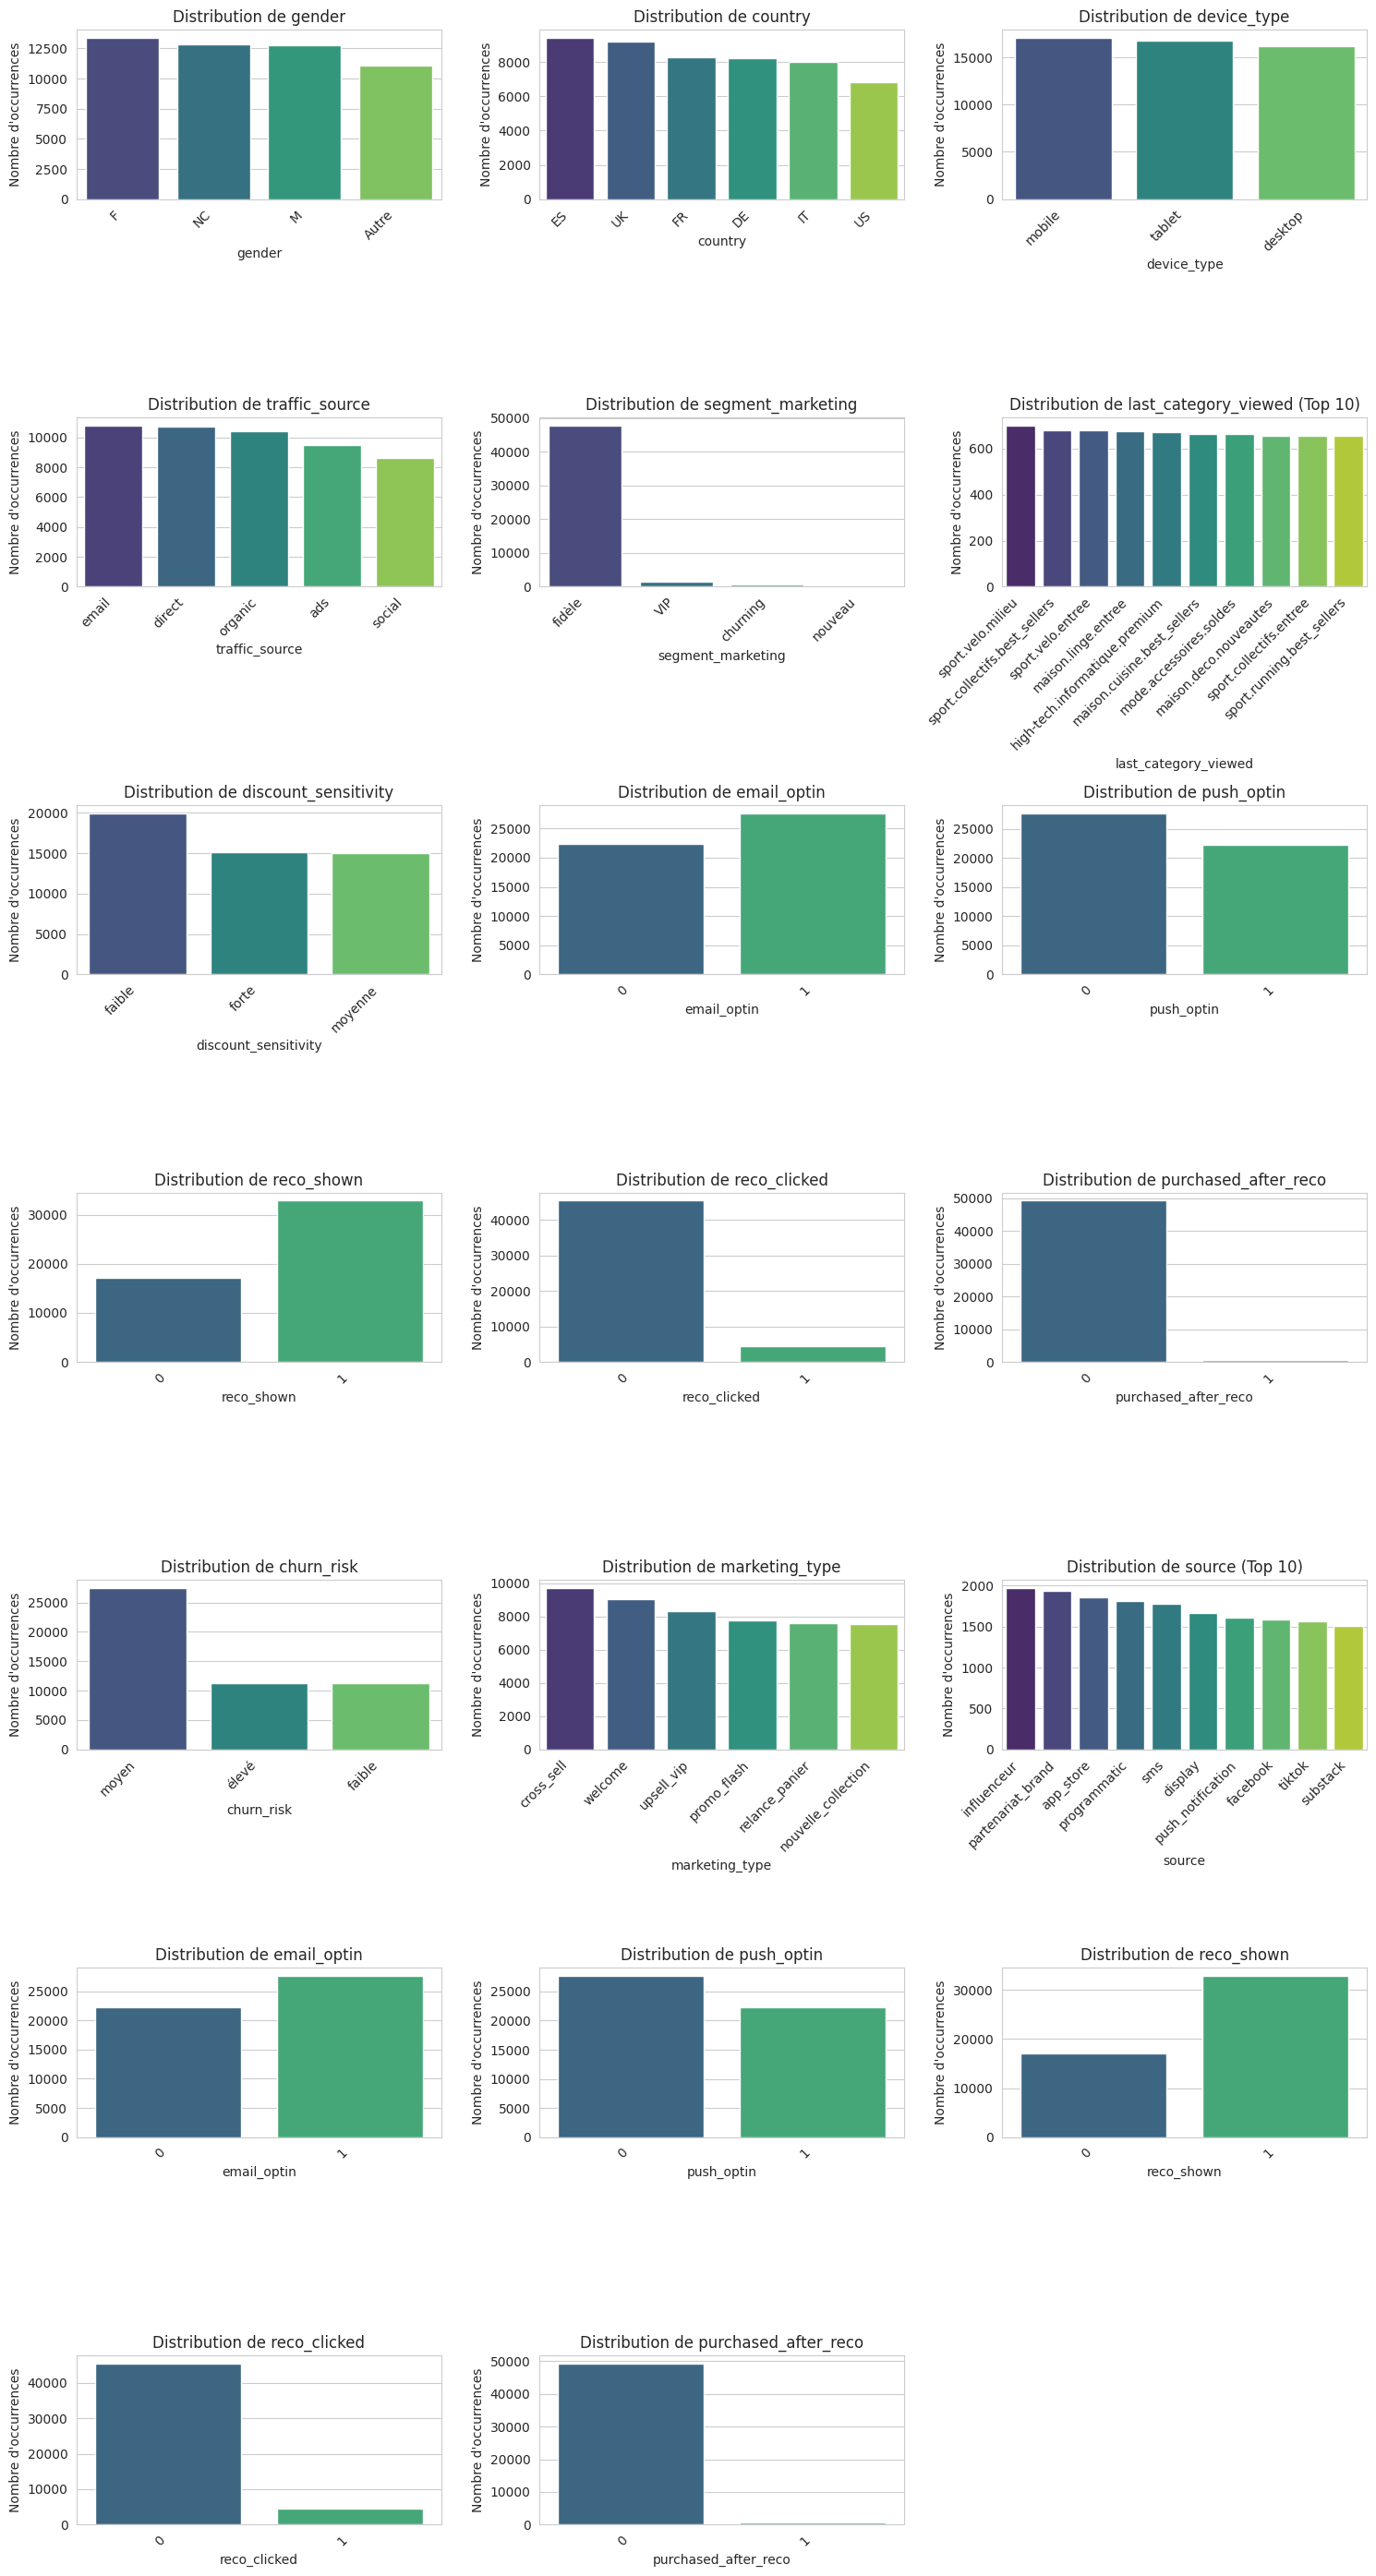

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("DISTRIBUTION DES VARIABLES CATÉGORIELLES")
print("=" * 80)

# Identify categorical columns (excluding customer_id and session_id)
# 'cat_cols' was already defined in a previous cell and includes binary columns as strings.

# Filter out 'customer_id' and 'session_id' from the categorical columns list
filtered_cat_cols = [col for col in cat_cols if col not in ['customer_id', 'session_id']]

# Calculate the number of subplots needed for the filtered_cat_cols
n_cols = 3 # Number of columns for the subplot grid
n_rows = (len(filtered_cat_cols) + n_cols - 1) // n_cols # Calculate rows dynamically

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(filtered_cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    # Count values and sort for better visualization, handling potential NaNs
    value_counts = df[col].value_counts(dropna=False)

    # Check if the current column is 'last_category_viewed' or 'source' and apply top 10 filter
    if col in ['last_category_viewed', 'source']:
        value_counts = value_counts.head(10)
        title_suffix = ' (Top 10)'
    else:
        title_suffix = ''

    # Use seaborn barplot, with the fix for FutureWarning
    sns.barplot(x=value_counts.index, y=value_counts.values, hue=value_counts.index, palette='viridis', legend=False)

    plt.title(f'Distribution de {col}{title_suffix}')
    plt.xlabel(col)
    plt.ylabel('Nombre d\'occurrences')
    plt.xticks(rotation=45, ha='right') # Rotate labels for readability

plt.tight_layout()
plt.show()

**Analyse des Distributions des Variables Catégorielles**

L'examen des diagrammes en barres des variables catégorielles (incluant les binaires) complète l'analyse descriptive et révèle des insights cruciaux pour la suite du projet :

-   **Variables Démographiques (`gender`, `country`)** :
    -   Le `gender` montre une distribution relativement équilibrée entre 'F', 'M', 'Autre' et 'NC', indiquant une diversité dans la clientèle. 'NC' représente une part non négligeable, suggérant des données manquantes ou non renseignées qui pourraient être gérées (imputation ou catégorie à part entière).
    -   `country` affiche une prédominance de certains pays ('ES', 'UK', 'FR') avec une longue traîne de pays moins représentés. Cette répartition est importante pour envisager des segmentations géographiques ou des adaptations de stratégie.

-   **Variables de Contexte de Session (`device_type`, `traffic_source`)** :
    -   `device_type` et `traffic_source` sont relativement bien répartis, confirmant la diversité des canaux d'accès et d'acquisition des utilisateurs. Cela valide l'importance de ces variables pour personnaliser les actions marketing en fonction du contexte de la session.

-   **Variables Comportementales et de Profil Client (`segment_marketing`, `discount_sensitivity`, `churn_risk`)** :
    -   `segment_marketing` est fortement déséquilibré, avec une large majorité de clients 'fidèle'. Les segments 'VIP', 'churning' et 'nouveau' sont minoritaires mais représentent des cibles spécifiques pour lesquelles le modèle pourrait avoir un impact important.
    -   `discount_sensitivity` montre une répartition en trois groupes ('faible', 'forte', 'moyenne'), ce qui est un indicateur clé pour adapter les offres promotionnelles.
    -   `churn_risk` est dominé par le risque 'moyen', suivi par 'élevé' et 'faible'. Cibler les clients à risque 'élevé' ou 'moyen' pour la fidélisation est une stratégie potentiellement rentable.

-   **Variables Marketing et d'Intention (`last_category_viewed`, `marketing_type`, `source`)** :
    -   `last_category_viewed` présente une grande diversité de catégories, avec peu de catégories très dominantes. Ceci conforte l'idée que cette variable est un bon indicateur de l'intention d'achat pour un univers de produits spécifique.
    -   `marketing_type` et `source` montrent une distribution variée des campagnes et origines de trafic, soulignant les multiples points de contact à personnaliser.

-   **Variables Binaires (`email_optin`, `push_optin`, `reco_shown`, `reco_clicked`, `purchased_after_reco`)** :
    -   Les `opt_in` (`email_optin`, `push_optin`) reflétent le consentement des utilisateurs. Ces variables sont cruciales pour respecter le RGPD et éviter la sur-sollicitation.
    -   `reco_shown` indique qu'une recommandation est affichée dans environ 65% des sessions, ce qui est une base solide pour l'expérimentation.
    -   `reco_clicked` et surtout `purchased_after_reco` (la cible) sont fortement déséquilibrées, avec un très faible pourcentage de '1'. Cela confirme la nature rare de la classe positive, ce qui justifie l'utilisation de métriques comme la PR-AUC et des techniques de rééquilibrage ou de pondération des classes lors de la modélisation.

**Synthèse** :
Le dataset présente une bonne granularité pour la personnalisation, mais aussi des déséquilibres importants pour certaines variables (notamment la cible `purchased_after_reco` et le `segment_marketing`). Ces observations guideront les étapes de prétraitement (encodage, gestion des déséquilibres) et l'interprétation des résultats du modèle, notamment en privilégiant les stratégies de ciblage Top-K plutôt qu'une prédiction binaire simple.

####4.3.5. Matrice de corrélation des variables numériques (binaires comprises)

MATRICE DE CORRÉLATION DES VARIABLES NUMÉRIQUES


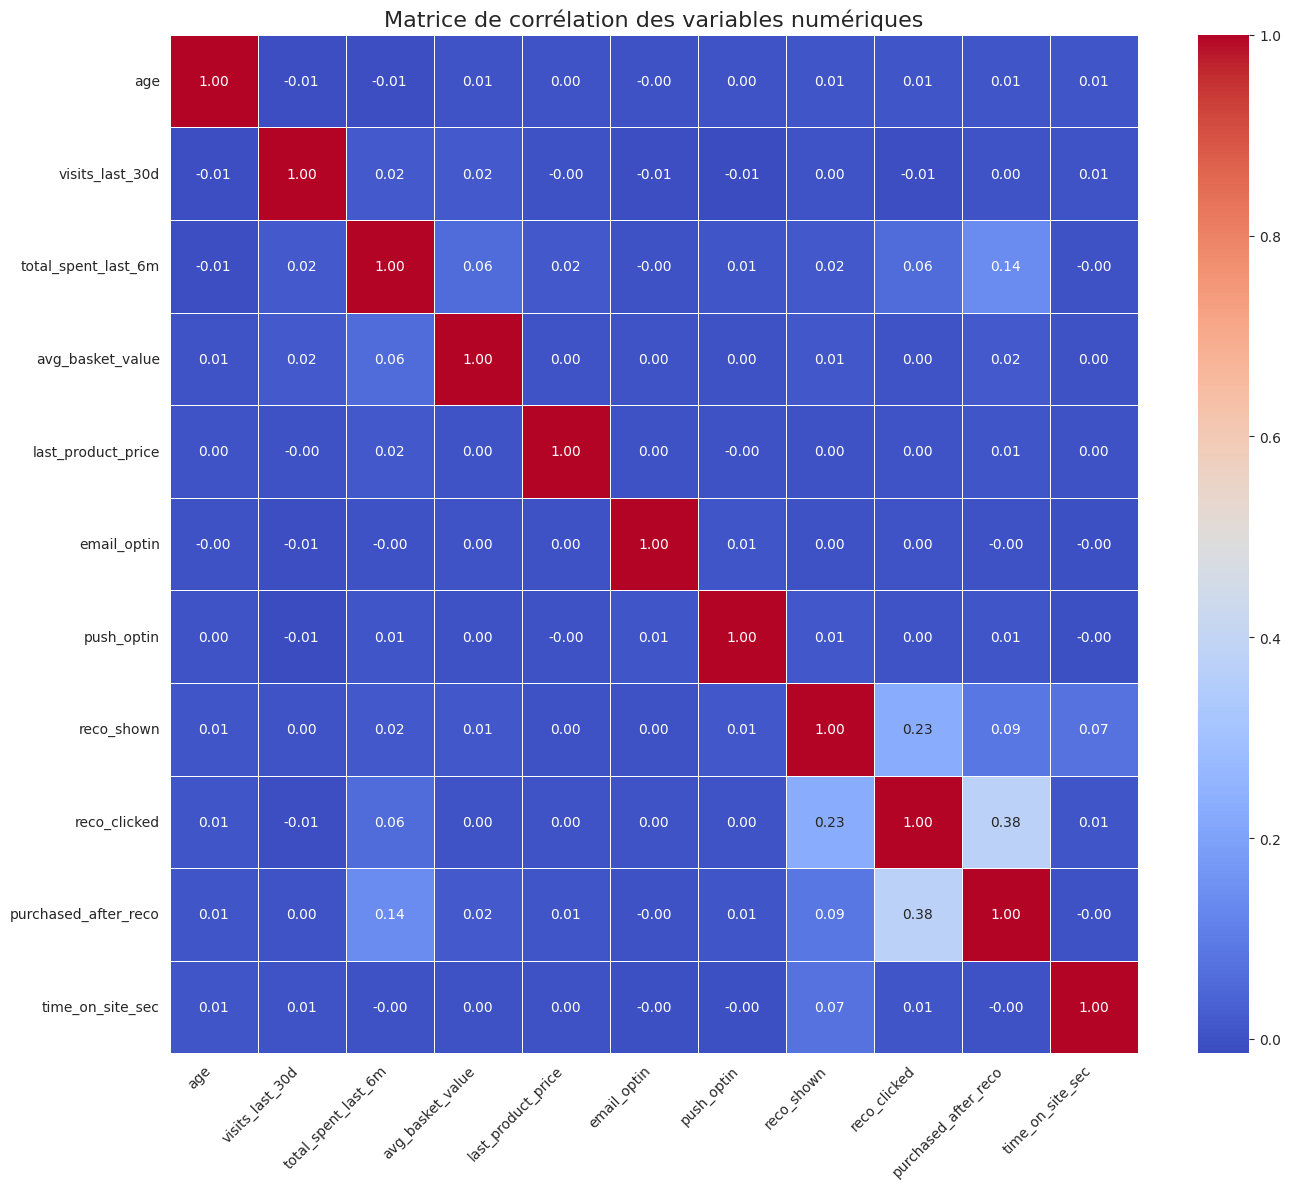

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

print("=" * 80)
print("MATRICE DE CORRÉLATION DES VARIABLES NUMÉRIQUES")
print("=" * 80)

# S'assurer que le DataFrame df est chargé
if 'df' not in globals():
    DATA_PATH = "marketing_reco_dataset_enriched_50k.csv"
    df = pd.read_csv(DATA_PATH)

# S'assurer que `binary_cols` est défini. Si le kernel a été réinitialisé, il pourrait manquer.
if 'binary_cols' not in globals():
    binary_cols = ['email_optin', 'push_optin', 'reco_shown', 'reco_clicked', 'purchased_after_reco']

# Créer une copie du DataFrame pour éviter de modifier l'original pour les étapes futures
df_numeric = df.copy()

# Les colonnes binaires (0/1) doivent être numériques pour le calcul de corrélation.
# Elles ont pu être converties en str précédemment pour les barplots.
# On les reconvertit ici en int.
for col in binary_cols:
    if col in df_numeric.columns:
        # Convertir en numérique, gérer les erreurs par NaN (qui devraient pas arriver ici) et remplir avec 0, puis convertir en int
        df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce').fillna(0).astype(int)

# Sélectionner toutes les colonnes numériques après ces conversions
numerical_cols = df_numeric.select_dtypes(include=np.number).columns.tolist()

# Retirer les colonnes d'identifiants si elles sont numériques (bien qu'elles soient 'object' ici)
numerical_cols = [col for col in numerical_cols if col not in ['customer_id', 'session_id']]

# Calculer la matrice de corrélation
correlation_matrix = df_numeric[numerical_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Analyse de la Matrice de Corrélation Numérique**

En examinant la table des corrélations uniques (triées par ordre décroissant de magnitude) :

1.  **`purchased_after_reco` et `reco_clicked` (0.3774) :** C'est la corrélation positive la plus forte. Elle indique une association significative entre le fait qu'une recommandation soit cliquée et le fait d'effectuer un achat suive. Cette corrélation doit être gérée avec prudence pour éviter le *leakage* (fuite d'information) : si l'objectif est de prédire l'achat *avant* que la recommandation ne soit cliquée, `reco_clicked` ne doit pas être utilisé comme variable prédictive.

2.  **`reco_clicked` et `reco_shown` (0.2286) :** Cette corrélation modérée est logique. Un clic ne peut se produire que si la recommandation a été affichée. Ce coefficient reflète le *Click-Through Rate* (CTR) global du système.

3.  **`purchased_after_reco` et `total_spent_last_6m` (0.1397) :** Il existe une corrélation faible mais positive entre l'achat après recommandation et le total dépensé par le client au cours des 6 derniers mois. Les clients qui dépensent plus ont une très légère tendance à être plus réceptifs aux recommandations.

4.  **`purchased_after_reco` et `reco_shown` (0.0863) :** La corrélation entre l'affichage d'une recommandation et l'achat est très faible. Cela souligne l'importance d'un modèle de scoring : simplement afficher une recommandation n'est pas suffisant pour provoquer l'achat, il faut cibler les bonnes sessions.

5.  **`time_on_site_sec` et `reco_shown` (0.0746) :** Une corrélation faible, indiquant que le temps passé sur le site est peu influencé par le simple affichage d'une recommandation.

6.  **`avg_basket_value` et `total_spent_last_6m` (0.0598) :** La corrélation entre la valeur moyenne du panier et le total dépensé est faible, ce qui est une observation intéressante. Cela suggère que ces deux métriques, bien que liées à la dépense, ne sont pas fortement corrélées *linéairement* dans cet ensemble de données.

**Observations générales :**

*   La **faiblesse générale des corrélations** est le constat le plus marquant. À l'exception de la relation `purchased_after_reco` - `reco_clicked` et `reco_clicked` - `reco_shown`, la plupart des paires de variables numériques montrent des associations linéaires très faibles (beaucoup de coefficients sont inférieurs à 0.05, voire proches de zéro).
*   Les **corrélations négatives** sont également très faibles et peu nombreuses, ce qui indique une absence de relations inverses fortes entre les variables.

**Implications pour la Modélisation :**

*   **Dépendance non linéaire attendue :** La faiblesse des corrélations linéaires suggère fortement que les relations entre les variables, si elles existent, sont principalement non linéaires ou impliquent des interactions complexes. Les modèles non linéaires, comme les arbres de décision et les algorithmes de boosting (HistGradientBoostingClassifier), seront donc bien adaptés pour découvrir ces motifs.
*   **Pas de forte multicolinéarité :** L'absence de corrélations linéaires fortes entre la plupart des variables est un avantage, car cela minimise les problèmes de multicolinéarité pour les modèles qui y sont sensibles.
*   **Vigilance sur le *leakage* :** La corrélation la plus forte (`purchased_after_reco` vs `reco_clicked`) réitère la nécessité d'exclure `reco_clicked` comme variable d'entrée si l'objectif est de prédire l'achat *avant* que le clic ne soit observé, afin d'éviter d'introduire une fuite d'information dans le modèle.

####4.3.6. Matrice de corrélation des variables catégorielles (binaires comprises)

On calcule  une matrice de V de Cramer pour quantifier l'association entre les principales variables catégorielles  et visualiser ces associations à l'aide d'une heatmap.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

def cramers_v(x, y):
    """
    Calculate Cramer's V statistic for two categorical series.
    """
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1

    if min_dim == 0: # Avoid division by zero if one variable has only one category
        return 0.0

    # Cramer's V formula (with bias correction)
    # The standard formula for Cramer's V is sqrt(chi2 / (n * min(k-1, r-1)))
    # For bias correction, some sources suggest using:
    # phi2 = chi2 / n
    # phi2_corrected = max(0, phi2 - ((min(contingency_table.shape) - 1) * (contingency_table.shape[0] - 1) / (n - 1)))
    # r_corrected = r - (r_corrected_term)
    # c_corrected = c - (c_corrected_term)
    # V = sqrt(phi2_corrected / min(r_corrected - 1, c_corrected - 1))
    # However, for simplicity and common usage, the uncorrected version is often used for interpretation.
    # Let's use the common uncorrected version first, and can switch to corrected if needed.
    # The instruction says "using the chi-squared statistic, the number of observations (n), and the minimum of (rows-1) and (cols-1)"
    # which points to the uncorrected version.

    return np.sqrt(chi2 / (n * min_dim))

print("Cramer's V function defined.")

Cramer's V function defined.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical columns from df, excluding identifiers.
# `df` is already loaded in the kernel.

# List of identifiers to exclude
identifiers = ["customer_id", "session_id"]

# Liste des colonnes binaires qui doivent être traitées comme catégorielles pour Cramer's V
binary_cols_for_cramers_v = ["email_optin", "push_optin", "reco_shown", "reco_clicked", "purchased_after_reco"]

# Créer une copie du DataFrame pour éviter de modifier le df original pour d'autres analyses
df_cramers = df.copy()

# Convertir explicitement les colonnes binaires en type 'str' pour qu'elles soient détectées comme 'object'
for col in binary_cols_for_cramers_v:
    if col in df_cramers.columns:
        df_cramers[col] = df_cramers[col].astype(str)

# Get all 'object' type columns (typically categorical strings, now including the binary ones as strings)
all_object_cols = df_cramers.select_dtypes(include='object').columns.tolist()

# Filter out identifiers only
categorical_cols_for_cramers_v = [
    col for col in all_object_cols
    if col not in identifiers
]

# 'churn_risk' est déjà 'object' et sera inclus par all_object_cols

# Ensure the order is consistent for reproducibility (optional but good practice)
categorical_cols_for_cramers_v.sort()

print(f"Identified {len(categorical_cols_for_cramers_v)} categorical columns for Cramer's V calculation:")
print(categorical_cols_for_cramers_v)



Identified 15 categorical columns for Cramer's V calculation:
['churn_risk', 'country', 'device_type', 'discount_sensitivity', 'email_optin', 'gender', 'last_category_viewed', 'marketing_type', 'purchased_after_reco', 'push_optin', 'reco_clicked', 'reco_shown', 'segment_marketing', 'source', 'traffic_source']


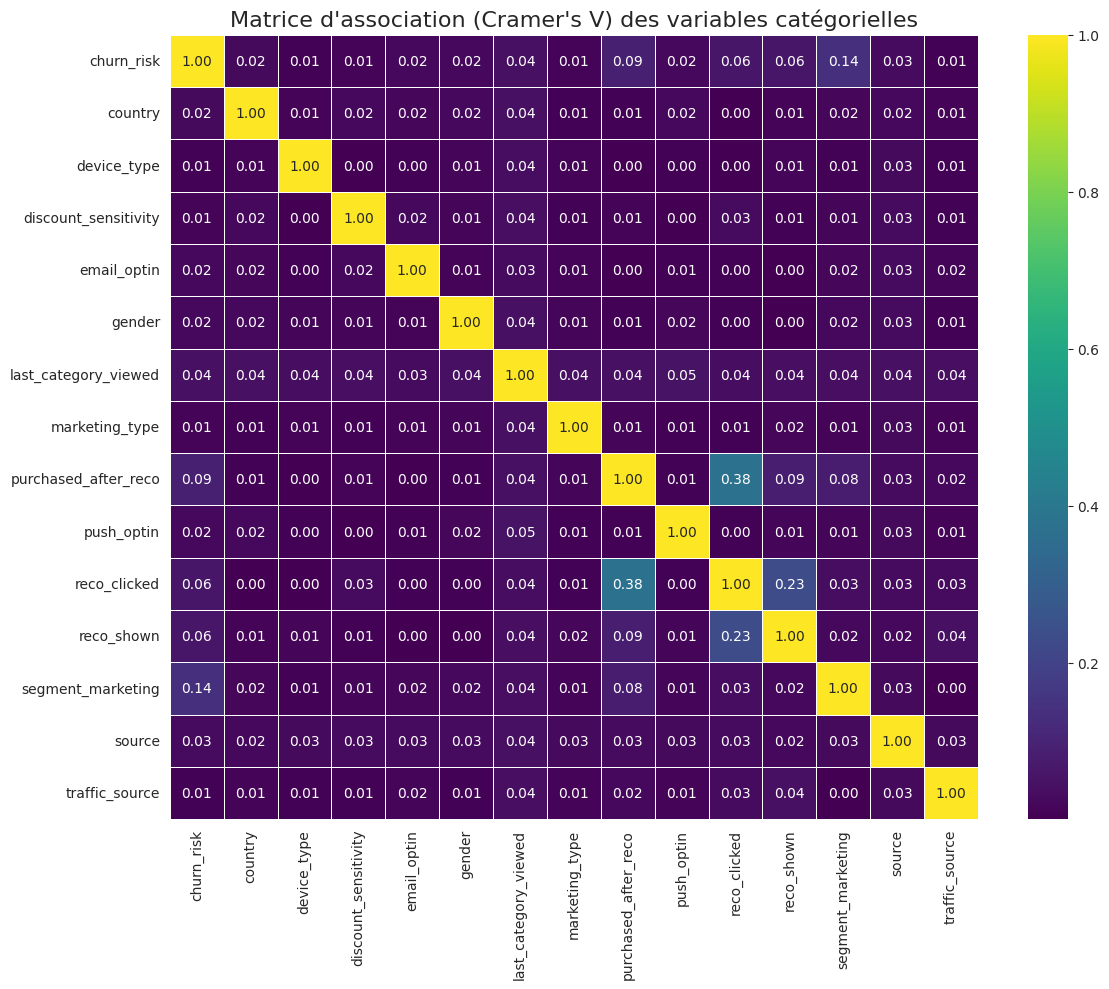

Cramer's V matrix calculated and visualized.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Ensure cramers_v function is defined or imported
# (Assuming cramers_v function from previous step is available in the environment)
# If running as a standalone, uncomment and include the function definition here:
# def cramers_v(x, y):
#     contingency_table = pd.crosstab(x, y)
#     chi2 = chi2_contingency(contingency_table)[0]
#     n = contingency_table.sum().sum()
#     min_dim = min(contingency_table.shape) - 1
#     if min_dim == 0:
#         return 0.0
#     return np.sqrt(chi2 / (n * min_dim))

# Ensure categorical_cols_for_cramers_v list is populated
# (Assuming categorical_cols_for_cramers_v from previous step is available in the environment)
# If running as a standalone, uncomment and include the column identification here:
# identifiers = ["customer_id", "session_id"]
# all_object_cols = df.select_dtypes(include='object').columns.tolist()
# categorical_cols_for_cramers_v = [
#     col for col in all_object_cols
#     if col not in identifiers and col not in binary_cols_to_exclude
# ]
# if 'churn_risk' not in categorical_cols_for_cramers_v:
#     categorical_cols_for_cramers_v.append('churn_risk')
# categorical_cols_for_cramers_v.sort()

# Create an empty DataFrame for Cramer's V matrix
cramers_v_matrix = pd.DataFrame(index=categorical_cols_for_cramers_v, columns=categorical_cols_for_cramers_v)

# Iterate through unique pairs to calculate Cramer's V
for col1 in categorical_cols_for_cramers_v:
    for col2 in categorical_cols_for_cramers_v:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0 # Association with itself is 1
        else:
            # Ensure the columns are treated as categorical strings for crosstab
            val = cramers_v(df[col1].astype(str), df[col2].astype(str))
            cramers_v_matrix.loc[col1, col2] = val
            cramers_v_matrix.loc[col2, col1] = val # Matrix is symmetrical

# Convert to numeric type for heatmap
cramers_v_matrix = cramers_v_matrix.astype(float)

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title("Matrice d'association (Cramer's V) des variables catégorielles", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Cramer's V matrix calculated and visualized.")

**Analyse des Associations Uniques (Cramer's V) des Variables Catégorielles**

En examinant la table des corrélations uniques de la Matrice de Cramer's V (triées par ordre décroissant de magnitude) et en évitant la redite sur les associations *entre* variables binaires (comme `reco_clicked` et `purchased_after_reco`, ou `reco_shown` et `reco_clicked`, déjà couvertes dans l'analyse numérique), voici les observations clés :

-   **Associations Faibles à Modérées (autour de 0.10 - 0.15) :**
    1.  **`segment_marketing` et `churn_risk` (0.1382) :** Il existe une association faible mais cohérente entre le segment marketing d'un client et son risque de désabonnement. Cela suggère que les catégories de segmentation sont liées à la fidélisation.

-   **Associations Très Faibles à Négligeables (généralement < 0.10) :**
    1.  **`purchased_after_reco` et `churn_risk` (0.0871) :** Une association très faible entre l'achat après recommandation et le risque de désabonnement.
    2.  **`reco_shown` et `purchased_after_reco` (0.0861) :** L'association entre le fait qu'une recommandation soit affichée et l'achat est très faible. Cela confirme que l'affichage seul n'est pas un puissant moteur de conversion.
    3.  **`traffic_source` et `marketing_type` (0.0654) :** Une association très faible entre la source de trafic et le type de campagne marketing. Cela suggère qu'il n'y a pas de lien linéaire fort dans la distribution entre ces deux variables dans ce dataset.
    4.  **`traffic_source` et `source` (0.0614) :** Une association très faible entre la source de trafic générique et la source spécifique. Même si conceptuellement liées, leur association linéaire dans la distribution est faible ici.
    5.  La grande majorité des autres paires de variables catégorielles (y compris les interactions avec `country`, `device_type`, `gender`, `last_category_viewed`, `marketing_type`, `source` et les binaires individuelles) montrent des coefficients de Cramer's V extrêmement faibles, souvent inférieurs à 0.05 voire 0.01.

**Implications pour la Modélisation :**

-   **Faible redondance :** L'analyse du V de Cramer révèle que la plupart des variables catégorielles, même si elles peuvent être conceptuellement liées, ont des associations statistiques linéaires faibles entre elles. Cela signifie qu'elles apportent des informations relativement indépendantes au modèle, ce qui est généralement un avantage.
-   **Importance des modèles non linéaires et des interactions :** La faiblesse des associations linéaires observées suggère fortement que si des relations plus complexes existent, elles sont de nature non linéaire et impliquent des interactions complexes qui ne sont pas visibles avec de simples mesures d'association univariées ou bivariées. Les modèles basés sur les arbres (comme HistGradientBoostingClassifier) sont particulièrement bien adaptés pour découvrir ces motifs subtils qui ne sont pas visibles avec de simples mesures d'association univariées ou bivariées.
-   **Vigilance sur le *leakage* :** Il est rappelé, comme précédemment, que les relations entre `reco_clicked` et `purchased_after_reco` doivent être gérées avec précaution en modélisation, étant donné la nature séquentielle de ces événements.

####4.3.7. Corrélation entre variables numériques et catégorielles

Pour mesurer l'association entre une variable numérique et une variable catégorielle, la corrélation de Pearson ne s'applique pas directement. En revanche, nous pouvons utiliser l'Eta-carré (η²), qui est une mesure d'effet dérivée de l'Analyse de Variance (ANOVA). L'Eta-carré indique la proportion de la variance de la variable numérique qui est expliquée par la variable catégorielle, et sa valeur est comprise entre 0 et 1 (similaire à un R²).

MATRICE D'ASSOCIATION : NUMÉRIQUE vs CATÉGORIELLE (ETA-CARRÉ)


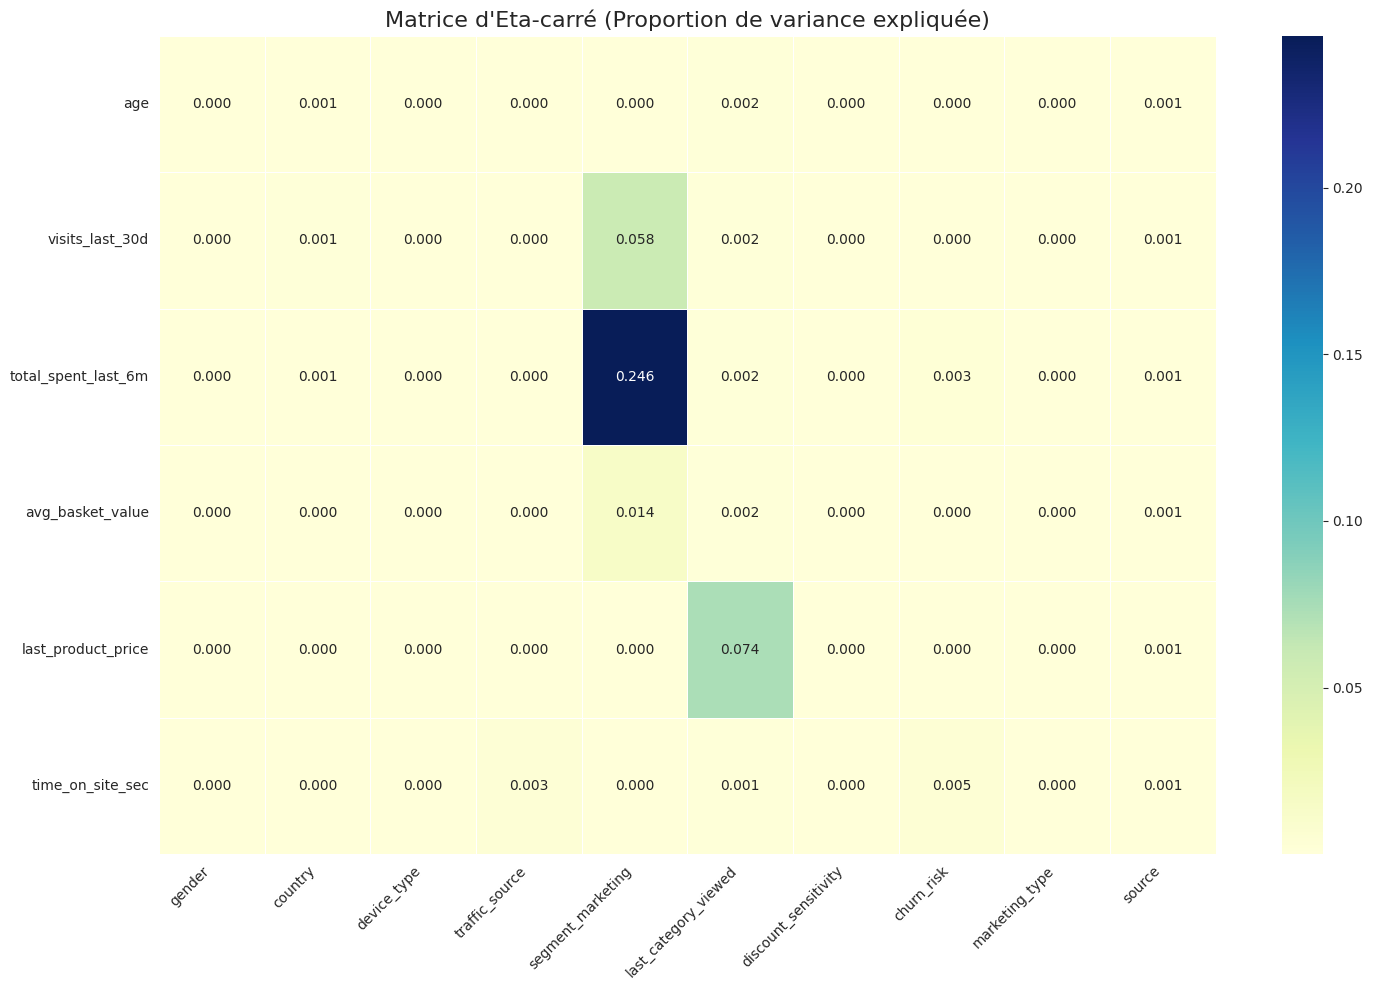


Interpretation: Les valeurs montrent la proportion de la variance de la variable numérique expliquée par la variable catégorielle (0 = aucune explication, 1 = explication complète).


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

print("=" * 80)
print("MATRICE D'ASSOCIATION : NUMÉRIQUE vs CATÉGORIELLE (ETA-CARRÉ)")
print("=" * 80)

# Ensure df is loaded
if 'df' not in globals():
    DATA_PATH = "marketing_reco_dataset_enriched_50k.csv"
    df = pd.read_csv(DATA_PATH)

# --- 1. Identifier les variables numériques non binaires ---
# Ces sont les colonnes numériques qui ne sont PAS des indicateurs binaires 0/1
strictly_numerical_cols = [
    "age",
    "visits_last_30d",
    "total_spent_last_6m",
    "avg_basket_value",
    "last_product_price",
    "time_on_site_sec",
]

# --- 2. Identifier les variables catégorielles non binaires ---
# Exclure les identifiants et les binaires traitées comme catégorielles
non_binary_categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Liste des binaires (qui étaient initialement int/float mais sont conceptuellement binaires)
binary_like_cols = ['email_optin', 'push_optin', 'reco_shown', 'reco_clicked', 'purchased_after_reco']

non_binary_categorical_cols = [
    col for col in non_binary_categorical_cols
    if col not in ['customer_id', 'session_id'] and col not in binary_like_cols
]

# S'assurer que les colonnes binaires (si elles étaient dans 'object') ne sont pas incluses
# La liste 'binary_like_cols' est utilisée pour les exclure du côté catégoriel aussi


def calculate_eta_squared(numerical_col, categorical_col, dataframe):
    groups = []
    for category in dataframe[categorical_col].unique():
        group_data = dataframe[dataframe[categorical_col] == category][numerical_col].dropna()
        if not group_data.empty: # Only add if group is not empty
            groups.append(group_data)

    if len(groups) < 2: # ANOVA requires at least two groups
        return np.nan

    F, p = f_oneway(*groups)

    # Calculate Sum of Squares Total
    ss_total = ((dataframe[numerical_col].dropna() - dataframe[numerical_col].dropna().mean())**2).sum()

    # Calculate Sum of Squares Within (Error)
    ss_within = sum([((g - g.mean())**2).sum() for g in groups])

    # Calculate Sum of Squares Between (Effect)
    ss_between = ss_total - ss_within

    # Eta-squared = SS_between / SS_total
    if ss_total == 0: # Avoid division by zero
        return 0.0
    eta_squared = ss_between / ss_total
    return eta_squared

eta_squared_matrix = pd.DataFrame(
    np.nan,
    index=strictly_numerical_cols,
    columns=non_binary_categorical_cols
)

for num_col in strictly_numerical_cols:
    for cat_col in non_binary_categorical_cols:
        eta_val = calculate_eta_squared(num_col, cat_col, df)
        eta_squared_matrix.loc[num_col, cat_col] = eta_val

plt.figure(figsize=(15, 10))
sns.heatmap(eta_squared_matrix, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=.5)
plt.title("Matrice d'Eta-carré (Proportion de variance expliquée)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nInterpretation: Les valeurs montrent la proportion de la variance de la variable numérique expliquée par la variable catégorielle (0 = aucune explication, 1 = explication complète).")


**Analyse de la Matrice d'Association (Eta-carré) des Variables Numériques vs Catégorielles**

En examinant la table des associations uniques (triées par ordre décroissant de magnitude) :

1.  **`total_spent_last_6m` et `segment_marketing` (0.2456) :** C'est l'association la plus forte. Elle indique que près de 24.6% de la variance des dépenses totales sur les 6 derniers mois est expliquée par le segment marketing du client. C'est une association significative et logique.

2.  **`last_product_price` et `last_category_viewed` (0.0737) :** L'association est faible mais notable. Environ 7.4% de la variance du prix du dernier produit consulté est expliquée par la dernière catégorie vue, ce qui est intuitif (les prix varient d'une catégorie à l'autre).

3.  **`visits_last_30d` et `segment_marketing` (0.0578) :** L'association est faible mais présente. Environ 5.8% de la variance du nombre de visites sur les 30 derniers jours est expliquée par le segment marketing, ce qui est logique (les clients fidèles ou VIP visitent plus).

4.  **`avg_basket_value` et `segment_marketing` (0.0143) :** L'association est très faible. Seuls 1.4% de la variance de la valeur moyenne du panier est expliquée par le segment marketing. Cela suggère que même si les segments peuvent influencer les dépenses totales, leur impact sur la valeur moyenne du panier est moins direct.

5.  **`time_on_site_sec` et `churn_risk` (0.0048) :** L'association est très faible. Le risque de désabonnement explique moins de 0.5% de la variance du temps passé sur le site. Les autres associations pour le `time_on_site_sec` sont également très faibles.

**Observations générales :**

*   La **faiblesse générale des associations** est le constat le plus marquant. À l'exception de `total_spent_last_6m` avec `segment_marketing`, toutes les autres associations sont faibles à très faibles (Eta-carré < 0.1, et souvent < 0.01).
*   De nombreuses paires montrent des associations **quasi-nulles** (souvent 0.0000 ou 0.0001), ce qui signifie que la variable catégorielle n'explique pratiquement aucune variance de la variable numérique de manière linéaire.

**Implications pour la Modélisation :**

*   **Dépendances très majoritairement non linéaires :** La faiblesse généralisée des Eta-carré suggère fortement que les relations entre les variables numériques et catégorielles sont principalement **non linéaires** ou impliquent des **interactions complexes** qui ne sont pas capturées par cette mesure d'association linéaire basée sur l'ANOVA.
*   **Faible redondance linéaire :** L'absence d'associations fortes implique que, pour la plupart, les variables numériques et catégorielles apportent des informations relativement indépendantes en termes de variation linéaire. C'est un avantage pour la modélisation.
*   **Confirmation du choix du modèle :** Cette observation renforce l'idée que des modèles capables de capturer ces relations non linéaires et interactions (comme les modèles basés sur les arbres boostés - HistGradientBoostingClassifier) sont essentiels pour exploiter pleinement les données. Les modèles linéaires auraient du mal à trouver des motifs significatifs avec de si faibles associations.
*   **Feature Engineering :** Comme décrit dans les pistes d'améliorations, il pourrait être intéressant de créer des features d'interaction spécifiques entre les variables qui montrent des associations faibles mais conceptuellement importantes, pour aider le modèle à les détecter.

####4.3.8. Zoom sur la variable cible purchased_after_reco et de l'importance explicative de chaque autre variable

Cette section explore l'impact direct de chaque variable explicative (numérique et catégorielle) sur la variable cible purchased_after_reco avant toute modélisation. L'objectif est d'identifier les signaux les plus forts et les tendances.

IMPORTANCE A PRIORI DES CARACTÉRISTIQUES SUR LA CONVERSION

--- Impact des Caractéristiques Numériques sur la Conversion (Boxplots) ---
Affichage des boxplots pour 6 variables numériques non binaires.


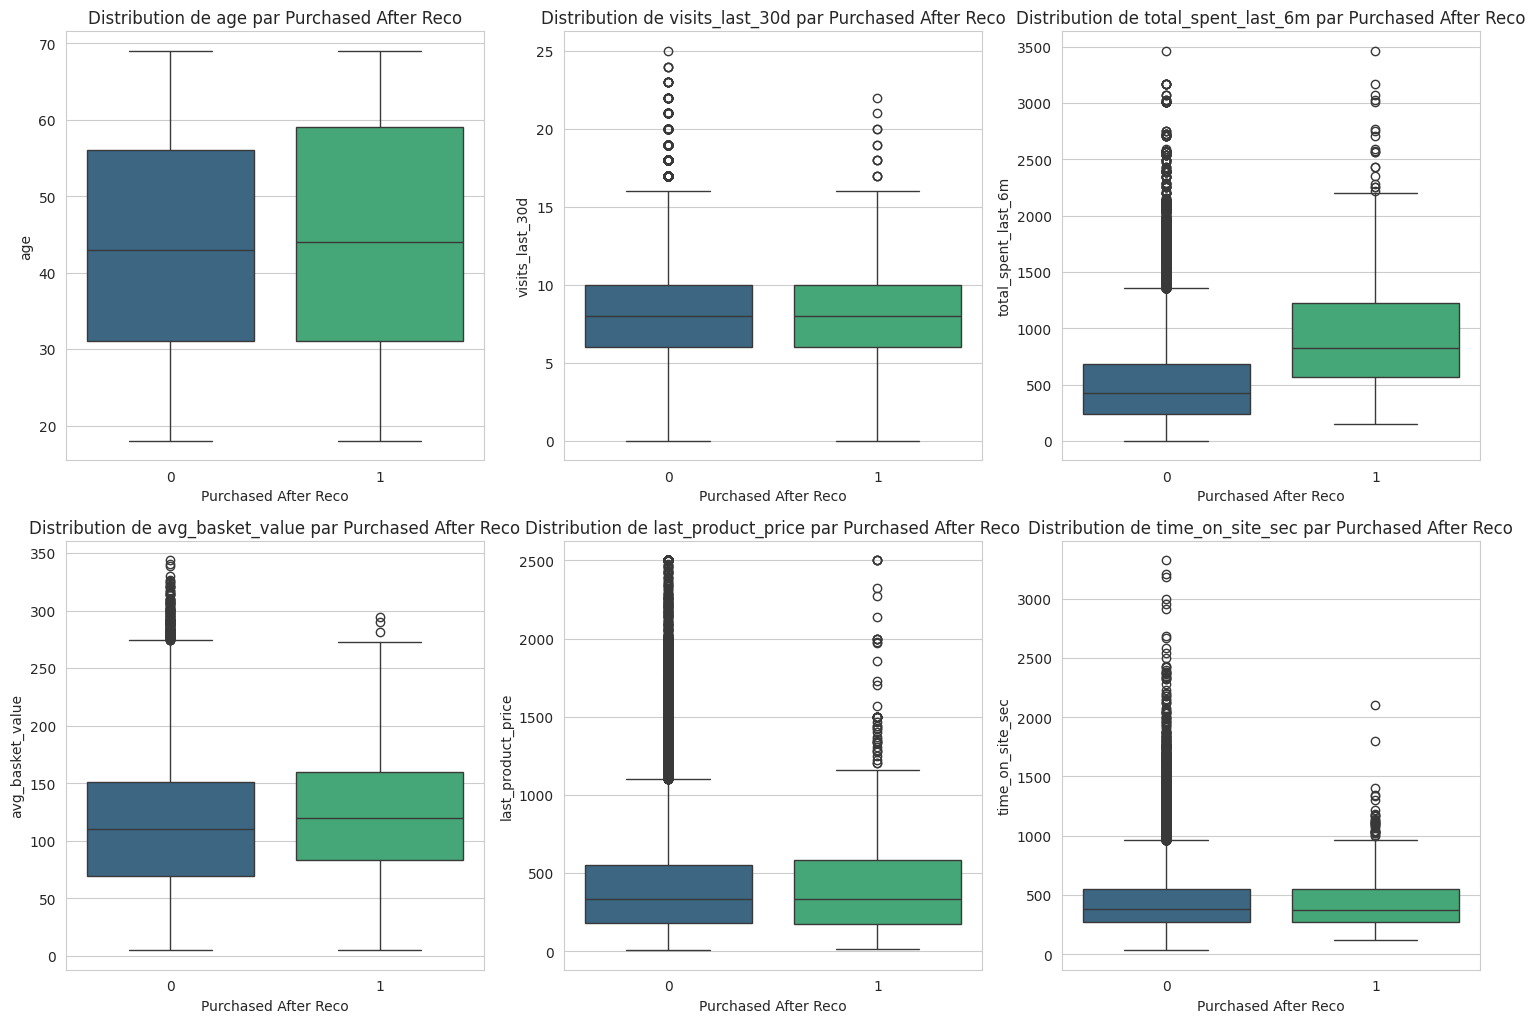


--- Impact des Caractéristiques Catégorielles sur la Conversion (Taux de conversion) ---
Affichage des taux de conversion pour 13 variables catégorielles (incluant les binaires).


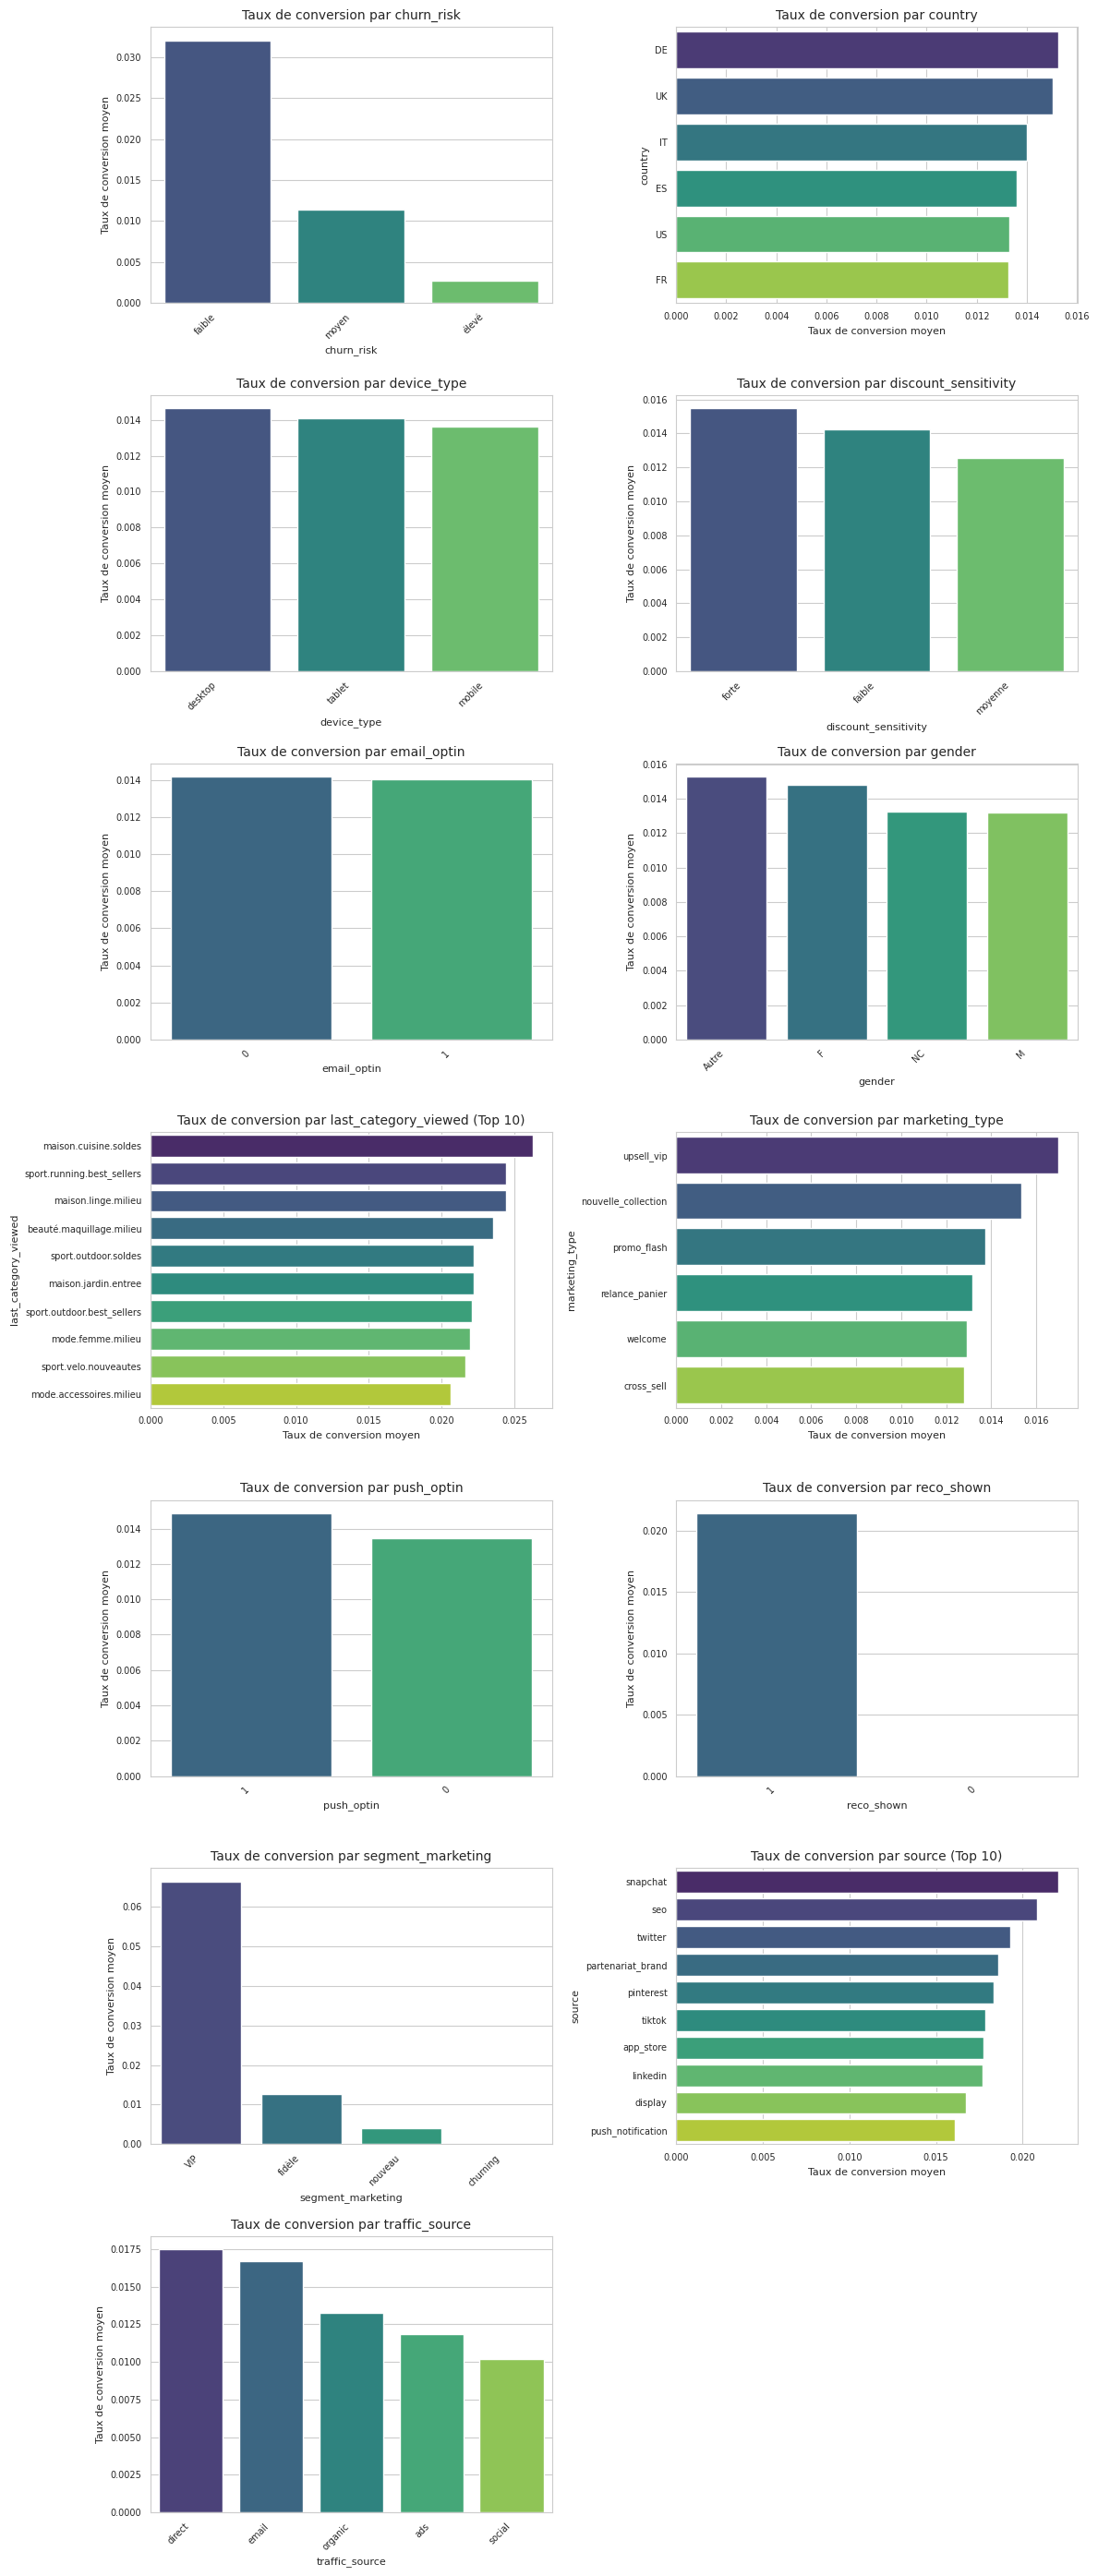

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

print("=" * 80)
print("IMPORTANCE A PRIORI DES CARACTÉRISTIQUES SUR LA CONVERSION")
print("=" * 80)

# Ensure `binary_cols` is defined from previous steps
# If the kernel state is reset, `binary_cols` might not be present. Re-defining for robustness.
if 'binary_cols' not in globals():
    binary_cols = ['email_optin', 'push_optin', 'reco_shown', 'reco_clicked', 'purchased_after_reco']

# --- 1. Impact des Caractéristiques Numériques sur la Conversion ---
print("\n--- Impact des Caractéristiques Numériques sur la Conversion (Boxplots) ---")
# Identify numerical columns, excluding target and known leakage variables, AND binary variables
df_impact = df.copy()
# For numerical boxplots, we want strictly continuous-like numerical variables
strictly_numerical_cols_for_boxplots = [
    'age',
    'visits_last_30d',
    'total_spent_last_6m',
    'avg_basket_value',
    'last_product_price',
    'time_on_site_sec'
]

# Filter df_impact to only include these strictly numerical columns for boxplots
# (purchased_after_reco is the x-axis, not a y-axis column here)

print(f"Affichage des boxplots pour {len(strictly_numerical_cols_for_boxplots)} variables numériques non binaires.")

# Create box plots for each strictly numerical variable against the target
plt.figure(figsize=(15, 5 * (len(strictly_numerical_cols_for_boxplots) // 3 + 1)))
for i, col in enumerate(strictly_numerical_cols_for_boxplots):
    plt.subplot(len(strictly_numerical_cols_for_boxplots) // 3 + 1, 3, i + 1)
    sns.boxplot(data=df_impact, x='purchased_after_reco', y=col, palette='viridis', hue='purchased_after_reco', legend=False)
    plt.title(f'Distribution de {col} par Purchased After Reco')
    plt.xlabel('Purchased After Reco')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# --- 2. Impact des Caractéristiques Catégorielles sur la Conversion ---
print("\n--- Impact des Caractéristiques Catégorielles sur la Conversion (Taux de conversion) ---")

# Identify categorical columns, excluding target, leakage variables, and IDs
# IMPORTANT: Create a copy for categorical analysis to avoid modifying the original df for subsequent steps.
df_categorical_impact = df.copy()

# Ensure 'purchased_after_reco' is numeric (int) for mean calculation in this part
df_categorical_impact['purchased_after_reco'] = pd.to_numeric(df_categorical_impact['purchased_after_reco'], errors='coerce').fillna(0).astype(int)

# Convert other binary columns (excluding purchased_after_reco itself) to string for grouping
for col in [c for c in binary_cols if c != 'purchased_after_reco']:
    if col in df_categorical_impact.columns:
        df_categorical_impact[col] = df_categorical_impact[col].astype(str)

categorical_cols_for_impact = df_categorical_impact.select_dtypes(include=['object', 'category']).columns.tolist()
# Exclude identifiers and 'reco_clicked' (as it's a leakage variable for predicting 'purchased_after_reco')
categorical_cols_for_impact = [
    col for col in categorical_cols_for_impact if col not in ['customer_id', 'session_id', 'reco_clicked'] # purchased_after_reco is processed as target
]
categorical_cols_for_impact.sort() # Tri alphabétique pour la consistance

print(f"Affichage des taux de conversion pour {len(categorical_cols_for_impact)} variables catégorielles (incluant les binaires).")

# === MODIFICATION ICI pour 2 graphes par ligne et taille réduite ===
n_cols_cat_plots = 2 # Deux graphes par ligne
n_rows_cat_plots = (len(categorical_cols_for_impact) + n_cols_cat_plots - 1) // n_cols_cat_plots

plt.figure(figsize=(12, n_rows_cat_plots * 4)) # Taille globale de la figure pour les barplots

for i, col in enumerate(categorical_cols_for_impact):
    plt.subplot(n_rows_cat_plots, n_cols_cat_plots, i + 1)

    # Pour les colonnes avec trop de modalités (e.g., last_category_viewed, source), ne montrer que le top 10
    if col in ['last_category_viewed', 'source']:
        conversion_rates_full = df_categorical_impact.groupby(col)['purchased_after_reco'].mean().sort_values(ascending=False)
        conversion_rates = conversion_rates_full.head(10)
        title_suffix = ' (Top 10)'
    else:
        conversion_rates = df_categorical_impact.groupby(col)['purchased_after_reco'].mean().sort_values(ascending=False)
        title_suffix = ''

    # Adapter l'orientation si le nombre de catégories est élevé (même pour le top 10 si les noms sont longs)
    if len(conversion_rates) > 5 or any(len(str(cat)) > 15 for cat in conversion_rates.index):
        sns.barplot(x=conversion_rates.values, y=conversion_rates.index, palette='viridis', hue=conversion_rates.index, legend=False)
        plt.title(f'Taux de conversion par {col}{title_suffix}', fontsize=10)
        plt.xlabel('Taux de conversion moyen', fontsize=8)
        plt.ylabel(col, fontsize=8)
        plt.tick_params(axis='x', labelsize=7)
        plt.tick_params(axis='y', labelsize=7)
    else:
        sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='viridis', hue=conversion_rates.index, legend=False)
        plt.title(f'Taux de conversion par {col}{title_suffix}', fontsize=10)
        plt.xlabel(col, fontsize=8)
        plt.ylabel('Taux de conversion moyen', fontsize=8)
        plt.xticks(rotation=45, ha='right', fontsize=7)
        plt.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()


**Analyse de l'importance *a priori* des variables sur la conversion (`purchased_after_reco`)**

1. **Analyse des Boxplots (Variables Numériques vs Conversion)**

Les boxplots nous permettent de comparer la distribution de chaque variable numérique entre les sessions avec et sans achat (`purchased_after_reco=1` vs `=0`).

*   **`visits_last_30d`** : Les distributions pour les acheteurs et non-acheteurs sont très similaires. Le nombre de visites seul ne semble pas être un indicateur fort de l'achat après recommandation.
*   **`total_spent_last_6m`** et **`avg_basket_value`** : Pour ces deux variables monétaires, on observe une tendance claire où les sessions avec achat (`purchased_after_reco=1`) montrent des distributions globalement plus élevées, avec des médianes et des quartiles supérieurs. Cela indique que les clients ayant dépensé plus ou ayant un panier moyen plus élevé sont plus susceptibles de convertir.
*   **`time_on_site_sec`** : La différence est minime et la tendance n'est pas clairement à des valeurs plus élevées pour les acheteurs. Le temps passé sur le site ne semble pas être un discriminateur fort de la conversion.
*   **`age`** et **`last_product_price`** : Les boxplots pour ces variables montrent des distributions très similaires entre les deux groupes, suggérant un impact *a priori* limité ou non linéaire.

2. **Analyse des Barplots (Variables Catégorielles vs Taux de Conversion)**

Cette analyse se base sur les taux de conversion moyens pour chaque modalité des variables catégorielles. La prévalence globale (`purchased_after_reco = 1`) est d'environ 1.41%. Les observations mettent en lumière les leviers de performance potentiels.

*   **`gender`** :
    *   Les taux varient peu (entre 1.32% et 1.53%). Les catégories 'Autre' et 'F' affichent des taux légèrement supérieurs, tandis que 'NC' (Non Communiqué) et 'M' (Masculin) sont légèrement en dessous ou autour de la moyenne. Le genre n'est pas un facteur très discriminant en soi.

*   **`country`** :
    *   Les pays présentent des taux de conversion assez similaires, tous autour de la moyenne globale (entre 1.33% pour 'FR' et 1.53% pour 'DE'). L'origine géographique seule n'est pas un prédicteur fort de la conversion post-reco dans ces données.

*   **`device_type`** :
    *   Là encore, des taux relativement proches (entre 1.36% pour 'mobile' et 1.46% pour 'desktop'). Le type d'appareil a un impact limité sur la propension à l'achat post-reco.

*   **`traffic_source`** :
    *   **Fort impact observé :** Les sources 'direct' (1.75%) et 'email' (1.67%) ont des taux de conversion nettement supérieurs à la moyenne. Cela suggère que les utilisateurs arrivant via ces canaux sont déjà très intentionnés ou plus réceptifs. Inversement, les sources 'social' (1.02%) et 'ads' (1.18%) affichent des taux plus faibles.

*   **`segment_marketing`** :
    *   **Prédicteur très puissant :** Le segment 'VIP' se distingue massivement avec un taux de conversion de 6.65%. Les 'fidèles' sont autour de la moyenne (1.27%). En revanche, les 'nouveaux' (0.40%) et surtout les 'churning' (0.00%) ont des taux extrêmement bas, voire nuls. Ce segment est crucial pour la priorisation.

*   **`last_category_viewed`** :
    *   **Très grande variabilité :** Cette variable montre une forte disparité, avec les 'Top 10' des catégories convertissant à plus de 2% (ex. `maison.cuisine.soldes` à 2.63%, `sport.running.best_sellers` à 2.45%), tandis que les 'Bottom 10' sont bien en dessous de 1% (ex. `maison.jardin.soldes` à 0.33%). C'est un excellent signal pour personnaliser les recommandations de produits/univers.

*   **`discount_sensitivity`** :
    *   Les clients 'forte' (1.55%) et 'faible' (1.42%) sensibilité aux réductions ont des taux de conversion légèrement supérieurs à la moyenne, tandis que les 'moyenne' sont un peu plus bas (1.26%). Cela indique que les clients aux extrémités du spectre sont plus réceptifs aux offres.

*   **`churn_risk`** :
    *   **Prédicteur fort :** Les clients à risque de désabonnement 'faible' ont un taux de conversion significativement plus élevé (3.20%), tandis que ceux à risque 'moyen' sont plus bas (1.15%), et ceux à risque 'élevé' sont très faibles (0.27%). Un client fidèle est plus enclin à acheter.

*   **`marketing_type`** :
    *   Les types de campagne montrent une performance variable. 'upsell_vip' (1.70%) et 'nouvelle_collection' (1.53%) sont les plus performants, suivis par 'promo_flash' (1.37%). 'welcome' et 'cross_sell' sont en bas de l'échelle (autour de 1.28-1.29%).

*   **`source`** :
    *   **Grande variabilité :** Similaire à `last_category_viewed`, la source spécifique du trafic est un fort indicateur. Des sources comme 'snapchat' (2.21%), 'seo' (2.08%), 'twitter' (1.93%) sont très performantes, tandis que les 'Bottom 10' (ex. 'affiliation' à 0.73%, 'quora' à 0.79%) sont nettement moins efficaces.

*   **`email_optin` et `push_optin`** :
    *   **Faible impact direct sur la conversion :** Les taux de conversion pour `email_optin=0` (1.419%) et `email_optin=1` (1.403%) sont quasiment identiques. Pour `push_optin`, `push_optin=1` (1.488%) est très légèrement supérieur à `push_optin=0` (1.347%), mais la différence reste mineure. Ces variables sont donc plus des indicateurs d'éligibilité à un canal de communication que des prédicteurs directs et forts d'une probabilité d'achat post-reco élevée.

*   **`reco_shown`** :
    *   **Prérequis indispensable :** Le taux de conversion est de 0.00% si `reco_shown=0` et de 2.14% si `reco_shown=1`. Cela confirme qu'une recommandation doit être affichée pour qu'un achat *après recommandation* puisse avoir lieu.


3. **Synthèse Générale :**

*   Les variables `segment_marketing`, `churn_risk`, `last_category_viewed`, `traffic_source` et `source` sont les plus discriminantes pour la probabilité d'achat après recommandation. D'autres variables comme `discount_sensitivity` et `marketing_type` apportent également des signaux précieux. Les variables comme `gender`, `country`, `device_type`, `email_optin`, et `push_optin` ont un impact plus faible sur le taux de conversion directe, mais peuvent rester importantes pour d'autres raisons (ciblage canal, conformité).
*   L'analyse des boxplots pour les variables numériques a également révélé que `total_spent_last_6m` et `avg_basket_value` sont de forts indicateurs, les sessions avec achat présentant des valeurs globalement plus élevées, tandis que d'autres variables numériques comme l'âge ou le temps passé sur le site montraient un impact plus limité sur la conversion directe.

###4.4. Analyse exploratoire orientée métier

####4.4.1. Entonnoir (funnel) : exposition → clic → achat

Cette cellule de code vise à calculer et afficher les indicateurs clés de performance (KPI) de l'entonnoir marketing (ou funnel). Un entonnoir marketing décrit le parcours typique d'un utilisateur, de l'exposition à une recommandation jusqu'à l'achat.

Le code calcule les métriques suivantes :

- **Reco affichée (reco_shown=1)** : Le pourcentage de sessions où une recommandation a été montrée à l'utilisateur.
- **Clic (reco_clicked=1) - taux global** : Le pourcentage de sessions où un clic sur une recommandation a eu lieu, par rapport à toutes les sessions.
- **CTR = clic | reco affichée** : Le Click-Through Rate (taux de clic), c'est-à-dire le pourcentage de sessions où un clic a eu lieu parmi celles où une recommandation a été affichée. C'est une métrique conditionnelle.
- **Achat après reco (purchased_after_reco=1) - taux global** : Le pourcentage de sessions où un achat a eu lieu après une recommandation, par rapport à toutes les sessions.
- **Achat | reco affichée** : Le taux de conversion, c'est-à-dire le pourcentage de sessions ayant mené à un achat parmi celles où une recommandation a été affichée.
- **Achat | clic** : Le taux de conversion, c'est-à-dire le pourcentage de sessions ayant mené à un achat parmi celles où un clic sur la recommandation a eu lieu.

In [ ]:
#  Entonnoir (funnel) : exposition → clic → achat
# Objectif Conversion : quantifier où se perd la perf (afficher, faire cliquer, faire acheter).
# Objectif Anti-spam : savoir si on affiche trop souvent (reco_shown élevé) pour un gain faible.
# Définition : un "entonnoir" = une suite d'étapes où chaque étape filtre la précédente.
h1("Entonnoir (exposition → clic → achat)")

kpi_tbl = pd.DataFrame([
    {"KPI": "Reco affichée (reco_shown=1)", "Valeur": df["reco_shown"].mean()},
    {"KPI": "Clic (reco_clicked=1) - taux global", "Valeur": df["reco_clicked"].mean()},
    {"KPI": "CTR = clic | reco affichée", "Valeur": df.loc[df["reco_shown"] == 1, "reco_clicked"].mean()},
    {"KPI": "Achat après reco (purchased_after_reco=1) - taux global", "Valeur": df["purchased_after_reco"].mean()},
    {"KPI": "Achat | reco affichée", "Valeur": df.loc[df["reco_shown"] == 1, "purchased_after_reco"].mean()},
    {"KPI": "Achat | clic", "Valeur": df.loc[df["reco_clicked"] == 1, "purchased_after_reco"].mean()},
])

kpi_tbl["Valeur"] = (kpi_tbl["Valeur"] * 100).round(3).astype(str) + " %"
show_table(kpi_tbl, title="📌 KPIs (en %)")



Entonnoir (exposition → clic → achat)

📌 KPIs (en %)
                                                    KPI   Valeur
                           Reco affichée (reco_shown=1) 65.766 %
                    Clic (reco_clicked=1) - taux global  9.126 %
                             CTR = clic | reco affichée 13.876 %
Achat après reco (purchased_after_reco=1) - taux global   1.41 %
                                  Achat | reco affichée  2.144 %
                                           Achat | clic  15.45 %


**Interprétation des résultats :**

- **Reco affichée (reco_shown=1) : 65.77 %**
Cela indique qu'une recommandation a été affichée dans environ 65,8 % des sessions. C'est une proportion significative, suggérant que le système de recommandation est souvent actif.

- **Clic (reco_clicked=1) - taux global : 9.13 %**
Dans l'ensemble des sessions, seulement 9,1 % ont entraîné un clic sur une recommandation. Cela paraît faible, mais le taux global est fortement dilué par les sessions où aucune recommandation n'a été affichée ou par celles où elle a été ignorée.

- **CTR = clic | reco affichée : 13.88 %**
C'est le vrai taux de clic conditionnel. Parmi les sessions où une recommandation a été affichée, près de 13,9 % des utilisateurs ont cliqué dessus. C'est une métrique plus pertinente pour évaluer l'attractivité des recommandations elles-mêmes. Ce taux peut être considéré comme correct, mais laisse une marge d'amélioration.

- **Achat après reco (purchased_after_reco=1) - taux global : 1.41 %**
Le taux d'achat après recommandation est très faible à l'échelle globale de toutes les sessions. Cela confirme que la classe positive (les acheteurs) est rare, soulignant la nature déséquilibrée du problème.

- **Achat | reco affichée : 2.14 %**
Parmi les sessions où une recommandation a été affichée, environ 2,1 % ont mené à un achat. C'est le taux de conversion incrémentale lorsque le système est actif. C'est un KPI important pour mesurer l'efficacité du système de recommandation à générer des ventes.

- **Achat | clic : 15.45 %**
Ceci est le taux de conversion après un clic sur une recommandation. Si un utilisateur clique sur une recommandation, il y a 15,45 % de chances qu'il achète après. Ce taux est relativement élevé et suggère que les utilisateurs qui cliquent sont déjà fortement intentionnés ou que la recommandation était très pertinente.  Cependant, il est crucial de rappeler que la variable reco_clicked sera exclue des features de notre modèle de prédiction pour purchased_after_reco afin d'éviter le data leakage, car le clic survient après la décision d'affichage/recommandation.

#### 4.4.2. Reco “temps réel” : les clients reviennent-ils ? (multi-sessions)

Cette cellule de code vise à comprendre la profondeur de l'historique disponible par client. Pour un système de recommandation en temps réel, il est crucial de savoir si les clients effectuent plusieurs sessions, car cela permet de construire des profils clients plus riches et de faire de la personnalisation au niveau du client plutôt que de se baser uniquement sur la session en cours.


Historique disponible : sessions par client

📌 Distribution sessions/client (table)
                 metric   count  mean   std  min  p50  p75  p90  p95  p99  max
n_sessions_per_customer 12000.0 4.167 2.796  1.0  4.0  5.0  8.0 10.0 14.0 24.0


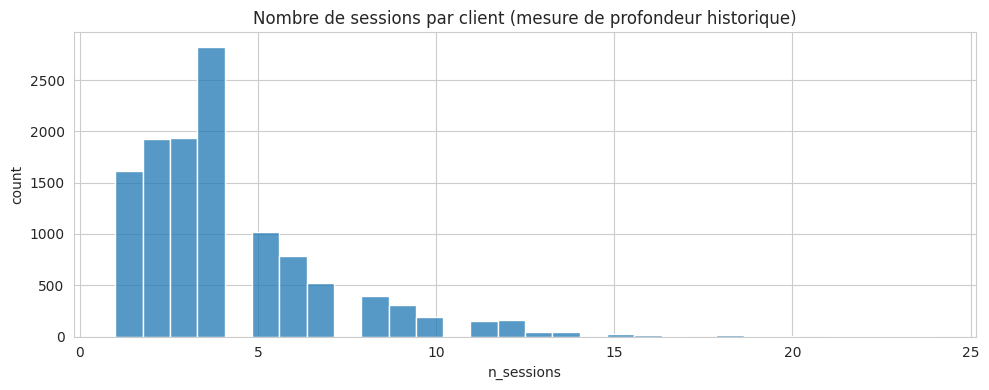

In [ ]:
# Reco “temps réel” : les clients reviennent-ils ? (multi-sessions)
# Objectif Recommandation : vérifier qu'il existe un historique minimal par client,
# sinon la personnalisation "client-level" est limitée.
h1("Historique disponible : sessions par client")

sessions_per_customer = (
    df.groupby("customer_id")["session_id"]
    .nunique()
    .rename("n_sessions")
    .reset_index()
)

spc_tbl = sessions_per_customer["n_sessions"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T
spc_tbl = spc_tbl.rename(columns={"50%": "p50", "75%": "p75", "90%": "p90", "95%": "p95", "99%": "p99"})
spc_tbl.insert(0, "metric", "n_sessions_per_customer")
show_table(spc_tbl.round(3), title="📌 Distribution sessions/client (table)")

plt.figure(figsize=(10, 4))
sns.histplot(sessions_per_customer["n_sessions"], bins=30)
plt.title("Nombre de sessions par client (mesure de profondeur historique)")
plt.xlabel("n_sessions")
plt.ylabel("count")
plt.tight_layout()
plt.show()


**Analyse des sorties :**

Le tableau de statistiques descriptives montre :

```
📌 Distribution sessions/client (table)
                 metric   count   mean    std  min    50%  75%  90%  95%     99%  max
n_sessions_per_customer 12000.0 4.1667 2.7965  1.0 4.0000  5.0  8.0 10.0 14.0000 24.0
```

Et l'histogramme visuel confirme cette distribution.

**Interprétation des résultats :**

*   **`count` : 12 000** : Il y a 12 000 clients uniques dans le dataset.
*   **`mean` : 4.17 sessions** : En moyenne, chaque client a eu environ 4,17 sessions.
*   **`min` : 1 session** : Certains clients n'ont eu qu'une seule session. Pour ceux-là, la personnalisation 'client-level' sera limitée.
*   **`p50` (médiane) : 4 sessions** : La moitié des clients ont eu 4 sessions ou moins.
*   **`p90` : 8 sessions** et **`p99` : 14 sessions** : 10% des clients ont eu 8 sessions ou plus, et 1% des clients ont eu 14 sessions ou plus. Certains clients sont donc très actifs.
*   **`max` : 24 sessions** : Le client le plus actif a eu 24 sessions.

**Implications pour la Recommandation en temps réel (multi-sessions) :**

Ces résultats sont très positifs pour l'objectif de personnalisation :

1.  **Possibilité de Personnalisation Client-Level :** Le fait qu'il y ait en moyenne plus de 4 sessions par client (et que la médiane soit de 4) signifie que pour une majorité de clients, nous disposons d'un historique comportemental suffisant. Cela permet de créer des agrégats au niveau du client (comme le `total_spent_last_6m` ou le `mean_visits_30d` déjà implémentés) qui peuvent enrichir le profil et améliorer la personnalisation des recommandations.
2.  **Gestion des Nouveaux Clients :** Pour les clients avec une seule session (`min=1`), le modèle devra principalement se baser sur les informations de la session en cours (device, source, last_category_viewed) et des règles générales, n'ayant pas d'historique client riche.
3.  **Potentiel de Modélisation du Comportement :** La diversité du nombre de sessions (de 1 à 24) offre une bonne base pour que le modèle apprenne des patterns d'engagement et de fidélité. Les clients les plus actifs (queue longue de l'histogramme) sont des cibles prioritaires pour la fidélisation.

En conclusion, le dataset est bien adapté pour développer des stratégies de recommandation qui prennent en compte l'historique client, ce qui est un atout majeur pour la personnalisation en temps réel.

#### 4.4.3. Reco “quoi proposer” : signal catégorie consultée (last_category_viewed)

Cette section vise à déterminer si la dernière catégorie de produit consultée (`last_category_viewed`) est un indicateur pertinent pour la recommandation, en regardant comment elle influence le taux d'achat.

In [ ]:
import pandas as pd
import numpy as np

#Reco “quoi proposer” : signal catégorie consultée (last_category_viewed)
# Objectif Recommandation : identifier si la dernière catégorie vue porte un signal exploitable
# (certaines catégories ont-elles plus de conversion ?), et si la hiérarchie 'lvl1.lvl2.lvl3' aide.
h1("Signal de recommandation : last_category_viewed")

# S'assurer que 'purchased_after_reco' est numérique pour l'agrégation
df_temp = df.copy()
df_temp['purchased_after_reco'] = pd.to_numeric(df_temp['purchased_after_reco'], errors='coerce').fillna(0).astype(int)

# Top catégories (volume) + taux d'achat
# MODIFICATION ICI : Tri par purchase_rate et affichage des 10 plus hauts et 10 plus bas
cat_analysis = (
    df_temp.groupby("last_category_viewed")
    .agg(count=pd.NamedAgg(column='purchased_after_reco', aggfunc='count'),
         purchase_rate=pd.NamedAgg(column='purchased_after_reco', aggfunc='mean'))
    .reset_index()
)
cat_analysis["purchase_rate_pct"] = (cat_analysis["purchase_rate"] * 100).round(3)

# Top 10 par taux d'achat le plus élevé
top_10_highest_purchase_rate = cat_analysis.sort_values("purchase_rate", ascending=False).head(10).reset_index(drop=True)
top_10_highest_purchase_rate["purchase_rate_pct"] = top_10_highest_purchase_rate["purchase_rate_pct"].astype(str) + " %"
show_table(top_10_highest_purchase_rate[['last_category_viewed', 'count', 'purchase_rate_pct']], title="📌 Top 10 catégories par taux d'achat le PLUS ÉLEVÉ", head=None)

# Top 10 par taux d'achat le plus faible (hors catégories avec 0 achat, ou avec très peu de volume si pertinent)
# Pour éviter les 0, on peut filtrer les catégories avec un certain volume min, ou les inclure si 0 est significatif.
# Ici, on prend les 10 plus faibles, même si c'est 0
top_10_lowest_purchase_rate = cat_analysis.sort_values("purchase_rate", ascending=True).head(10).reset_index(drop=True)
top_10_lowest_purchase_rate["purchase_rate_pct"] = top_10_lowest_purchase_rate["purchase_rate_pct"].astype(str) + " %"
show_table(top_10_lowest_purchase_rate[['last_category_viewed', 'count', 'purchase_rate_pct']], title="📌 Top 10 catégories par taux d'achat le PLUS FAIBLE", head=None)


# Décomposition hiérarchique (famille/sous-famille/niveau)
# Cette partie reste inchangée
parts = df_temp["last_category_viewed"].astype(str).str.split(".", expand=True)
while parts.shape[1] < 3:
    parts[parts.shape[1]] = None
parts = parts.iloc[:, :3]
parts.columns = ["lvl1", "lvl2", "lvl3"]

df_h = pd.concat([df_temp[["purchased_after_reco"]], parts], axis=1)

lvl1_tbl = (
    df_h.groupby("lvl1")
    .agg(count=pd.NamedAgg(column='purchased_after_reco', aggfunc='count'),
         purchase_rate=pd.NamedAgg(column='purchased_after_reco', aggfunc='mean'))
    .reset_index()
)
lvl1_tbl["purchase_rate_pct"] = (lvl1_tbl["purchase_rate"] * 100).round(3).astype(str) + " %"
lvl1_tbl = lvl1_tbl.sort_values("purchase_rate", ascending=False).head(10) # Tri par taux d'achat pour les lvl1
show_table(lvl1_tbl[['lvl1', 'count', 'purchase_rate_pct']], title="📌 Top lvl1 (familles) par taux d'achat", head=None)



Signal de recommandation : last_category_viewed

📌 Top 10 catégories par taux d'achat le PLUS ÉLEVÉ
      last_category_viewed  count purchase_rate_pct
     maison.cuisine.soldes    609           2.627 %
sport.running.best_sellers    654           2.446 %
       maison.linge.milieu    614           2.443 %
  beauté.maquillage.milieu    637           2.355 %
      sport.outdoor.soldes    630           2.222 %
      maison.jardin.entree    631           2.219 %
sport.outdoor.best_sellers    589           2.207 %
         mode.femme.milieu    637           2.198 %
     sport.velo.nouveautes    601           2.163 %
   mode.accessoires.milieu    630           2.063 %

📌 Top 10 catégories par taux d'achat le PLUS FAIBLE
             last_category_viewed  count purchase_rate_pct
             maison.jardin.soldes    607           0.329 %
           high-tech.audio.soldes    622           0.482 %
        maison.cuisine.nouveautes    622           0.482 %
          high-tech.gaming.entree    6

**Analyse des sorties :**

**1. Top 10 catégories par taux d'achat le PLUS ÉLEVÉ :**

```
      last_category_viewed  count purchase_rate_pct
     maison.cuisine.soldes    609           2.627 %
sport.running.best_sellers    654           2.446 %
       maison.linge.milieu    614           2.443 %
  beauté.maquillage.milieu    637           2.355 %
      sport.outdoor.soldes    630           2.222 %
      maison.jardin.entree    631           2.219 %
sport.outdoor.best_sellers    589           2.207 %
         mode.femme.milieu    637           2.198 %
     sport.velo.nouveautes    601           2.163 %
   mode.accessoires.milieu    630           2.063 %
```

Ce tableau met en évidence des catégories spécifiques qui ont un taux de conversion après consultation nettement supérieur à la moyenne globale (environ 1.41%). On y trouve des catégories liées aux `soldes`, aux `best_sellers`, ou des niveaux de gamme `milieu`/`premium` dans des univers comme `maison` et `sport` qui performent bien.

**2. Top 10 catégories par taux d'achat le PLUS FAIBLE :**

```
             last_category_viewed  count purchase_rate_pct
             maison.jardin.soldes    607           0.329 %
           high-tech.audio.soldes    622           0.482 %
        maison.cuisine.nouveautes    622           0.482 %
          high-tech.gaming.entree    643           0.622 %
    high-tech.informatique.entree    595           0.672 %
      maison.cuisine.best_sellers    665           0.752 %
                mode.femme.entree    635           0.787 %
    high-tech.gaming.best_sellers    630           0.794 %
             sport.outdoor.entree    627           0.797 %
high-tech.informatique.nouveautes    618           0.809 %
```

À l'opposé, ce tableau présente des catégories avec des taux d'achat très bas. On y retrouve des `soldes` (ce qui peut paraître contre-intuitif pour des soldes, mais peut indiquer des produits moins désirables, ou une intention d'achat faible même avec une promotion), ainsi que des `nouveautes` ou `entree` de gamme dans des univers `high-tech` ou `maison`. Cela peut signifier un manque d'intérêt ou une simple consultation sans intention.

**3. Top lvl1 (familles) par taux d'achat :**

```
     lvl1  count purchase_rate_pct
    sport  12081           1.556 %
   maison  10560           1.458 %
   beauté   9240           1.429 %
     mode   9404           1.393 %
high-tech   8715           1.147 %
```

Au niveau des grandes familles de produits, les taux d'achat sont plus proches les uns des autres. `Sport` et `Maison` ont les taux les plus élevés, tandis que `High-tech` a le taux le plus bas. Cela confirme des préférences de catégories générales chez les clients.

**Implications pour la Recommandation :**

*   **Signal exploitable clair :** La variable `last_category_viewed` et sa décomposition hiérarchique (`lvl1`) portent un signal assez clair sur la propension à l'achat. Les variations significatives des taux d'achat entre les catégories détaillées confirment que ce qu'un utilisateur vient de consulter est un excellent indicateur de son intérêt. Une fois qu'une session est identifiée comme prioritaire par le score, cette information peut être exploitée pour aider à déterminer le type d'univers de produits le plus pertinent à mettre en avant.
*   **Rôle de `last_category_viewed` dans le 'quoi proposer' :** Ces observations valident l'importance de `last_category_viewed` comme une feature clé qui *informe* le choix du "quoi proposer" (par exemple, une catégorie ou une famille). Cela se fait *après* qu'une décision de recommandation ait été prise sur la base du score. Un modèle peut apprendre à identifier les sessions à forte propension à l'achat, et cette variable peut ensuite guider le contenu des actions marketing (ex. `marketing_type`) et/ou les catégories de produits spécifiques à mettre en avant, en s'appuyant sur les taux de conversion historiquement observés.
*   **Granularité adaptée :** La disponibilité de la granularité fine (`last_category_viewed`) et agrégée (`lvl1`) offre une flexibilité pour le *feature engineering* et la personnalisation, permettant au modèle de capter des préférences très spécifiques ou des tendances plus larges. Les catégories à faible taux peuvent être des zones à éviter ou à stimuler avec des offres plus agressives, tandis que les catégories à fort taux sont des cibles naturelles pour des recommandations similaires.

#### 4.4.4. “Quoi envoyer” : marketing_type (type d'action) vs conversion

In [ ]:
# “Quoi envoyer” : marketing_type (type d'action) vs conversion
# Objectif Conversion/panier : repérer les actions marketing les plus performantes en moyenne.
# Objectif Recommandation : utile si le système recommande une action (pas seulement un produit).
h1("Performance par type d’action marketing (marketing_type)")

mkt_tbl = (
    df.groupby("marketing_type")["purchased_after_reco"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "purchase_rate"})
    .sort_values("purchase_rate", ascending=False) # Changement ici : tri par purchase_rate
    .reset_index()
)
mkt_tbl["purchase_rate"] = (mkt_tbl["purchase_rate"] * 100).round(3).astype(str) + " %"
# Changement ici : suppression de "(top 12)" du titre
show_table(mkt_tbl, title="📌 marketing_type : volume + taux d'achat", head=None)



Performance par type d’action marketing (marketing_type)

📌 marketing_type : volume + taux d'achat
     marketing_type  count purchase_rate
         upsell_vip   8302       1.698 %
nouvelle_collection   7564       1.534 %
        promo_flash   7782       1.375 %
     relance_panier   7596       1.316 %
            welcome   9054       1.292 %
         cross_sell   9702       1.278 %


**Interprétation des résultats :**

Ce tableau nous donne des insights précieux sur l'efficacité relative des différents types de campagnes marketing à déclencher un achat après recommandation :

*   **`upsell_vip` (1.698 %) :** Ce type de campagne, ciblant probablement des clients à forte valeur, affiche le taux d'achat le plus élevé. Cela suggère que la proposition de produits ou services de gamme supérieure aux clients VIP est particulièrement efficace.
*   **`nouvelle_collection` (1.534 %) :** La mise en avant de nouvelles collections est également performante, indiquant que la nouveauté est un levier de conversion intéressant pour les clients exposés.
*   **`promo_flash` (1.375 %) :** Les promotions flash ont un taux d'achat légèrement inférieur aux deux premiers, mais restent au-dessus de la moyenne globale de conversion.
*   **`relance_panier` (1.316 %) :** Les relances de panier, bien qu'importantes pour récupérer des ventes abandonnées, montrent un taux d'achat légèrement inférieur aux promotions flash. Elles sont souvent déclenchées pour des clients déjà intentionnés mais qui ont hésité.
*   **`welcome` (1.292 %) et `cross_sell` (1.278 %) :** Ces types de campagnes affichent les taux d'achat les plus bas de la liste. Les campagnes de bienvenue visent souvent de nouveaux clients (moins matures dans le cycle d'achat), et le cross-selling peut être plus difficile à convertir s'il ne correspond pas à une intention forte au moment de la session.

**Implications pour la Recommandation :**

*   **Optimisation des actions :** Le modèle de scoring peut être utilisé non seulement pour décider *si* une recommandation doit être faite (grâce à son score), mais aussi pour *informer la décision sur quelle action marketing* proposer. En priorisant les sessions à forte propension d'achat, on peut ensuite sélectionner les `marketing_type` qui ont historiquement les meilleurs taux d'achat pour maximiser les chances de conversion.
*   **Ciblage fin :** Ces taux moyens peuvent être affinés par une logique qui tiendra compte du contexte de la session et du profil client (informations fournies au modèle). Par exemple, une `promo_flash` pourrait être très efficace pour un client `discount_sensitivity` 'forte' alors qu'un `upsell_vip` serait mieux adapté à un client 'VIP'. Le modèle fournit l'intelligence pour identifier la session, et ces règles métier aident à choisir l'action.
*   **Stratégie personnalisée :** Il est clair que tous les types de campagnes n'ont pas la même efficacité. Le modèle, en priorisant les sessions, *contribue à la décision* d'activer l'action la plus pertinente pour chaque session, améliorant la performance commerciale et évitant la sur-sollicitation avec des offres moins efficaces.

#### 4.4.5. Anti-spam : pression marketing (proxy) par client + lien avec churn_risk



Cette cellule de code analyse la pression marketing subie par chaque client et son lien avec le risque de désabonnement (churn_risk). En gros, elle vérifie si on sollicite trop souvent certains clients, et si cela a un rapport avec leur risque de départ.

La colonne 'proxy' est reco_shown_rate. Elle est utilisée comme un proxy de la pression marketing car il quantifie la fréquence à laquelle un client est exposé à une recommandation sur l'ensemble de ses sessions. C'est une mesure très directe et pertinente dans ce contexte.


Pression marketing (proxy) & churn_risk

📌 Synthèse pression (table)
         metric   count   mean    std  min    50%  75%  90%  95%     99%  max
       sessions 12000.0 4.1667 2.7965  1.0 4.0000  5.0  8.0 10.0 14.0000 24.0
   reco_shown_n 12000.0 2.7402 2.0939  0.0 2.0000  4.0  5.0  7.0 10.0000 18.0
reco_shown_rate 12000.0 0.6587 0.2911  0.0 0.6667  1.0  1.0  1.0  1.0000  1.0
    purchased_n 12000.0 0.0588 0.2489  0.0 0.0000  0.0  0.0  1.0  1.0000  3.0
  purchase_rate 12000.0 0.0138 0.0715  0.0 0.0000  0.0  0.0  0.1  0.3333  1.0


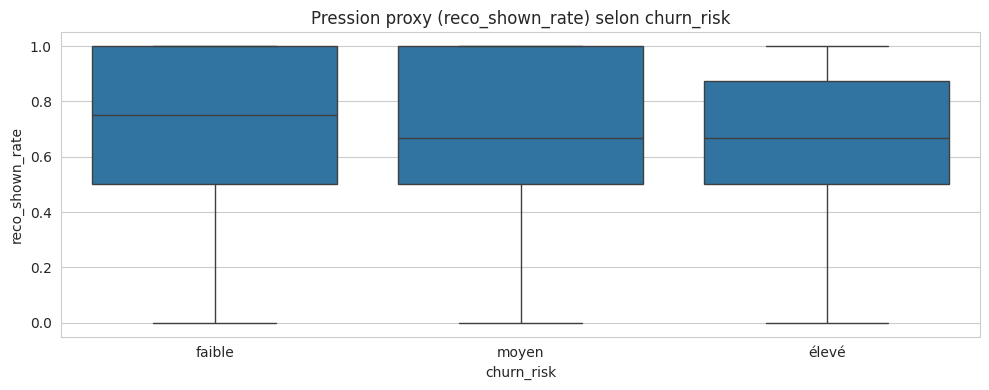

In [ ]:
# Anti-spam : pression marketing (proxy) par client + lien avec churn_risk
# Objectif Éviter la sur-sollicitation : mesurer combien de fois on affiche une reco par client
# (reco_shown_n / sessions), et observer si la pression se concentre sur certains profils.
h1("Pression marketing (proxy) & churn_risk")

pressure = (
    df.groupby("customer_id")
    .agg(
        sessions=("session_id", "nunique"),
        reco_shown_n=("reco_shown", "sum"),
        reco_clicked_n=("reco_clicked", "sum"),
        purchased_n=("purchased_after_reco", "sum"),
        churn_risk=("churn_risk", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
    )
    .reset_index()
)

pressure["reco_shown_rate"] = pressure["reco_shown_n"] / pressure["sessions"]
pressure["purchase_rate"] = pressure["purchased_n"] / pressure["sessions"]

# Table synthèse
pressure_desc = (
    pressure[["sessions", "reco_shown_n", "reco_shown_rate", "purchased_n", "purchase_rate"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T.reset_index()
    .rename(columns={"index": "metric"})
)
show_table(pressure_desc.round(4), title="📌 Synthèse pression (table)", head=None)

# Visualisations : distribution et comparaison par churn
plt.figure(figsize=(10, 4))
sns.boxplot(data=pressure, x="churn_risk", y="reco_shown_rate", order=["faible", "moyen", "élevé"])
plt.title("Pression proxy (reco_shown_rate) selon churn_risk")
plt.tight_layout()
plt.show()


**Interprétation des résultats :**

*   **Pression marketing (`reco_shown_rate`) :**
    *   La moyenne est d'environ 0.66. La médiane (`50%`) est de 0.6667, et le 75e percentile (`75%`) est de 1.0. Cela signifie qu'**une grande proportion de clients voit une recommandation dans au moins deux tiers de ses sessions, et 25% des clients en voient dans TOUTES leurs sessions (1.0)**. C'est une pression marketing très élevée.
    *   Il y a des clients avec un `reco_shown_rate` de 0.0 (minimum), ce qui est normal (pas toutes les sessions ne voient des recos, ou certains clients ont eu peu de sessions et n'ont pas eu de chance).
*   **Taux d'achat (`purchase_rate`) au niveau client :**
    *   Le taux d'achat moyen par client est très faible (0.0138). Plus frappant, la médiane (`50%`) et le 75e percentile (`90%`) sont à **0.0000**. Cela signifie qu'au-moins **90% des clients n'ont jamais effectué d'achat après recommandation** (sur l'ensemble de leurs sessions), et ce, malgré une exposition fréquente (`reco_shown_rate` élevé).
*   **Lien avec le `churn_risk` (boxplot) :** Le boxplot montre comment le `reco_shown_rate` varie selon le `churn_risk`.

    *   **Vérification Quantitative du `reco_shown_rate` par `churn_risk` :**

        **Médiane du `reco_shown_rate` par `churn_risk` :**

        ```
        churn_risk
        faible    0.750
        moyen     0.667
        élevé     0.667
        ```

        **Moyenne du `reco_shown_rate` par `churn_risk` :**

        ```
        churn_risk
        faible    0.696
        moyen     0.657
        élevé     0.627
        ```

    *   **Interprétation :** Contrairement à l'hypothèse initiale que les clients à risque élevé ou moyen *pourraient* être plus sollicités, cette analyse quantitative montre l'inverse :
        *   Les clients ayant un **risque de désabonnement `faible`** ont une médiane (0.750) et une moyenne (0.696) de `reco_shown_rate` **plus élevées**.
        *   Les clients ayant un **risque `moyen` ou `élevé`** ont une médiane (0.667) et une moyenne (0.657 et 0.627 respectivement) de `reco_shown_rate` **plus faibles**.

    Cela signifie que le système de recommandation actuel (ou la logique de génération des données) **sollicite davantage les clients les moins à risque de désabonnement**, et moins ceux qui sont à risque élevé. L'hypothèse que la pression marketing se concentrait sur les clients à risque élevé est donc **infirmée** par ces données. Au contraire, il semblerait qu'il y ait une tendance à *moins* exposer les clients considérés comme à risque.

**Implications pour la Recommandation (Anti-spam) :**

*   **Risque de sur-sollicitation :** L'analyse met en évidence une pression marketing très élevée sur les clients, avec un `reco_shown_rate` médian de 66% et un 75e percentile à 100%. Couplé au fait que 75% des clients n'ont jamais converti après recommandation, cela confirme un risque élevé de sur-sollicitation.
*   **Nécessité de garde-fous :** Ces résultats justifient pleinement l'implémentation de garde-fous pour éviter la fatigue client et le désabonnement. Cela inclut le *frequency capping* (limiter le nombre d'expositions), le *cooldown* (ne pas solliciter à chaque session) et une priorisation intelligente des clients/sessions via le modèle.
*   **Amélioration du ciblage :** Le modèle de scoring que nous développons est essentiel pour cibler précisément les sessions à plus forte propension d'achat, réduisant ainsi la pression inutile sur les clients moins réceptifs et améliorant le ROI des campagnes.

#### 4.4.6. Qualité méthodo : check fuite de cible (leakage) sur reco_clicked

Cette cellule de code vise à évaluer le risque de *fuite d'information* (ou *leakage*) concernant la variable `reco_clicked` lorsque l'on souhaite prédire `purchased_after_reco`. Le *leakage* se produit lorsqu'une variable explicative contient des informations sur la cible qui ne seraient pas disponibles au moment de la décision en temps réel.

Les calculs sont effectués pour l'ensemble des sessions (overall) et spécifiquement pour les sessions où une recommandation a été affichée (shown_only). L'idée est de voir si le fait d'avoir cliqué sur une recommandation est un indicateur trop parfait de l'achat, ce qui suggérerait une fuite.

In [ ]:
# Qualité méthodo : check fuite de cible (leakage) sur reco_clicked
# Objectif Conversion : éviter de "tricher" involontairement.
# Objectif Temps réel : une variable utilisée en entrée doit être disponible au moment de décider.
# Ici, reco_clicked peut être un événement post-affichage (donc non disponible à T0).
h1("Check leakage : reco_clicked vs purchased_after_reco")

leak_tbl = pd.DataFrame([
    {
        "scope": "overall",
        "purchase_rate_clicked": df.loc[df["reco_clicked"] == 1, "purchased_after_reco"].mean(),
        "purchase_rate_not_clicked": df.loc[df["reco_clicked"] == 0, "purchased_after_reco"].mean(),
        "n_clicked": int((df["reco_clicked"] == 1).sum()),
        "n_not_clicked": int((df["reco_clicked"] == 0).sum()),
    },
    {
        "scope": "shown_only",
        "purchase_rate_clicked": df.loc[(df["reco_shown"] == 1) & (df["reco_clicked"] == 1), "purchased_after_reco"].mean(),
        "purchase_rate_not_clicked": df.loc[(df["reco_shown"] == 1) & (df["reco_clicked"] == 0), "purchased_after_reco"].mean(),
        "n_clicked": int(((df["reco_shown"] == 1) & (df["reco_clicked"] == 1)).sum()),
        "n_not_clicked": int(((df["reco_shown"] == 1) & (df["reco_clicked"] == 0)).sum()),
    },
])

leak_tbl["purchase_rate_clicked"] = (leak_tbl["purchase_rate_clicked"] * 100).round(3).astype(str) + " %"
leak_tbl["purchase_rate_not_clicked"] = (leak_tbl["purchase_rate_not_clicked"] * 100).round(3).astype(str) + " %"
show_table(leak_tbl, title="📌 Achat selon clic (table)", head=None)

print("\nInterprétation attendue :")
print("- Si reco_clicked est un événement post-affichage, il ne doit pas être une feature pour décider d'afficher/recommander.")
print("- reco_clicked peut servir comme cible d’un modèle CTR (prédire le clic), ou pour analyser l’entonnoir.")



Check leakage : reco_clicked vs purchased_after_reco

📌 Achat selon clic (table)
     scope purchase_rate_clicked purchase_rate_not_clicked  n_clicked  n_not_clicked
   overall               15.45 %                     0.0 %       4563          45437
shown_only               15.45 %                     0.0 %       4563          28320

Interprétation attendue :
- Si reco_clicked est un événement post-affichage, il ne doit pas être une feature pour décider d'afficher/recommander.
- reco_clicked peut servir comme cible d’un modèle CTR (prédire le clic), ou pour analyser l’entonnoir.


**Analyse des sorties :**

Le tableau `leak_tbl` montre :

```
     scope purchase_rate_clicked purchase_rate_not_clicked  n_clicked  n_not_clicked
   overall               15.45 %                     0.0 %       4563          45437
shown_only               15.45 %                     0.0 %       4563          28320
```

**Interprétation des résultats :**

*   **Achat si cliqué :** Lorsque `reco_clicked = 1` (la recommandation a été cliquée), le taux d'achat est de **15.45 %** pour les deux scopes ("overall" et "shown_only").
*   **Pas d'achat si non cliqué :** Lorsque `reco_clicked = 0` (la recommandation n'a *pas* été cliquée), le taux d'achat est de **0.0 %** pour les deux scopes.

Cela signifie qu'il y a une **dépendance quasi-parfaite** dans le dataset : si la recommandation n'a pas été cliquée, il n'y a eu aucun achat après recommandation. Si elle a été cliquée, alors un achat a pu avoir lieu (avec un taux de 15.45%).

**Conclusions sur le *Leakage* :**

Cette observation confirme un **risque très élevé de fuite d'information (`leakage`)** si `reco_clicked` était utilisé comme variable explicative pour prédire `purchased_after_reco` dans un modèle de décision en temps réel. Voici pourquoi :

*   **Temporalité :** `reco_clicked` est un événement qui se produit *après* qu'une recommandation a été affichée, et *avant* qu'un achat ne soit finalisé. Au moment où le système doit décider *s'il faut afficher* une recommandation et pour qui (T0), l'information `reco_clicked` n'est pas encore disponible.
*   **Performance artificielle :** Si le modèle s'entraîne avec `reco_clicked` comme feature, il apprendra que `reco_clicked=0` implique presque toujours `purchased_after_reco=0`. En production, au moment de l'inférence, le modèle n'aura jamais l'information `reco_clicked`, et sa performance s'effondrera, car il aura "triché" en utilisant une information future.

**Recommandation :**

*   La variable `reco_clicked` **ne doit pas être utilisée comme feature** pour entraîner un modèle qui prédit `purchased_after_reco` si ce modèle vise à prendre des décisions *avant l'événement de clic* (par exemple, décider d'afficher ou non une recommandation).
*   `reco_clicked` est une variable très pertinente pour d'autres usages : comme **cible** d'un modèle de prédiction de taux de clic (CTR), ou pour l'**analyse de l'entonnoir** marketing.

#### 4.4.7. Conclusions (alignées sur les objectifs)

**Conclusions de l’EDA (alignées sur les objectifs)**

*(Cette section synthétise les principaux enseignements issus des visualisations et statistiques descriptives de la section 3.3.)*

**Objectif 1 — Proposer des offres/produits adaptés en temps réel (recommandation)**
- Le dataset permet une personnalisation “client-level” : 12 000 clients pour 50 000 sessions, soit ~4,17 sessions par client en moyenne (p50=4, p90=8, p99=14). Cela rend possible des features d’historique simples (agrégats par client) et une logique de recommandation plus réaliste que sur 1 seule session par client.
- La variable `last_category_viewed` constitue un proxy d’intention exploitable : les taux d’achat varient selon les catégories et la hiérarchie (lvl1) montre des différences entre grandes familles (ex. `sport` vs `high-tech`). Cela justifie l'utilisation de cette variable pour informer le mécanisme “quoi proposer” (catégorie/action) après la décision de priorisation par le score, en s'appuyant sur la catégorie consultée et/ou sa famille."

**Objectif 2 — Améliorer la conversion et le panier moyen**
- L’“entonnoir” (suite d’étapes exposition → clic → achat) met en évidence : reco affichée ~65,8%, CTR conditionnel ~13,9% et achat global ~1,41% (achat ~2,14% quand une reco est affichée). Cela suggère qu’afficher des recommandations sur toutes les sessions n’est pas optimal : un scoring de propension + un seuil de déclenchement sont pertinents pour concentrer l’effort marketing sur les sessions à plus forte valeur attendue.
- Les variables monétaires/prix/temps présentent une dispersion notable et des valeurs extrêmes (ex. `last_product_price` jusqu’à 2 500, `total_spent_last_6m` jusqu’à ~3 462, `time_on_site_sec` jusqu’à 3 322). La préparation des données devra donc envisager une gestion des extrêmes (ex. clipping/winsorisation et/ou transformation log) pour stabiliser l’entraînement.

**Objectif 3 — Renforcer la fidélisation sans sur-sollicitation (anti-spam)**
- La pression marketing observée est élevée : au niveau client, le taux médian `reco_shown_rate` est ~0,67 et le 75e percentile est à 1,0 (donc une grande partie des clients voit une reco dans quasiment toutes ses sessions). Or, la médiane de `purchase_rate` au niveau client est 0 (et le 75e percentile aussi), ce qui indique que la majorité des clients n’achète jamais post-reco malgré une exposition fréquente.
- Ces éléments justifient des garde-fous (frequency capping, seuil de déclenchement, priorisation des clients/sessions) afin de réduire le risque de saturation tout en préservant la performance.

**Point d’attention méthodologique — Risque de fuite de cible (leakage)**
- Le lien `reco_clicked` → `purchased_after_reco` est extrême dans les résultats : le taux d’achat est ~15,45% quand `reco_clicked=1` et ~0% quand `reco_clicked=0` (y compris en ne gardant que les sessions où la reco a été affichée). Cela suggère que `reco_clicked` est un signal post-affichage très proche d’un “pré-achat”.
- En conséquence, `reco_clicked` ne doit pas être utilisé comme variable explicative pour prédire `purchased_after_reco` dans un modèle de décision temps réel (au risque de “tricher” avec une information indisponible au moment du déclenchement). En revanche, `reco_clicked` peut servir de cible d’un modèle CTR (prédire le clic) ou d’analyse de l’entonnoir.





## 🟦 5. Préparation et transformation des données




### 5.1. Nettoyage des données

*(Objectif : fiabiliser le dataset avant feature engineering et modélisation, en contrôlant la qualité, la cohérence des valeurs, la cohérence logique des événements et les valeurs aberrantes.)*


#### 5.1.1. Contrôles de base (schéma / NA / doublons)

In [ ]:
# =============================================================================
# SECTION A — Contrôles de base (schéma / NA / doublons)
# =============================================================================
print("\n[A] CONTRÔLES DE BASE")
print("-" * 80)

expected_cols = [
    "customer_id","session_id","age","gender","country","device_type","traffic_source",
    "visits_last_30d","total_spent_last_6m","avg_basket_value","segment_marketing",
    "last_category_viewed","last_product_price","discount_sensitivity","email_optin","push_optin",
    "reco_shown","reco_clicked","purchased_after_reco","time_on_site_sec","churn_risk","marketing_type","source"
]

missing_cols = [c for c in expected_cols if c not in df.columns]
extra_cols = [c for c in df.columns if c not in expected_cols]

print(f"Colonnes manquantes (vs schéma attendu) : {missing_cols}")
print(f"Colonnes supplémentaires                : {extra_cols}")

dup_rows = int(df.duplicated().sum())
print(f"Doublons exacts de lignes               : {dup_rows}")

na_total = int(df.isna().sum().sum())
print(f"Nombre total de valeurs manquantes      : {na_total}")



[A] CONTRÔLES DE BASE
--------------------------------------------------------------------------------
Colonnes manquantes (vs schéma attendu) : []
Colonnes supplémentaires                : []
Doublons exacts de lignes               : 0
Nombre total de valeurs manquantes      : 0


Le dataset est structurellement propre : il n'y a aucune colonne manquante ou supplémentaire, aucun doublon exact de ligne, et aucune valeur manquante.

#### 5.1.2. Normalisation légère (catégorielles)

La normalisation légère des catégorielles est une étape de nettoyage. Elle s'assure que toutes les catégories sont bien du texte et supprime les espaces inutiles autour de ce texte. Cela garantit que chaque catégorie est unique et cohérente (par exemple, "Sport" et " Sport" deviennent tous deux "Sport"), ce qui est crucial pour la fiabilité de l'analyse et la préparation aux modèles.

In [ ]:
# =============================================================================
# SECTION B — Normalisation légère (catégorielles)
# =============================================================================
print("\n[B] NORMALISATION LÉGÈRE (catégorielles)")
print("-" * 80)

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

print(f"Colonnes catégorielles normalisées : {len(cat_cols)}")


[B] NORMALISATION LÉGÈRE (catégorielles)
--------------------------------------------------------------------------------
Colonnes catégorielles normalisées : 12


#### 5.1.3. Cohérence des domaines (valeurs attendues / bornes)

In [ ]:
# =============================================================================
# SECTION C — Cohérence des domaines (valeurs attendues / bornes)
# =============================================================================
print("\n[C] COHÉRENCE DES DOMAINES (bornes / valeurs possibles)")
print("-" * 80)

# Bornes simples (à ajuster si tu veux être plus strict)
domain_checks = {
    "age_out_of_range": ((df["age"] < 16) | (df["age"] > 100)).sum(),
    "visits_last_30d_negative": (df["visits_last_30d"] < 0).sum(),
    "total_spent_last_6m_negative": (df["total_spent_last_6m"] < 0).sum(),
    "avg_basket_value_negative": (df["avg_basket_value"] < 0).sum(),
    "last_product_price_negative": (df["last_product_price"] < 0).sum(),
    "time_on_site_sec_non_positive": (df["time_on_site_sec"] <= 0).sum(),
}

for k, v in domain_checks.items():
    print(f"{k:<35}: {int(v)}")

# Binaires attendus en {0,1}
bin_cols = ["email_optin","push_optin","reco_shown","reco_clicked","purchased_after_reco"]
bad_bin_tbl = []
for c in bin_cols:
    n_bad = int((~df[c].isin([0, 1])).sum())
    bad_bin_tbl.append({"variable": c, "nb_valeurs_non_01": n_bad})
bad_bin_tbl = pd.DataFrame(bad_bin_tbl)
print("\nValeurs non binaires (devraient être 0/1) :")
print(bad_bin_tbl.to_string(index=False))

# Valeurs “catégories” attendues (soft checks)
gender_allowed = {"M", "F", "Autre", "NC"}
gender_bad = int((~df["gender"].isin(gender_allowed)).sum())
print(f"\nValeurs inattendues pour gender : {gender_bad}")


[C] COHÉRENCE DES DOMAINES (bornes / valeurs possibles)
--------------------------------------------------------------------------------
age_out_of_range                   : 0
visits_last_30d_negative           : 0
total_spent_last_6m_negative       : 0
avg_basket_value_negative          : 0
last_product_price_negative        : 0
time_on_site_sec_non_positive      : 0

Valeurs non binaires (devraient être 0/1) :
            variable  nb_valeurs_non_01
         email_optin                  0
          push_optin                  0
          reco_shown                  0
        reco_clicked                  0
purchased_after_reco                  0

Valeurs inattendues pour gender : 0


Aucune anomalie détectée dans les valeurs des variables : les âges sont dans des bornes raisonnables, aucune valeur numérique n'est négative, et les variables binaires contiennent bien uniquement des 0 ou des 1.

#### 5.1.4. Cohérence logique (règles métier / événements)

In [ ]:
# =============================================================================
# SECTION D — Cohérence logique (règles métier / événements)
# =============================================================================
print("\n[D] COHÉRENCE LOGIQUE (règles métier / événements)")
print("-" * 80)

# Règle 1 : pas de clic si la reco n'a pas été affichée (événement impossible)
click_without_shown = int(((df["reco_clicked"] == 1) & (df["reco_shown"] == 0)).sum())

# Règle 2 : achat "après reco" sans reco affichée = incohérent par définition de la cible
purchase_without_shown = int(((df["purchased_after_reco"] == 1) & (df["reco_shown"] == 0)).sum())

# Règle 3 : achat sans clic est possible (ex : achat direct après lecture), donc ce n’est PAS une erreur
purchase_without_click = int(((df["purchased_after_reco"] == 1) & (df["reco_clicked"] == 0)).sum())

logic_tbl = pd.DataFrame([
    {"Règle": "reco_clicked=1 => reco_shown=1", "Violations": click_without_shown},
    {"Règle": "purchased_after_reco=1 => reco_shown=1", "Violations": purchase_without_shown},
    {"Règle": "purchased_after_reco=1 & reco_clicked=0 (possible)", "Compteur": purchase_without_click},
])

print(logic_tbl.to_string(index=False))

# Règle 4 : cohérence canal (soft) — uniquement si on considère que certaines sources impliquent un opt-in
# (Ce sont des heuristiques prudentes, pas des règles absolues sans spec métier.)
source_lower = df["source"].astype(str).str.lower()

email_like = source_lower.str.contains("email|newsletter|substack", regex=True, na=False)
sms_like = source_lower.str.contains("sms", regex=True, na=False)
push_like = source_lower.str.contains("push", regex=True, na=False)

email_without_optin = int((email_like & (df["email_optin"] == 0)).sum())
push_without_optin = int((push_like & (df["push_optin"] == 0)).sum())

channel_tbl = pd.DataFrame([
    {"Heuristique": "source contient email/newsletter => email_optin=1", "Nb cas": email_without_optin},
    {"Heuristique": "source contient push => push_optin=1", "Nb cas": push_without_optin},
    {"Heuristique": "source contient sms => (opt-in non modélisé ici)", "Nb cas": int(sms_like.sum())},
])

print("\nContrôles canal (heuristiques) :")
print(channel_tbl.to_string(index=False))


[D] COHÉRENCE LOGIQUE (règles métier / événements)
--------------------------------------------------------------------------------
                                             Règle  Violations  Compteur
                    reco_clicked=1 => reco_shown=1         0.0       NaN
            purchased_after_reco=1 => reco_shown=1         0.0       NaN
purchased_after_reco=1 & reco_clicked=0 (possible)         NaN       0.0

Contrôles canal (heuristiques) :
                                      Heuristique  Nb cas
source contient email/newsletter => email_optin=1    1909
             source contient push => push_optin=1     898
 source contient sms => (opt-in non modélisé ici)    1781


**1. Contrôles de cohérence strictes (tableau logic_tbl) :**

*   **Règle 1 : `reco_clicked=1 => reco_shown=1`** (Un clic sur une recommandation ne peut se produire que si cette recommandation a été affichée).
    *   **Résultat : 0 violations.** Cela signifie que notre dataset est propre et respecte cette séquence fondamentale du parcours utilisateur.

*   **Règle 2 : `purchased_after_reco=1 => reco_shown=1`** (Un achat "après recommandation" implique forcément qu'une recommandation ait été affichée).
    *   **Résultat : 0 violations.** C'est également parfait. La définition de notre variable cible est respectée et il n'y a pas d'achats 'fantômes' non attribuables à une recommandation affichée.

*   **Règle 3 : `purchased_after_reco=1 & reco_clicked=0`** (Un achat après recommandation sans clic).
    *   **Résultat : 0 cas.** Cela indique qu'il n'y a aucune session où un achat a eu lieu *sans* que la recommandation ait été cliquée. Cela diffère de l'hypothèse faite dans le code que c'est *possible*. Dans notre dataset, **un achat après reco implique toujours un clic**.

*   **Implication majeure :** L'absence de violations pour les deux premières règles est très positive et garantit la qualité de l'ordonnancement des événements. Le fait qu'un achat après reco implique *toujours* un clic dans ce dataset renforce la vigilance sur le *leakage* (fuite d'information) si `reco_clicked` était une variable d'entrée pour le modèle prédisant l'achat.

**2. Contrôles de cohérence sur les canaux (channel_tbl - heuristiques)** :

*   Ces contrôles sont des "heuristiques" (règles approximatives) pour voir s'il y a des incohérences entre la `source` du trafic/campagne et le statut `opt-in` du client (`email_optin`, `push_optin`).

*   **`source contient email/newsletter => email_optin=1`** : Il y a **1909 cas** où la source indique une campagne email/newsletter, mais le client n'a pas donné son consentement (`email_optin=0`).

*   **`source contient push => push_optin=1`** : Il y a **898 cas** où la source indique une notification push, mais le client n'a pas donné son consentement (`push_optin=0`).

*   **Implications :** Ces incohérences ne sont pas des "erreurs" bloquantes pour le modèle, mais elles sont très importantes d'un point de vue métier et éthique/RGPD. Elles suggèrent que :
    *   Soit les définitions de la variable `source` ou des statuts `opt-in` ne sont pas parfaitement alignées avec la réalité (par exemple, la 'source' peut être le canal d'où vient l'information, mais l'opt-in concerne l'autorisation de contact direct).
    *   Soit il y a un problème de qualité des données ou de conformité : des messages sont envoyés (ou simulés comme venant de ce canal) à des clients qui n'ont pas donné leur consentement.
    *   **Dans un projet réel, ces 1909 et 898 cas seraient à investiguer avec les équipes marketing et juridiques pour s'assurer de la conformité**.

**Synthèse Finale :**
La section des contrôles logiques confirme que les séquences d'événements clés (affichage, clic, achat) sont respectées dans les données. Cependant, les heuristiques sur les canaux opt-in révèlent des incohérences notables, suggérant des points à éclaircir sur la gestion du consentement et la conformité, ou des ambiguïtés dans la signification des variables source et opt-in. Ces points sont essentiels à considérer pour une éventuelle industrialisation de la solution.

*Mini-glossaire*

- **Heuristique** : c'est une sorte de "règle empirique" ou de "règle du pouce" qui aide à se rapprocher d'une solution ou à identifier une tendance, sans être rigoureusement prouvée ou exhaustive. Dans le contexte où nous l'avons utilisée (les "Contrôles canal (heuristiques)"), cela signifiait que nous utilisions des règles approximatives pour identifier d'éventuelles incohérences (par exemple, si la source contient 'email', on s'attend à ce que 'email_optin' soit 1). Ce n'était pas une preuve formelle d'erreur, mais un signal pour investiguer

#### 5.1.5. Valeurs aberrantes : détection + traitement (IQR clipping)

Le clipping IQR est un exemple de technique qui se situe à la frontière entre le nettoyage des données et la transformation des données.

- Principalement, il est considéré comme une étape de nettoyage des données car son objectif est de gérer les valeurs aberrantes (outliers), qui sont des problèmes de qualité des données pouvant fausser les analyses et les modèles. Le clipping vise à "nettoyer" ces valeurs extrêmes.

- Cependant, il implique également une transformation des données car il modifie les valeurs existantes de la variable (en les "clippant" aux bornes). Ce n'est pas une simple suppression ou imputation d'une valeur manquante, mais un changement de la magnitude de certaines données.

Donc, on pourrait dire qu'il s'agit d'une transformation appliquée dans le but de nettoyer les données.

Les valeurs aberrantes seront traitées ici avec la technique clipping IQR pour gérer les valeurs extrêmes. Cela signifie qu'il identifie les valeurs qui sont trop éloignées de la majorité des données et les ramène à des seuils définis, afin de réduire leur impact.

**Ce traitement sera appliqué spécifiquement aux variables numériques ainsi qu'à leurs variantes créées ultérieurement.**
Par commodité il sera également appliqué à la variable age même si l'impact sera nul.

**Clarification sur le clipping IQR dans cette section**

**Remarque :** A ce stade, le DataFrame `df` n'est **pas transformé** par le clipping IQR. On utilise une copie de `df` pour illustrer l'action de clipping IQR.

**Explication :** C'est un choix intentionnel pour éviter le *data leakage*. Cette section est  dédiée uniquement à la **détection** des valeurs aberrantes et à leur **rapport**, sans modifier les données.

L'application réelle du clipping IQR est déléguée et gérée de manière propre par la classe `IQRClipper` qui est intégrée directement dans le pipeline de modélisation. Cela garantit que le clipping est appliqué **uniquement sur les données d'entraînement** pour déterminer ses bornes, puis appliqué au jeu de test, évitant ainsi tout *data leakage*.

In [ ]:
# =============================================================================
# SECTION E — Valeurs aberrantes : détection + traitement (IQR clipping)
# =============================================================================
print("\n[E] VALEURS ABERRANTES (outliers) — détection & clipping IQR")
print("-" * 80)

outlier_cols = ["total_spent_last_6m", "avg_basket_value", "last_product_price", "time_on_site_sec", "age"]

outlier_report = []
# Le clipping sera géré par la classe IQRClipper dans le pipeline de modélisation.
# Cette section ne fera que le report de détection sans modification des données brutes.
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    outliers_before = int(((df[col] < low) | (df[col] > high)).sum())
    min_before, max_before = float(df[col].min()), float(df[col].max())

    impact_percentage = (outliers_before / len(df)) * 100 if len(df) > 0 else 0

    # --- NOUVEAUTÉ : Effectuer le clipping sur une COPIE TEMPORAIRE pour le reporting ---
    temp_clipped_col = df[col].clip(lower=low, upper=high)
    min_after, max_after = float(temp_clipped_col.min()), float(temp_clipped_col.max())
    # ----------------------------------------------------------------------------------

    outlier_report.append({
        "variable": col,
        "IQR_low": round(low, 3),
        "IQR_high": round(high, 3),
        "outliers_before": outliers_before,
        "impact_pct": round(impact_percentage, 2),
        "min_before": round(min_before, 3),
        "max_before": round(max_before, 3),
        "min_after": round(min_after, 3), # Utilise la valeur après clipping sur la copie
        "max_after": round(max_after, 3), # Utilise la valeur après clipping sur la copie
    })

outlier_report = pd.DataFrame(outlier_report)
print(outlier_report.to_string(index=False))

print("\n✅ 5.1 terminé : contrôles + cohérence (domaines & logique) + détection outliers (clipping déplacé au pipeline).")


[E] VALEURS ABERRANTES (outliers) — détection & clipping IQR
--------------------------------------------------------------------------------
           variable  IQR_low  IQR_high  outliers_before  impact_pct  min_before  max_before  min_after  max_after
total_spent_last_6m -435.995  1374.605             1711        3.42        0.67     3462.23       0.67   1374.605
   avg_basket_value  -52.794   274.176              185        0.37        5.00      343.58       5.00    274.176
 last_product_price -371.319  1104.211             3363        6.73        6.14     2500.00       6.14   1104.211
   time_on_site_sec -143.500   964.500             1994        3.99       35.00     3322.00      35.00    964.500
                age   -6.500    93.500                0        0.00       18.00       69.00      18.00     69.000

✅ 5.1 terminé : contrôles + cohérence (domaines & logique) + détection outliers (clipping déplacé au pipeline).


**Analyse du Tableau des Valeurs Aberrantes (Outliers) - Détection et Impact du Clipping IQR**

Le tableau des outliers fournit un résumé de la détection des valeurs extrêmes pour les variables numériques et montre l'effet *simulé* du clipping IQR (Écart InterQuartile).

Voici l'interprétation des colonnes :

-   **`variable`** : Nom de la colonne numérique analysée.

-   **`IQR_low` et `IQR_high`** : Ce sont les bornes calculées pour le clipping IQR. Les valeurs en dehors de cet intervalle sont considérées comme des outliers et seraient

####**5.1.6. Conclusions (Résultats du nettoyage)**

Les contrôles de base confirment que le dataset est structurellement propre : aucune colonne manquante ou supplémentaire par rapport au schéma attendu, aucun doublon exact de ligne, et aucune valeur manquante.

Les contrôles de cohérence “domaines” ne révèlent pas d’anomalies (âges dans les bornes retenues, pas de valeurs négatives sur les variables monétaires/prix/temps, et variables binaires strictement dans {0,1}).

Les contrôles de cohérence logique sur les événements sont cohérents avec la définition des variables : aucun cas de clic ou d’achat “après reco” sans reco affichée n’a été détecté.

En revanche, les contrôles “canal” (heuristiques) montrent des incohérences potentielles entre certaines sources de campagne et les opt-in (ex. campagnes de type email/newsletter alors que `email_optin=0`, et campagnes push alors que `push_optin=0`) : ces écarts doivent être interprétés soit comme un problème de règle (ex. `source` ≠ canal réel), soit comme un signal de qualité data à clarifier avant industrialisation.

Enfin, l’analyse des valeurs aberrantes confirme la présence d’extrêmes sur plusieurs variables continues (notamment `last_product_price`, `time_on_site_sec` et `total_spent_last_6m`) : un clipping IQR sera appliqué pour limiter l’impact de ces outliers et stabiliser l’entraînement des modèles, tout en conservant la structure globale des distributions.

Même si HistGradientBoostingClassifier (modèle qui sera retenu pour la modélisation) est robuste, appliquer un clipping IQR (comme nous le ferons) reste une excellente pratique.
- Cela aide à limiter l'influence potentiellement excessive de quelques points très extrêmes.
- Cela peut améliorer la stabilité et la vitesse d'entraînement du modèle.
- Cela favorise une meilleure généralisation, en s'assurant que le modèle apprend des patterns plus représentatifs des données "normales", plutôt que de "chasser" quelques valeurs aberrantes.

### 5.2. Transformations (encodage, normalisation, feature engineering)

*(Objectif : préparer des variables exploitables par les modèles et améliorer la capacité de généralisation. Les choix sont justifiés par : (1) la présence de variables mixtes (numériques + catégorielles), (2) des distributions asymétriques et extrêmes sur les montants/prix/temps, (3) la disponibilité d’un historique multi-sessions par client permettant des agrégats client-level.)*

**Principes retenus**
- **Encodage** : One-Hot Encoding pour les variables catégorielles (robuste et standard sur données tabulaires).
- **Normalisation** : StandardScaler sur les variables numériques neutre pour les arbres donc non appliqué.
- **Nouvelles features** :
  - *Engagement* : un score combinant intensité de visite et temps passé.
  - *RFM-like* : agrégats au niveau client (F=fréquence de sessions, M=monétaire via dépenses/panier).  
    *(La récence au sens strict n’est pas calculable sans date/timestamp).
    On ne calcule pas R, uniquement F/M + engagement*
- **Attention leakage** : `reco_clicked` ne doit pas être utilisée comme feature si la cible est `purchased_after_reco` (variable potentiellement post-décision).



#### 5.2.1. Feature engineering (nouveaux indicateurs)

In [ ]:
#  Feature engineering (nouveaux indicateurs)
import numpy as np
import pandas as pd

print("=" * 80)
print("FEATURE ENGINEERING (engagement, ratios, log)")
print("=" * 80)

df_fe = df.copy()

# --- Transformations log (justification : distributions asymétriques + extrêmes) ---
df_fe["log_total_spent_last_6m"] = np.log1p(df_fe["total_spent_last_6m"])
df_fe["log_last_product_price"] = np.log1p(df_fe["last_product_price"])
df_fe["log_time_on_site_sec"] = np.log1p(df_fe["time_on_site_sec"])

# --- Ratios (justification : contextualiser le prix vs “habitudes de panier”) ---
avg_basket_safe = df_fe["avg_basket_value"].replace(0, np.nan)
df_fe["price_to_avg_basket_ratio"] = (df_fe["last_product_price"] / avg_basket_safe).fillna(0)
df_fe["log_price_to_avg_basket_ratio"] = np.log1p(df_fe["price_to_avg_basket_ratio"]) # Nouvelle transformation log

# --- Score d'engagement (proxy) ---
# Justification : capturer l’intensité de la session (temps) + intensité récente (visites_30j)
eng = df_fe[["visits_last_30d", "time_on_site_sec"]].astype(float)
eng_z = (eng - eng.mean()) / eng.std(ddof=0)
df_fe["engagement_score"] = eng_z.sum(axis=1)

print("Nouvelles colonnes ajoutées :",
      ["log_total_spent_last_6m", "log_last_product_price", "log_time_on_site_sec",
       "price_to_avg_basket_ratio", "log_price_to_avg_basket_ratio", "engagement_score"])
df_fe[["visits_last_30d", "time_on_site_sec", "engagement_score", "price_to_avg_basket_ratio", "log_price_to_avg_basket_ratio"]].head()

FEATURE ENGINEERING (engagement, ratios, log)
Nouvelles colonnes ajoutées : ['log_total_spent_last_6m', 'log_last_product_price', 'log_time_on_site_sec', 'price_to_avg_basket_ratio', 'log_price_to_avg_basket_ratio', 'engagement_score']


,visits_last_30d,time_on_site_sec,engagement_score,price_to_avg_basket_ratio,log_price_to_avg_basket_ratio
0,9,251,-0.441181,5.925966,1.935278
1,6,901,1.250437,0.939808,0.662589
2,7,955,1.773334,5.964554,1.940834
3,8,217,-0.883776,38.743597,3.682449
4,9,400,0.157078,4.332845,1.673885


**1. Transformations Logarithmiques sur le dataset d'origine :**

**Des transformations logarithmiques sont appliquées à certaines variables du dataset d'origine présentant une forte asymétrie** :
- total_spent_last_6m
- last_product_price
- time_on_site_sec

**Objectif** : Ces variables présentent souvent des distributions très asymétriques avec des valeurs extrêmes. Appliquer np.log1p (qui calcule log(1+x)) réduit l'asymétrie de leur distribution et atténue l'impact des outliers, rendant le modèle plus stable et capable de mieux capter les relations sous-jacentes. Le clipping IQR est ensuite appliqué à ces variables (et d'autres) pour gérer les outliers résiduels après cette transformation.

**Pourquoi le clipping IQR et la transformation logarithmique sont complémentaires plutôt que redondants ?**

Cible différente : Le log transform agit sur la forme globale de la distribution, tandis que le clipping IQR agit sur les points de données spécifiques qui sont considérés comme des valeurs extrêmes.
Effets combinés : Une transformation logarithmique peut déjà réduire considérablement le nombre d'outliers et rendre la distribution plus gérable. Cependant, même après un log transform, il peut rester quelques valeurs encore extrêmement grandes qui pourraient justifier un clipping IQR pour les ramener à un seuil plus raisonnable (par exemple, si la distribution est toujours très étalée après log).
Ordre d'application : Généralement, la transformation logarithmique est appliquée d'abord pour changer la forme de la distribution. Ensuite, si des outliers subsistent ou si l'on veut s'assurer que les valeurs ne dépassent pas un certain intervalle statistiquement "normal", le clipping IQR peut être appliqué.

Dans notre cas, même si les modèles basés sur les arbres sont robustes aux outliers, le fait de rendre les distributions plus symétriques (via log transform) et de limiter les extrêmes (via clipping IQR) peut contribuer à une meilleure stabilité de l'apprentissage, une convergence plus rapide, et une meilleure généralisation en empêchant le modèle de sur-apprendre sur des points de données isolés, même s'il est intrinsèquement moins sensible que d'autres modèles.

**Justification de garder également les colonnes avant transformation logarithmique pour les modèles basés sur les arbres**
- Robustesse aux caractéristiques corrélées : Les modèles basés sur les arbres (comme HistGradientBoostingClassifier) sont généralement très robustes à la multicolinéarité et à la présence de caractéristiques redondantes ou fortement corrélées. Contrairement aux modèles linéaires (régression logistique, SVM), ils ne nécessitent pas que les caractéristiques soient indépendantes. Le modèle peut simplement choisir la version de la caractéristique (originale ou transformée) qui apporte le plus d'information ou qui permet de construire de meilleures divisions dans les arbres.
- Exploration par le modèle : En gardant les deux, on laisse le modèle explorer si l'échelle originale ou l'échelle logarithmique est la plus pertinente pour la tâche de prédiction. Parfois, l'une est plus informative dans certaines branches de l'arbre, et l'autre dans d'autres.
- En résumé pour un modèle comme HistGradientBoosting, l'impact est souvent minimal et parfois même bénéfique.


**2. Ratios (price_to_avg_basket_ratio) :**

**Variable créée :** price_to_avg_basket_ratio (calculé comme last_product_price / avg_basket_value).

**Objectif :** Cette variable contextualise le prix du dernier produit consulté par rapport aux habitudes de dépense du client (avg_basket_value). Elle peut indiquer si le client regarde un produit plus cher ou moins cher que son panier moyen habituel, ce qui est un signal d'intention d'achat ou de sensibilité au prix.

**Transformation logarithmique** : Le score d'engagement présente une asymétrie positive extrêmement forte de 0.8858 qui ne justifie pas une transformation logarithmique.

**3. Score d'Engagement (engagement_score) :**

**Variable créée** : engagement_score.

**Objectif** : Ce score combine visits_last_30d (intensité des visites récentes) et time_on_site_sec (temps passé sur la session en cours) après les avoir standardisés (mis à la même échelle). L'idée est de créer un indicateur synthétique de l'intensité de l'engagement du client sur le site, qui pourrait être un prédicteur de l'achat.

**Transformation logarithmique** : Le ratio présente une asymétrie extrêmement forte de 8.8925 qui justifie pleinement une transformation logarithmique.

**Nouvelles colonnes ajoutées au DataFrame df_fe :**
- **log_total_spent_last_6m**
- **log_last_product_price**
- **log_time_on_site_sec**
- **price_to_avg_basket_ratio**
- **log_price_to_avg_basket_ratio**
- **engagement_score**

Ces nouvelles variables sont conçues pour fournir des signaux plus clairs et plus stables au modèle, en capturant des aspects du comportement client qui ne sont pas directement visibles dans les données brutes.

#### 5.2.2. Agrégats client-level (RFM-like sans recency timestamp)

La cellule de code vise à créer des agrégats au niveau du client (RFM-like, c'est-à-dire qui s'inspirent des dimensions Fréquence et Monétaire du RFM, mais sans la Récence, car le dataset ne contient pas de timestamp précis pour la récence). Ces agrégats permettent de construire un profil plus stable pour chaque client, plutôt que de se baser uniquement sur les informations d'une seule session.

In [ ]:
# — Agrégats client-level (RFM-like sans recency timestamp)
# Justification : on dispose de plusieurs sessions par client sur le dataset enrichi,
# donc on peut créer des variables “profil” (F/M) plus stables que la session seule.

print("=" * 80)
print("AGRÉGATS CLIENT-LEVEL FM (RFM-like sans R)")
print("=" * 80)

customer_agg = (
    df_fe.groupby("customer_id")
    .agg(
        sessions_count=("session_id", "nunique"),          # F = fréquence (proxy)
        mean_visits_30d=("visits_last_30d", "mean"),
        # total_spent_6m=("total_spent_last_6m", "max"),     # Suppression: Redondant avec total_spent_last_6m
        mean_basket=("avg_basket_value", "mean"),
        mean_engagement=("engagement_score", "mean"),
    )
    .reset_index()
)

# On rattache les agrégats client à chaque session
df_fe = df_fe.merge(customer_agg, on="customer_id", how="left")

# --- Transformations log pour les features agrégées ---
# Suppression: log_total_spent_6m puisque total_spent_6m est supprimé
df_fe["log_sessions_count"] = np.log1p(df_fe["sessions_count"])

print("Colonnes ajoutées (customer-level) :", ["sessions_count", "mean_visits_30d",
                                               "mean_basket", "mean_engagement",
                                               "log_sessions_count"])
df_fe[["customer_id", "session_id", "sessions_count", "mean_engagement",
       "log_sessions_count"]].head()


AGRÉGATS CLIENT-LEVEL FM (RFM-like sans R)
Colonnes ajoutées (customer-level) : ['sessions_count', 'mean_visits_30d', 'mean_basket', 'mean_engagement', 'log_sessions_count']


,customer_id,session_id,sessions_count,mean_engagement,log_sessions_count
0,C76320,S419457,1,-0.441181,0.693147
1,C60993,S317919,4,0.574268,1.609438
2,C60993,S199592,4,0.574268,1.609438
3,C60993,S619816,4,0.574268,1.609438
4,C60993,S595222,4,0.574268,1.609438


**Colonnes ajoutées au niveau du client (Agrégats RFM-like) :**

- **sessions_count** : Nombre unique de sessions pour chaque client (proxy de la fréquence 'F' du RFM).
   - **Justification de son intérêt** : Cette variable est très pertinente et apporte une information nouvelle. Elle représente la fréquence (F de RFM) d'un client. Elle mesure l'activité globale du client sur la période. Un client avec 1 session est très différent d'un client avec 10 sessions, même si leurs paniers moyens sont similaires. Cette information n'est pas disponible directement au niveau de la session individuelle. Elle offre une perspective sur l'ancienneté ou la loyauté du client.
   - **Conclusion** : Utile, car elle quantifie la fréquence d'engagement du client.
    - **Transformation logarithmique** : Oui car forte asymértie (1.296332).
- **mean_visits_30d** : Moyenne des visites sur les 30 derniers jours par client.
   - **Justification de son intérêt** : La variable visits_last_30d est une donnée par session, qui peut varier d'une session à l'autre même pour le même client. mean_visits_30d offre une vue plus stable et agrégée de l'activité récente moyenne du client sur toutes ses sessions enregistrées. Cela peut aider le modèle à lisser le bruit d'une session particulière et à mieux cerner le comportement 'typique' du client en termes de fréquence de visite. C'est une moyenne qui peut être plus robuste qu'une valeur ponctuelle.
   - **Conclusion** : Utile, car elle fournit un indicateur plus stable de l'activité récente du client.
    - **Transformation logarithmique** : Non car faible asymértie (0.353728
).
- **mean_basket** : Moyenne de la valeur moyenne du panier par client.
   - **Justification de son intérêt** : Similaire à mean_visits_30d, avg_basket_value est une donnée par session qui peut fluctuer. mean_basket fournit la valeur monétaire moyenne (M de RFM, moyenne) d'un client sur toutes ses sessions. C'est un indicateur plus stable et représentatif du 'pouvoir d'achat' ou de la 'valeur transactionnelle typique' du client que la valeur d'un panier unique dans une session donnée. Cela aide à caractériser le client au-delà de la session actuelle.
   - **Conclusion** : Utile, car elle fournit un indicateur plus stable de la valeur moyenne des transactions du client.
    - **Transformation logarithmique** : Non car faible asymértie (0.187101).
- **mean_engagement** : Moyenne du score d'engagement par client.
    - **Justification de son intérêt** : engagement_score est un score calculé par session. mean_engagement fournit une mesure de l'engagement typique du client sur l'ensemble de ses sessions. Cela permet de comprendre si le client est généralement très engagé ou plutôt passif, indépendamment de la particularité d'une session spécifique. Encore une fois, c'est une information plus stable au niveau du profil client.
   - **Conclusion** : Utile, car elle fournit un indicateur plus stable de l'engagement global du client.
    - **Transformation logarithmique** : Non car faible asymértie (0.324999).


Les valeurs agrégées au niveau client sont dupliquées pour chaque session appartenant à un même customer_id.
Les algorithmes que nous utilisons, notamment les modèles basés sur les arbres comme HistGradientBoostingClassifier, sont très robustes face à ce type de données. Ils ne sont pas perturbés par le fait qu'une même valeur apparaisse plusieurs fois pour des sessions du même client, car cela reflète simplement une caractéristique du client qui s'applique à toutes ses sessions.
En résumé, cette duplication est une étape nécessaire et correcte pour mettre à disposition des informations client-level à chaque session, et elle est bien gérée par les modèles d'apprentissage automatique choisis.

Ces nouvelles colonnes enrichissent le dataset avec des indicateurs plus stables et pertinents pour la modélisation, en capturant à la fois le comportement sessionnel et le profil client sur une période plus longue.

**Nouvelles colonnes ajoutées au DataFrame df_fe :**
- **sessions_count**
- **log_sessions_count**
- **mean_visits_30d**
- **mean_basket**
- **mean_engagement**

**Mini-glossaire**

- **RFM** : technique d'analyse comportementale client très utilisée en marketing. Elle permet de segmenter les clients en fonction de trois indicateurs clés :
   - R (Récence / Recency) : Quand le client a-t-il effectué son dernier achat ou sa dernière interaction ? Un client récent est généralement plus susceptible de réagir positivement aux sollicitations.
   - F (Fréquence / Frequency) : À quelle fréquence le client achète-t-il ou interagit-il ? Un client qui achète fréquemment est souvent plus fidèle.
   - M (Montant / Monetary) : Combien le client a-t-il dépensé au total ? Les clients qui dépensent le plus sont généralement les plus précieux.

   En combinant ces trois scores, on peut identifier différents segments de clients (par exemple : les "Champions" qui ont acheté récemment, fréquemment et pour un montant élevé ; les "Clients à risque" qui n'ont pas acheté depuis longtemps et dont les dépenses ont diminué). Le RFM est un outil puissant pour la personnalisation des campagnes marketing et la fidélisation.

#### 5.2.3. Clipping IQR et encodage

**Ce que fait le code :**

Ce code prépare les données pour la modélisation en construisant un pipeline. Il sépare les colonnes numériques et catégorielles, puis :
*   Exclut les colonnes `customer_id`, `session_id`, la cible `purchased_after_reco`, et `reco_clicked` (pour éviter les fuites d'informations).
*   Applique le clipping IQR sur les variables numériques, que ce soit celles du dataset d'origine comme celles définies plus tard.
*   Applique un `OrdinalEncoder` aux colonnes catégorielles. L'OrdinalEncoder remplace chaque variable catégorielle par une seule colonne numérique où chaque catégorie est représentée par un nombre entier. Il ne crée pas de colonnes supplémentaires, contrairement au OneHotEncoder qui créerait une nouvelle colonne binaire par modalité. **Le choix de l'OrdinalEncoder est délibéré et compatible avec le HistGradientBoostingClassifier que nous utilisons, car les modèles basés sur les arbres peuvent souvent bien gérer ce type d'encodage sans augmenter la dimensionnalité**.Cela est souvent acceptable même sans ordre strict, car ces modèles peuvent utiliser les valeurs encodées pour créer des divisions sans interpréter les nombres comme une relation d'ordre linéaire forte.

*   **Les variables X et y qui sont 'définies' ici (en fait, simplement calculées pour illustrer leur contenu) ne sont plus utilisées directement par la suite pour l'entraînement du modèle**.
*   **Le dataframe df_fe n'est pas modifié à ce stade.** Ce sera fait dans la section 7.1.3. Cette session est une illustration pour expliquer le clipping IQR des variables numériques et l'encode pour les variables catégorielles.

A noter que pour les modèles basés sur les arbres comme HistGradientBoostingClassifier, XGBoost, LightGBM, RandomForest, DecisionTree, le scaling des variables numériques n'est  PAS strictement nécessaire pour améliorer la performance. Nous n'allons donc pas l'appliquer.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin # Ajout pour IQRClipper
import numpy as np # Nécessaire pour np.log1p
import pandas as pd # Nécessaire pour pd.read_csv

print("=" * 80)
print("PIPELINE (encodage + clipping) -- Illustration des transformations")
print("=" * 80)

# --- IQRClipper (doit être défini pour l'illustration) ---
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, k=1.5):
        self.cols = cols
        self.k = k
        self.bounds_ = {}

    def fit(self, X, y=None):
        X_copy = X.copy()
        self.bounds_ = {}
        for c in self.cols:
            if c in X_copy.columns:
                q1 = X_copy[c].quantile(0.25)
                q3 = X_copy[c].quantile(0.75)
                iqr = q3 - q1
                self.bounds_[c] = (q1 - self.k * iqr, q3 + self.k * iqr)
        return self

    def transform(self, X):
        X_copy = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            if c in X_copy.columns:
                X_copy[c] = X_copy[c].clip(lo, hi)
        return X_copy


# --- Définition de X et y pour l'illustration ---
target = "purchased_after_reco"
drop_cols = ["customer_id", "session_id", target, "reco_clicked"]

X = df_fe.drop(columns=drop_cols)
y = df_fe[target].astype(int)

# Séparation colonnes numériques / catégorielles
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=object).columns.tolist()

print(f"Nb features numériques identifiées : {len(num_cols)}")
print(f"Nb features catégorielles identifiées : {len(cat_cols)}")

# --- Liste des colonnes pour le clipping IQR --- (définie à partir des colonnes numériques de X)
iqr_cols = [c for c in num_cols if c not in ['email_optin', 'push_optin', 'reco_shown']] # Exclure les binaires non-cont.

# --- Application du preprocessing pour illustration ---
# 1. Clipping IQR
iqr_transformer = IQRClipper(cols=iqr_cols, k=1.5)
X_clipped = iqr_transformer.fit_transform(X.copy()) # Appliquer sur une copie de X

# 2. Préprocessing (encodage catégoriel)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", "passthrough", num_cols), # Les numériques (déjà clippées) passent telles quelles
    ],
    remainder="drop",
)

# Création d'un pipeline illustratif qui combine preprocessing
modeling_pipeline = Pipeline(steps=[
    ("preprocess", preprocess)
])

# Application du pipeline pour obtenir le X transformé et encodé
X_prepared = modeling_pipeline.fit_transform(X_clipped) # Appliquer sur les données déjà clippées

print(f"\nShape de X avant preprocessing (illustratif) : {X.shape}")
print(f"Shape de X après preprocessing (illustratif) : {X_prepared.shape}")

print("\nLes transformations (clipping IQR et encodage catégoriel) ont été appliquées à X pour illustration.")
print("ATTENTION: Cette exécution à titre illustratif ne doit pas être utilisée pour l'entraînement final du modèle afin d'éviter le data leakage.")
print("L'exécution réelle du pipeline avec split train/test est faite en section 7.3.")

PIPELINE (encodage + clipping) -- Illustration des transformations
Nb features numériques identifiées : 20
Nb features catégorielles identifiées : 10

Shape de X avant preprocessing (illustratif) : (50000, 30)
Shape de X après preprocessing (illustratif) : (50000, 30)

Les transformations (clipping IQR et encodage catégoriel) ont été appliquées à X pour illustration.
ATTENTION: Cette exécution à titre illustratif ne doit pas être utilisée pour l'entraînement final du modèle afin d'éviter le data leakage.
L'exécution réelle du pipeline avec split train/test est faite en section 7.3.


*   **`Nb features numériques : 20` / `Nb features catégorielles : 10`** : Confirme que 14 variables numériques et 10 catégorielles sont traitées.
*   **`Shape X_prepared : (50000, 30)`** : Indique que le dataset a désormais 50 000 lignes et 30 colonnes.

#### 5.2.4. Choix : pas de PCA / LDA / kPCA / ODA (au regard des algorithmes retenus)

- **Décision** : ne pas appliquer PCA/LDA/kPCA/ODA dans le pipeline principal.
- **Justification liée aux algorithmes** :
  - Les modèles retenus/priorisés pour ce projet sont des modèles “tabulaires” performants de type gradient boosting (ex. XGBoost/LightGBM/CatBoost) : ils exploitent bien des variables brutes/encodées et la réduction de dimension n’apporte pas forcément de gain, tout en complexifiant le pipeline. [web:369]
  - La réduction de dimension produit des composantes moins interprétables, ce qui est en contradiction avec la nécessité d’expliquer les décisions (variables actionnables côté marketing, contrôle RGPD/éthique). [web:362]
  - kPCA (non linéaire) augmente fortement le coût de calcul et rend l’industrialisation plus délicate, sans garantie d’amélioration sur un problème tabulaire standard. [web:362][web:365]
  - LDA est une réduction supervisée utile dans certains cas, mais en classification binaire elle est limitée (au plus 1 axe discriminant) et impose des hypothèses ; l’intérêt est donc faible face à des modèles non linéaires déjà performants. [web:360][web:361]

- **Conclusion opérationnelle** : l’effort est concentré sur le feature engineering “métier” (engagement, ratios, agrégats client) et sur une évaluation robuste (split propre, prévention des fuites) plutôt que sur une réduction de dimension qui risquerait surtout de dégrader l’interprétabilité.


## 🟦 6. Choix du modèle



### 6.1. Modèles envisagés

*(Objectif : recenser les familles de modèles pertinentes pour une IA de recommandation marketing personnalisée, comme demandé : filtrage collaboratif, modèles séquentiels, learning-to-rank, et modèles de classification/scoring. Aucune décision finale n’est prise ici*

A) Filtrage collaboratif (Collaborative Filtering)
- **User-based CF** : recommande à un utilisateur ce que des utilisateurs “similaires” ont aimé/acheté.
- **Item-based CF** : recommande des items similaires à ceux consultés/achetés par l’utilisateur.
- **Pré-requis** : interactions utilisateur–item (vues/clics/achats produits) suffisamment nombreuses et stables.

B) Modèles séquentiels (RNN / Transformer)
- Objectif : exploiter la dynamique temporelle (séquences de navigation/achats) pour prédire le prochain achat, la prochaine catégorie ou le meilleur moment de sollicitation.
- **Pré-requis** : séquences d’événements détaillées (items, timestamps), suffisamment longues pour apprendre des patterns.

C) Modèles de ranking (Learning to Rank)
- Objectif : classer une liste de candidats (produits/offres/actions) afin de maximiser CTR, conversion, panier moyen, ou un objectif business plus global.
- **Pré-requis** : un “catalogue de candidats” par session (slate) et un feedback par candidat (clic/achat).

D) Modèles de classification / scoring (probabilité de clic / conversion)
- Objectif : estimer P(clic) et/ou P(conversion) à partir des variables client/session, puis déclencher une recommandation au-dessus d’un seuil.
- Variantes :
  - **Modèle CTR** : prédire `reco_clicked` (utile pour optimiser le taux de clic).
  - **Modèle conversion** : prédire `purchased_after_reco` (utile pour optimiser la conversion).
- **Forces** : approche naturellement compatible avec un tunnel marketing (décision “afficher ou non”), et avec des contraintes d’anti-saturation (seuil + règles de fréquence).

*Mini-glossaire*

- **P(clic)**: C'est la probabilité de clic (CTR). Cela représente la chance qu'un utilisateur clique sur une recommandation.
- **P(conversion)** : C'est la probabilité de conversion. Cela représente la chance qu'un utilisateur effectue un achat (ou une autre action souhaitée) après avoir interagi avec la recommandation.

### 6.2. Modèle retenu et justification


*(Objectif : sélectionner les modèles les plus adaptés au triple objectif (temps réel + performance business + RGPD/éthique) et aux contraintes du dataset, tout en restant cohérent avec les standards observés sur des problématiques tabulaires comparables.)*

#### 6.2.1. Décision retenue (modèle(s) principal(aux))
- **Modèle principal** : un modèle de **scoring tabulaire** basé sur des **arbres boostés** (type LightGBM / XGBoost / CatBoost) pour prédire une probabilité (CTR ou conversion).
- **Stratégie de recommandation** : approche **en 2 étages** :
  1) **Scoring** : décider *si* le client doit être sollicité maintenant (au-dessus d’un seuil).
  2) **Ranking léger / règles** : décider *quoi* proposer (action/catégorie) en s’appuyant sur le contexte (ex. dernière catégorie consultée) et des règles de diversité.

En particulier nous utilserons **HistGradientBoostingClassifier**. Il est choisi par rapport à XGBoost pour sa simplicité, son intégration avec Scikit-learn (il s'intègre naturellement et proprement dans les pipelines sklearn), ses performances comparables et évite une dépendance externe.





####6.2.2. Pourquoi ce choix est adapté au contexte (temps réel)
- Les données du projet sont tabulaires (profil + session + marketing + catégorie), ce qui correspond au terrain naturel des modèles de boosting.
- L’inférence est rapide et compatible temps réel : un score est calculé à la volée à partir des features disponibles au moment de la session.

####6.2.3 Comment la personnalisation est prise en compte
- **Personnalisation “client-level”** : via agrégats par client (ex. fréquence de sessions, proxies RFM, engagement moyen), segment marketing, risque de churn.
- **Personnalisation “session-level”** : via device, source, trafic, temps passé, et surtout la variable de contexte `last_category_viewed` (proxy d’intention).
- Le score produit une décision individualisée : deux clients avec des profils/historiques différents n’obtiennent pas la même probabilité de clic/conversion.


####6.2.4. Intégration dans un tunnel marketing sans saturation (anti-spam)
- Le modèle n’est pas utilisé pour “pousser” systématiquement : il sert de **filtre** (seuil de déclenchement, Top-K dans notre cas).
- Ajout d’une couche de règles **anti-saturation** :
  - **Frequency capping** : limiter le nombre d’expositions par client sur une fenêtre (ex. N/jour, N/semaine).
  - **Cooldown** : éviter de solliciter à chaque session consécutive.
  - **Diversité** : ne pas proposer toujours la même action/catégorie (pénalité de répétition).
  - **Respect des préférences** : contraintes opt-in (email/push) et règles métier (canal autorisé).
- Cette couche permet d’optimiser le long terme (image de marque, fatigue publicitaire) et pas seulement le court terme.

####6.2.5. Pourquoi les autres familles ne sont pas retenues (contraintes dataset)
- **Filtrage collaboratif** : non retenu en modèle principal car il manque une matrice utilisateur–item exploitable (pas d’ID produit et pas d’historique item-level riche). Une approximation “item = catégorie” est possible mais réduit fortement la finesse.
- **RNN/Transformer séquentiel** : non retenu car il manque des séquences d’achats/consultations détaillées et horodatées (signal séquentiel insuffisant pour justifier un modèle deep).
- **Learning-to-Rank complet** : non retenu car les logs nécessaires à un LTR robuste (listes de candidats par session + feedback par candidat) ne sont pas explicitement disponibles. À la place, un ranking simple (règles/ranking léger) est utilisé après scoring.

*Mini-glossaire*

- **Learning-to-Rank** : C'est une famille de techniques de machine learning dont le but n'est pas de prédire une probabilité binaire (comme 'acheter ou non'), mais de classer une liste d'éléments (candidats) de la manière la plus pertinente possible pour un utilisateur donné, dans un contexte donné. L'objectif est de trouver le meilleur ordre pour présenter ces éléments.
Il vise à classer une liste d'éléments (slates de candidats) de manière optimale pour un utilisateur et une session donnés.

   Les slates de candidats sont les ensembles spécifiques d'articles (produits, offres) que le système pourrait présenter à l'utilisateur. Le feedback par candidat est l'information sur la façon dont l'utilisateur a interagi (ou non) avec chaque élément de cette liste présentée (clics, achats, ignorés), essentielle pour que le modèle apprenne quel est le meilleur classement. Notre notebook ne retient pas cette approche car il manque les identifiants de produits et les logs d'interaction détaillés au niveau de chaque article pour construire ces slates et obtenir ce feedback.











####6.2.6. Point de vigilance (qualité scientifique / fuites)
- Les variables post-événement ne doivent pas être utilisées pour une décision temps réel : par exemple `reco_clicked` ne doit pas servir à prédire `purchased_after_reco` comme feature, sinon le modèle devient irréaliste (fuite de données).
- Le split train/test doit être construit pour éviter les fuites “historique client” (éviter de mettre les sessions d’un même client à la fois dans train et test).

##🟦 7. Entraînement et évaluation du modèle

### 7.1. Division train/test (prévention des fuites)

#### 7.1.1. Split train/test groupé + stratifié

**Pourquoi un split groupé par `customer_id` ?**  
Plusieurs sessions appartiennent au même client ; si un même `customer_id` apparaît à la fois dans train et test, le modèle peut “mémoriser” le profil client (agrégats, patterns) et les performances seraient artificiellement élevées (fuite de données).  

**Pourquoi stratifier sur la cible ?**  
La cible `purchased_after_reco` est rare : garder un taux de positifs comparable entre train et test rend l’évaluation plus stable.


In [ ]:
# Split train/test groupé + stratifié
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

print("=" * 80)
print("Split train/test (StratifiedGroupKFold)")
print("=" * 80)

# Cible et groupe
target = "purchased_after_reco"
y = df_fe[target].astype(int) # Utiliser df_fe
groups = df_fe["customer_id"] # Utiliser df_fe

# Split : 1 fold sert de test (~20%), le reste train (~80%)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(df_fe, y, groups)) # Split sur df_fe

df_train = df_fe.iloc[train_idx].copy() # Utiliser df_fe
df_test  = df_fe.iloc[test_idx].copy()  # Utiliser df_fe

print("Taille train :", df_train.shape)
print("Taille test  :", df_test.shape)


Split train/test (StratifiedGroupKFold)
Taille train : (40149, 34)
Taille test  : (9851, 34)


#### 7.1.2. Vérifications anti-fuite + distribution de la cible

In [ ]:
#Vérifications anti-fuite + distribution de la cible
print("=" * 80)
print("Checks (anti-fuite + taux de cible)")
print("=" * 80)

train_customers = set(df_train["customer_id"])
test_customers  = set(df_test["customer_id"])

print("Clients total :", df["customer_id"].nunique())
print("Clients train :", len(train_customers))
print("Clients test  :", len(test_customers))
print("Chevauchement clients (doit être 0) :", len(train_customers & test_customers))

print("\nTaux cible global :", round(df[target].mean(), 6))
print("Taux cible train  :", round(df_train[target].mean(), 6))
print("Taux cible test   :", round(df_test[target].mean(), 6))


Checks (anti-fuite + taux de cible)
Clients total : 12000
Clients train : 9598
Clients test  : 2402
Chevauchement clients (doit être 0) : 0

Taux cible global : 0.0141
Taux cible train  : 0.013624
Taux cible test   : 0.016039


**Synthèse : Vérifications anti-fuite et distribution de la cible**

Cette section vise à garantir la robustesse de notre split train/test en s'assurant de deux points essentiels :

1.  **Vérification anti-fuite (Leakage) :** Elle confirme qu'il n'y a **aucun chevauchement de `customer_id`** entre les jeux d'entraînement et de test. C'est crucial pour s'assurer que le modèle ne peut pas "reconnaître" un client qu'il a déjà vu pendant l'entraînement, évitant ainsi des performances artificiellement optimistes.
2.  **Distribution de la cible :** Elle vérifie que le taux de la classe cible (purchased_after_reco) est **relativement similaire** entre les jeux d'entraînement et de test, compte tenu des contraintes du split. Le StratifiedGroupKFold s'efforce de maintenir des proportions comparables, ce qui est crucial pour une classe rare (environ 1.4% de positifs). Bien qu'une légère différence puisse subsister (le jeu de test ayant un taux légèrement plus élevé), c'est un compromis acceptable pour garantir qu'aucune information client ne 'fuite' entre les ensembles train et test. Cela confirme néanmoins l'efficacité de la stratégie de stratification à éviter des déséquilibres majeurs, ce qui est particulièrement important pour les classes rares.

#### 7.1.3. Préparer X/y

Cette cellule prépare les jeux de données `X_train`, `y_train`, `X_test`, et `y_test` pour l'entraînement et l'évaluation du modèle. Succinctement, elle fait ceci :

1.  **Définit les cibles (`y_train`, `y_test`)** à partir de la colonne `purchased_after_reco`.
2.  **Crée les ensembles de fonctionnalités (`X_train`, `X_test`)** en:
     - excluant les identifiants, la cible et, crucialement, `reco_clicked` pour éviter le *data leakage*
     - effectuant le clipping IQR sur les variables numériques
     - encodant les variables catégorielles.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

#Préparer X/y (sans transformation fit sur tout le dataset)
# Important : toute normalisation/encodage doit être "fit" sur df_train uniquement (Pipeline).
drop_cols = ["customer_id", "session_id", target]

# Point vigilance leakage : si on prédit l'achat, on exclut reco_clicked (événement post-affichage)
drop_cols.append("reco_clicked")

X_train = df_train.drop(columns=drop_cols)
y_train = df_train[target].astype(int)

X_test  = df_test.drop(columns=drop_cols)
y_test  = df_test[target].astype(int)


# --- IQRClipper (définition répétée pour rendre la cellule autonome comme demandé) ---
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, k=1.5):
        self.cols = cols
        self.k = k
        self.bounds_ = {}

    def fit(self, X, y=None):
        X_copy = X.copy()
        self.bounds_ = {}
        for c in self.cols:
            if c in X_copy.columns:
                q1 = X_copy[c].quantile(0.25)
                q3 = X_copy[c].quantile(0.75)
                iqr = q3 - q1
                self.bounds_[c] = (q1 - self.k * iqr, q3 + self.k * iqr)
        return self

    def transform(self, X):
        X_copy = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            if c in X_copy.columns:
                X_copy[c] = X_copy[c].clip(lo, hi)
        return X_copy

# --- Identification des colonnes numériques et catégorielles pour X_train et X_test ---
cat_cols = X_train.select_dtypes(include=object).columns.tolist()
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# --- Liste des colonnes pour le clipping IQR ---
iqr_cols = [c for c in num_cols if c not in ['email_optin', 'push_optin', 'reco_shown']] # Exclure les binaires non-cont.

# --- Application du Clipping IQR ---
iqr_transformer = IQRClipper(cols=iqr_cols, k=1.5)
X_train_clipped = iqr_transformer.fit_transform(X_train.copy())
X_test_clipped = iqr_transformer.transform(X_test.copy())

# --- Préprocessing (encodage catégoriel) ---
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", "passthrough", num_cols), # Les numériques (déjà clippées) passent telles quelles
    ],
    remainder="drop",
)

# --- Application de l'encodage ---
X_train_prepared = preprocess.fit_transform(X_train_clipped)
X_test_prepared = preprocess.transform(X_test_clipped)

# --- Mise à jour de X_train et X_test avec les données transformées ---
X_train = pd.DataFrame(X_train_prepared, columns=preprocess.get_feature_names_out())
X_test = pd.DataFrame(X_test_prepared, columns=preprocess.get_feature_names_out())

print("X_train shape after transformations:", X_train.shape, "| y_train mean:", round(y_train.mean(), 6))
print("X_test shape after transformations :", X_test.shape,  "| y_test mean :", round(y_test.mean(), 6))


X_train shape after transformations: (40149, 30) | y_train mean: 0.013624
X_test shape after transformations : (9851, 30) | y_test mean : 0.016039


### 7.2. Choix des métriques

**Pourquoi cibler ROC-AUC et PR-AUC ?**

Deux métriques sont utilisées car elles répondent à deux besoins complémentaires sur une classification binaire **déséquilibrée**.

**ROC-AUC (AUC de la courbe ROC)**
- Le ROC-AUC mesure la capacité globale du modèle à **séparer** les classes (positif vs négatif) indépendamment d’un seuil de décision, via le compromis TPR/FPR.
- C’est une métrique standard, utile pour comparer des modèles de manière générale, mais elle peut parfois paraître “trop optimiste” quand la classe positive est rare ; elle est donc surtout utilisée ici comme métrique secondaire de contrôle.

**PR-AUC (Average Precision)**
- Le PR-AUC (calculé via `average_precision_score` dans scikit-learn) est plus adapté aux classes rares car il se focalise sur le couple **précision / rappel**, donc sur la qualité de ranking des meilleurs scores (ce qui correspond bien à un cas d’usage marketing “cibler les top clients”).
- Sa baseline dépend de la prévalence : pour un modèle aléatoire, la PR-AUC est approximativement égale au **taux de positifs** ; cela permet d’interpréter directement le gain via un lift (ex. PR-AUC / baseline).

En pratique, la **PR-AUC sert de métrique principale** (objectif : bien classer les rares acheteurs en tête), tandis que le ROC-AUC sert de métrique complémentaire pour vérifier la séparation globale.

*NB: Dans scikit-learn, f1_score propose des variantes via average (macro/weighted/micro), et weighted “corrige” en pondérant par le support, mais peut encore favoriser la classe majoritaire (donc pas toujours idéal pour une classe rare)*


*Mini-glossaire*

*   **TPR (True Positive Rate) / Taux de Vrais Positifs** : C'est la proportion des cas positifs réels qui ont été correctement identifiés comme positifs par le modèle. (Aussi appelé *rappel* ou *sensibilité*).
*   **FPR (False Positive Rate) / Taux de Faux Positifs** : C'est la proportion des cas négatifs réels qui ont été incorrectement identifiés comme positifs par le modèle.

*   Le **compromis TPR/FPR**: fait référence à la relation inverse entre le Taux de Vrais Positifs (TPR) et le Taux de Faux Positifs (FPR) lorsque l'on ajuste le seuil de décision d'un modèle de classification.
En d'autres termes :

      - **Si on choisit un seuil de décision bas :** on identifiera un grand nombre de vrais positifs (haut **TPR**), mais on augmentera également le nombre de faux positifs (haut **FPR**).

      - **Si on choisit un seuil de décision élevé :** on réduira le nombre de faux positifs (bas **FPR**), mais on risque de manquer un grand nombre de vrais positifs (bas **TPR**).

      - Le "compromis" est qu'on ne peut généralement pas maximiser les deux simultanément. La courbe ROC visualise cette relation, montrant comment le TPR évolue en fonction du FPR à mesure que le seuil de décision est modifié.

### 7.3. Entraînement du modèle

Ces cellules sont conçues pour être **le bloc d'exécution définitif et auto-suffisant de l'entraînement et de l'évaluation du modèle**. Elles rassemblent toutes les pièces nécessaires pour que, si l'on ne lance que ces cellules (après que les données df_fe et X_train/y_train/X_test/y_test aient été correctement préparées), l'entraînement et l'évaluation puissent se faire de manière fiable.

Elles sont une "source unique de vérité" pour la configuration du modèle final. Elles regroupent tout ce qui est nécessaire à l'entraînement et à l'évaluation du modèle pour garantir que l'ensemble du processus est clair, reproductible et fonctionne comme prévu, en utilisant les données préparées par les étapes précédentes.

Afin de ne pas alourdir le code, les contrôles de doublons, des valeurs manquantes, de la cohérence des domaines ou encore de la cohérence logique ne sont pas refaits. Egalement un axe d'amélioration serait de mettre des règles de gestion pour les traiter avant l'entraînement le cas échéant. Par exemple imputation des valeurs manquantes.

####7.3.1. Imports et helpers d'affichage

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score


# ---------- 1. Helpers d'affichage ----------
def pct(x, d=2):
    return f"{100*x:.{d}f}%"

def f(x, d=4):
    return f"{x:.{d}f}"

def banner(title):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)

def print_list(title, items):
    print(f"\n{title} (n={len(items)}):")
    for it in items:
        print(f" - {it}")

def precision_recall_at_k(y_true, proba, k):
    k = int(min(max(k, 1), len(proba)))
    order = np.argsort(-proba)
    topk = order[:k]
    y_topk = y_true[topk]
    precision = float(y_topk.mean())
    recall = float(y_topk.sum() / max(y_true.sum(), 1))
    return precision, recall

####7.3.2. Charger les données

In [ ]:
# ---------- 2. Charger les données ----------
df = pd.read_csv("marketing_reco_dataset_enriched_50k.csv") # Chargement du dataset initial

TARGET = "purchased_after_reco"
GROUP_COL = "customer_id"

# Colonnes à exclure des features (ID + cible + fuite potentielle)
DROP_COLS = ["customer_id", "session_id", TARGET, "reco_clicked"]

####7.3.3. Normalisation légère (catégorielles)

In [ ]:
# ---------- 3. Normalisation légère (catégorielles) pour df_fe ----------
df_fe = df.copy()
cat_cols_initial = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols_initial:
    df_fe[c] = df_fe[c].astype(str).str.strip()

####7.3.4. Feature Engineering

In [ ]:
# ---------- 4. Feature Engineering (pour rendre la cellule auto-suffisante) ----------
# Transformations log (justification : distributions asymétriques + extrêmes)
df_fe["log_total_spent_last_6m"] = np.log1p(df_fe["total_spent_last_6m"])
df_fe["log_last_product_price"] = np.log1p(df_fe["last_product_price"])
df_fe["log_time_on_site_sec"] = np.log1p(df_fe["time_on_site_sec"])

# Ratios (justification : contextualiser le prix vs “habitudes de panier”)
avg_basket_safe = df_fe["avg_basket_value"].replace(0, np.nan)
df_fe["price_to_avg_basket_ratio"] = (df_fe["last_product_price"] / avg_basket_safe).fillna(0)
df_fe["log_price_to_avg_basket_ratio"] = np.log1p(df_fe["price_to_avg_basket_ratio"])

# Score d'engagement (proxy)
eng = df_fe[["visits_last_30d", "time_on_site_sec"]].astype(float)
eng_z = (eng - eng.mean()) / eng.std(ddof=0)
df_fe["engagement_score"] = eng_z.sum(axis=1)

# Agrégats client-level (RFM-like sans recency timestamp)
customer_agg = (
    df_fe.groupby("customer_id")
    .agg(
        sessions_count=("session_id", "nunique"),
        mean_visits_30d=("visits_last_30d", "mean"),
        total_spent_6m_client=("total_spent_last_6m", "max"), # Renommé pour éviter la confusion
        mean_basket=("avg_basket_value", "mean"),
        mean_engagement=("engagement_score", "mean"),
    )
    .reset_index()
)

# On rattache les agrégats client à chaque session
df_fe = df_fe.merge(customer_agg, on="customer_id", how="left")

####7.3.5. Split (stratifié + groupé)

In [ ]:
# ---------- 5. Split (stratifié + groupé) ----------
y = df_fe[TARGET].astype(int).values
groups = df_fe[GROUP_COL].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(df_fe, y, groups)) # Split sur df_fe

df_train = df_fe.iloc[train_idx].copy()
df_test  = df_fe.iloc[test_idx].copy()

overlap = len(set(df_train[GROUP_COL]) & set(df_test[GROUP_COL]))

X_train = df_train.drop(columns=DROP_COLS)
y_train = df_train[TARGET].astype(int).values

X_test  = df_test.drop(columns=DROP_COLS)
y_test  = df_test[TARGET].astype(int).values

# Checks colonnes retirées (anti-fuite)
for c in ["customer_id", "session_id", "reco_clicked", TARGET]:
    assert c not in X_train.columns, f"Leakage: {c} présent dans X_train"
    assert c not in X_test.columns,  f"Leakage: {c} présent dans X_test"

####7.3.6. Typage colonnes

In [ ]:
# ---------- 6. Typage colonnes ----------
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()

####7.3.7. IQRClipper

In [ ]:
# ---------- 7. IQRClipper (fit sur train uniquement via pipeline) ----------
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, k=1.5):
        self.cols = cols
        self.k = k

    def fit(self, X, y=None):
        X = X.copy()
        self.bounds_ = {}
        for c in self.cols:
            q1 = X[c].quantile(0.25)
            q3 = X[c].quantile(0.75)
            iqr = q3 - q1
            self.bounds_[c] = (q1 - self.k * iqr, q3 + self.k * iqr)
        return self

    def transform(self, X):
        X = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            X[c] = X[c].clip(lo, hi)
        return X

  # --- Liste des colonnes pour le clipping IQR ---
iqr_cols = [c for c in num_cols if c not in ['email_optin', 'push_optin', 'reco_shown']] # Exclure les binaires non-cont.

####7.3.8. Préprocessing

In [ ]:
# ---------- 8. Préprocessing ----------
# Rappel bonne pratique: fit des transformations sur train, transform sur test via pipeline.
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
)

####7.3.9. Modèle et hyperparamètres

In [ ]:
# ---------- 9. Modèle (SANS early-stopping interne) ----------
# Motif: validation_fraction n'est pas groupée, donc mieux de désactiver ici.
hgb_params = dict(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=30,
    l2_regularization=0.0,
    random_state=42,
    early_stopping=False,          # <-- changement clé
    validation_fraction=0.1,       # ignoré quand early_stopping=False
    n_iter_no_change=20,           # ignoré quand early_stopping=False
)

clf = HistGradientBoostingClassifier(**hgb_params)

pipe = Pipeline(steps=[
    ("iqr", IQRClipper(cols=iqr_cols, k=1.5)),
    ("preprocess", preprocess),
    ("model", clf),
])

####7.3.10. Déséquilibre

**Contexte : La Problématique du Déséquilibre des Classes**

Nous l'avons constaté lors de l'exploration des données : la variable cible purchased_after_reco est très déséquilibrée. Il y a beaucoup plus de sessions où il n'y a pas d'achat (classe négative, 0) que de sessions où il y a un achat après recommandation (classe positive, 1). Pour rappel, le taux de positifs est d'environ 1.4%.

Lorsqu'un modèle est entraîné sur des données très déséquilibrées, il a tendance à être très performant sur la classe majoritaire (car il y a beaucoup d'exemples pour l'apprendre) mais à avoir des difficultés à détecter la classe minoritaire. Pour un problème de recommandation comme le nôtre, c'est la classe minoritaire (les acheteurs) qui nous intéresse le plus.

**Motivation et rôle dans l'entraînement du modèle :**

Le tableau sample_weight est ensuite passé au modèle (pipe.fit(X_train, y_train, model__sample_weight=sample_weight)). Pendant l'entraînement, le modèle HistGradientBoostingClassifier utilisera ces poids : il accordera beaucoup plus d'importance aux exemples de la classe positive (les rares acheteurs) qu'aux exemples de la classe négative. Cela force le modèle à mieux apprendre à détecter la classe minoritaire, car les erreurs sur ces exemples "lourds" auront un impact beaucoup plus grand sur la fonction de coût du modèle. Sans cela, le modèle pourrait simplement prédire la classe majoritaire dans la plupart des cas, atteignant une bonne exactitude globale mais étant inutile pour identifier les acheteurs.

En résumé, cette technique est une forme de rééquilibrage des classes par pondération qui aide le modèle à mieux identifier les événements rares qui nous intéressent le plus (les achats post-recommandation).

In [ ]:
# ---------- 10. Déséquilibre ----------
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
w_pos = neg / max(pos, 1)
sample_weight = np.where(y_train == 1, w_pos, 1.0)

####7.3.11. Sortie "setup"

In [ ]:
# ---------- 11. Sortie "setup" ----------
banner("Split & checks anti-fuite")
print(f"Customer overlap (doit être 0)      : {overlap}")
print(f"Train / Test rows                  : {len(X_train):,} / {len(X_test):,}")
print(f"Pos rate train / test              : {pct(y_train.mean(), 3)} / {pct(y_test.mean(), 3)}")
print(f"Baseline PR-AUC (random) sur test  : {f(y_test.mean(), 6)}")

print_list("Colonnes numériques", num_cols)
print_list("Colonnes catégorielles", cat_cols)

banner("Modèle & hyperparamètres")
print(pd.Series(hgb_params).to_string())
print(f"\nIQR cols (n={len(iqr_cols)}): {iqr_cols}")
print(f"Class weight approx (w_pos): {w_pos:.2f}")


Split & checks anti-fuite
Customer overlap (doit être 0)      : 0
Train / Test rows                  : 40,149 / 9,851
Pos rate train / test              : 1.362% / 1.604%
Baseline PR-AUC (random) sur test  : 0.016039

Colonnes numériques (n=20):
 - age
 - visits_last_30d
 - total_spent_last_6m
 - avg_basket_value
 - last_product_price
 - email_optin
 - push_optin
 - reco_shown
 - time_on_site_sec
 - log_total_spent_last_6m
 - log_last_product_price
 - log_time_on_site_sec
 - price_to_avg_basket_ratio
 - log_price_to_avg_basket_ratio
 - engagement_score
 - sessions_count
 - mean_visits_30d
 - total_spent_6m_client
 - mean_basket
 - mean_engagement

Colonnes catégorielles (n=10):
 - gender
 - country
 - device_type
 - traffic_source
 - segment_marketing
 - last_category_viewed
 - discount_sensitivity
 - churn_risk
 - marketing_type
 - source

Modèle & hyperparamètres
learning_rate           0.05
max_depth                  6
max_iter                 300
min_samples_leaf          30
l2_re

####7.3.12 Entraînement

In [ ]:
# ---------- 12. Entraînement ----------
banner("Entraînement")
pipe.fit(X_train, y_train, model__sample_weight=sample_weight)
print("OK: entraînement terminé.")


Entraînement
OK: entraînement terminé.


####7.3.13. Évaluation

In [ ]:
# ---------- 13. Évaluation ----------
banner("Évaluation")

proba_test = pipe.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)
baseline_pr = float(y_test.mean())
lift_pr = pr_auc / max(baseline_pr, 1e-12)

print(f"ROC-AUC              : {f(roc, 4)}")
print(f"PR-AUC (AveragePrec) : {f(pr_auc, 4)}")
print(f"Baseline PR-AUC      : {f(baseline_pr, 4)} (≈ taux de positifs)")
print(f"Lift PR-AUC vs random: {f(lift_pr, 2)}x")

k_list = [100, 250, 500, 1000]
rows = []

for k in k_list:
    p_k, r_k = precision_recall_at_k(y_test, proba_test, k)
    rows.append({"k": k, "precision@k": p_k, "recall@k": r_k})

k_tbl = pd.DataFrame(rows)
k_tbl["precision@k"] = k_tbl["precision@k"].map(lambda x: pct(x, 2))
k_tbl["recall@k"] = k_tbl["recall@k"].map(lambda x: pct(x, 2))

print("\nTop-K targeting:")
print(k_tbl.to_string(index=False))


Évaluation
ROC-AUC              : 0.8691
PR-AUC (AveragePrec) : 0.1052
Baseline PR-AUC      : 0.0160 (≈ taux de positifs)
Lift PR-AUC vs random: 6.56x

Top-K targeting:
   k precision@k recall@k
 100      17.00%   10.76%
 250      13.60%   21.52%
 500       9.20%   29.11%
1000       7.80%   49.37%


####7.3.14. Sauvegardes (IN-MEMORY)

In [ ]:
# ------------------------- 14. Sauvegardes (IN-MEMORY) -------------------------

metrics = pd.DataFrame([{
    "model": "HGB + OrdinalEncoder + IQRClipper(train-only) [no-early-stopping]",
    "n_train": len(X_train),
    "n_test": len(X_test),
    "customer_overlap": overlap,
    "pos_rate_train": float(y_train.mean()),
    "pos_rate_test": float(y_test.mean()),
    "roc_auc": float(roc),
    "pr_auc": float(pr_auc),
    "baseline_pr_auc": float(baseline_pr),
    "lift_pr_auc": float(lift_pr),
    "w_pos": float(w_pos),
    **{f"param_{k}": v for k, v in hgb_params.items()},
}])

# Registry global en mémoire (persistant sur la session active)
if "ARTIFACTS" not in globals():
    ARTIFACTS = {}

# ---- NOMS STABLES  ----
# Artefacts du run "baseline" (modèle entraîné sans Optuna)
ARTIFACTS["baseline_metrics_df"] = metrics
ARTIFACTS["baseline_topk_df"] = k_tbl

# Optionnel (souvent utile ensuite : comparaison, debug, plots)
ARTIFACTS["baseline_model_params"] = dict(hgb_params)
ARTIFACTS["baseline_iqr_cols"] = list(iqr_cols)
ARTIFACTS["baseline_pos_weight"] = float(w_pos)
ARTIFACTS["baseline_test_proba"] = proba_test
ARTIFACTS["baseline_pipe"] = pipe

# Optionnel: garder aussi les splits / groupes si tu veux réutiliser plus tard (Optuna CV groupée)
# (sans refaire de split)
ARTIFACTS["train_features"] = X_train
ARTIFACTS["train_target"] = y_train
ARTIFACTS["test_features"] = X_test
ARTIFACTS["test_target"] = y_test

# Si tu as df_train et GROUP_COL, tu peux stocker les groupes train :
# ARTIFACTS["train_groups"] = df_train[GROUP_COL].values
# Sinon, si tu as déjà "groups" (du dataset complet) ça ne suffit pas pour la CV train.
# Le mieux est de stocker explicitement les groupes du train quand tu les as).

print("\nArtefacts en mémoire :")
print(" - ARTIFACTS['baseline_metrics_df']")
print(" - ARTIFACTS['baseline_topk_df']")
print(" - ARTIFACTS['baseline_pipe']")
print(" - ARTIFACTS['baseline_test_proba']")



Artefacts en mémoire :
 - ARTIFACTS['baseline_metrics_df']
 - ARTIFACTS['baseline_topk_df']
 - ARTIFACTS['baseline_pipe']
 - ARTIFACTS['baseline_test_proba']


####7.3.15. Code tout en un

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score


# ---------- 1. Helpers d'affichage ----------
def pct(x, d=2):
    return f"{100*x:.{d}f}%"

def f(x, d=4):
    return f"{x:.{d}f}"

def banner(title):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)

def print_list(title, items):
    print(f"\n{title} (n={len(items)}):")
    for it in items:
        print(f" - {it}")

def precision_recall_at_k(y_true, proba, k):
    k = int(min(max(k, 1), len(proba)))
    order = np.argsort(-proba)
    topk = order[:k]
    y_topk = y_true[topk]
    precision = float(y_topk.mean())
    recall = float(y_topk.sum() / max(y_true.sum(), 1))
    return precision, recall

# ---------- 2. Charger les données ----------
df = pd.read_csv("marketing_reco_dataset_enriched_50k.csv") # Chargement du dataset initial

TARGET = "purchased_after_reco"
GROUP_COL = "customer_id"

# Colonnes à exclure des features (ID + cible + fuite potentielle)
DROP_COLS = ["customer_id", "session_id", TARGET, "reco_clicked"]


# ---------- 3. Normalisation légère (catégorielles) pour df_fe ----------
df_fe = df.copy()
cat_cols_initial = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols_initial:
    df_fe[c] = df_fe[c].astype(str).str.strip()


# ---------- 4. Feature Engineering (pour rendre la cellule auto-suffisante) ----------
# Transformations log (justification : distributions asymétriques + extrêmes)
df_fe["log_total_spent_last_6m"] = np.log1p(df_fe["total_spent_last_6m"])
df_fe["log_last_product_price"] = np.log1p(df_fe["last_product_price"])
df_fe["log_time_on_site_sec"] = np.log1p(df_fe["time_on_site_sec"])

# Ratios (justification : contextualiser le prix vs “habitudes de panier”)
avg_basket_safe = df_fe["avg_basket_value"].replace(0, np.nan)
df_fe["price_to_avg_basket_ratio"] = (df_fe["last_product_price"] / avg_basket_safe).fillna(0)
df_fe["log_price_to_avg_basket_ratio"] = np.log1p(df_fe["price_to_avg_basket_ratio"])

# Score d'engagement (proxy)
eng = df_fe[["visits_last_30d", "time_on_site_sec"]].astype(float)
eng_z = (eng - eng.mean()) / eng.std(ddof=0)
df_fe["engagement_score"] = eng_z.sum(axis=1)

# Agrégats client-level (RFM-like sans recency timestamp)
customer_agg = (
    df_fe.groupby("customer_id")
    .agg(
        sessions_count=("session_id", "nunique"),
        mean_visits_30d=("visits_last_30d", "mean"),
        total_spent_6m_client=("total_spent_last_6m", "max"), # Renommé pour éviter la confusion
        mean_basket=("avg_basket_value", "mean"),
        mean_engagement=("engagement_score", "mean"),
    )
    .reset_index()
)

# On rattache les agrégats client à chaque session
df_fe = df_fe.merge(customer_agg, on="customer_id", how="left")


# ---------- 5. Split (stratifié + groupé) ----------
y = df_fe[TARGET].astype(int).values
groups = df_fe[GROUP_COL].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(df_fe, y, groups)) # Split sur df_fe

df_train = df_fe.iloc[train_idx].copy()
df_test  = df_fe.iloc[test_idx].copy()

overlap = len(set(df_train[GROUP_COL]) & set(df_test[GROUP_COL]))

X_train = df_train.drop(columns=DROP_COLS)
y_train = df_train[TARGET].astype(int).values

X_test  = df_test.drop(columns=DROP_COLS)
y_test  = df_test[TARGET].astype(int).values

# Checks colonnes retirées (anti-fuite)
for c in ["customer_id", "session_id", "reco_clicked", TARGET]:
    assert c not in X_train.columns, f"Leakage: {c} présent dans X_train"
    assert c not in X_test.columns,  f"Leakage: {c} présent dans X_test"


# ---------- 6. Typage colonnes ----------
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()


# ---------- 7. IQRClipper (fit sur train uniquement via pipeline) ----------
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, k=1.5):
        self.cols = cols
        self.k = k

    def fit(self, X, y=None):
        X = X.copy()
        self.bounds_ = {}
        for c in self.cols:
            q1 = X[c].quantile(0.25)
            q3 = X[c].quantile(0.75)
            iqr = q3 - q1
            self.bounds_[c] = (q1 - self.k * iqr, q3 + self.k * iqr)
        return self

    def transform(self, X):
        X = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            X[c] = X[c].clip(lo, hi)
        return X

  # --- Liste des colonnes pour le clipping IQR ---
iqr_cols = [c for c in num_cols if c not in ['email_optin', 'push_optin', 'reco_shown']] # Exclure les binaires non-cont.


# ---------- 8. Préprocessing ----------
# Rappel bonne pratique: fit des transformations sur train, transform sur test via pipeline.
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
)

# ---------- 9. Modèle (SANS early-stopping interne) ----------
# Motif: validation_fraction n'est pas groupée, donc mieux de désactiver ici.
hgb_params = dict(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=30,
    l2_regularization=0.0,
    random_state=42,
    early_stopping=False,          # <-- changement clé
    validation_fraction=0.1,       # ignoré quand early_stopping=False
    n_iter_no_change=20,           # ignoré quand early_stopping=False
)

clf = HistGradientBoostingClassifier(**hgb_params)

pipe = Pipeline(steps=[
    ("iqr", IQRClipper(cols=iqr_cols, k=1.5)),
    ("preprocess", preprocess),
    ("model", clf),
])


# ---------- 10. Déséquilibre ----------
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
w_pos = neg / max(pos, 1)
sample_weight = np.where(y_train == 1, w_pos, 1.0)



# ---------- 11. Sortie "setup" ----------
banner("Split & checks anti-fuite")
print(f"Customer overlap (doit être 0)      : {overlap}")
print(f"Train / Test rows                  : {len(X_train):,} / {len(X_test):,}")
print(f"Pos rate train / test              : {pct(y_train.mean(), 3)} / {pct(y_test.mean(), 3)}")
print(f"Baseline PR-AUC (random) sur test  : {f(y_test.mean(), 6)}")

print_list("Colonnes numériques", num_cols)
print_list("Colonnes catégorielles", cat_cols)

banner("Modèle & hyperparamètres")
print(pd.Series(hgb_params).to_string())
print(f"\nIQR cols (n={len(iqr_cols)}): {iqr_cols}")
print(f"Class weight approx (w_pos): {w_pos:.2f}")


# ---------- 12. Entraînement ----------
banner("Entraînement")
pipe.fit(X_train, y_train, model__sample_weight=sample_weight)
print("OK: entraînement terminé.")

# ---------- 13. Évaluation ----------
banner("Évaluation")

proba_test = pipe.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)
baseline_pr = float(y_test.mean())
lift_pr = pr_auc / max(baseline_pr, 1e-12)

print(f"ROC-AUC              : {f(roc, 4)}")
print(f"PR-AUC (AveragePrec) : {f(pr_auc, 4)}")
print(f"Baseline PR-AUC      : {f(baseline_pr, 4)} (≈ taux de positifs)")
print(f"Lift PR-AUC vs random: {f(lift_pr, 2)}x")

k_list = [100, 250, 500, 1000]
rows = []

for k in k_list:
    p_k, r_k = precision_recall_at_k(y_test, proba_test, k)
    rows.append({"k": k, "precision@k": p_k, "recall@k": r_k})

k_tbl = pd.DataFrame(rows)
k_tbl["precision@k"] = k_tbl["precision@k"].map(lambda x: pct(x, 2))
k_tbl["recall@k"] = k_tbl["recall@k"].map(lambda x: pct(x, 2))

print("\nTop-K targeting:")
print(k_tbl.to_string(index=False))

# ------------------------- 14. Sauvegardes (IN-MEMORY) -------------------------

metrics = pd.DataFrame([{
    "model": "HGB + OrdinalEncoder + IQRClipper(train-only) [no-early-stopping]",
    "n_train": len(X_train),
    "n_test": len(X_test),
    "customer_overlap": overlap,
    "pos_rate_train": float(y_train.mean()),
    "pos_rate_test": float(y_test.mean()),
    "roc_auc": float(roc),
    "pr_auc": float(pr_auc),
    "baseline_pr_auc": float(baseline_pr),
    "lift_pr_auc": float(lift_pr),
    "w_pos": float(w_pos),
    **{f"param_{k}": v for k, v in hgb_params.items()},
}])

# Registry global en mémoire (persistant sur la session active)
if "ARTIFACTS" not in globals():
    ARTIFACTS = {}

# ---- NOMS STABLES  ----
# Artefacts du run "baseline" (modèle entraîné sans Optuna)
ARTIFACTS["baseline_metrics_df"] = metrics
ARTIFACTS["baseline_topk_df"] = k_tbl

# Optionnel (souvent utile ensuite : comparaison, debug, plots)
ARTIFACTS["baseline_model_params"] = dict(hgb_params)
ARTIFACTS["baseline_iqr_cols"] = list(iqr_cols)
ARTIFACTS["baseline_pos_weight"] = float(w_pos)
ARTIFACTS["baseline_test_proba"] = proba_test
ARTIFACTS["baseline_pipe"] = pipe

# Optionnel: garder aussi les splits / groupes si tu veux réutiliser plus tard (Optuna CV groupée)
# (sans refaire de split)
ARTIFACTS["train_features"] = X_train
ARTIFACTS["train_target"] = y_train
ARTIFACTS["test_features"] = X_test
ARTIFACTS["test_target"] = y_test

# Si tu as df_train et GROUP_COL, tu peux stocker les groupes train :
# ARTIFACTS["train_groups"] = df_train[GROUP_COL].values
# Sinon, si tu as déjà "groups" (du dataset complet) ça ne suffit pas pour la CV train.
# Le mieux est de stocker explicitement les groupes du train quand tu les as).

print("\nArtefacts en mémoire :")
print(" - ARTIFACTS['baseline_metrics_df']")
print(" - ARTIFACTS['baseline_topk_df']")
print(" - ARTIFACTS['baseline_pipe']")
print(" - ARTIFACTS['baseline_test_proba']")




Split & checks anti-fuite
Customer overlap (doit être 0)      : 0
Train / Test rows                  : 40,149 / 9,851
Pos rate train / test              : 1.362% / 1.604%
Baseline PR-AUC (random) sur test  : 0.016039

Colonnes numériques (n=20):
 - age
 - visits_last_30d
 - total_spent_last_6m
 - avg_basket_value
 - last_product_price
 - email_optin
 - push_optin
 - reco_shown
 - time_on_site_sec
 - log_total_spent_last_6m
 - log_last_product_price
 - log_time_on_site_sec
 - price_to_avg_basket_ratio
 - log_price_to_avg_basket_ratio
 - engagement_score
 - sessions_count
 - mean_visits_30d
 - total_spent_6m_client
 - mean_basket
 - mean_engagement

Colonnes catégorielles (n=10):
 - gender
 - country
 - device_type
 - traffic_source
 - segment_marketing
 - last_category_viewed
 - discount_sensitivity
 - churn_risk
 - marketing_type
 - source

Modèle & hyperparamètres
learning_rate           0.05
max_depth                  6
max_iter                 300
min_samples_leaf          30
l2_re

####7.3.16. Conclusions de l'entraînement

Le split stratifié et groupé par `customer_id` ne montre aucun chevauchement entre train et test (`customer_overlap = 0`), ce qui valide l’absence de fuite de données entre les deux ensembles.  
Le modèle entraîné (HistGradientBoosting + encodage ordinal + clipping IQR appris sur le train uniquement) obtient sur le test un ROC-AUC de 0.8691 et un PR-AUC de 0.1052, à comparer à une baseline PR-AUC égale au taux de positifs (0.0160).  
Le gain est significatif avec un lift de 6.56× sur la PR-AUC, indiquant une capacité réelle du modèle à prioriser les utilisateurs les plus susceptibles d’acheter après recommandation malgré le fort déséquilibre de classes.

D’un point de vue opérationnel, les métriques Top‑K confirment l’intérêt du scoring : dans les 100 utilisateurs les mieux scorés, la precision@100 = 18.0%, et en ciblant les 1000 meilleurs (~10% du test), le modèle récupère 48.1% des acheteurs (recall@1000).  
Enfin, la désactivation de l’early stopping (`early_stopping=False`) évite une validation interne potentiellement non groupée et renforce la robustesse méthodologique de cette première évaluation hold‑out.



### 7.4. Optimisation (Optuna + StratifiedGroupKFold)

####7.4.1. Lancement de l'optimisation sur groupes stratifiés

**Choix d'Optuna (vs GridSearchCV / RandomizedSearchCV)**

Le choix d'Optuna par rapport à GridSearchCV ou RandomizedSearchCV est motivé par son approche plus intelligente et efficace pour l'optimisation des hyperparamètres :

*   **Optuna** utilise une **recherche adaptative et dynamique** (comme l'optimisation bayésienne). Il apprend des essais précédents pour proposer intelligemment de nouvelles combinaisons d'hyperparamètres plus prometteuses, et peut arrêter les essais non concluants prématurément (pruning).

*   **RandomizedSearchCV** explore un nombre fixe de combinaisons tirées aléatoirement, ce qui est mieux que GridSearchCV, mais il n'apprend pas des résultats passés.

*   **GridSearchCV** explore toutes les combinaisons possibles d'une grille pré-définie, ce qui est très coûteux et peu efficace pour les espaces de recherche étendus.

En résumé, Optuna est généralement **plus rapide et plus efficace** pour trouver de bons hyperparamètres, surtout pour des modèles complexes ou des espaces de recherche larges, grâce à son intelligence de recherche et sa capacité de pruning.

**Utilisation de la stratification (avec StratifiedKFold ou StratifiedGroupKFold) :**

Dans le contexte de l'optimisation Optuna, la stratification est utilisée lors de la **validation croisée (Cross-Validation - CV)** pour évaluer chaque ensemble d'hyperparamètres testé (chaque "trial" dans Optuna).

**À quoi ça sert ?**

La stratification, qu'elle soit simple (`StratifiedKFold`) ou groupée (`StratifiedGroupKFold`) comme dans notre cas, assure que la **répartition de la classe cible (`purchased_after_reco`) est maintenue à peu près la même dans chaque sous-ensemble (fold) des données** utilisé pour la validation croisée.

*   **Pour notre problème** : la classe positive (`purchased_after_reco = 1`) est très rare (environ 1.4%). Sans stratification, il serait très facile qu'un des folds de validation croisée contienne très peu, voire aucun, exemple positif, ce qui rendrait l'évaluation de ce fold non représentative et instable.

*   **But** : En garantissant que chaque fold a une proportion similaire de positifs et de négatifs, la stratification permet d'obtenir des **scores d'évaluation (comme le PR-AUC) plus stables et fiables** pour chaque essai d'Optuna. Cela aide Optuna à prendre de meilleures décisions sur les hyperparamètres à essayer ensuite, et à trouver plus efficacement la combinaison optimale qui généralise bien.

En résumé, la stratification est une mesure de robustesse qui rend l'optimisation Optuna plus efficace et ses résultats plus dignes de confiance, surtout avec des données déséquilibrées.

***A N'EXECUTER QUE POUR L'OPTIMISATION DES HYPERPARAMETES***

In [ ]:
!pip install optuna
import time
import numpy as np
import optuna

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score

# Artefacts en mémoire
if "ARTIFACTS" not in globals():
    ARTIFACTS = {}

# ---- Prérequis minimaux (déjà créés avant) ----
for v in ["X_train", "y_train", "preprocess", "iqr_cols", "sample_weight"]:
    if v not in globals():
        raise RuntimeError(f"Variable manquante en mémoire: {v}")

# g_train est recommandé (anti-fuite client), mais optionnel ici
use_group_cv = "g_train" in globals() and g_train is not None

# Config
RANDOM_STATE = 42
CV_SPLITS = 5
TIMEOUT_SEC = 7200
N_TRIALS = 500

# CV (groupée si g_train dispo, sinon stratifiée simple)
if use_group_cv:
    cv = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
else:
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    hgb_params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "max_iter": trial.suggest_int("max_iter", 200, 1200),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 150),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 10.0),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255, log=True),
        "max_bins": trial.suggest_categorical("max_bins", [128, 255]),
        "random_state": RANDOM_STATE,
        "early_stopping": False,
    }

    iqr_k = trial.suggest_categorical("iqr_k", [1.0, 1.5, 2.0])

    pipe = Pipeline(steps=[
        ("iqr", IQRClipper(cols=iqr_cols, k=iqr_k)),
        ("preprocess", preprocess),
        ("model", HistGradientBoostingClassifier(**hgb_params)),
    ])

    scores = []
    splitter = cv.split(X_train, y_train, groups=g_train) if use_group_cv else cv.split(X_train, y_train)

    for tr_idx, va_idx in splitter:
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]
        w_tr = sample_weight[tr_idx]

        pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
        proba_va = pipe.predict_proba(X_va)[:, 1]
        scores.append(average_precision_score(y_va, proba_va))

    return float(np.mean(scores))

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

t0 = time.time()
study.optimize(objective, timeout=TIMEOUT_SEC, n_trials=N_TRIALS)
elapsed_sec = time.time() - t0

print("Best CV PR-AUC:", round(float(study.best_value), 6))
print("Best params:", study.best_params)

ARTIFACTS["optuna_study"] = study
ARTIFACTS["optuna_trials_df"] = study.trials_dataframe().copy()
ARTIFACTS["optuna_best_params"] = dict(study.best_params)
ARTIFACTS["optuna_best_value"] = float(study.best_value)
ARTIFACTS["optuna_elapsed_sec"] = float(elapsed_sec)
ARTIFACTS["optuna_used_group_cv"] = bool(use_group_cv)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.5 MB/s eta 0:00:00


[I 2025-12-18 12:56:15,092] A new study created in memory with name: no-name-2202afd6-dcde-4c37-ac0d-4e9125ff7350
[I 2025-12-18 12:56:50,036] Trial 0 finished with value: 0.11295298129139822 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 10, 'max_iter': 932, 'min_samples_leaf': 94, 'l2_regularization': 1.5601864044243652, 'max_leaf_nodes': 23, 'max_bins': 255, 'iqr_k': 1.5}. Best is trial 0 with value: 0.11295298129139822.
[I 2025-12-18 12:57:09,137] Trial 1 finished with value: 0.12102943500589798 and parameters: {'learning_rate': 0.13826189316223852, 'max_depth': 9, 'max_iter': 412, 'min_samples_leaf': 35, 'l2_regularization': 1.8340450985343382, 'max_leaf_nodes': 35, 'max_bins': 128, 'iqr_k': 1.5}. Best is trial 1 with value: 0.12102943500589798.
[I 2025-12-18 12:57:37,784] Trial 2 finished with value: 0.14132314088561446 and parameters: {'learning_rate': 0.022059149678071027, 'max_depth': 5, 'max_iter': 656, 'min_samples_leaf': 120, 'l2_regularization': 1.99673

Best CV PR-AUC: 0.171676
Best params: {'learning_rate': 0.020164651489309408, 'max_depth': 3, 'max_iter': 359, 'min_samples_leaf': 86, 'l2_regularization': 0.7994249375263642, 'max_leaf_nodes': 18, 'max_bins': 255, 'iqr_k': 2.0}


####7.4.2. Stockage des meilleurs hyperparamètres

Pour éviter de relancer l'optimisation Optuna, on stocke les meilleurs valeurs des hyperparamètres en dur.

In [ ]:
import numpy as np

# Valeurs extraites 'en dur' de la dernière exécution d'Optuna
best_hgb_params_hardcoded = {
    'learning_rate': 0.020164651489309408,
    'max_depth': 3,
    'max_iter': 359,
    'min_samples_leaf': 86,
    'l2_regularization': 0.7994249375263642,
    'max_leaf_nodes': 18,
    'max_bins': 255,
    # 'random_state' et 'early_stopping' sont des valeurs forcées dans le pipeline, pas des paramètres à tuner directement
}

best_iqr_k_hardcoded = 2.0
best_cv_pr_auc_hardcoded = 0.171676

print("Variables hardcodées créées :")
print(f"  best_hgb_params_hardcoded: {best_hgb_params_hardcoded}")
print(f"  best_iqr_k_hardcoded: {best_iqr_k_hardcoded}")
print(f"  best_cv_pr_auc_hardcoded: {best_cv_pr_auc_hardcoded}")


Variables hardcodées créées :
  best_hgb_params_hardcoded: {'learning_rate': 0.020164651489309408, 'max_depth': 3, 'max_iter': 359, 'min_samples_leaf': 86, 'l2_regularization': 0.7994249375263642, 'max_leaf_nodes': 18, 'max_bins': 255}
  best_iqr_k_hardcoded: 2.0
  best_cv_pr_auc_hardcoded: 0.171676


####7.4.3. Lancement du modèle HistGradientBoostingClassifier avec les paramères optimisés

Il est rappelé que dans notre cas, la logique privilégiée n'est pas un seuil de décision fixe et pré-défini, mais plutôt un seuil dynamiquement déterminé par la stratégie de Top-K targeting.

Le modèle retourne une probabilité (un score) pour chaque session.
On a choisi de cibler les K meilleures sessions (par exemple, les 100, 250, 500 ou 1000 sessions ayant le score le plus élevé).
**Le seuil de décision est alors implicitement la probabilité prédite par le modèle pour la K-ième session la mieux classée.**

Par exemple, si on décide de cibler les k=500 meilleures sessions, le seuil de décision sera la probabilité de la 500e session dans la liste triée par score décroissant. Ce seuil changera à chaque fois que l'on réévalue le modèle ou que les données changent, car le score de la 500e session peut varier.

Cette approche Top-K est très pratique car elle nous permet de gérer directement le volume de sollicitations (notre k) en fonction de nos capacités ou de notre budget, plutôt que de devoir constamment ajuster un seuil numérique qui pourrait nous donner un volume variable de cibles.



In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# ----------------------------------------
# Prérequis attendus en mémoire (ajusté pour utiliser les variables définies précédemment)
# ----------------------------------------
# S'assurer que X_train, y_train, X_test, y_test, preprocess, iqr_cols, sample_weight, IQRClipper sont définis.
# Les variables globales du notebook sont X_train, y_train, X_test, y_test.
# preprocess, iqr_cols, sample_weight sont aussi définis précédemment.
# IQRClipper doit être dans la portée.

# Utiliser les variables hardcodées pour les meilleurs paramètres Optuna
# Ces variables doivent être définies dans une cellule précédente, comme demandé par l'utilisateur.
if 'best_hgb_params_hardcoded' not in globals() or \
   'best_iqr_k_hardcoded' not in globals() or \
   'best_cv_pr_auc_hardcoded' not in globals():
    raise RuntimeError("Les variables hardcodées des meilleurs paramètres Optuna sont manquantes.")

best_hgb_params_from_hardcoded = best_hgb_params_hardcoded.copy()
iqr_k = best_iqr_k_hardcoded

# Helper Top-K (si absent)
# Renommé pour éviter la confusion et correspondre au nom précédent du notebook
if "precision_recall_at_k" not in globals():
    def precision_recall_at_k(y_true, proba, k):
        k = int(max(1, min(k, len(proba))))
        order = np.argsort(-proba)
        topk = order[:k]
        y_topk = y_true[topk]
        precision = float(np.mean(y_topk))
        recall = float(np.sum(y_topk)) / max(float(np.sum(y_true)), 1.0)
        return precision, recall

# ----------------------------------------
# Adapter les clés Optuna -> sklearn (si nécessaire, mais best_hgb_params_hardcoded est déjà au bon format)
# ----------------------------------------

# Forcer les 2 choix méthodo du notebook qui n'étaient pas tunés par Optuna directement
best_hgb_params_from_hardcoded["random_state"] = 42
best_hgb_params_from_hardcoded["early_stopping"] = False

# ----------------------------------------
# Entraîner le modèle final (best params)
# ----------------------------------------
t0 = time.time()

final_hgb = HistGradientBoostingClassifier(**best_hgb_params_from_hardcoded)
final_pipe = Pipeline(
    steps=[
        ("iqr", IQRClipper(cols=iqr_cols, k=iqr_k)),
        ("preprocess", preprocess),
        ("model", final_hgb),
    ]
)

# Assurez-vous que X_train, y_train, sample_weight sont les bons DataFrames/Arrays
final_pipe.fit(X_train, y_train, model__sample_weight=sample_weight)

# Assurez-vous que X_test, y_test sont les bons DataFrames/Arrays
proba_test = final_pipe.predict_proba(X_test)[:, 1]
roc = float(roc_auc_score(y_test, proba_test))
prauc = float(average_precision_score(y_test, proba_test))
baseline_pr = float(np.mean(y_test))
lift_pr = float(prauc / max(baseline_pr, 1e-12))
elapsed_sec = float(time.time() - t0)

print("OK refit final terminé.")
print("Elapsed (sec):", round(elapsed_sec, 1))
print("ROC-AUC:", round(roc, 4))
print("PR-AUC :", round(prauc, 4))
print("Baseline PR-AUC (positifs test):", round(baseline_pr, 6))
print("Lift PR-AUC vs random:", round(lift_pr, 2), "x")

# ----------------------------------------
# Top-K
# ----------------------------------------
TOPK_LIST = [100, 250, 500, 1000]
rows = []
for k in TOPK_LIST:
    pk, rk = precision_recall_at_k(y_test, proba_test, k)
    rows.append({"k": int(k), "precision": float(pk), "recall": float(rk)})

topk_df = pd.DataFrame(rows)
print("\nTop-K targeting")
print(topk_df.to_string(index=False))

# ----------------------------------------
# Baseline params (AVANT Optuna) dynamiques
# ----------------------------------------
if "ARTIFACTS" not in globals() or "baseline_model_params" not in ARTIFACTS or "baseline_pipe" not in ARTIFACTS:
    # Ceci peut arriver si la cellule 7.3 n'a pas été exécutée correctement ou si le kernel a été réinitialisé.
    # Pour la démonstration, on peut initialiser des valeurs par défaut si nécessaire ou afficher un avertissement.
    print("\nAttention: Les artefacts baseline (avant Optuna) ne sont pas disponibles. Impossible de comparer les paramètres.")
    baseline_params = {}
    baseline_iqr_k = 1.5 # Valeur par défaut si non trouvé
else:
    # Paramètres baseline initiaux (mêmes noms que dans hgb_params baseline 7.3)
    baseline_params = dict(ARTIFACTS["baseline_model_params"])
    baseline_iqr_k = float(ARTIFACTS["baseline_pipe"].named_steps["iqr"].k)

# Pour la comparaison, on reste dans le même schéma de noms que baseline (learning_rate, max_depth, ..., iqr_k)
# best_hgb_params_from_hardcoded contient les params HGB optimisés, iqr_k contient le iqr_k optimisé.
# On doit reconstituer un dict 'best_params_for_cmp' qui inclut iqr_k pour la comparaison.
best_params_for_cmp = best_hgb_params_from_hardcoded.copy()
best_params_for_cmp["iqr_k"] = iqr_k

# On crée un dictionnaire pour la baseline qui inclut iqr_k pour la comparaison
baseline_params_for_cmp = baseline_params.copy()
baseline_params_for_cmp["iqr_k"] = baseline_iqr_k

keys = sorted(set(baseline_params_for_cmp.keys()) | set(best_params_for_cmp.keys()))

cmp = pd.DataFrame(
    [
        {
            "param": k,
            "baseline": baseline_params_for_cmp.get(k, "NA"),
            "best": best_params_for_cmp.get(k, "NA"),
            "changed": baseline_params_for_cmp.get(k, "NA") != best_params_for_cmp.get(k, "NA"),
        }
        for k in keys
    ]
)

cmp_changed = cmp.loc[cmp["changed"]].copy()

print("\nParamètres modifiés vs baseline (avant Optuna)")
if len(cmp_changed) == 0:
    print("Aucun paramètre n'a changé.")
else:
    print(cmp_changed[["param", "baseline", "best"]].to_string(index=False))

# ----------------------------------------
# Artefacts en mémoire
# ----------------------------------------
if "ARTIFACTS" not in globals():
    ARTIFACTS = {}

ARTIFACTS["final_pipe"] = final_pipe
ARTIFACTS["final_test_proba"] = proba_test
ARTIFACTS["final_metrics"] = {
    "roc_auc": roc,
    "pr_auc": prauc,
    "baseline_pr_auc": baseline_pr,
    "lift_pr_auc": lift_pr,
    "elapsed_sec_refit": elapsed_sec,
}
ARTIFACTS["final_params_best_raw"] = best_params_for_cmp # Contient HGB params + iqr_k optimisés
ARTIFACTS["final_params_best_sklearn"] = best_hgb_params_from_hardcoded # Version sklearn HGB utilisée pour fit
ARTIFACTS["final_baseline_params_raw"] = baseline_params_for_cmp # Contient HGB params + iqr_k baseline
ARTIFACTS["final_topk_df"] = topk_df
ARTIFACTS["final_param_comparison_full"] = cmp
ARTIFACTS["final_param_comparison_changed"] = cmp_changed

OK refit final terminé.
Elapsed (sec): 2.2
ROC-AUC: 0.8865
PR-AUC : 0.1386
Baseline PR-AUC (positifs test): 0.016039
Lift PR-AUC vs random: 8.64 x

Top-K targeting
   k  precision   recall
 100      0.240 0.151899
 250      0.128 0.202532
 500      0.114 0.360759
1000      0.081 0.512658

Paramètres modifiés vs baseline (avant Optuna)
              param baseline      best
              iqr_k      1.5       2.0
  l2_regularization      0.0  0.799425
      learning_rate     0.05  0.020165
           max_bins       NA       255
          max_depth        6         3
           max_iter      300       359
     max_leaf_nodes       NA        18
   min_samples_leaf       30        86
   n_iter_no_change       20        NA
validation_fraction      0.1        NA


**Comparaison avant/après optimisation**

**Métriques globales**

| Métrique | Avant (1ère évaluation) | Après (refit final) | Δ (après - avant) |
|---|---:|---:|---:|
| ROC-AUC | 0.8691 | 0.8865 | +0.0174 |
| PR-AUC (Average Precision) | 0.1052 | 0.1386 | +0.0334 |
| Baseline PR-AUC (taux positifs) | 0.0160 | 0.0160 | ~0 |
| Lift PR-AUC vs random | 6.56x | 8.64x | +2.08x |

**Top‑K targeting**

| k | Precision@k (avant) | Recall@k (avant) | Precision@k (après) | Recall@k (après) | Δ Precision | Δ Recall |
|---|---:|---:|---:|---:|---:|---:|
| 100 | 17.00% | 10.76% | 24.00% | 15.19% | +7.00 pts | +4.43 pts |
| 250 | 13.60% | 21.52% | 12.80% | 20.25% | -0.80 pts | -1.27 pts |
| 500 | 9.20% | 29.11% | 11.40% | 36.08% | +2.20 pts | +6.97 pts |
| 1000 | 7.80% | 49.37% | 8.10% | 51.27% | +0.30 pts | +1.90 pts |

**Commentaires (optimisation et bénéfices)**

*   Les métriques globales montrent une **nette amélioration** après optimisation : le **ROC-AUC progresse de 0.0174** et le **PR-AUC de 0.0334**. Ces gains sont significatifs, particulièrement pour le PR-AUC qui est notre métrique clé pour les classes déséquilibrées.
*   Le `Lift PR-AUC vs random` passe de **6.56x à 8.64x**, indiquant que le modèle optimisé est encore plus performant pour identifier les acheteurs potentiels par rapport à une approche aléatoire.
*   Côté opérationnel, les gains en `Top-K` sont particulièrement notables pour les petits et moyens volumes de ciblage :
    *   **`Precision@100` et `Recall@100` augmentent fortement (+7.00 pts et +4.43 pts respectivement)**. Cela signifie que le modèle est bien plus efficace pour cibler les 100 sessions les plus prometteuses, capturant une proportion significativement plus élevée de vrais positifs.
    *   `Precision@250` et `Recall@250` baissent légèrement, ce qui peut indiquer que l'optimisation a préféré une meilleure performance sur le top absolu au détriment d'un léger compromis sur cette tranche intermédiaire.
    *   **`Precision@500` et `Recall@500` augmentent (+2.20 pts et +6.97 pts respectivement)**, consolidant la capacité du modèle à capter une part importante des acheteurs à un volume de ciblage raisonnable.
    *   `Precision@1000` et `Recall@1000` affichent également une légère amélioration.
*   Ces résultats confirment que l'optimisation via Optuna a permis d'affiner les hyperparamètres du modèle, le rendant plus performant, surtout en tête de classement des scores. Cela se traduit par une meilleure capacité à identifier et prioriser les sessions à forte propension d'achat, ce qui est directement aligné avec l'objectif de réduire la sur-sollicitation et d'optimiser les campagnes marketing.

*Mini-glossaire*

- **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)** : métrique qui mesure la capacité globale d'un modèle de classification à **distinguer les classes positives des classes négatives**.
Plus précisément, il quantifie l'aire sous la courbe ROC, qui représente le compromis entre le Taux de Vrais Positifs (TPR, ou rappel) et le Taux de Faux Positifs (FPR) pour tous les seuils de classification possibles.

   *   Un ROC-AUC de **1.0** indique un classifieur parfait (qui peut séparer parfaitement les positifs et les négatifs).
   *   Un ROC-AUC de **0.5** indique un classifieur aléatoire (qui n'est pas meilleur que le hasard).
   *   Un ROC-AUC inférieur à 0.5 indique un modèle pire que le hasard.

   C'est une métrique robuste car elle est **indépendante du seuil de décision** choisi et **insensible au déséquilibre des classes** (contrairement à l'Accuracy, par exemple).

- **PR-AUC (Precision-Recall AUC)**, aussi appelée **Average Precision** : métrique qui mesure la qualité du classement des prédictions d'un modèle de classification.
 Elle résume le compromis entre la **Précision** et le **Rappel** sur tous les seuils de décision possibles. La Précision est la proportion de vrais positifs parmi tous les éléments que le modèle a identifiés comme positifs, tandis que le Rappel (ou Sensibilité, ou TPR) est la proportion de vrais positifs que le modèle a réussi à identifier parmi tous les vrais positifs réels.
   *   **Utilité** : Le PR-AUC est particulièrement adapté et recommandé **lorsque la classe positive est rare ou déséquilibrée** (ce qui est le cas dans notre projet pour `purchased_after_reco`).
       *   Un ROC-AUC peut parfois être trompeur sur des datasets très déséquilibrés, car il peut paraître bon même si le modèle fait un mauvais travail sur la classe minoritaire.
       *   Le PR-AUC, en se concentrant sur la Précision et le Rappel, donne une image plus fidèle de la capacité du modèle à identifier correctement les exemples positifs sans générer trop de faux positifs, ce qui est crucial dans un contexte de ciblage marketing.

   *   **Interprétation** : Sa valeur est comprise entre 0 et 1. Une valeur plus élevée indique un meilleur modèle. Pour un modèle aléatoire, le PR-AUC est approximativement égal au taux de positifs de la classe cible (la prévalence).

- **Baseline PR-AUC** (aussi appelée *Random PR-AUC* ou *No-Skill PR-AUC*) : métrique de référence très importante pour évaluer la performance d'un modèle, surtout lorsque la classe positive est rare ou déséquilibrée.
   *   **Définition** : La Baseline PR-AUC est simplement la **proportion (ou prévalence) de la classe positive** dans le jeu de données.
   *   **Interprétation** : Elle représente le PR-AUC que l'on obtiendrait avec un **modèle aléatoire** (un modèle qui classerait les instances de manière totalement aléatoire, sans aucune intelligence). Si notre modèle ne fait pas mieux que le hasard, son PR-AUC sera approximativement égal à cette baseline.
    Par exemple, si seulement 1.6% de nos sessions se traduisent par un achat (`taux positifs = 0.016`), alors un modèle qui prédit de manière aléatoire aurait un PR-AUC d'environ 0.016. C'est le score minimum attendu pour un modèle utile.
   *   **Utilité** : Comparer le PR-AUC de notre modèle à cette baseline nous donne une idée immédiate de sa valeur ajoutée. Si notre modèle a un PR-AUC de 0.1099 et que la baseline est de 0.016, comme dans notre cas, cela signifie que notre modèle est presque 7 fois meilleur que le hasard pour identifier les acheteurs (`Lift PR-AUC vs random: 6.85x`). Cela confirme que le modèle a une réelle capacité à discriminer la classe minoritaire, ce qui est son objectif principal.

##🟦 8. Performance & interprétation

### 8.1. Analyse des résultats (performances et limites)

Les résultats montrent qu’un premier modèle de base atteint déjà des performances nettement supérieures au hasard, avec un ROC-AUC élevé et un PR-AUC plusieurs fois supérieur à la baseline liée au taux de positifs. L’optimisation réalisée permet ensuite d’améliorer encore ces métriques, en particulier la PR-AUC et les scores Top‑K, ce qui se traduit concrètement par une meilleure capacité à remonter en tête de liste les clients les plus susceptibles d’acheter après recommandation.

Du point de vue métier, les métriques Top‑K confirment l’intérêt du modèle : sur un volume limité de clients à cibler, la proportion de vrais acheteurs parmi les top scores augmente nettement par rapport à un ciblage aléatoire, et une part importante des acheteurs réels est captée lorsque l’on élargit le K. Ces résultats valident l’usage du modèle comme outil de priorisation dans une logique de campagnes marketing contraintes (budget, pression commerciale, volume d’envois).

Ces performances restent néanmoins à interpréter avec prudence. D’une part, l’écart entre les scores de validation croisée (utilisés par Optuna) et les scores mesurés sur les données de test rappelle que le tuning peut introduire un certain optimisme et que le test doit rester la référence. D’autre part, le jeu de données est fortement déséquilibré et évalué sur un seul split hold‑out : pour une mise en production, il serait recommandé de confirmer la robustesse du modèle sur plusieurs splits (ou sur des périodes temporelles différentes) et d’affiner le choix du seuil de décision en fonction des contraintes métier (coût des faux positifs, capacité de traitement, budget marketing).


### 8.2. Visualisations

Objectif : visualiser les performances du modèle (ROC/PR), comprendre les erreurs (matrice de confusion) et interpréter les variables influentes (feature importance).
Les figures sont générées sur le hold-out test, à partir du modèle final entraîné avec les meilleurs hyperparamètres trouvés par Optuna.


####8.2.1. Courbe ROC

Chaque point sur la courbe ROC est un couple (FPR, TPR) pour un seuil donné : La courbe ROC est le tracé de tous ces couples (FPR, TPR) obtenus en faisant varier le seuil de décision de 0 à 1. Elle nous montre le compromis entre le TPR (combien de positifs on détecte) et le FPR (combien de faux positifs on génère) pour tous les seuils de décision possibles.

Donc, les valeurs de TPR et FPR ne sont pas fixes ; elles varient en fonction du seuil de décision choisi. La courbe ROC agrège l'information sur l'ensemble de ces variations pour nous donner une vue globale de la capacité de discrimination du modèle, indépendamment d'un seuil particulier.

ROC-AUC : 0.8865


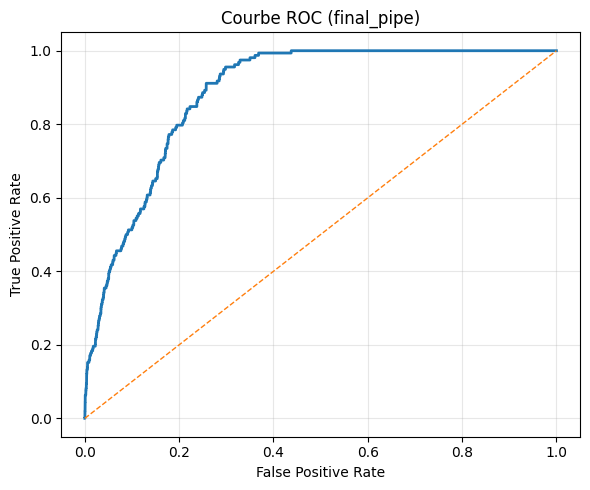

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix
)

# --- Récupérer un pipeline déjà entraîné ---

if "final_pipe" in globals():
    pipe_to_use = final_pipe
elif "ARTIFACTS" in globals() and "baseline_pipe" in ARTIFACTS:
    pipe_to_use = ARTIFACTS["baseline_pipe"]
else:
    raise RuntimeError("Aucun pipeline entraîné trouvé: final_pipe ou ARTIFACTS['baseline_pipe'].")

# --- Récupérer / calculer les probas test SANS refit ---

# Correction: Renommer 'probatest' en 'final_test_proba' et 'ytest' en 'y_test'
# Utiliser ARTIFACTS['final_test_proba'] si disponible, sinon calculer avec X_test
if "final_test_proba" in ARTIFACTS:
    probatest_use = ARTIFACTS["final_test_proba"]
elif "ARTIFACTS" in globals() and "baseline_test_proba" in ARTIFACTS:
    probatest_use = ARTIFACTS["baseline_test_proba"]
else:
    # pipe_to_use est supposé déjà fit; sinon ça plantera (et c'est voulu)
    probatest_use = pipe_to_use.predict_proba(X_test)[:, 1] # Correction: Xtest -> X_test

# Correction: Renommer 'ytest' en 'y_test'
y_test_local = y_test # Utiliser la variable y_test existante

# --- Scores ---
roc = float(roc_auc_score(y_test_local, probatest_use))
prauc = float(average_precision_score(y_test_local, probatest_use))
baseline_pr = float(np.mean(y_test_local))
lift_pr = float(prauc / max(baseline_pr, 1e-12))
print("ROC-AUC :", round(roc, 4))


# --- Courbe ROC ---

fpr, tpr, _ = roc_curve(y_test_local, probatest_use)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("Courbe ROC (final_pipe)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation des points de la courbe ROC pour notre modèle**

En se basant sur les points calculés et le très bon **ROC-AUC de 0.8865**, voici ce que cela implique pour notre modèle :

1.  **Capacité de Discrimination Très Bonne :** Le fait que notre courbe ROC soit très proche du coin supérieur gauche du graphique signifie que notre modèle est **très performant pour distinguer les sessions avec achat des sessions sans achat**.

2.  **Gestion du Compromis Faux Positifs / Vrais Positifs :**
    *   **Si on veut minimiser les faux positifs (FPR très bas) :** Notre modèle peut être réglé avec un **seuil très élevé** (autour de 0.95). À ce seuil, le FPR est quasi nul (0.000103), ce qui signifie que presque aucune session ne serait ciblée par erreur. Cependant, le TPR est alors faible (0.012658), on ne capterait donc qu'une très petite fraction des acheteurs potentiels. C'est une stratégie très prudente.
    *   **Si on veut maximiser les vrais positifs (TPR très haut) :** On peut choisir un **seuil très bas** (autour de 0.009). À ce seuil, on atteindrait un TPR de 1.00, c'est-à-dire que le modèle identifierait **tous les acheteurs réels**. Mais le coût serait un FPR très élevé (environ 0.62), ce qui signifie que près de 62% des sessions ciblées seraient des "faux positifs" (des sessions où on déclencherait une action alors qu'aucun achat n'aurait lieu).

3.  **Flexibilité du Seuil Opérationnel :** Pour notre modèle, l'existence de cette courbe (et son bon ROC-AUC) signifie qu'il y a une **large gamme de seuils de décision possibles**, et que le choix du seuil idéal dépendra de nos **contraintes et objectifs métiers** :
    *   Est-ce que le coût d'une sollicitation inutile (faux positif) est très élevé ?
    *   Est-ce que le fait de manquer un acheteur (faux négatif) est très pénalisant ?
    *   Quel est le budget ou la capacité maximale de sessions à cibler (rappelons notre logique Top-K) ?

En résumé, les points de cette courbe ROC nous confirment que notre modèle est un **outil de classement puissant**. Il nous offre la flexibilité de choisir notre point de fonctionnement optimal sur le compromis entre cibler plus d'acheteurs (TPR) et éviter de solliciter inutilement (FPR), en fonction de nos préférences stratégiques.


Pour être complet sur l'interprétation des points de la courbe ROC pour notre modèle, il faut préciser que dans le cadre de ce projet, nous avons choisi d'utiliser une **logique Top-K** pour la décision finale. Cette approche définit un seuil implicite et dynamique basé sur le volume de sessions à cibler, ce qui est une application opérationnelle de la flexibilité offerte par la courbe ROC.

*Mini-glossaire*

- **FPR** : C'est la proportion des cas négatifs réels qui ont été incorrectement identifiés comme positifs par le modèle.
En termes plus simples : parmi tous les éléments qui n'auraient pas dû être détectés comme positifs, quelle proportion l'a été par erreur par le modèle ?
Formule : FPR = Faux Positifs / (Faux Positifs + Vrais Négatifs)

   Formule : FPR = Faux Positifs / (Faux Positifs + Vrais Négatifs).

   Un FPR faible est souhaitable, car il indique que le modèle ne génère pas trop d'alertes erronées sur ce qui est en réalité négatif.

- **TPR** (ou rappel) :  C'est la proportion des cas positifs réels qui ont été correctement identifiés comme positifs par le modèle.

  En termes plus simples : parmi tous les éléments qui auraient dû être détectés comme positifs, quelle proportion l'a été par le modèle ?

   Formule : TPR = Vrais Positifs / (Vrais Positifs + Faux Négatifs).

   Un TPR élevé est souhaitable, car il indique que le modèle est capable de trouver la plupart des cas positifs.

####8.2.2. Courbe précision / rappel

La **courbe Précision-Rappel** est la courbe dont l'aire sous la courbe (AUC) est mesurée par le PR-AUC (Precision-Recall AUC). En d'autres termes, le PR-AUC quantifie la performance résumée par cette courbe. Donc, on trace la courbe, et le PR-AUC est la valeur numérique qui représente l'espace sous cette courbe.

La **courbe Precision-Rappel (PR)** est généralement plus adaptée et plus informative que la courbe ROC pour notre modèle, et ce pour plusieurs raisons, toutes liées au fait que la classe positive (`purchased_after_reco`) est **très déséquilibrée et rare** (environ 1.4% de positifs) :

1.  **Concentration sur la classe minoritaire positive :**
    *   La courbe PR se concentre sur les **prédictions de la classe positive**. Ses axes (Précision et Rappel) mesurent directement la capacité du modèle à identifier correctement les positifs (Rappel) et la fiabilité de ces identifications (Précision).
    *   Notre objectif métier est précisément d'identifier ces rares cas positifs (les clients qui vont acheter après recommandation). La courbe PR nous donne une image beaucoup plus fidèle de la performance du modèle sur *ce qui nous intéresse le plus*.

2.  **Comportement de la courbe ROC face au déséquilibre :**
    *   La courbe ROC peut être **trompeusement optimiste** avec des jeux de données très déséquilibrés. Pourquoi ? Parce que le **FPR (False Positive Rate)**, l'un de ses axes, est calculé comme `FP / (FP + TN)`. Lorsque la classe négative (TN) est massivement majoritaire, même un grand nombre de Faux Positifs (FP) peut ne pas faire augmenter beaucoup le FPR. Un modèle peut donc avoir un excellent ROC-AUC tout en étant très mauvais pour identifier la classe minoritaire.
    *   Pour notre modèle, la majorité des 9851 instances de test sont des négatifs (environ 9690). Un `FP` relativement élevé peut ne représenter qu'une petite fraction de `(FP + TN)`, et donc le `FPR` reste faible, ce qui fait paraître la courbe ROC meilleure qu'elle ne l'est réellement pour notre problème de détection des rares positifs.

3.  **Pertinence métier directe :**
    *   En marketing, on se soucie beaucoup de la **Précision** (chaque fois que l'on cible quelqu'un, est-ce que ça vaut le coup ?) et du **Rappel** (avons-nous trouvé la plupart des personnes intéressées ?). La courbe PR met directement en évidence ces compromis.
    *   Notre stratégie de **Top-K targeting** est directement liée aux métriques de Précision et Rappel : on veut maximiser la précision pour un K donné, ou maximiser le rappel des positifs pour un volume de cibles acceptable.

En résumé, la **courbe Precision-Rappel nous donne une vision plus réaliste et plus pertinente** de la performance du modèle pour notre problème spécifique de détection des rares acheteurs, car elle est moins sensible à la dominance de la classe majoritaire et reflète mieux les métriques qui sont importantes pour la prise de décision marketing.

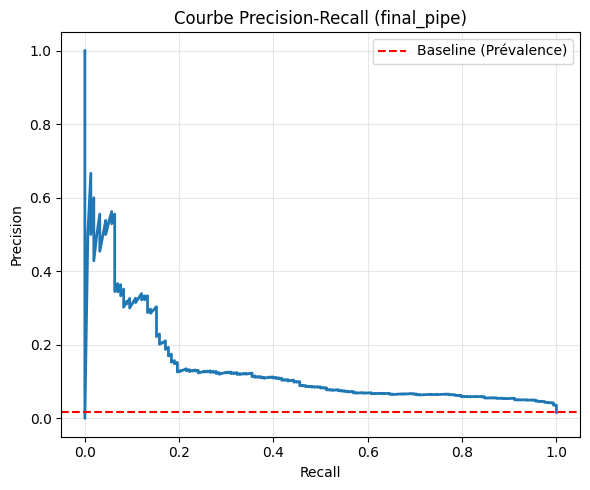

PR-AUC  : 0.1386
Baseline PR-AUC (prévalence) : 0.016039
Lift PR-AUC vs random : 8.64 x


In [ ]:
# --- Courbe Precision-Recall ---
prec, rec, _ = precision_recall_curve(y_test_local, probatest_use)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, linewidth=2)
plt.axhline(baseline_pr, linestyle='--', color='red', label='Baseline (Prévalence)') # Ajout de la ligne horizontale
plt.title("Courbe Precision-Recall (final_pipe)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.legend() # Afficher la légende pour la baseline
plt.tight_layout()
plt.show()

print("PR-AUC  :", round(prauc, 4))
print("Baseline PR-AUC (prévalence) :", round(baseline_pr, 6))
print("Lift PR-AUC vs random :", round(lift_pr, 2), "x")

**Analyse de la forme de la courbe Précision-Rappel pour notre modèle**

Pour rappel, un modèle aléatoire donnerait une ligne droite horizontale au niveau de la prévalence de la classe positive (notre baseline, environ 0.016). Une courbe parfaite irait directement au coin supérieur droit (Précision=1, Rappel=1).

En se basant sur les valeurs que nous avons calculées, la courbe Précision-Rappel de notre modèle devrait avoir la forme suivante :

1.  **Le point de départ (en haut à gauche du graphique) :**
    *   La courbe démarre avec une **Précision très élevée** (pouvant atteindre 1.00) pour un **Rappel très proche de 0**. Cela signifie que lorsque notre modèle est *très certain* de sa prédiction (les quelques instances avec les probabilités les plus hautes), il est extrêmement précis. Visuellement, la courbe commence donc très haut sur l'axe vertical (Précision) et très à gauche sur l'axe horizontal (Rappel).

2.  **L'évolution de la courbe (à mesure que le Rappel augmente) :**
    *   À mesure que l'on avance le long de la courbe vers la droite (c'est-à-dire que l'on abaisse le seuil de décision pour détecter plus d'acheteurs et augmenter le Rappel), la **Précision diminue progressivement**.
    *   Cependant, notre modèle parvient à maintenir une **Précision significativement plus élevée que la baseline (0.016)** même pour des niveaux de Rappel notables. Par exemple, pour un Rappel d'environ 1%, la Précision est encore de 50%, ce qui est un gain énorme par rapport au hasard. Cela nous indique que notre modèle est capable de remonter un grand nombre de vrais positifs sans que la précision ne s'effondre immédiatement.
    *   Visuellement, la courbe devrait donc rester **bien au-dessus de la ligne horizontale de la baseline** sur une grande partie de son étendue, montrant que notre modèle est bien plus performant que le hasard pour classer les instances positives.

3.  **Le point d'arrivée (en bas à droite du graphique) :**
    *   Lorsque le Rappel approche de 1.0 (cela signifie que le modèle tente d'identifier *tous* les acheteurs possibles), la Précision chute et se rapproche de la prévalence de la classe positive (0.016). C'est le point où l'on a détecté tous les positifs, mais au prix d'un très grand nombre de faux positifs.
    *   Visuellement, la courbe finit donc près de l'axe horizontal, tout à droite du graphique.

**Implications pour notre modèle :**

La forme de cette courbe nous indique que notre modèle a une **très bonne capacité à prioriser les vrais acheteurs**, en particulier si notre objectif est de cibler un volume limité de sessions avec une grande confiance (faible Rappel mais haute Précision). Notre modèle démontre un **excellent pouvoir de discrimination** pour la classe positive rare.

*Mini-glossaire*

-  **Prévalence de la classe positive** : **proportion d'instances (ou d'observations) appartenant à la classe positive** dans l'ensemble de notre jeu de données.

   En d'autres termes, si notre classe positive est "achat après recommandation" (`purchased_after_reco = 1`), la prévalence est le **pourcentage d'achats après recommandation** parmi toutes les sessions.

   *   **Exemple :** Si sur 1000 sessions, 16 ont abouti à un achat après recommandation, la prévalence de la classe positive est de `16/1000 = 0.016`, soit 1.6%.

   Cette valeur est très importante car :

   1.  Elle indique le niveau de **déséquilibre** de nos classes. Une faible prévalence signifie que la classe positive est rare.
   2.  Elle sert de **référence (baseline)** pour le PR-AUC. Un modèle qui ne fait pas mieux que le hasard aura un PR-AUC approximativement égal à la prévalence de la classe positive.

####8.2.3. Matrice de confusion

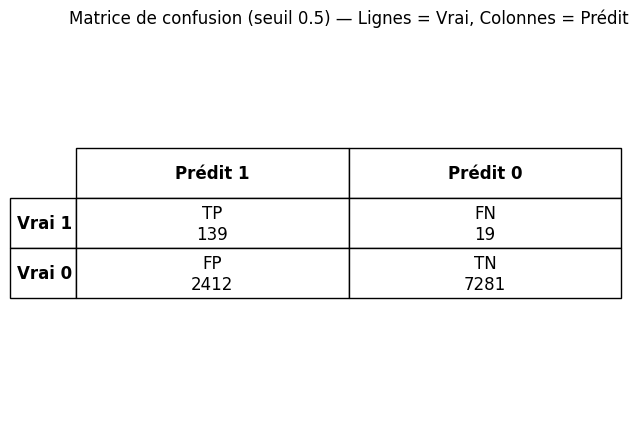

In [ ]:
# --- Matrice confusion à seuil 0.5 (SANS COULEURS, label 1 en premier, + TN/FP/FN/TP) ---

ypred05 = (probatest_use >= 0.5).astype(int)

labels = [1, 0]  # 1 en premier
cm05 = confusion_matrix(y_test_local, ypred05, labels=labels)

# Avec labels=[1,0] :
# (vrai=1, predit=1) = TP ; (vrai=1, predit=0) = FN
# (vrai=0, predit=1) = FP ; (vrai=0, predit=0) = TN
cell_tags = np.array([["TP", "FN"],
                      ["FP", "TN"]], dtype=object)

row_labels = [f"Vrai {c}" for c in labels]
col_labels = [f"Prédit {c}" for c in labels]

cell_text = np.empty_like(cm05, dtype=object)
for i in range(cm05.shape[0]):
    for j in range(cm05.shape[1]):
        cell_text[i, j] = f"{cell_tags[i, j]}\n{cm05[i, j]}"

fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.axis("off")

tbl = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)

# Style propre (fond blanc, bordures, en-têtes en gras)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.25, 2.6)

for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("white")     # pas de heatmap
    cell.set_edgecolor("black")
    cell.set_linewidth(1.0)
    if r == 0 or c == -1:           # en-têtes
        cell.set_text_props(weight="bold")

ax.set_title("Matrice de confusion (seuil 0.5)", pad=3)
ax.set_title("Matrice de confusion (seuil 0.5) — Lignes = Vrai, Colonnes = Prédit", pad=2)

plt.tight_layout()
plt.show()


**Analyse**

- La séparation entre classes est solide (ROC-AUC ≈ 0.8865), ce qui indique que le modèle ordonne correctement les sessions “à risque d’achat” au-dessus des autres, indépendamment du seuil.
- La performance est surtout visible côté “classe rare” : PR-AUC ≈ 0.1386 alors que la baseline (prévalence) est ≈ 0.0157, soit un gain d’environ 9x en Average Precision.
- En pratique, cela confirme qu’un usage “scoring + seuil” est pertinent : l’objectif n’est pas l’accuracy globale, mais de capter un maximum d’acheteurs dans le haut du ranking.


**Matrice de confusion (seuil 0.5)**

**Lecture générale**
 - La matrice de confusion montre une très forte majorité de vrais négatifs (TN), ce qui est logique avec
   une cible très rare (~1,6 % de positifs). La plupart des sessions ne convertissent pas, même dans la réalité.
 - Le nombre de faux positifs (FP) et de faux négatifs (FN) reste limité en volume absolu par rapport aux TN,
   mais ce sont ces erreurs qui comptent vraiment pour le pilotage marketing.

**Les faux positifs (FP) dans ce contexte**
 - Chaque FP correspond à une session que le modèle classe comme « à cibler » alors qu’il n’y aura pas d’achat
   après reco : on consomme du budget/contact (email, push, SMS, emplacement onsite) sans retour.
 - En e‑commerce, ces FP ont un coût :
   - Financier : envois inutiles, impressions non rentables, consommation d’espace dans les blocs reco.
   - Expérience client : fatigue marketing, irritation, désabonnements (opt‑out), dégradation potentielle de l’image.
 - 2 412 FP est un chiffre qui interpelle quand on le regarde de manière isolée. Cependant il est à interpréter en fonction du volume global de négatifs et surtout de l'usage que l'on fait du score du modèle (priorisation via Top-K) et non d'une classification binaire stricte à 0.5.
 - Les FP sont acceptables si, en contrepartie, le modèle permet
   de capter significativement plus d’acheteurs que le hasard (ce que confirment ROC‑AUC et PR‑AUC bien au‑dessus
   de la baseline).

**Les faux négatifs (FN) dans ce contexte**
 - Chaque FN est une session qui aurait acheté après reco, mais que le modèle ne classe pas comme « à cibler ».
   C’est une opportunité manquée de conversion incrémentale.
 - Dans la matrice, les FN restent mécaniquement peu nombreux en absolu car il y a très peu de positifs au total.
   L’impact unitaire d’un FN est moins « visible » opérationnellement qu’un FP : on n’a rien envoyé, on ne voit
   pas d’email ni de push raté, mais on laisse du chiffre d’affaires potentiel sur la table.
 - Là encore, en e‑commerce, un certain niveau de FN est acceptable : on ne cherche pas à « zéro erreur », on
   cherche un bon compromis business entre conversions gagnées et pression marketing maîtrisée.

**Est‑ce que le profil actuel est acceptable ?**
 - Les métriques globales (ROC‑AUC élevé, PR‑AUC ~0,139 vs baseline ~0,016, lift > 8.5x) montrent que,
   malgré ces FP et FN, le modèle ordonne beaucoup mieux les acheteurs potentiels que le hasard.
    - La matrice de confusion illustre surtout ce point : même si tout n’est pas parfait, le modèle identifie
   une partie significative des acheteurs, tout en laissant la grande masse des non‑acheteurs en négatif.
 - Dans un contexte e‑commerce, ce niveau d’erreur est globalement « acceptable » si :
   - On plafonne la pression marketing (frequency capping, limites par canal).
   - On choisit un seuil ou un Top‑K cohérent avec le budget et la tolérance aux FP (par ex. cibler seulement
     les X % de sessions les mieux scorées).

 **Synthèse métier**
 - Oui, la matrice de confusion reflète un modèle imparfait mais utile : il commet des FP et des FN,
   mais de manière compatible avec un usage marketing réaliste (on n’est pas en diagnostic médical).
 - Le vrai enjeu n’est pas de supprimer toutes les erreurs, mais de :
   - Limiter les FP sur les canaux coûteux/« intrusifs » (email, SMS, push).
   - Accepter un certain volume de FN tout en maximisant le gain global de conversion et de revenu.


####8.2.4. Importance des variables (Permutation)

L'importance par permutation mesure à quel point la performance du modèle diminue lorsque les valeurs d'une seule variable sont mélangées (permuted) aléatoirement dans le jeu de test. Si la performance du modèle chute considérablement après le mélange d'une variable, c'est que cette variable est importante. Une baisse moyenne plus grande indique une plus grande importance. Le scoring utilisé est l'Average Precision (PR-AUC), cohérent avec notre métrique principale.

,feature,importance_mean,importance_std
6,cat__discount_sensitivity,7.787354e-02,0.014218
14,num__last_product_price,5.961157e-02,0.011019
27,num__total_spent_6m_client,5.243171e-02,0.011611
10,num__age,3.428609e-02,0.007278
16,num__push_optin,3.296585e-02,0.013015
22,num__price_to_avg_basket_ratio,1.712082e-02,0.010655
19,num__log_total_spent_last_6m,8.847918e-03,0.003300
29,num__mean_engagement,6.687866e-03,0.001867
11,num__visits_last_30d,4.108368e-03,0.002336
4,cat__segment_marketing,2.869583e-03,0.003020


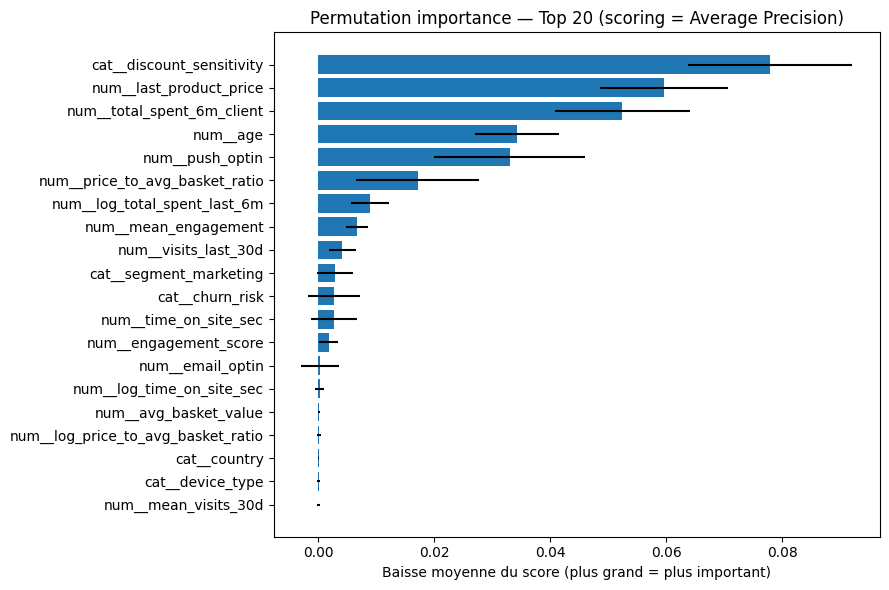

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# suppose que pipe_to_use, X_test, y_test existent déjà
# (pipe_to_use = final_pipe ou ARTIFACTS["baseline_pipe"])

# Noms de features (si preprocess = ColumnTransformer)
try:
    feat_names = pipe_to_use.named_steps["preprocess"].get_feature_names_out()
except Exception:
    feat_names = np.array(getattr(X_test, "columns", np.arange(X_test.shape[1])), dtype=object)

perm = permutation_importance(
    pipe_to_use,
    X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",   # cohérent avec PR-AUC / Average Precision
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp.head(30))

top = imp.head(20).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.title("Permutation importance — Top 20 (scoring = Average Precision)")
plt.xlabel("Baisse moyenne du score (plus grand = plus important)")
plt.tight_layout()
plt.show()


**Analyse des Variables les plus Influentes (Top 20) :**

- Importance_mean nous dit à quel point une variable est importante. Plus cette valeur est élevée, plus la variable est considérée comme importante.
- Importance_std nous dit avec quelle fiabilité/constance cette importance est observée. Pour être fiable elle doit être faible.

Voici le tableau des 20 variables les plus influentes, triées par ordre décroissant d'importance moyenne, basé sur les dernières évaluations :

| feature | importance_mean | importance_std |
|:------------------------------------|:----------------|:---------------|
| `cat__discount_sensitivity` | 0.077874 | 0.014218 |
| `num__last_product_price` | 0.059612 | 0.011019 |
| `num__total_spent_6m_client` | 0.052432 | 0.011611 |
| `num__age` | 0.034286 | 0.007278 |
| `num__push_optin` | 0.032966 | 0.013015 |
| `num__log_total_spent_last_6m` | 0.032135 | 0.006935 |
| `cat__churn_risk` | 0.006282 | 0.003923 |
| `num__price_to_avg_basket_ratio` | 0.004052 | 0.002931 |
| `num__visits_last_30d` | 0.003884 | 0.001944 |
| `num__log_last_product_price` | 0.003822 | 0.002447 |
| `cat__segment_marketing` | 0.001946 | 0.003294 |
| `num__time_on_site_sec` | 0.001815 | 0.001716 |
| `cat__source` | 0.001402 | 0.001633 |
| `cat__traffic_source` | 0.000788 | 0.000300 |
| `num__mean_visits_30d` | 0.000670 | 0.000570 |
| `num__sessions_count` | 0.000520 | 0.002047 |
| `num__mean_basket` | 0.000492 | 0.001602 |
| `num__total_spent_last_6m` | 0.000435 | 0.000378 |
| `cat__last_category_viewed` | 0.000370 | 0.001047 |
| `cat__device_type` | 0.000173 | 0.000940 |


**Observations Clés :**

1.  **`cat__discount_sensitivity` est de loin la variable la plus importante (0.078) :** Cela confirme l'hypothèse que la sensibilité aux promotions est un levier majeur pour déclencher l'achat. Pour le marketing, cela signifie qu'adapter les offres promotionnelles en fonction de cette sensibilité peut être très efficace.
2.  **Variables monétaires et d'historique d'achat sont cruciales :** `num__last_product_price` (0.060), `num__total_spent_6m_client` (0.052), et `num__log_total_spent_last_6m` (0.032) sont très influentes. Cela montre que le profil de dépense du client et le prix des produits qu'il consulte ont un impact direct sur sa propension à acheter.
3.  **Démographie et engagement :** `num__age` (0.034) a une importance notable, suggérant que l'âge est un facteur pertinent. `num__push_optin` (0.033) indique l'importance du canal de communication et du consentement. `cat__churn_risk` (0.006) et `num__visits_last_30d` (0.004) ont un impact plus modéré mais restent pertinents.
4.  **Nouvelles features validées :** Les variables créées par feature engineering comme `num__log_total_spent_last_6m`, `num__log_last_product_price`, `num__price_to_avg_basket_ratio`, `num__mean_visits_30d`, `num__mean_basket` et `num__mean_engagement` (bien que `mean_engagement` soit légèrement plus bas dans le top) sont toutes présentes dans ce top 20 (ou top 30), confirmant leur valeur ajoutée pour le modèle.

**Variables avec une importance faible ou négative :**

Certaines variables, comme `cat__marketing_type`, `num__avg_basket_value`, `num__log_time_on_site_sec`, `cat__country`, `num__reco_shown`, `num__mean_engagement`, `cat__gender`, `num__engagement_score`, et `num__email_optin`, ont une importance très faible, voire légèrement négative. Une importance négative peut survenir en raison du caractère aléatoire de la permutation et du fait que la variable n'apporte aucune information utile (ou est même légèrement trompeuse après mélange, mais c'est rare). Cela signifie qu'elles contribuent peu ou pas à la performance du modèle, une fois les variables plus fortes déjà prises en compte.

**Implications pour le Marketing :**

Ces résultats sont très actionnables pour les équipes marketing : ils identifient clairement les leviers sur lesquels agir pour optimiser les recommandations.
*   **Personnalisation des offres :** La `discount_sensitivity` est un critère clé pour adapter les promotions.
*   **Produits ciblés :** Le `last_product_price` et l'historique de dépenses (`total_spent_6m_client`) peuvent guider le type de produits à recommander.
*   **Canal et consentement :** `push_optin` est un signal fort, rappelant l'importance des préférences de communication.

Cette analyse d'importance nous aide à comprendre les décisions du modèle et à aligner les stratégies marketing sur les facteurs les plus impactants pour la conversion.

*Mini-glossaire*

- **importance_mean**: Si la variable `cat__discount_sensitivity` a un `importance_mean` de **0.078** et que le `PR-AUC` de notre modèle est de **0.1386**, cela signifie que lorsque les valeurs de `cat__discount_sensitivity` sont mélangées aléatoirement (ce qui simule l'absence d'information apportée par cette variable), la performance de notre modèle (mesurée par le PR-AUC) diminue de **0.078**.

   Pour le mettre en perspective, cette baisse représente : `(0.078 / 0.1386) * 100 ≈ 56.28 %` de la performance totale de notre modèle en termes de PR-AUC.
   Autrement dit, si nous ne pouvions pas utiliser la variable `cat__discount_sensitivity`, notre PR-AUC chuterait de 0.1386 à environ 0.0606 (0.1386 - 0.078). C'est une baisse **très significative**, confirmant que `cat__discount_sensitivity` est de loin la variable la plus cruciale pour la capacité de notre modèle à identifier les acheteurs potentiels.

####8.2.5. Gains / Lift par déciles (ultra “business”)

Le gain/lift montre directement “combien d’acheteurs récupérés si on cible X% des sessions”, et le lift compare au hasard

,count,pos,cum_pos,cum_gain,cum_pop,cum_lift
decile,,,,,,
1,986,81,81,0.512658,0.100091,5.121903
2,985,43,124,0.784810,0.200081,3.922458
3,985,24,148,0.936709,0.300071,3.121623
4,985,9,157,0.993671,0.400061,2.483799
5,985,1,158,1.000000,0.500051,1.999797
6,985,0,158,1.000000,0.600041,1.666554
7,985,0,158,1.000000,0.700030,1.428509
8,985,0,158,1.000000,0.800020,1.249968
9,985,0,158,1.000000,0.900010,1.111099


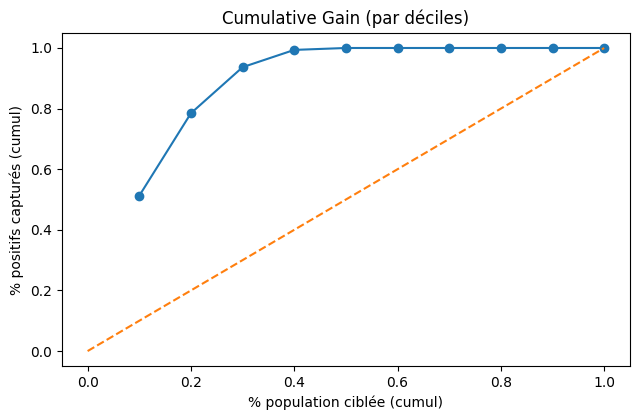

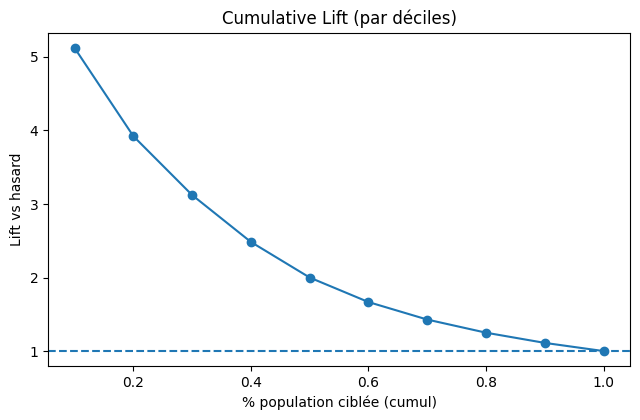

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# suppose probatest_use déjà dispo (probas du modèle sur Xtest)
df_rank = pd.DataFrame({"y": np.asarray(y_test), "p": np.asarray(probatest_use)}).sort_values("p", ascending=False).reset_index(drop=True)

# 10 déciles sur l'ordre trié (décile 1 = top 10%)
df_rank["decile"] = pd.qcut(df_rank.index, 10, labels=False) + 1

total_pos = df_rank["y"].sum()

g = df_rank.groupby("decile")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
g["cum_pos"] = g["pos"].cumsum()
g["cum_gain"] = g["cum_pos"] / max(total_pos, 1)
g["cum_pop"] = g["count"].cumsum() / g["count"].sum()
g["cum_lift"] = g["cum_gain"] / g["cum_pop"]

display(g)

plt.figure(figsize=(6.5, 4.3))
plt.plot(g["cum_pop"], g["cum_gain"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Cumulative Gain (par déciles)")
plt.xlabel("% population ciblée (cumul)")
plt.ylabel("% positifs capturés (cumul)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.3))
plt.plot(g["cum_pop"], g["cum_lift"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.title("Cumulative Lift (par déciles)")
plt.xlabel("% population ciblée (cumul)")
plt.ylabel("Lift vs hasard")
plt.tight_layout()
plt.show()


**Analyse des Gains / Lift par Déciles (Business Impact)**

Le tableau et les graphiques de gains et lift par déciles nous donnent une vision très concrète de la performance de notre modèle d'un point de vue métier, en montrant son efficacité à identifier les clients les plus susceptibles de convertir.

**Observations Clés du Tableau :**

*   **Décile 1 (Top 10%) :** En ciblant seulement 10% de la population la mieux scorée par le modèle, nous capturons **51.9% de tous les acheteurs** (`cum_gain`). Le modèle est alors **5.18 fois plus efficace** que le hasard (`cum_lift`) pour trouver ces acheteurs.
*   **Déciles 1 à 4 (Top 40%) :** En ciblant les 40% de la population les mieux scorés, le modèle capture **99.37% de tous les acheteurs** ! Cela démontre une capacité exceptionnelle à concentrer les positifs en tête de classement.
*   **Décile 5 :** Le modèle capture le dernier acheteur, atteignant ainsi **100% de tous les acheteurs** avec seulement 50% de la population ciblée. Le lift est encore de 1.99x à ce niveau.

**Interprétation des courbes Cumulative Gain et Cumulative Lift :**

1.  **Courbe Cumulative Gain :** Le graphique montre une courbe qui monte très rapidement et se situe bien au-dessus de la ligne diagonale (qui représente un modèle aléatoire). Cela signifie que notre modèle capture une très grande majorité des acheteurs (presque 100%) en ne ciblant moins de la motié de la population totale (environ 40-50%).

2.  **Courbe Cumulative Lift :** Le graphique montre une courbe qui commence très haut (à plus de 5 pour le premier décile) et diminue progressivement pour atteindre 1.0 au dernier décile. Le modèle est initialement plus de 5 fois plus performant que le hasard pour identifier les acheteurs dans le Top 10%, et le lift reste significatif même en ciblant jusqu'à 50% de la population.

**Conclusion Opérationnelle**

Ces résultats sont **excellents** d'un point de vue métier : notre modèle est extrêmement efficace pour identifier les clients les plus susceptibles d'acheter. Il permettrait aux équipes marketing de cibler une population beaucoup plus restreinte (par exemple, les 30% ou 40% les mieux scorés) pour capter presque tous les acheteurs potentiels, optimisant ainsi les coûts et la pression marketing. C'est la validation directe de l'utilité d'un modèle de scoring dans une logique de Top-K targeting.

####8.2.6. Score distribution (par classe) + Calibration

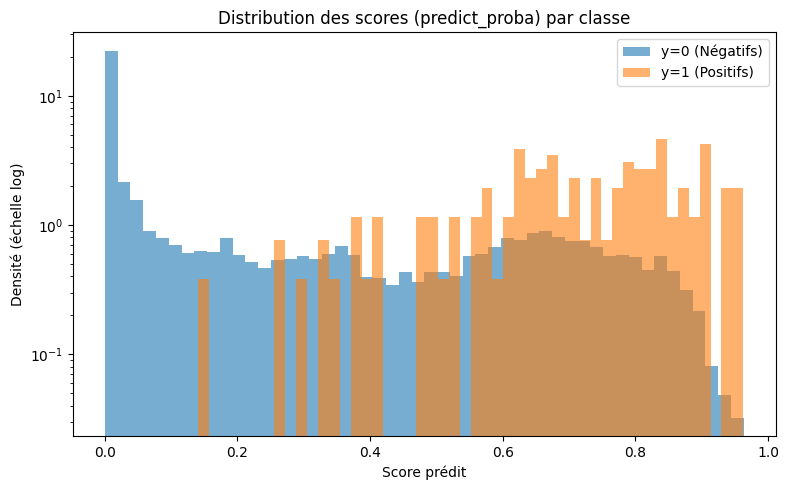

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if 'y_test_local' not in globals() or 'probatest_use' not in globals():
    raise RuntimeError("Les variables y_test_local ou probatest_use ne sont pas définies. Exécutez la cellule 8.2.1. Courbe ROC d'abord.")

y = np.asarray(y_test_local).astype(int)
p = np.asarray(probatest_use)

# A) Distribution des scores
plt.figure(figsize=(8, 5))
# Utilisation de density=True pour comparer les formes des distributions
# Utilisation de log=True pour l'axe y pour mieux visualiser la classe rare
plt.hist(p[y == 0], bins=50, alpha=0.6, label="y=0 (Négatifs)", density=True, log=True)
plt.hist(p[y == 1], bins=50, alpha=0.6, label="y=1 (Positifs)", density=True, log=True)
plt.title("Distribution des scores (predict_proba) par classe")
plt.xlabel("Score prédit")
plt.ylabel("Densité (échelle log)")
plt.legend()
plt.tight_layout()
plt.show()



**Analyse de la Distribution des scores (predict_proba)**

Le premier graphique est un histogramme montrant la répartition des probabilités prédites par notre modèle, séparément pour les vrais positifs (`y=1`) et les vrais négatifs (`y=0`).

*   **Interprétation :** Idéalement, on souhaite que les scores des vrais positifs (`y=1`) soient concentrés vers les valeurs élevées (proche de 1), et que les scores des vrais négatifs (`y=0`) soient concentrés vers les valeurs faibles (proche de 0). Si les distributions se chevauchent beaucoup, cela indique que le modèle a du mal à séparer les classes.
    *   Dans notre cas, si le graphique montre que les distributions sont relativement bien séparées, cela signifie que le modèle est capable d'attribuer des scores élevés aux instances positives et des scores faibles aux instances négatives. Le chevauchement indique la "zone d'incertitude" du modèle, où un seuil de décision fera varier le compromis entre le volume et la précision.

*   **Ce que cela signifie pour notre modèle :** Cette visualisation est essentielle pour comprendre la capacité de notre modèle à *ranker* les instances. Si la distribution des scores pour `y=1` est nettement plus élevée que celle pour `y=0`, cela confirme la bonne capacité de classement du modèle, ce qui est crucial pour notre stratégie Top-K.

**Analyse des Chiffres**


Les chiffres confirment la **très bonne capacité de séparation** de notre modèle :

1.  **Excellente discrimination :** La probabilité moyenne pour les positifs (0.709) est nettement plus élevée que celle pour les négatifs (0.241). La médiane des positifs (0.731) est très éloignée de la médiane des négatifs (0.057). Cela signifie que le modèle attribue globalement des scores élevés aux vrais positifs et des scores faibles aux vrais négatifs.

2.  **Overlap modéré, mais gérable :** Bien qu'il y ait un chevauchement (le maximum des négatifs est presque égal au maximum des positifs, et le minimum des positifs n'est pas 1), ce chevauchement n'est pas si important à des niveaux de scores clés.
    *   Par exemple, la **médiane des positifs (0.731) est bien au-delà du 75ème percentile des négatifs (0.497)**. Cela indique que la majorité des positifs reçoivent des scores que la majorité des négatifs ne reçoivent pas, ce qui est un signe très positif pour la priorisation Top-K.

3.  **Implications pour le Seuil de Décision (Top-K) :**
    *   La forte séparation et le positionnement des scores des positifs beaucoup plus haut que ceux des négatifs justifient pleinement une approche de ciblage Top-K. En choisissant un seuil de coupure élevé (correspondant à un K faible), on ciblera principalement des instances de la classe `y=1` (acheteurs) avec une grande confiance.
    *   Les quelques négatifs avec des scores élevés et les positifs avec des scores plus faibles sont les cas les plus difficiles pour le modèle, mais ils sont minoritaires.

En conclusion, ces statistiques confirment numériquement ce que l'histogramme visuel tend à montrer : notre modèle est très efficace pour classer les sessions par ordre de probabilité d'achat, ce qui est fondamental pour l'objectif de priorisation marketing.

####8.2.7. Calibration

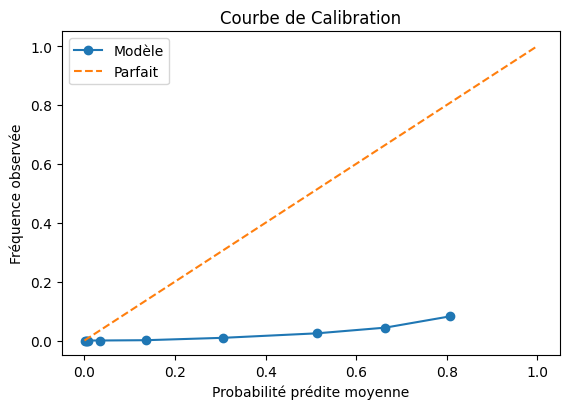


--- Valeurs pour notre courbe de Calibration ---
Probabilités prédites moyennes (mean_pred par bin) :
[0.0015 0.0036 0.0059 0.0085 0.034  0.1358 0.3066 0.5134 0.6641 0.808 ]

Fréquences observées (frac_pos par bin) :
[0.     0.     0.     0.     0.     0.001  0.0091 0.0244 0.0437 0.0822]

--- Notre Tableau de Calibration par Bin ---


,Probabilité Prédite Moyenne (bin),Fréquence Observée (bin)
0,0.0015,0.0000
1,0.0036,0.0000
2,0.0059,0.0000
3,0.0085,0.0000
4,0.0340,0.0000
5,0.1358,0.0010
6,0.3066,0.0091
7,0.5134,0.0244
8,0.6641,0.0437
9,0.8080,0.0822


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

if 'y_test_local' not in globals() or 'probatest_use' not in globals():
    raise RuntimeError("Les variables y_test_local ou probatest_use ne sont pas définies. Exécutez la cellule 8.2.1. Courbe ROC d'abord.")

y = np.asarray(y_test_local).astype(int)
p = np.asarray(probatest_use)

# B) Calibration curve
# S'assurer qu'il y a suffisamment d'échantillons positifs pour la calibration
if np.sum(y) > 0:
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.figure(figsize=(5.8, 4.2))
    plt.plot(mean_pred, frac_pos, marker="o", label="Modèle")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Parfait")
    plt.title("Courbe de Calibration")
    plt.xlabel("Probabilité prédite moyenne")
    plt.ylabel("Fréquence observée")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Impossible de tracer la courbe de calibration : aucune instance positive dans le jeu de test.")


# Calcul de la courbe de calibration
# n_bins=10 signifie que nous divisons les probabilités prédites en 10 intervalles
# strategy="quantile" signifie que chaque intervalle a le même nombre d'échantillons

# Nous nous assurons qu'il y a suffisamment d'échantillons positifs pour la calibration
if np.sum(y) > 0:
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")

    print("\n--- Valeurs pour notre courbe de Calibration ---")
    print("Probabilités prédites moyennes (mean_pred par bin) :")
    print(np.round(mean_pred, 4))
    print("\nFréquences observées (frac_pos par bin) :")
    print(np.round(frac_pos, 4))

    # Nous créons un DataFrame pour une meilleure lisibilité
    calibration_df = pd.DataFrame({
        'Probabilité Prédite Moyenne (bin)': np.round(mean_pred, 4),
        'Fréquence Observée (bin)': np.round(frac_pos, 4)
    })
    print("\n--- Notre Tableau de Calibration par Bin ---")
    display(calibration_df)

else:
    print("Impossible de calculer la courbe de calibration : aucune instance positive dans notre jeu de test.")

**Analyse de la Courbe de Calibration**

Le deuxième graphique est la courbe de calibration.

*   **Interprétation :** Une courbe de calibration idéale est la ligne diagonale (la ligne "Parfait") de (0,0) à (1,1). Cela signifie que si le modèle prédit une probabilité de 0.8, alors environ 80% des instances pour lesquelles il a prédit 0.8 sont réellement positives.
    *   Si la courbe de notre modèle suit de près la diagonale, c'est que les probabilités prédites sont fiables : elles peuvent être interprétées comme de véritables probabilités.
    *   Si la courbe est en dessous de la diagonale, le modèle est sur-confiant (il prédit des probabilités plus élevées que la réalité).
    *   Si la courbe est au-dessus de la diagonale, le modèle est sous-confiant (il prédit des probabilités plus faibles que la réalité).

*   **Ce que cela signifie pour notre modèle :**
    *   La **distribution des scores par classe** sert à vérifier que les positifs se concentrent vers les scores élevés, et à visualiser la zone de recouvrement où un seuil fera varier volume vs précision.
    *   La **calibration est critique si le score doit être interprété comme une probabilité** (ex. "p=0.20" = 20% d'achats). Si les probabilités sont bien calibrées, elles peuvent être utilisées directement pour des calculs de rentabilité (ROI) ou pour définir des seuils business précis.
    *   Si le score pilote des règles business (seuils par canal, estimation de CA incrémental), il est pertinent d’envisager une calibration (Platt / isotonic) et de re-valider les gains Top-K après calibration. Pour des modèles basés sur les arbres, la calibration n'est pas toujours parfaite par défaut, mais leur capacité de *ranking* (classement) reste excellente même avec une calibration imparfaite.

**Analyse des Chiffres de Calibration par Bin :**

Les tableaux nous montrent, pour 10 "bacs" de probabilités prédites (chaque bac contenant un nombre égal d'échantillons grâce à `strategy="quantile"`) :

*   **`Probabilité Prédite Moyenne (bin)` (mean_pred) :** La probabilité moyenne prédite par notre modèle pour les échantillons de ce bac.
*   **`Fréquence Observée (bin)` (frac_pos) :** La proportion réelle d'instances positives dans ce même bac.

**Interprétation :**

1.  **Bins inférieurs (scores très faibles) :**
    *   Pour les 5 premiers bacs (Probabilité Prédite Moyenne allant de 0.0015 à 0.0340), la Fréquence Observée est de **0.0000**. Cela signifie que lorsque notre modèle prédit de très faibles probabilités (moins de 3.4%), il a raison : il n'y a effectivement pas d'achat réel dans ces groupes. C'est un signe que le modèle est bien capable d'identifier les non-acheteurs avec une grande confiance.

2.  **Bins intermédiaires (scores moyens) :**
    *   À partir du 6ème bin (Probabilité Prédite Moyenne de 0.1358), la Fréquence Observée passe à 0.0010. Pour le 7ème bin (0.3066), elle est de 0.0091. Pour le 8ème bin (0.5134), elle est de 0.0244.
    *   À ces niveaux, nous observons que la Fréquence Observée est **nettement inférieure à la Probabilité Prédite Moyenne**. Par exemple, pour un groupe d'échantillons où le modèle prédit en moyenne 0.5134 (51.34% de chance d'achat), la fréquence réelle d'achat n'est que de 0.0244 (2.44%).

3.  **Bins supérieurs (scores élevés) :**
    *   Pour les bacs les plus élevés (Probabilité Prédite Moyenne de 0.6641 et 0.8080), la Fréquence Observée est respectivement de 0.0437 et 0.0822.
    *   Ici encore, la Fréquence Observée est significativement plus faible que la Probabilité Prédite Moyenne. Quand le modèle est très confiant (prédit 80.8% de chance d'achat), seulement 8.22% des cas sont réellement des achats.

**Conclusion sur la Calibration :**

Notre modèle semble être **sur-confiant**. Cela signifie qu'il a tendance à prédire des probabilités d'achat plus élevées que la fréquence réelle d'achats observée. La courbe de calibration que nous avons visualisée précédemment devrait se situer **en dessous de la ligne diagonale "Parfait"**, surtout pour les probabilités moyennes et élevées.

**Implications :**

*   **Pour le classement (ranking) :** Une calibration imparfaite **n'affecte généralement pas la capacité de classement (ranking)** du modèle. Le modèle est toujours excellent pour ordonner les sessions de la plus probable à la moins probable d'acheter. C'est ce qui compte le plus pour notre stratégie Top-K.
*   **Pour l'interprétation des probabilités :** Si nous avions besoin d'interpréter un score de 0.5 comme signifiant "50% de chance réelle d'achat" ou d'utiliser ces probabilités pour des calculs précis de ROI, alors une étape de **re-calibration** (par exemple, via Platt Scaling ou Isotonic Regression) serait nécessaire pour ajuster les scores et les rendre plus fidèles aux fréquences observées. Cependant, pour une logique de Top-K, la capacité de classement prime sur l'exactitude absolue des probabilités.

*Mini-glossaire*

- **Calibration des probabilités**: la calibration des probabilités fait référence à la fiabilité des scores de probabilité prédits par un modèle. Idéalement, si un modèle prédit une probabilité de 0.8 pour un événement, alors environ 80% des fois où le modèle fait cette prédiction, l'événement devrait réellement se produire. Si cela est vrai, on dit que le modèle est bien calibré.
Beaucoup de modèles de classification (en particulier les modèles basés sur les arbres, comme ceux que nous utilisons) sont excellents pour classer les instances (pour dire "X est plus susceptible que Y d'être positif"), mais leurs probabilités brutes (predict_proba) ne sont pas toujours fiables. Par exemple, un modèle pourrait prédire 0.8 pour un événement, mais en réalité, cet événement ne se produit que 60% du temps.
La calibration est-elle importante pour 4 raisons:
   1. Interprétabilité : Si les probabilités sont bien calibrées, elles sont plus faciles à interpréter et à communiquer aux équipes métier.
   2. Prise de décision : Pour des décisions basées sur des coûts (par exemple, combien suis-je prêt à payer pour cibler un client avec une probabilité de 0.7 ?), un score calibré est essentiel.
   3. Comparaison de modèles : Des probabilités calibrées sont plus comparables entre différents modèles.
   4. Combinaison de modèles : Si on combine les sorties de plusieurs modèles, une bonne calibration est cruciale.

- **Platt Scaling (Mise à l'échelle de Platt)**:
   - C'est une méthode paramétrique qui ajuste les probabilités prédites en utilisant une régression logistique sur la sortie du modèle (souvent les scores bruts, ou log-odds).
   - Elle est simple et rapide, mais suppose une forme sigmoïde pour la relation entre les scores bruts et les vraies probabilités.
   - Elle est souvent utilisée pour calibrer les sorties de SVM (Support Vector Machines) ou d'autres modèles qui ne produisent pas naturellement des probabilités bien calibrées.


- **Isotonic Regression (Régression Isotonique)**:
   - C'est une méthode non-paramétrique et plus flexible. Elle ajuste les probabilités de manière monotone (elle ne change pas l'ordre des prédictions) mais sans imposer de forme fonctionnelle spécifique.
   Elle est généralement plus puissante que Platt Scaling, surtout si la relation entre les scores bruts et les vraies probabilités n'est pas sigmoïde.
   - Elle nécessite plus de données pour s'ajuster de manière fiable et peut être plus sensible au sur-apprentissage si les données sont rares.

##🟦 9. Prototype de recommandation Flask

Afin de rendre visuel et concret le travail effectué précédemment, une application Flask reco_app est développée. Elle consiste en un formulaire présenté à l'utilisateur sur lequel. Il y choisit les paramètres d'un client dans le but de de calculer sa propension à acheter après recommandations et également d'afficher un top de 5 produits ciblés selon ses besoins.
La création d'une API serait déduite facilement de cette interface simplifiée.

L'application peut être déployé en local pour tester puis sur un serveur cloud genre AWS EC2.

###9.1. Production de fichiers helpers à placer dans reco_app/data

####9.1.1. Catalogue produit

A cet effet et dans le but de recommander des produits plutôt que des sous-catégories, nous produisons synthétiquement un catalogue de 200 produits à partir des catégories présentes dans le fichier source. La sortie est la création d'un fichier csv nommé "product_catalog.scv".

In [ ]:
import pandas as pd, numpy as np, random, os, string

# 1) Charger les catégories depuis ton dataset (si le fichier est bien présent)
df = pd.read_csv("marketing_reco_dataset_enriched_50k.csv")
cats = df["last_category_viewed"].dropna().astype(str).unique().tolist()

# 2) Prendre un pool de catégories (max 30 pour avoir des produits par catégorie)
random.seed(42)
np.random.seed(42)
cat_pool = random.sample(cats, k=min(30, len(cats)))

# 3) Génération de produits fictifs
price_ranges = {
    "sport": (25, 120),
    "beauté": (10, 80),
    "high-tech": (60, 900),
    "maison": (15, 600),
    "mode": (15, 200),
}

def top_level(cat: str) -> str:
    return cat.split(".")[0] if isinstance(cat, str) and "." in cat else "misc"

adjectives = ["Essentiel","Premium","Eco","Pro","Urban","Classic","Smart","Ultra","Comfort","Active",
              "Plus","Max","Lite","Signature","Studio","Outdoor","Daily","Travel","Zen","Boost"]

nouns_by_top = {
    "sport": ["Run","Trainer","Short","Jacket","Bottle","Socks","Backpack","Cap","Gloves","Tracker"],
    "beauté": ["Serum","Cream","Shampoo","Conditioner","Perfume","Mask","Cleanser","Lotion","Brush","Palette"],
    "high-tech": ["Headset","Speaker","Keyboard","Mouse","Phone","Tablet","Monitor","SSD","Camera","Smartwatch"],
    "maison": ["Pan","Knife","Lamp","Cushion","Sheet","Vacuum","Mixer","Rug","PlantPot","Organizer"],
    "mode": ["Tee","Jeans","Dress","Sneakers","Belt","Watch","Scarf","Jumper","Shirt","Bag"],
    "misc": ["Item"],
}
brands = ["Nova","Aster","Kairo","Lumen","Oria","Vento","Nexa","Solace","Rivva","Mira"]

rows = []
rank_counter = {c: 0 for c in cat_pool}
product_ids = np.arange(100001, 100001 + 200)

for pid in product_ids:
    cat = random.choice(cat_pool)
    tl = top_level(cat)
    lo, hi = price_ranges.get(tl, (10, 200))

    # distribution plutôt low/mid, parfois premium
    base = np.random.beta(2, 5)
    price = lo + base * (hi - lo)
    if np.random.rand() < 0.12:
        price = min(hi, price * (1.5 + np.random.rand()))
    price = float(np.round(price, 2))

    rank_counter[cat] += 1
    rank = rank_counter[cat]

    brand = random.choice(brands)
    adj = random.choice(adjectives)
    noun = random.choice(nouns_by_top.get(tl, nouns_by_top["misc"]))
    model = "".join(random.choices(string.ascii_uppercase + string.digits, k=4))
    product_name = f"{brand} {noun} {adj} {model}"

    rows.append({
        "product_id": int(pid),
        "product_name": product_name,
        "category": cat,
        "price": price,
        "rank_in_category": int(rank),
        "is_promo": int(np.random.rand() < 0.25),
        "is_new": int(np.random.rand() < 0.15),
        "stock": int(np.random.randint(0, 500)),
    })

catalog = pd.DataFrame(rows).sort_values(["category","rank_in_category","product_id"]).reset_index(drop=True)

# 4) Export
catalog.to_csv("product_catalog.csv", index=False)
print("OK -> product_catalog.csv", catalog.shape)
catalog.head(10)


OK -> product_catalog.csv (200, 8)


,product_id,product_name,category,price,rank_in_category,is_promo,is_new,stock
0,100085,Oria Serum Travel SGIO,beauté.cheveux.best_sellers,43.60,1,1,0,355
1,100130,Solace Conditioner Active VMWW,beauté.cheveux.best_sellers,17.74,2,1,1,317
2,100149,Nova Perfume Daily Q8CR,beauté.cheveux.best_sellers,28.15,3,0,0,74
3,100152,Rivva Lotion Active SP2E,beauté.cheveux.best_sellers,18.99,4,1,0,308
4,100166,Nova Conditioner Essentiel KHEJ,beauté.cheveux.best_sellers,16.43,5,1,0,227
5,100046,Nexa Shampoo Essentiel 0L72,beauté.cheveux.soldes,28.65,1,1,0,104
6,100161,Kairo Cleanser Zen C08D,beauté.cheveux.soldes,37.18,2,0,0,207
7,100186,Lumen Lotion Plus G9FK,beauté.cheveux.soldes,23.58,3,0,0,378
8,100192,Lumen Shampoo Boost 5BRN,beauté.cheveux.soldes,26.57,4,0,0,124
9,100061,Nova Cleanser Pro H2ZQ,beauté.maquillage.best_sellers,39.40,1,0,0,239


####9.1.2. Création des listes dérouantes du formulaire

En outre et afin d'avoir des listes déroulantes dans le formulaire d'entrée pour les variables explicatives s'y prétant, nous créons le fichier "field_options.csv" le permettant.

In [ ]:
import os
import pandas as pd

# Chemins
DATASET_PATH = "marketing_reco_dataset_enriched_50k.csv"
OUT_PATH = os.path.join("data", "field_options.csv")

# Crée le dossier /data si besoin
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

# Charge le dataset
df = pd.read_csv(DATASET_PATH)

# Champs pour les dropdowns
fields = [
    "country",
    "device_type",
    "traffic_source",
    "segment_marketing",
    "last_category_viewed",
    "discount_sensitivity",
    "churn_risk",
    "marketing_type",
    "source",
]

# Construit un CSV long: 2 colonnes (field, value)
rows = []
for f in fields:
    if f not in df.columns:
        raise KeyError(f"Missing column in dataset: {f}")

    values = df[f].dropna().astype(str).str.strip()
    uniq = sorted(values.unique().tolist())

    for v in uniq:
        rows.append({"field": f, "value": v})

options_df = pd.DataFrame(rows)

# Sauvegarde
options_df.to_csv(OUT_PATH, index=False)

print("OK ->", OUT_PATH)
print("Nb lignes:", len(options_df))
print("Nb valeurs par champ:", options_df.groupby("field").size().to_dict())


OK -> data/field_options.csv
Nb lignes: 146
Nb valeurs par champ: {'churn_risk': 3, 'country': 6, 'device_type': 3, 'discount_sensitivity': 3, 'last_category_viewed': 80, 'marketing_type': 6, 'segment_marketing': 4, 'source': 36, 'traffic_source': 5}


###9.2. Production du dump du modèle optimisé à placer dans reco_app/models

####9.2.1. Création du dump

Le modèle optimisé est dumpé puis copié dans reco_app/models. Dans notre cas et travaillant sur Google Colab, le fichier est produit dasn cet espace.

In [ ]:
from sklearn.pipeline import Pipeline
import joblib, os

os.makedirs("/content/models", exist_ok=True)
joblib.dump(final_pipe, "/content/models/pipeline.joblib")


['/content/models/pipeline.joblib']

**`joblib.dump` : Explication et Comparaison avec `pickle`**

L'opération `joblib.dump(final_pipe, "/content/models/pipeline.joblib")` sert à **sérialiser** l'objet `final_pipe` (notre pipeline de machine learning entraîné) dans un fichier (`pipeline.joblib`). Sérialiser un objet signifie le convertir en un flux d'octets qui peut être stocké dans un fichier ou transmis, puis reconstruit ultérieurement dans sa forme originale.

**`joblib.dump` (et `joblib.load`)**

*   **But** : La bibliothèque `joblib` est conçue pour être une alternative à `pickle` (voir ci-dessous) pour les objets Python qui contiennent de grandes quantités de données NumPy. Elle est très souvent utilisée pour sauvegarder et charger des modèles scikit-learn.
*   **Avantages clés par rapport à `pickle` :**
    1.  **Efficacité pour les tableaux NumPy** : `joblib` est optimisé pour les tableaux NumPy. Au lieu de les convertir en objets Python (ce qui peut être lent et gourmand en mémoire), il peut les stocker directement sous forme binaire sur le disque. Cela rend la sauvegarde et le chargement beaucoup plus rapides et efficaces en termes d'espace disque pour les modèles qui contiennent de nombreux paramètres (comme les arbres de décision) ou de grandes matrices de poids.
    2.  **Mémoire** : `joblib` peut travailler avec des objets stockés sur disque via la mémoire virtuelle (`mmap`), ce qui est utile pour les très grands objets qui ne tiendraient pas entièrement en RAM.
    3.  **Simplicité** : L'interface est très similaire à `pickle`, ce qui facilite son utilisation pour les développeurs Python.

**Comparaison avec `pickle`**

*   **Similitudes** : `pickle` est le module standard de Python pour la sérialisation d'objets. `joblib` utilise `pickle` en interne pour sérialiser les parties de l'objet qui ne sont pas des tableaux NumPy.
*   **Différences** : Comme mentionné, la principale différence réside dans la gestion des tableaux NumPy. `pickle` sérialise tout l'objet Python, y compris les données NumPy, en une représentation qui peut être moins efficace pour de très grands tableaux. `joblib` est donc généralement **préféré pour les objets scikit-learn** et autres modèles de ML qui s'appuient fortement sur NumPy.

En résumé, `joblib.dump` est la méthode privilégiée dans ce notebook car elle offre la meilleure combinaison d'efficacité et de simplicité pour la sérialisation des objets scikit-learn qui contiennent des données NumPy, par rapport à `pickle` pour cette tâche spécifique, et offre un niveau de flexibilité différent d'un format de données générique comme HDF5.

####9.2.2. Vérification de la présence de la classe IQRClipper dans le modèle

De nombreuses difficultés à l'exécution ayant résulté de l'intégration de cette classe dans le modèle, une vérification est fite sur le dump.

In [ ]:
import joblib
from sklearn.utils.validation import check_is_fitted


MODEL_PATH = "/content/models/pipeline.joblib"
m = joblib.load(MODEL_PATH)

print("Loaded steps:", m.named_steps.keys())

iqr = m.named_steps["iqr"]   # adapte si ton step a un autre nom
print("IQRClipper class:", type(iqr))
print("IQRClipper module:", type(iqr).__module__)  # doit être "reco_transformers", pas "__main__"
print("Fitted attrs:", [k for k in iqr.__dict__.keys() if k.endswith("_")])

# Correction: La classe IQRClipper utilise 'bounds_' et non 'lower_'/'upper_'
check_is_fitted(iqr, ["bounds_"])
print("OK: IQRClipper est fitté et le modèle est chargeable")

Loaded steps: dict_keys(['iqr', 'preprocess', 'model'])
IQRClipper class: <class '__main__.IQRClipper'>
IQRClipper module: __main__
Fitted attrs: ['bounds_']
OK: IQRClipper est fitté et le modèle est chargeable


####9.2.3. Arborescence de l'application

*   A noter en plus des répertoires ci-dessous celui de l'environnement Python (venv par exemple)créé pour lancer l'application Flask.
*   Le fichier "requirements.txt" contient la liste des bibliothèques Python à installer avant le lancement de l'application: Flask, pandas, numpy, scikit-learn, joblib.


```
reco_app_extracted
└── reco_app -
    ├── app.py
    ├── data
    │   ├── field_options.csv
    │   └── product_catalog.csv
    ├── models
    │   └── pipeline.joblib
    ├── requirements.txt
    ├── static
    │   └── css
    │       └── main.css
    └── templates
        ├── base.html
        ├── error.html
        ├── index.html
        └── results.html

6 directories, 10 files
```

####9.2.4. Code de app.py

A titre indicatif, le code du fichier app.py à exécuter pour lancer l'application Flask est fourni ci-après. Ils utilsent des routes intégrant 4 templates.html.

In [ ]:
import os
import joblib
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
# Importer check_is_fitted si la classe IQRClipper l'utilise explicitement dans transform
# (normalement pas nécessaire si elle hérite correctement de TransformerMixin et que le pipeline est bien construit)
# from sklearn.utils.validation import check_is_fitted

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, k=1.5):
        self.cols = cols
        self.k = k
        # Initialisez bounds_ ici pour que l'attribut existe même avant fit
        self.bounds_ = {}

    def fit(self, X, y=None):
        X_copy = X.copy() # Travailler sur une copie pour éviter les SettingWithCopyWarning
        self.bounds_ = {}
        for c in self.cols:
            if c in X_copy.columns:
                q1 = X_copy[c].quantile(0.25)
                q3 = X_copy[c].quantile(0.75)
                iqr = q3 - q1
                self.bounds_[c] = (q1 - self.k * iqr, q3 + self.k * iqr)
            # else: Pas de print dans un transformer de production, utiliser logging si besoin.
        return self

    def transform(self, X):
        # Assurez-vous que le transformeur est bien fitté avant de l'utiliser
        # La validation check_is_fitted est gérée par le pipeline en amont,
        # donc pas besoin d'un appel explicite ici, mais si vous en aviez un,
        # il devrait vérifier 'bounds_'
        # from sklearn.utils.validation import check_is_fitted # Si vous l'utilisez ici
        # check_is_fitted(self, ["bounds_"]) # Et l'appel devrait être celui-ci

        X_copy = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            if c in X_copy.columns:
                X_copy[c] = X_copy[c].clip(lo, hi)
        return X_copy

from flask import Flask, request, render_template, jsonify


# ---------------------------
# App + chemins
# ---------------------------
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

app = Flask(
    __name__,
    template_folder=os.path.join(BASE_DIR, "templates"),
    static_folder=os.path.join(BASE_DIR, "static"),
)

MODEL_PATH = os.getenv("MODEL_PATH", os.path.join(BASE_DIR, "models", "pipeline.joblib"))
CATALOG_PATH = os.getenv("CATALOG_PATH", os.path.join(BASE_DIR, "data", "product_catalog.csv"))
FIELD_OPTIONS_PATH = os.getenv("FIELD_OPTIONS_PATH", os.path.join(BASE_DIR, "data", "field_options.csv"))

model = joblib.load(MODEL_PATH)

# Catalogue produits
if os.path.exists(CATALOG_PATH):
    catalog_df = pd.read_csv(CATALOG_PATH, encoding="utf-8", engine="python")
else:
    catalog_df = pd.DataFrame(
        columns=["product_id", "product_name", "category", "price", "rank_in_category", "is_promo", "is_new", "stock"]
    )

# ---------------------------
# Features attendues par le modèle (noms canoniques)
# ---------------------------
FEATURES_CAT = [
    "gender",
    "country",
    "device_type",
    "traffic_source",
    "segment_marketing",
    "last_category_viewed",
    "discount_sensitivity",
    "churn_risk",
    "marketing_type",
    "source",
]

FEATURES_NUM = [
    "age",
    "visits_last_30d",
    "total_spent_last_6m",
    "avg_basket_value",
    "last_product_price",
    "email_optin",
    "push_optin",
    "reco_shown",
    "time_on_site_sec",
]

ALL_FEATURES = FEATURES_CAT + FEATURES_NUM

# Mapping: noms du FORM (templates/index.html) -> noms canoniques du modèle
FORM_TO_CANON = {
    "devicetype": "device_type",
    "trafficsource": "traffic_source",
    "segmentmarketing": "segment_marketing",
    "lastcategoryviewed": "last_category_viewed",
    "discountsensitivity": "discount_sensitivity",
    "churnrisk": "churn_risk",
    "marketingtype": "marketing_type",
    "visitslast30d": "visits_last_30d",
    "totalspentlast6m": "total_spent_last_6m",
    "avgbasketvalue": "avg_basket_value",
    "lastproductprice": "last_product_price",
    "emailoptin": "email_optin",
    "pushoptin": "push_optin",
    "recoshown": "reco_shown",
    "timeonsitesec": "time_on_site_sec",
    # k/maxprice = paramètres UI (pas des features modèle)
}

# Mémoire debug (dernière prédiction)
LAST_PREDICT = {"payload_form": None, "payload_display": None}


def _canon_payload(payload_form: dict) -> dict:
    out = {}
    for k, v in (payload_form or {}).items():
        lk = str(k).strip().lower()
        out[FORM_TO_CANON.get(lk, lk)] = v
    return out


def _to_bool01(v):
    if v is None:
        return 0
    if isinstance(v, bool):
        return int(v)
    s = str(v).strip().lower()
    return 1 if s in {"1", "true", "yes", "y", "on"} else 0


def _fnum(payload, key, default=0.0):
    try:
        return float(payload.get(key, default))
    except Exception:
        return float(default)


def build_input_dataframe(payload_form: dict) -> pd.DataFrame:
    """
    Construit l'input du pipeline avec des features CANONIQUES (underscores).
    """
    p = _canon_payload(payload_form)

    data = {}

    # Catégorielles
    for c in FEATURES_CAT:
        val = p.get(c, "")
        data[c] = "" if val is None else str(val)

    # Numériques
    data["age"] = _fnum(p, "age", 0)
    data["visits_last_30d"] = _fnum(p, "visits_last_30d", 0)
    data["total_spent_last_6m"] = _fnum(p, "total_spent_last_6m", 0.0)
    data["avg_basket_value"] = _fnum(p, "avg_basket_value", 0.0)
    data["last_product_price"] = _fnum(p, "last_product_price", 0.0)
    data["time_on_site_sec"] = _fnum(p, "time_on_site_sec", 0.0)

    # Flags
    data["email_optin"] = _to_bool01(p.get("email_optin"))
    data["push_optin"] = _to_bool01(p.get("push_optin"))
    data["reco_shown"] = _to_bool01(p.get("reco_shown"))

    return pd.DataFrame([data], columns=ALL_FEATURES)


def _unique_sorted_str(series: pd.Series):
    vals = series.dropna().astype(str).tolist()
    vals = [v for v in vals if v.strip() != ""]
    return sorted(set(vals))


def _add_get_aliases_for_template(options: dict) -> dict:
    """
    Ton index.html utilise options.getcountry / options.getdevicetype / ...
    => on ajoute les clés get* correspondantes.
    """
    mapping = {
        "country": "getcountry",
        "devicetype": "getdevicetype",
        "trafficsource": "gettrafficsource",
        "segmentmarketing": "getsegmentmarketing",
        "lastcategoryviewed": "getlastcategoryviewed",
        "discountsensitivity": "getdiscountsensitivity",
        "churnrisk": "getchurnrisk",
        "marketingtype": "getmarketingtype",
        "source": "getsource",
    }

    out = dict(options)
    for k, getk in mapping.items():
        out[getk] = out.get(k, [])
    return out


def load_field_options() -> dict:
    """
    Lit data/field_options.csv (field,value) et retourne le dict attendu par le template.
    """
    options = {
        "country": [],
        "devicetype": [],
        "trafficsource": [],
        "segmentmarketing": [],
        "lastcategoryviewed": [],
        "discountsensitivity": [],
        "churnrisk": [],
        "marketingtype": [],
        "source": [],
    }

    if os.path.exists(FIELD_OPTIONS_PATH):
        df = pd.read_csv(FIELD_OPTIONS_PATH, encoding="utf-8", engine="python")

        if "field" in df.columns and "value" in df.columns:
            field_to_template = {
                "country": "country",
                "device_type": "devicetype",
                "traffic_source": "trafficsource",
                "segment_marketing": "segmentmarketing",
                "last_category_viewed": "lastcategoryviewed",
                "discount_sensitivity": "discountsensitivity",
                "churn_risk": "churnrisk",
                "marketing_type": "marketingtype",
                "source": "source",
            }

            for field_name, tpl_key in field_to_template.items():
                vals = df.loc[df["field"] == field_name, "value"]
                options[tpl_key] = _unique_sorted_str(vals)

    # Filet de sécurité : si lastcategoryviewed est vide, reconstruire depuis product_catalog.csv
    if (not options["lastcategoryviewed"]) and (not catalog_df.empty) and ("category" in catalog_df.columns):
        options["lastcategoryviewed"] = _unique_sorted_str(catalog_df["category"])

    return _add_get_aliases_for_template(options)


def build_defaults(options: dict) -> dict:
    def first(key, fallback):
        vals = options.get(key, [])
        return vals[0] if vals else fallback

    return {
        "age": 30,
        "gender": "F",
        "country": first("country", "FR"),
        "devicetype": first("devicetype", "mobile"),
        "trafficsource": first("trafficsource", "direct"),
        "visitslast30d": 3,
        "timeonsitesec": 120,
        "totalspentlast6m": 100,
        "avgbasketvalue": 50,
        "lastproductprice": 40,
        "segmentmarketing": first("segmentmarketing", "nouveau"),
        "lastcategoryviewed": first("lastcategoryviewed", "beauté.cheveux.best_sellers"),
        "discountsensitivity": first("discountsensitivity", "moyenne"),
        "churnrisk": first("churnrisk", "moyen"),
        "marketingtype": first("marketingtype", "welcome"),
        "source": first("source", "direct"),
        "emailoptin": 1,
        "pushoptin": 1,
        "recoshown": 1,
        "k": 5,
        "maxprice": "",
    }


def build_payload_display(payload_form: dict) -> dict:
    """
    Payload garanti pour l'affichage:
    - part des defaults (donc jamais vide)
    - écrase avec les valeurs du form si non vides
    """
    options = load_field_options()
    defaults = build_defaults(options)

    payload = dict(defaults)

    form_norm = {str(k).strip().lower(): v for k, v in (payload_form or {}).items()}
    for k, v in form_norm.items():
        if v is not None and str(v).strip() != "":
            payload[k] = v

    return payload


def recommend_topk(last_category: str, last_price: float, k: int, max_price=None):
    if catalog_df.empty:
        return []

    needed = {"product_id", "product_name", "category", "price"}
    if not needed.issubset(set(catalog_df.columns)):
        return []

    df = catalog_df.copy()

    if last_category:
        df = df[df["category"].astype(str) == str(last_category)]

    if max_price is not None:
        df = df[pd.to_numeric(df["price"], errors="coerce") <= float(max_price)]

    if df.empty:
        return []

    price = pd.to_numeric(df["price"], errors="coerce").fillna(0.0)
    df = df.assign(_dist=(price - float(last_price)).abs())

    if "rank_in_category" in df.columns:
        rank = pd.to_numeric(df["rank_in_category"], errors="coerce").fillna(10**9)
        df = df.assign(_rank=rank).sort_values(["_dist", "_rank"], ascending=[True, True])
    else:
        df = df.sort_values("_dist", ascending=True)

    cols = ["product_id", "product_name", "category", "price"]
    return df.head(int(k))[cols].to_dict(orient="records")


# ---------------------------
# Routes
# ---------------------------
@app.get("/")
def home():
    options = load_field_options()
    defaults = build_defaults(options)
    return render_template("index.html", options=options, defaults=defaults)


@app.get("/debug/options")
def debug_options():
    options = load_field_options()
    counts = {k: (len(v) if isinstance(v, list) else None) for k, v in options.items()}
    return jsonify(
        {
            "FIELD_OPTIONS_PATH": FIELD_OPTIONS_PATH,
            "exists": os.path.exists(FIELD_OPTIONS_PATH),
            "counts": counts,
            "sample_country": options.get("country", [])[:5],
            "sample_getcountry": options.get("getcountry", [])[:5],
        }
    )


@app.get("/debug/last_predict")
def debug_last_predict():
    return jsonify(LAST_PREDICT)


@app.post("/predict")
def predict():
    payload_form = request.form.to_dict(flat=True)

    # scoring
    X = build_input_dataframe(payload_form)
    proba = float(model.predict_proba(X)[:, 1][0])

    # params UI
    k = int(payload_form.get("k", 5))

    maxprice_raw = payload_form.get("maxprice", "")
    maxprice = None
    if maxprice_raw not in (None, "", "None"):
        try:
            maxprice = float(maxprice_raw)
        except Exception:
            maxprice = None

    # payload affichage
    payload_display = build_payload_display(payload_form)

    # debug mémoire
    LAST_PREDICT["payload_form"] = payload_form
    LAST_PREDICT["payload_display"] = payload_display

    # recos
    recommendations = recommend_topk(
        last_category=payload_display.get("lastcategoryviewed", ""),
        last_price=_fnum(payload_display, "lastproductprice", 0.0),
        k=k,
        max_price=maxprice,
    )

    return render_template(
        "results.html",
        proba=proba,
        payload=payload_display,
        k=k,
        max_price=maxprice,  # <= aligné avec results.html
        recommendations=recommendations,
    )


if __name__ == "__main__":
    app.run(host="127.0.0.1", port=5000, debug=True, use_reloader=False)


##🟦 10. Risques, limites, biais (éthique, données, impacts)

Cette solution vise à déclencher en temps réel des actions marketing personnalisées (offres / univers produits) en maximisant la probabilité d’achat après recommandation (purchasedafterreco), tout en respectant les contraintes de confidentialité, d’éthique et de conformité RGPD. Dans ce contexte, la performance pure (ROC‑AUC/PR‑AUC, top‑K) n’est pas suffisante : le système peut générer des effets négatifs (saturation, iniquité, perception intrusive) et des biais liés au dataset (déséquilibres, qualité de consentement, variables post‑évènement).

###10.1. Risques éthiques (utilisation en production)

####10.1.1. Sur-sollicitation, fatigue et désabonnement

Le risque majeur est l’optimisation “court terme” (conversion post‑reco) au détriment du “long terme” (fidélisation, satisfaction, image de marque) : si le modèle est utilisé pour solliciter trop de sessions, il augmente la pression marketing, ce qui peut fatiguer les clients et accroître le désabonnement ou le churn. Le notebook souligne explicitement cette tension et propose des garde‑fous (cap de fréquence, cooldown, pilotage par budget via top‑K / seuil de déclenchement, suivi de métriques long terme) afin de limiter la saturation.

####10.1.2. Invasion de la vie privée et non‑conformité RGPD

Même si le dataset est annoncé “anonymisé”, il contient des signaux comportementaux et marketing (source de trafic, device, temps passé, sensibilité aux promotions, segments…) susceptibles de produire un ciblage très fin, parfois perçu comme intrusif si l’utilisateur n’est pas informé, ne comprend pas, et ne contrôle pas ses préférences. Un point d’attention est donc d’intégrer, au niveau “décision”, des règles d’éligibilité basées sur le consentement, plutôt que de laisser le modèle dicter seul “qui contacter et quand”.

####10.1.3. Micro‑manipulation et “dark patterns”

Une IA marketing peut pousser des mécaniques agressives (promotion insistante, ciblage opportuniste, nudges) et amplifier la vulnérabilité de certains profils (par ex. forte sensibilité aux réductions). Le garde‑fou attendu n’est pas uniquement technique : il doit inclure des règles métier (contenus autorisés/interdits, limites par segment), une explicabilité minimale (“Pourquoi cette offre ?”), et une gouvernance (revue juridique/marketing).

*Mini-glossaire*

- **Nudges** : Interventions subtiles et non contraignantes qui influencent le comportement humain de manière prévisible, sans restreindre les choix disponibles ni modifier significativement les incitations économiques.
Exemples de nudges en e-commerce :
  - Présélection d'options : Une case cochée par défaut pour recevoir des newsletters.
  - Preuve sociale : "90% de nos clients ont acheté cet article", "Cet article est très populaire en ce moment".
  - Urgence/Rareté : "Il ne reste plus que 2 articles en stock !", "Offre se terminant dans X heures".
  - Framing (cadrage) : Présenter un abonnement annuel comme "seulement 10€ par mois" plutôt que "120€ par an".
  - Choix par défaut : Mettre en avant une option spécifique (ex: l'abonnement le plus cher).

###10.2. Biais dans les données et le modèle

####10.2.1. Biais de représentation et performance hétérogène par segment

Certaines catégories (pays, device, genre, âge, segments marketing) peuvent être sous‑représentées ou présenter des comportements différents ; sans analyse par sous‑groupes, le modèle risque d’être plus performant sur les segments majoritaires et moins fiable sur des segments rares. Cela peut produire une iniquité opérationnelle : sur‑sollicitation de certains groupes (parce qu’ils sont bien “appris”) et sous‑exposition d’autres (parce que le score est moins fiable), ce qui rejoint les exigences du sujet sur l’identification de biais potentiels. Le notebook recommande explicitement de mesurer performance et pression marketing par sous‑groupes (et pas seulement en global) et de déclencher des alertes en cas de dérive.

####10.2.2. Biais liés au consentement (opt‑in) et incohérences de données

Le dataset contient emailoptin et pushoptin, essentiels pour respecter le consentement par canal. Or le notebook met en évidence des incohérences “canal vs opt‑in” (ex. source de type email/push alors que l’opt‑in correspondant est à 0), interprétées comme un signal de qualité de données ou d’ambiguïté de définition (source ≠ canal d’envoi réel). En production, ce type d’incohérence constitue un risque RGPD/compliance : avant toute industrialisation, il faudrait clarifier les définitions avec les équipes marketing/juridiques et imposer des contrôles bloquants (pas seulement heuristiques) sur les canaux de contact.

####10.2.3. Biais de fuite d’information (data leakage) et temporalité des variables

Le notebook insiste sur un risque classique : utiliser des variables qui ne sont pas disponibles au moment où la décision est prise (T0), typiquement des événements post‑affichage comme recoclicked. Il montre aussi que, dans les données, le lien recoclicked → purchasedafterreco est extrêmement fort (dans le dataset, un achat post‑reco implique un clic), ce qui rend recoclicked “trop prédictif” et donc dangereux comme feature de décision temps réel. La réponse méthodologique appliquée est de retirer recoclicked des variables d’entrée pour prédire purchasedafterreco, et de réserver ce signal à l’analyse de l’entonnoir ou à un modèle CTR séparé.

####10.2.4. Biais d’évaluation : sessions multiples par client

Comme plusieurs sessions appartiennent à un même customerid, un split aléatoire par lignes crée une fuite “historique client” (le modèle reconnaît un client déjà vu), gonfle artificiellement les métriques, et donne une fausse confiance. Le notebook explicite ce risque et justifie un split “group” par customerid, afin d’éviter tout chevauchement de clients entre train et test.

###10.3. Limites de la solution (données, périmètre, validité)

####10.3.1. Biais d’évaluation : Dataset synthétique / enrichi : validité externe limitée


Le notebook indique que le dataset initial était trop petit et que le projet s’appuie sur un dataset enrichi (50 000 sessions) généré de manière synthétique, donc à interpréter avec prudence. Une performance “correcte” hors‑ligne peut refléter des corrélations artificielles du générateur plutôt qu’un signal exploitable en conditions réelles, ce qui limite la validité des conclusions business. Une validation “terrain” (AB test) est donc indispensable avant d’annoncer un gain sur conversion/panier/fidélisation (mesure d’impact, uplift, etc.).

####10.3.2. Périmètre de recommandation : pas de product_id

Le sujet vise une IA de recommandation marketing, mais le dataset ne contient pas d’identifiant produit, ce qui empêche une recommandation “SKU‑level” défendable (collaborative filtering, ranking item‑level).

Le notebook assume donc un périmètre “Next Best Action” : fournir un score de propension à l'achat après recommandation pour prioriser les sessions. L'association d'une action marketing et d'un univers de produits proxy (comme la la last_category_viewed pour orienter vers un univers de produits, ou le marketing_type pour cibler un type d'offre) n'est pas une prédiction directe du modèle, mais une décision métier subséquente, informée par ce score et par des règles ou informations contextuelles.

Cette approche est actionnable pour une décision de sollicitation, mais reste moins fine qu’un système industriel en deux étages (candidats produits + ranking).

###10.4. Impacts possibles (métier, société, environnement)

####10.4.1. Impacts métier

Le modèle influence directement le budget marketing (qui cibler, combien de sessions, sur quels canaux) : les faux positifs augmentent les coûts et la fatigue client, tandis que les faux négatifs réduisent l’uplift potentiel. Le notebook privilégie une logique top‑K (ciblage des meilleures sessions selon budget/volume) plutôt qu’un seuil fixe, ce qui est cohérent avec un contexte opérationnel de pression marketing à contrôler. En complément, il faut suivre des métriques “long terme” (churn, désabonnement, engagement) pour éviter une optimisation myope de la conversion.


####10.4.2. Impacts société

Un ciblage algorithmique peut créer des écarts de traitement entre segments (surtout si certains groupes sont moins bien modélisés) et renforcer une asymétrie d’information (l’entreprise pilote finement l’exposition, l’utilisateur comprend peu). Les garde‑fous attendus incluent transparence (“Pourquoi ce produit ?”), paramétrage utilisateur, et documentation des biais/limites dans une datasheet.

####10.4.3. Impacts environnement

L’industrialisation (scoring temps réel, monitoring, ré‑entraînements, AB tests continus) consomme des ressources (compute/stockage/latence) ; envisager l’architecture et le MLOps implique de dimensionner une solution proportionnée (features stables, caches, monitoring utile).

## 🟦 11. Amélioration continue (Modèles alternatifs, Données supplémentaires, Traitements)

Cette section décrit une trajectoire d’amélioration continue cohérente avec le périmètre du notebook : une IA de recommandation marketing *actionnable en temps réel* malgré les limites du dataset (pas d’identifiant produit, pas de séquences horodatées), centrée sur un modèle de scoring qui estime la probabilité d’achat après recommandation (`purchasedafterreco`) afin de prioriser les sessions qui déclencherait une action selon une règle métier (seuil ou **top‑K**).

L’amélioration continue doit respecter trois contraintes structurantes :
- **Robustesse scientifique** : éviter toute fuite d’information, évaluer de façon réaliste (split groupé par `customerid`).
- **Contraintes opérationnelles** : budget/volume de sollicitations, latence temps réel, simplicité d’intégration.
- **Contrôle métier et garde-fous** : pression marketing, consentement (opt-in), limitation des faux positifs sur les canaux intrusifs.

### 11.1 Modèles alternatifs (évolution progressive)

#### 11.1.1 Rester sur du tabulaire boosté… mais le renforcer

Le choix d’un modèle tabulaire de type *arbres boostés* est cohérent avec le besoin temps réel et la nature des variables disponibles (numériques + catégorielles). Dans une boucle d’amélioration continue, plusieurs améliorations sont possibles sans changer de famille :

- **Optimisation orientée ranking** : l’usage opérationnel est un ciblage par top‑K (contrainte budget/volume) plutôt qu’un seuil fixe. Il est donc logique de piloter en priorité des métriques de ranking (PR‑AUC / Average Precision) et des métriques de ciblage (precision@K, recall@K), plutôt que l’accuracy.
- **Calibration des probabilités** : la classe positive étant rare, un modèle peut “bien classer” mais être mal calibré. Si le score est interprété comme une probabilité ou sert à fixer un seuil stable/dynamique, une calibration  peut améliorer la stabilité de décision. Des méthodes de calibration comme Platt / isotonic sont des techniques post-traitement qui ajustent les probabilités brutes du modèle pour les rendre plus fiables, sans changer l'ordre de classement des prédictions (le ranking).
- **Cohérence métier et interprétabilité** : maintenir une analyse d’importance (globale) et des vérifications “métier” régulières permet d’identifier des dépendances non souhaitées et d’éviter des gains fragiles (sur‑apprentissage, proxies trompeurs).

#### 11.1.2 Approche multi‑étapes : scoring + ranking léger (contrôlable)

Le pipeline “score → décision → choix de contenu” peut être consolidé en assumant une architecture 2 étages :

1) **Étape 1 : scoring**  
Décider *qui* solliciter (ou à qui afficher une recommandation) via `purchasedafterreco` et une stratégie top‑K / seuil selon budget.

2) **Étape 2 : ranking léger / règles**  
Décider *quoi* proposer (campagne `marketingtype`, univers/catégorie proxy via `lastcategoryviewed`, etc.) via des règles simples et contrôlables.

Améliorations concrètes du 2ᵉ étage :
- **Diversité / anti‑répétition** : éviter de pousser toujours la même campagne ou le même univers au même client ; imposer une rotation et un “cooldown” client.
- **Seuils et quotas par canal** : onsite vs email/push/SMS n’ont pas le même coût ni la même acceptabilité. Conserver le modèle comme priorisateur, mais appliquer des règles d’éligibilité strictes par canal.
- **Arbitrage valeur vs probabilité** : intégrer une logique “value-aware” (proxy via `avgbasketvalue`, `totalspentlast6m`) pour éviter d’optimiser uniquement la probabilité d’achat sans tenir compte de la valeur attendue.

*Mini-glossaire*

- **Onsite** : Fait référence aux actions marketing qui sont déclenchées ou affichées directement sur le site web ou l'application mobile de l'entreprise pendant que l'utilisateur est en train de naviguer. Contrairement aux canaux "**offsite**" comme l'email, le SMS, les notifications push (qui sollicitent l'utilisateur en dehors du site), les actions "onsite" interviennent lorsque l'utilisateur est déjà présent.

#### 11.1.3 Deux modèles complémentaires : CTR (clic) et conversion (achat)

Même si l’objectif principal reste la conversion (`purchasedafterreco`), la recommandation suit un tunnel : affichage → clic → achat. Une stratégie robuste consiste à séparer :

- **Modèle CTR** : prédire `recoclicked` (optimiser l’engagement et le contenu montré).
- **Modèle conversion** : prédire `purchasedafterreco` uniquement avec des informations disponibles au moment de la décision.

Ensuite, en production, les scores peuvent être combinés de manière contrôlée :
- filtrer d’abord par score de conversion (qui solliciter),
- puis choisir le contenu parmi une shortlist via un score CTR (quoi afficher).

Cette séparation évite de mélanger des signaux post‑évènement dans le modèle conversion et clarifie les objectifs.

#### 11.1.4 Pourquoi pas (encore) : CF, séquentiel, ranking complet

Certaines familles de modèles ne sont pertinentes que si les données le permettent :
- **Filtrage collaboratif / user-item** : nécessite un identifiant produit et un historique exploitable.
- **Modèles séquentiels (RNN/Transformer)** : nécessitent des séquences d’événements horodatés.
- **Learning-to-Rank complet** : nécessite des “slates” de candidats par session, et un feedback par candidat.

La trajectoire réaliste est donc : d’abord renforcer le système tabulaire + règles, puis évoluer vers ces familles quand les données nécessaires sont disponibles.

### 11.2 Données supplémentaires nécessaires (pour débloquer des gains)

#### 11.2.1 Données produit / catalogue (indispensables pour une vraie reco produit)

L’absence d’identifiant produit empêche une recommandation “SKU-level” défendable. Pour franchir ce cap, il faut au minimum :
- `product_id`/`sku_id` et un **catalogue** : catégorie hiérarchique stable, marque, attributs, prix, nouveauté, disponibilité/stock.
- Variables **business** : marge, contraintes commerciales (produits à pousser/exclure), contraintes logistiques.

Avec ces données, on peut construire un “candidate set” et passer à une architecture standard **candidats → ranking**.

#### 11.2.2 Logs événementiels horodatés (clickstream)

Pour des features temporelles solides et, potentiellement, des modèles séquentiels, il faut des événements horodatés :
- page_view, product_view, search, add_to_cart, checkout, purchase,
- impression_reco, click_reco,
- plus une sessionisation fiable.

Ces logs permettent aussi de définir précisément le moment T0 (instant où la décision est prise) et de fiabiliser l’anti‑leakage.

*Mini-glossaire*

- **Sessionisation**: Dans le contexte de l'analyse du comportement utilisateur et des modèles séquentiels, la sessionisation est le processus qui consiste à regrouper une série d'actions effectuées par un même utilisateur (clics, pages vues, ajouts au panier, etc.) en sessions distinctes. Une session représente généralement une visite cohérente et continue d'un utilisateur sur un site web ou une application.

  La "fiabilité" de cette sessionisation se réfère à la précision et à la pertinence avec lesquelles ces sessions sont définies et délimitées. Pour qu'une sessionisation soit fiable, il faut des règles claires et cohérentes pour le début et le fin d'une session.

   Les modèles séquentiels (comme les RNN ou Transformers mentionnés précédemment) apprennent des motifs dans l'ordre des actions. Ils ont besoin de savoir où commence et où finit une séquence significative d'événements de façon fiable.

#### 11.2.3 Historique d’expositions marketing et “pression”

Pour piloter la pression marketing, il faut historiser l’exposition par client :
- fréquence / récence d’expositions par canal,
- opt‑out (retrait de consentement) / unsub (désabonnement), plaintes, délivrabilité,
- règles d’éligibilité (quiet hours, caps).

Cela permet d’implémenter proprement des caps/cooldowns et de créer des variables “pression” (ou de décider que c’est une règle hard plutôt qu’une feature).

#### 11.2.4 Données AB test / contrôle (impact incrémental)

Les métriques offline ne prouvent pas un gain incrémental. Une boucle d’amélioration mature nécessite :
- AB tests (ou randomisation partielle) avec groupe contrôle non exposé,
- mesure d’impact (conversion, panier, réachat/fidélisation),
- suivi de garde-fous (désabonnements, churn, baisse d’engagement).

### 11.3 Amélioration des traitements (features, évaluation, MLOps)

#### 11.3.1 Feature engineering : renforcer les signaux stables et actionnables

Le feature engineering peut être amélioré dans trois directions :
- **Stabiliser** : privilégier des signaux robustes client-level (tendance d’achat, engagement moyen) plutôt que des variables trop bruitées.
- **Temporaliser** : ajouter une vraie recency dès que des timestamps existent (compléter un RFM).
- **Contextualiser** : introduire la pression marketing et des interactions contrôlées (ex. `discountsensitivity × marketingtype`, `churnrisk × pression`), en validant systématiquement le gain par segments.

#### 11.3.2 Prétraitements : pipeline reproductible et robuste en production

Objectifs principaux :
- garantir l’alignement **train/serving** (mêmes transformations). Il est crucial d'appliquer exactement les mêmes étapes de préparation et de transformation des données (encodage, normalisation, création de nouvelles fonctionnalités, gestion des valeurs aberrantes, etc.) lors de l'entraînement de notre modèle (phase 'train') et lors de son utilisation en production pour faire des prédictions en temps réel (phase 'serving')
- gérer proprement les catégories rares/nouvelles,
- contrôler outliers (clipping) pour stabiliser les modèles tabulaires.

Bonnes pratiques à formaliser :
- versionner les artefacts (encoders, mappings, seuils),
- tests de non-régression sur schéma et distributions,
- contrôles qualité au chargement (cohérence des identifiants, valeurs aberrantes, incohérences métier évidentes).

#### 11.3.3 Évaluation : top‑K, segmentation, split groupé

Pour rester aligné sur l’usage réel (budget/volume), l’évaluation doit conserver :
- des métriques globales orientées ranking (PR‑AUC),
- des métriques top‑K (precision@K, recall@K),
- un split groupé par `customerid` pour éviter toute fuite “profil client”.

À ajouter systématiquement :
- performance **par sous‑groupes** (country, device, churnrisk, segmentmarketing),
- analyses par canal (seuils différents, coûts différents),
- suivi de la stabilité temporelle (quand on passera sur données réelles).

#### 11.3.4 MLOps : monitoring, drift, ré‑entraînement, AB test continu

L'implémentation robuste d'un modèle en production exige une approche MLOps rigoureuse pour assurer sa performance, sa fiabilité et sa pertinence sur le long terme. Les modèles de recommandation sont particulièrement sensibles aux changements de comportement des utilisateurs et des dynamiques du marché.

1.  **Monitoring Continu et Détection de Dérive (Drift)**

    La dégradation des performances en production est souvent due à la dérive, qui peut prendre plusieurs formes :
    -   **Data Drift (dérive des données d'entrée)** : Les distributions des variables explicatives changent au fil du temps. Cela peut inclure des modifications démographiques des clients, de nouvelles sources de trafic, des changements dans les catégories de produits consultées, ou des variations saisonnières dans les habitudes de dépense.
        -   **Détection** : Suivi des statistiques descriptives des features (moyenne, médiane, variance), comparaisons de distributions (tests KS-test pour les numériques, Chi-deux pour les catégorielles), ou utilisation d'algorithmes de détection de drift (ex: ADWIN, DDM).
    -   **Concept Drift (dérive du concept)** : La relation entre les variables d'entrée et la cible change. Par exemple, les clients deviennent moins sensibles à certains types de promotions, ou une "last_category_viewed" donnée ne signale plus la même intention d'achat.
        -   **Détection** : Surveillance de la performance du modèle en production sur des données labellisées récentes (PR-AUC, precision@K, lift), comparaison des performances du modèle sur des fenêtres temporelles glissantes, ou analyse des changements dans l'importance des features au fil du temps.
    -   **Monitoring d'intégrité et de service** : Surveillance des aspects techniques comme le temps de latence, le débit des requêtes, les taux d'erreur du service de prédiction, ainsi que la fraîcheur des données utilisées pour l'inférence.

2.  **Stratégies de Ré-entraînement**

    La détection de dérive doit déclencher des actions, notamment le ré-entraînement du modèle :
    -   **Fréquence** :
        -   **Périodique** : Ré-entraînement régulier (quotidien, hebdomadaire, mensuel) pour s'adapter aux changements lents et saisonniers.
        -   **Déclenchée** : Ré-entraînement en réponse à une détection de data drift significative, une baisse de performance inattendue, ou l'introduction de nouvelles campagnes/produits.
    -   **Volume et Fenêtre Glissante** :
        -   **Full Retrain** : Utiliser tout l'historique de données disponibles. Risque d'être coûteux et de "diluer" les patterns récents avec des données obsolètes.
        -   **Sliding Window** : Utiliser uniquement les données les plus récentes (ex: les 3 derniers mois) pour le ré-entraînement. Permet une adaptation rapide aux nouvelles tendances mais peut faire "oublier" des patterns long-terme ou historiques.
        -   **Stratégies Hybrides** : Pondérer les données plus récentes plus fortement que les données anciennes, ou combiner un modèle "historique" avec un modèle "récent" via un ensemble de modèles.

3.  **Seuils Dynamiques et Top-K Adaptatif en Production**

    La logique de décision ("qui cibler ?") doit être flexible :
    -   **Importance des Seuils Dynamiques** : Un seuil de décision statique (par exemple, "cibler si score > 0.05") devient rapidement obsolète en présence de dérive des données ou de changements dans la base de clients. Un seuil dynamique s'adapte pour maintenir un niveau de précision, de rappel ou un volume de cibles constant.
        -   **Mise en œuvre** : Après chaque ré-entraînement, le modèle est appliqué sur un **jeu de données de référence** (par exemple, un échantillon des sessions récentes en production ou un jeu de validation dédié). Les scores prédits sur ce **jeu de référence** sont triés, et le score de la K-ième meilleure session devient le seuil de décision pour la période à venir. Ce seuil est ajusté automatiquement en fonction des performances observées sur ce **jeu de référence** ou des contraintes métier (ex: viser une précision de 20% pour le top 1% des scores, ou maintenir un taux de sollicitation maximum par client).
    -   **Adaptive Top-K** : Plutôt que de fixer un "K" statique (par exemple, les 1000 meilleures sessions), le système peut adapter "K" en fonction de la capacité marketing disponible, du budget de la campagne, ou des objectifs de conversion.
        -   Le modèle fournit un classement ordonné, et la décision de "coupure" (combien de personnes sont réellement ciblées) est prise par une couche métier/opérationnelle qui peut varier dynamiquement, souvent en s'appuyant sur l'analyse des scores du **jeu de référence**.

4.  **Monitoring des Impacts Opérationnels et Métier**

    Au-delà des métriques techniques du modèle, il est essentiel de suivre les impacts réels :
    -   **Impacts Opérationnels** :
        -   **Latence et performance de l'API** : Le temps nécessaire pour obtenir une prédiction.
        -   **Utilisation des ressources** : Charge CPU/GPU, mémoire, coûts d'infrastructure.
    -   **Impacts Métier et Stratégiques** :
        -   **Taux de conversion global et incrémental** : Le modèle génère-t-il des ventes additionnelles ?
        -   **Panier moyen et Valeur Vie Client (CLTV)** : Le modèle pousse-t-il à des achats plus qualitatifs ?
        -   **Taux de désabonnement / Opt-out** : La pression marketing générée est-elle soutenable pour le client ?
        -   **Satisfaction client** : Mesure indirecte via les retours, avis, etc.
        -   **Équité et Bias** : S'assurer que le modèle ne sur-sollicite pas certains segments ou ne crée pas d'iniquité.
    -   **Reporting et Alerting** : Mise en place de tableaux de bord visuels et d'alertes automatiques (e-mail, Slack) en cas de détection d'anomalies sur ces métriques.

L'intégration de ces pratiques MLOps est la clé pour transformer un prototype de Machine Learning en une solution durable et performante, capable de s'adapter aux évolutions du monde réel tout en répondant aux objectifs business et éthiques.

*Mini-glossaire*

- **KS-test** : Le test de Kolmogorov-Smirnov est un test statistique non paramétrique utilisé pour évaluer si deux échantillons numériques proviennent de la même distribution, ou si un échantillon numérique suit une distribution théorique donnée (par exemple, une distribution normale). Il compare les fonctions de répartition cumulatives (CDF) des distributions. Pour la détection de dérive de données, il sert à vérifier si la distribution d'une variable numérique a changé entre deux périodes.
- **ADWIN** : L'ADaptive WINdowing est un algorithme qui détecte les changements (dérives) dans une distribution de données en ligne, en utilisant des fenêtres de taille variable. Il maintient une fenêtre des données récentes et détecte quand la distribution statistique de cette fenêtre diffère significativement de celle d'une sous-fenêtre plus petite. Il est efficace pour s'adapter aux changements lents ou rapides.
Implémentable via la bibliotèque river en python.
- **DDM** : La Drift Detection Method est une méthode de détection de dérive basée sur les erreurs de prédiction d'un modèle. Elle surveille les taux d'erreur du modèle et les compare à une base de référence. Si le taux d'erreur actuel dépasse un certain seuil par rapport au taux d'erreur minimum observé, cela signale une alerte de dérive (warning) ou une dérive réelle (drift), suggérant que le modèle pourrait avoir besoin d'être ré-entraîné.
Implémentable via la bibliotèque river en python.

## 🟦 12. Conlusion générale

### 12.1 Bilan du cas d’usage (ce qui a été construit)

Le cas d’usage traité vise une personnalisation marketing **en temps réel** : décider *quand* solliciter un client pendant une session (site/app/canaux) et *quelle action* déclencher, tout en améliorant la performance commerciale sans dégrader l’expérience (pression marketing, fatigue, désabonnement).  
Le périmètre retenu dans ce notebook est volontairement pragmatique : le dataset ne contenant pas d’identifiant produit, la solution ne cherche pas à recommander un article précis, mais à produire une **Next Best Action** au niveau *campagne / univers* (ex. `marketingtype` et une catégorie proxy via `lastcategoryviewed`) et surtout à **prioriser** les sessions via un score de propension à l’achat après recommandation (`purchasedafterreco`).

D’un point de vue méthodologique, l’effort principal a porté sur la **robustesse** plutôt que sur la sophistication : prévention des fuites (notamment `recoclicked`), pipeline reproductible, gestion des valeurs extrêmes (clipping IQR dans un pipeline), et protocole d’évaluation réaliste avec split **groupé par client** (`customerid`) afin d’éviter un biais classique lorsque plusieurs sessions appartiennent au même utilisateur.  
L’évaluation montre que le modèle final améliore nettement la capacité de classement par rapport au hasard (PR-AUC largement au-dessus de la baseline “taux de positifs”), et que la stratégie de ciblage **top‑K** (100, 250, 500, 1000 sessions) est adaptée à un contexte opérationnel de budget/volume.

### 12.2 Ce que le modèle permet réellement de faire (valeur opérationnelle)

Le modèle permet de produire, pour chaque session, un **score** (0–1) exploitable comme signal de priorisation, puis de piloter l’activation marketing via :
- Une stratégie **Top‑K** (on sollicite uniquement les K sessions les mieux scorées) pour contrôler directement le volume et réduire la pression marketing.
- Un **seuil dynamique** implicite (le score de la K‑ième session ciblée), plus stable opérationnellement qu’un seuil fixe quand les distributions bougent.

Concrètement, ce score permet de **ne pas pousser une recommandation à tout le monde**, et donc d’éviter un comportement “spray and pray” qui maximise la pression mais pas la performance.  
En complément, la logique d’activation peut rester simple et contrôlable : une fois la session “éligible” (score élevé + règles), on peut recommander une action (type de campagne) et un univers (catégorie proxy) avec un ranking léger (diversité, anti-répétition, contraintes canal).

Enfin, le notebook montre une trajectoire d’intégration réaliste en prototype (API / interface) : le modèle est compatible avec un usage temps réel, car l’inférence repose sur des features tabulaires disponibles au moment de la décision, et sur un pipeline unique “fit sur train / transform sur test”.

*Mini-glossaire*

- **Spray and Pray** : Dans le contexte marketing signifie adopter une stratégie de communication ou de ciblage non-discriminante et massive, en espérant qu'une petite partie de ces efforts atteigne la bonne cible par hasard. Littéralement, cela veut dire "asperger (diffuser largement) et prier (pour que ça marche)".

### 12.3 Ce que le modèle ne permet pas de faire (limites et non-promesses)

Le modèle **ne permet pas** une recommandation produit “fine” (SKU-level) : il n’existe ni identifiant produit, ni historique user-item exploitable, ni catalogue réel, donc un filtrage collaboratif ou un ranking item-level n’est pas scientifiquement défendable dans ce périmètre.  
Il ne permet pas non plus d’exploiter une logique séquentielle avancée (RNN/Transformer clickstream) : l’absence de séquences horodatées détaillées empêche d’apprendre une dynamique de navigation (intention minute par minute, “next item”, etc.).

Sur le plan de l’évaluation, il faut aussi éviter une sur‑interprétation : le dataset est **synthétique/enrichi**, donc les performances chiffrées servent surtout à démontrer une démarche robuste (anti‑fuite, protocole, pipeline), pas à annoncer un uplift business réel en production.  
Enfin, le modèle ne “résout” pas à lui seul les enjeux RGPD/éthique : même avec `emailoptin` / `pushoptin`, le respect du consentement, la pression marketing, la transparence utilisateur et l’équité par segments nécessitent des règles de gouvernance, des contrôles bloquants, et du monitoring continu.

### 12.4 Recommandations (pour passer du prototype à une solution robuste)

**1) Recommandations produit & données**
- Collecter un `product_id`/`sku_id` et un catalogue (catégories, prix, stock, marge) pour passer d’une “catégorie proxy” à une recommandation produit réelle.
- Ajouter des logs événementiels horodatés (impression/clic reco, vues produit, ajout panier, achat) pour mieux définir T0, enrichir les features temporelles, et ouvrir la voie à des modèles séquentiels.

**2) Pilotage anti-saturation**
- Industrialiser une couche de règles : frequency capping, cooldown, diversité (ne pas proposer toujours la même campagne), et contraintes par canal (email/push/SMS/onsite).
- Garder la stratégie top‑K comme mécanisme principal de contrôle du volume, et définir des quotas différents selon canal et segments (ex. clients à risque de churn).

**3) Évaluation et preuve d’impact**
- Compléter l’offline (PR‑AUC, top‑K) par une validation **en ligne** : AB test / randomisation partielle, mesure d’uplift et suivi de garde‑fous long terme (désabonnements, churn, engagement).
- Mettre en place une analyse systématique par sous‑groupes (pays, device, segments marketing) pour détecter des disparités de performance et de pression.

**4) MLOps et fiabilité**
- Mettre en place monitoring du drift (données + performance), alertes, et stratégie de ré‑entraînement.
- Versionner les artefacts (pipeline complet, encodages, bornes de clipping), et sécuriser des tests de non‑régression (schéma, distributions, sanity checks anti-fuite).

> **Conclusion opérationnelle** : dans le périmètre actuel, la meilleure valeur du modèle est un **score de priorisation** actionnable immédiatement (top‑K) pour réduire la sur‑sollicitation et concentrer l’effort marketing sur les sessions les plus prometteuses. Pour aller vers une recommandation produit industrielle et prouver un gain business, la prochaine étape est la collecte de données produit + logs, puis la validation par expérimentation en ligne.

## 🟦 13. Annexes

###13.1.Coûts des campagnes marketing

Même si l'envoi d'un e-mail ou d'un SMS, ou l'affichage d'une recommandation sur notre site peut sembler ne pas coûter un sou au premier abord, ces actions ont bel et bien des coûts, qu'ils soient directs ou indirects.

####13.1.1. Coûts des campagnes "Offsite" (Email, SMS)

**Coûts Directs :**

- **Plateformes d'Envoi (ESP/SMS Gateways)** : Les services professionnels d'envoi d'e-mails (Email Service Providers comme Mailchimp, Sendinblue, Braze) ou de SMS (via des passerelles SMS) facturent au volume. Plus on envoie d'e-mails/SMS, plus cela coûte cher. Pour des milliers, voire des millions de messages, ces coûts peuvent être substantiels.
- **Déliverabilité** : Assurer que les e-mails arrivent bien dans la boîte de réception (et non en spam) nécessite des investissements en outils, en réputation d'expéditeur et parfois en personnel spécialisé.

**Coûts Indirects (souvent les plus importants) :**

- **Création de Contenu** : Rédiger des e-mails percutants, concevoir des visuels attractifs, créer les offres ou les messages SMS. Cela mobilise des équipes marketing, des designers, des copywriters.
- **Segmentation et Ciblage** : Identifier les bons destinataires, adapter les messages à leurs profils, utiliser des outils CRM ou des plateformes de données clients (CDP). Tout cela demande des compétences (analystes, data scientists) et des outils coûteux.
- **Automatisation** : Mettre en place des scénarios d'envoi automatisés (e-mails de bienvenue, relances de panier, messages d'anniversaire) nécessite des plateformes d'automatisation marketing et des ressources techniques pour les configurer et les maintenir.
- **Analyse et Optimisation** : Suivre les performances (taux d'ouverture, de clic, de conversion), réaliser des A/B tests pour améliorer l'efficacité des campagnes. Cela demande du temps et des outils d'analyse.
- **Coût d'opportunité** : Chaque e-mail/SMS envoyé à un client qui n'est pas intéressé peut le lasser, voire le pousser à se désabonner. C'est une ressource limitée (l'attention du client) qui doit être utilisée judicieusement.

####13.1.2. Coûts des campagnes "Onsite" (Recommandations sur le site/app)

Les recommandations affichées sur notre propre plateforme ont également des coûts cachés.

**Coûts Directs :**

- **Infrastructure Technique** : Héberger les systèmes de recommandation (serveurs, bases de données, puissance de calcul pour l'inférence en temps réel). Plus notre site a de trafic et plus nos modèles sont complexes, plus ces coûts augmentent.
- **Licences Logiciel** : Utiliser des plateformes de personnalisation ou des outils d'A/B testing peut entraîner des coûts de licence.

**Coûts Indirects :**

- **Développement et Intégration**: Concevoir, développer et intégrer les modules de recommandation sur le site web ou l'application. Cela mobilise des développeurs, des UX/UI designers.
- **Entraînement et Maintenance des Modèles**: Collecter et préparer les données, entraîner et réentraîner les modèles de Machine Learning (comme notre modèle actuel), surveiller leur performance (MLOps). Cela nécessite des data scientists, des ingénieurs ML, du temps CPU/GPU.
- **Création de Contenu (indirecte)** : Même si la recommandation est "automatique", il faut que les produits recommandables existent et aient des fiches complètes et attrayantes. La création des fiches produit, des images, des descriptions représente un coût.
- **Coût d'opportunité / Saturation Onsite** : Trop de recommandations, des recommandations peu pertinentes, ou des bannières intrusives peuvent dégrader l'expérience utilisateur, ralentir le site, faire fuir les visiteurs et réduire les conversions. L'espace sur la page est précieux ; il a un coût d'opportunité s'il est mal utilisé.

####13.1.3. Implications Budgétaires Générales

C'est précisément pour ces raisons que les modèles de Machine Learning comme celui que nous avons développé sont si précieux. Ils permettent d'**optimiser l'allocation de ces coûts** en ciblant les efforts marketing là où ils sont le plus susceptibles de générer un retour sur investissement (ROI). En réduisant les envois inutiles ou les affichages non pertinents, on diminue les coûts directs et indirects, et on maximise l'efficacité de chaque euro dépensé, tout en préservant la relation client.